# EMV PDF Extraction — Clean Pipeline (Stages 0 → 5)

This notebook implements a simple, auditable extraction pipeline for EMV PDFs using **pdfplumber**.

Stages included:
1. **Stage 0 — Profile & paths**
2. **Stage 1 — Page primitives** (words + lines)
3. **Stage 1.5 — Noise removal** (repeated headers/footers) → `clean_text`
4. **Stage 2 — Headings extraction** (regex + font size)
5. **Stage 3 — Tables extraction** (separate from body text)
6. **Stage 4 — Section Assembly**
7. **Stage 5 — Block Assembly**

In [1]:
# Stage 0 — Imports
import os
import re
import json
import math
import csv
import pdfplumber
import pandas as pd
from pathlib import Path
from datetime import datetime
from IPython.display import display
from collections import Counter, defaultdict

## Stage 0 — Profile & output folders
Set up Profile and environement

In [2]:
PROFILE = {
    "doc_id": "EMV_Book_2",
    "doc_title": "Security and Key Management — Book 2",
    "doc_version": "v4.4",              # update
    "doc_pages": None,
    "doc_date": "2022-12",              # update (YYYY-MM)
    "pdf_path": "../../../data/raw/EMV_v4.4_Book_2_Security_and_Key_Management.pdf",  # <-- update

    "out_root": "../../../data/processed/book2/",

    # Line building
    "line_top_tol": 5.0,          # cluster words into same line if tops are within this many points
    "line_x_gap": 2.0,            # add a space if the next word starts > this many points after prev word ends

    # Noise removal
    "header_ratio": 0.087, 
    "footer_ratio": 0.14, 
    "header_h_ratio": 0.132,         
    "footer_h_ratio": 0.15,         

    "noise_min_repetition": 0.30, # line must repeat on >= 60% of pages to be removed
    # Heading detection
    "heading_patterns": [
        r"^\s*(PART|Part)\s+[IVXLCDM]+\b.*$",         # PART I
        r"^\s*\d+(\.\d+)*\s+.+$",           # 1 / 1.1 / 1.1.1 Title
        r"^\s*(ANNEX|Annex)\s+[A-Z]\b.*$",    # Annex A ...
        r"^\s*[A-Z]\d+(\.\d+){0,2}\s+.+$",    # A1/ A1.1/ A1.1.1 Title
    ],
    "table_title_patterns" : [
        r"^\s*Table\s+\d+[A-Za-z0-9\.\-]*\s*[:.\-]?\s+.+$",
        r"^\s*TABLE\s+\d+[A-Za-z0-9\.\-]*\s*[:.\-]?\s+.+$",
    ],
}
def clean_inline_text(s):
    if s is None:
        return ""
    return re.sub(r"\s+", " ", str(s)).strip()
out_root = Path(PROFILE["out_root"])
(out_root / "pages").mkdir(parents=True, exist_ok=True)
(out_root / "pages" / "by_page").mkdir(parents=True, exist_ok=True)
(out_root / "tables").mkdir(parents=True, exist_ok=True)
(out_root / "headings").mkdir(parents=True, exist_ok=True)
(out_root / "sections").mkdir(parents=True, exist_ok=True)
(out_root / "done").mkdir(parents=True, exist_ok=True)


print("Output root:", out_root.resolve())


Output root: /app/src/data/processed/book2


In [3]:
def save_profile():
    profile_path = os.path.join(PROFILE["out_root"], "profile.json")
    with open(profile_path, "w", encoding="utf-8") as f:
        json.dump(PROFILE, f, ensure_ascii=False, indent=2)
save_profile()
def clean_inline_text(s):
    if s is None:
        return ""
    return re.sub(r"\s+", " ", str(s)).strip()

# Stage 1 — Page Text Extraction (Words → Lines)

## What we do
- Extract **words** from each PDF page  
- Use word **position** and **font information**  
- Rebuild them into readable **text lines**
## Why
PDF text is not stored like a normal document.
It is saved as many small “word boxes”, each with:
- Coordinates on the page
- Font properties
- No real reading order

If we read it directly:

❌ Text appears broken  
❌ Sentences are scattered  
❌ Layout is lost  

This stage restores a natural reading structure so the document becomes usable.
## Technology Used

### pdfplumber

**What it is**  
A Python library specialized in reading and extracting content from PDFs.

**What we use it for**
- Reading PDF pages
- Extracting words with their:
  - Text content
  - Position on page (x, y coordinates)
  - Font size
  - Font name

**Key Function Used**

```python
page.extract_words()
```

**What this function returns**
A list of word dictionaries like:

[
  {
    "text": "Transaction",
    "x0": 72.3,
    "x1": 132.5,
    "top": 145.2,
    "bottom": 158.6,
    "fontname": "Helvetica-Bold",
    "size": 11.0
  }
]
## Output

For each page, we produce structured data:

**Text Content**

- Clean reconstructed text lines

- Natural reading flow

**Layout Metadata**

- Word positions

- Line bounding boxes

- Font size information

In [4]:
def normalize_ws(s: str) -> str:
    return re.sub(r"\s+", " ", s).strip()

def _safe_text(t):
    if t is None:
        return ""
    return str(t).strip()


def _get_meta_subset(w, keys):
    meta = {}
    for k in keys:
        if k in w and w[k] is not None:
            meta[k] = w[k]
    return meta


def words_to_lines(words, y_tol=4.0, join_with=" "):
    if not words:
        return []

    ws = []
    for idx, w in enumerate(words):
        try:
            # We keep the extraction metadata to help with gap detection
            ws.append({
                "_idx": idx,  
                "text": _safe_text(w.get("text", "")),
                "x0": float(w.get("x0", 0.0)),
                "x1": float(w.get("x1", 0.0)),
                "top": float(w.get("top", 0.0)),
                "bottom": float(w.get("bottom", 0.0)),
                "meta": _get_meta_subset(w, ["size", "fontname", "upright", "direction", "doctop"]),
            })
        except Exception:
            continue

    if not ws:
        return []

    # 1. Group words into horizontal row clusters based on 'top' coordinate
    row_clusters = []
    current = [ws[0]]
    current_top = ws[0]["top"]

    for w in ws[1:]:
        if abs(w["top"] - current_top) <= y_tol:
            current.append(w)
            # Update running average of the 'top' coordinate for the row
            current_top = (current_top * (len(current) - 1) + w["top"]) / len(current)
        else:
            row_clusters.append(current)
            current = [w]
            current_top = w["top"]
    row_clusters.append(current)

    lines = []

    # 2. Process each row to build the final text string with gap detection
    for row in row_clusters:
        if not row:
            continue

        # Within the row, words are already in reading order from pdfplumber
        text_parts = []
        for i in range(len(row)):
            current_w = row[i]
            text_parts.append(current_w["text"])
            
            # Check if there is a word following this one in the same line
            if i < len(row) - 1:
                next_w = row[i+1]
                
                # Calculate the horizontal gap between words
                gap = next_w["x0"] - current_w["x1"]
                
                # Dynamic Threshold Logic:
                # A standard space is roughly 0.25 to 0.3 of the font size.
                # 3 spaces is roughly 1.0 to 1.2 * font_size.
                font_size = current_w["meta"].get("size", 10.0)
                threshold = font_size * 1.1 
                
                if gap > threshold:
                    text_parts.append(" : ")
                else:
                    text_parts.append(join_with)

        # Build the final string and normalize whitespace
        raw_text = "".join(text_parts).strip()
        clean_text = re.sub(r"\s+", " ", raw_text)

        if not clean_text:
            continue

        # Calculate bounding box for the entire line
        x0 = min(w["x0"] for w in row)
        x1 = max(w["x1"] for w in row)
        top = min(w["top"] for w in row)
        bottom = max(w["bottom"] for w in row)

        # Extract metadata for the line (average font size)
        sizes = [w["meta"].get("size") for w in row if "size" in w["meta"]]
        meta = {"segment_words": int(len(row))}
        if sizes:
            try:
                meta["avg_size"] = float(sum(sizes) / len(sizes))
            except Exception:
                pass

        lines.append({
            "text": clean_text,
            "x0": x0,
            "x1": x1,
            "top": top,
            "bottom": bottom,
            "meta": meta,
            "word_count": len(row),
        })

    return lines

def extract_page_words(page):
    return page.extract_words(
        keep_blank_chars=False,
        use_text_flow=True,
        extra_attrs=["fontname", "size"]
    )


### Run Stage 1 extraction
Outputs:
- `pages/pages_raw.jsonl`
- `pages/pages_summary.csv`
- `pages/by_page/page_XXXX.json`


In [5]:
raw_jsonl_path = out_root / "pages" / "pages_raw.jsonl"
summary_csv_path = out_root / "pages" / "pages_summary.csv"
by_page_dir = out_root / "pages" / "by_page"

records = []
summ_rows = []

with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    PROFILE["doc_pages"] = len(pdf.pages)
    print("Pages:", len(pdf.pages))
    for i, page in enumerate(pdf.pages, start=1):
        words = extract_page_words(page)
        lines = words_to_lines(words, y_tol=PROFILE["line_top_tol"])
        rec = {
            "doc_id": PROFILE["doc_id"],
            "doc_version": PROFILE["doc_version"],
            "doc_date": PROFILE["doc_date"],
            "page_num": i,
            "page_width": page.width,
            "page_height": page.height,
            "words": words,
            "lines": lines,
            "raw_text": "\n".join([l["text"] for l in lines]),
            "extracted_at": datetime.utcnow().isoformat() + "Z",
        }
        records.append(rec)
        (by_page_dir / f"page_{i:04d}.json").write_text(json.dumps(rec, ensure_ascii=False, indent=2), encoding="utf-8")
        summ_rows.append({
            "page_num": i,
            "n_words": len(words),
            "n_lines": len(lines),
            "raw_text_chars": len(rec["raw_text"]),
        })
save_profile()
with raw_jsonl_path.open("w", encoding="utf-8") as f:
    for rec in records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

pd.DataFrame(summ_rows).to_csv(summary_csv_path, index=False, encoding="utf-8")

print("Wrote:", raw_jsonl_path)
print("Wrote:", summary_csv_path)


Pages: 192
Wrote: ../../../data/processed/book2/pages/pages_raw.jsonl
Wrote: ../../../data/processed/book2/pages/pages_summary.csv


# Stage 1.5 — Noise Removal (Headers & Footers)

## What we do
- Detect repeated lines that appear on many pages
- Remove them automatically
- Focus on real content only

## Why
PDFs contain repeating noise like:

- Book titles
- Page numbers
- Copyright text
- Section banners

Outputs:
- `pages/noise_map.json`
- `pages/removed_lines_by_page.json`
- `pages/pages_clean.jsonl`


In [6]:
def line_in_header_or_footer(line, page_h, header_ratio, footer_ratio):
    if line.get("top") is None or line.get("bottom") is None:
        return False
    header_y = page_h * header_ratio
    footer_y = page_h * (1 - footer_ratio)
    return (line["bottom"] <= header_y) or (line["top"] >= footer_y)

def build_noise_map(page_records, min_rep):
    n_pages = len(page_records)
    counter = Counter()

    for rec in page_records:
        h, w = rec["page_height"], rec["page_width"]
        # Determine which ratio to use based on orientation
        current_h_ratio = PROFILE["header_ratio"] if h > w else PROFILE["header_h_ratio"]
        current_f_ratio = PROFILE["footer_ratio"] if h > w else PROFILE["footer_h_ratio"]

        for ln in rec["lines"]:
            if line_in_header_or_footer(ln, h, current_h_ratio, current_f_ratio):
                t = normalize_ws(ln["text"]).lower().strip()
                if t:
                    counter[t] += 1

    threshold = math.ceil(n_pages * float(min_rep))
    remove = {t for t, c in counter.items()}

    return {
        "n_pages": n_pages,
        "threshold_pages": threshold,
        "remove_texts": sorted(list(remove)),
        "counts": dict(counter),
    }

noise_map = build_noise_map(
    records,
    min_rep=PROFILE["noise_min_repetition"]
)

noise_map_path = out_root / "pages" / "noise_map.json"
noise_map_path.write_text(json.dumps(noise_map, ensure_ascii=False, indent=2), encoding="utf-8")
print("Wrote:", noise_map_path)
print("Remove candidates:", len(noise_map["remove_texts"]))


Wrote: ../../../data/processed/book2/pages/noise_map.json
Remove candidates: 257


In [7]:
clean_jsonl_path = out_root / "pages" / "pages_clean.jsonl"
remove_set = set(noise_map["remove_texts"])

def clean_page_lines(rec, remove_set):
    clean_lines = []
    removed = []
    for ln in rec["lines"]:
        t_norm = normalize_ws(ln["text"]).lower()
        h, w = rec["page_height"], rec["page_width"]
        current_h_ratio = PROFILE["header_ratio"] if h > w else PROFILE["header_h_ratio"]
        current_f_ratio = PROFILE["footer_ratio"] if h > w else PROFILE["footer_h_ratio"]
        if (
            t_norm in remove_set
            and line_in_header_or_footer(ln, h, current_h_ratio, current_f_ratio)
        ):
            removed.append(ln["text"])
            continue
        clean_lines.append(ln)
    return clean_lines, removed

clean_records = []
removed_log = []

for rec in records:
    clean_lines, removed = clean_page_lines(rec, remove_set)
    rec2 = dict(rec)
    rec2["clean_lines"] = clean_lines
    rec2["clean_text"] = "\n".join([l["text"] for l in clean_lines])
    clean_records.append(rec2)
    removed_log.append({"page_num": rec["page_num"], "removed_lines": removed})

with clean_jsonl_path.open("w", encoding="utf-8") as f:
    for rec in clean_records:
        f.write(json.dumps(rec, ensure_ascii=False) + "\n")

(out_root / "pages" / "removed_lines_by_page.json").write_text(
    json.dumps(removed_log, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Wrote:", clean_jsonl_path)
print("Wrote:", out_root / "pages" / "removed_lines_by_page.json")


Wrote: ../../../data/processed/book2/pages/pages_clean.jsonl
Wrote: ../../../data/processed/book2/pages/removed_lines_by_page.json


# Stage 2 — Headings Extraction (Document Structure)

## What we do
Identify section titles using:

- Regex patterns  
- Font size (bigger text = likely heading)

Then:
- Order headings properly
- Build hierarchy (parent → child sections)
- Detect section spans across pages

## Why
Headings define the document structure:


Book
└── Section
└── Subsection
└── Paragraphs

This structure is critical for:
- Navigation  
- Section-level search  
- Accurate citations   
## Output
Structured heading records:
`headings/headings.json`

Each heading includes:
- Title text
- Level (section/subsection)
- Page location
- Parent section
- Covered page range


# Heading Processing — Function Summaries
### `looks_like_heading(...)`
Detects if a text line is likely a heading.  
It checks heading patterns and ensures the font size is large enough.  
Returns True/False with the detection reason.
### `infer_heading_level(...)`
Determines the hierarchy level of a heading from its numbering style.  
Recognizes Parts, Annexes, Sections, and nested subsections.  
Returns a numeric level (0 = highest level).
### `should_merge_heading_lines(...)`
Checks if two consecutive lines are parts of the same heading.  
Uses font size similarity, vertical distance, and heading patterns.  
Returns True if they should be merged.
### `merge_wrapped_heading_lines(...)`
Merges multi-line headings into a single complete heading.  
Combines text and updates position and font metadata.  
Returns a cleaned list of properly formed headings.

In [8]:
heading_res = [re.compile(p) for p in PROFILE["heading_patterns"]]

def looks_like_heading(text, font_avg, patterns):
    t = text.strip()
    if not t:
        return False, None

    matches_pattern = any(p.match(t) for p in patterns)
    has_large_font = False

    if font_avg is not None :
        if font_avg >= 12:
            has_large_font = True

    if matches_pattern and has_large_font and len(t) <= 160:
        return True, "regex_and_font"

    return False, None


def infer_heading_level(text):
    RE_LEVEL_4 = re.compile(r"^\s*([A-Z])\d+\.\d+\.\d+\s+.+$")
    RE_LEVEL_3 = re.compile(r"^\s*([A-Z])\d+\.\d+\s+.+$")
    RE_LEVEL_2 = re.compile(r"^\s*([A-Z])\d+\s+.+$")
    RE_NUMERIC = re.compile(r"^\s*(\d+(?:\.\d+)*)\s+.+$")

    t = text.strip()

    if re.match(r"^\s*(PART|Part)\s+[IVXLCDM]+\b.*$", t):
        return 0
    if re.match(r"^\s*(ANNEX|Annex)\s+[A-Z]\b.*$", t):
        return 1

    if RE_LEVEL_4.match(t):
        return 4
    if RE_LEVEL_3.match(t):
        return 3
    if RE_LEVEL_2.match(t):
        return 2

    m = RE_NUMERIC.match(t)
    if m:
        depth = m.group(1).count(".") + 1
        return min(depth, 6)

    return 2

def should_merge_heading_lines(curr, nxt, max_gap=50.0, size_tol=0.8):
    if not curr or not nxt:
        return False

    curr_text = curr["text"].strip()
    nxt_text = nxt["text"].strip()

    if not curr_text or not nxt_text:
        return False

    curr_size = curr.get("meta", {}).get("avg_size")
    nxt_size = nxt.get("meta", {}).get("avg_size")

    if curr_size is None or nxt_size is None:
        return False

    # similar font sizes
    if curr_size < 20 and nxt_size < 20:
        if abs(curr_size - nxt_size) > size_tol:
            return False
    elif curr_size >= 20 and nxt_size >= 20:
        if abs(curr_size - nxt_size) > 20:
            return False
    else:
        return False

    # heading-like font size
    if curr_size < 12 or nxt_size < 12:
        return False

    # vertically close
    curr_bottom = curr.get("bottom")
    nxt_top = nxt.get("top")
    if curr_bottom is None or nxt_top is None:
        return False

    if (nxt_top - curr_bottom) > max_gap:
        return False

    # current merged text must still look like a heading start
    first_is_heading, _ = looks_like_heading(
        curr_text,
        curr_size,
        heading_res
    )
    if not first_is_heading:
        return False

    # next line should not itself be a new standalone heading
    if any(p.match(nxt_text) for p in heading_res):
        return False

    return True


def merge_wrapped_heading_lines(lines, max_line_merge=3):
    merged = []
    i = 0

    while i < len(lines):
        curr = dict(lines[i])
        merged_count = 1
        j = i + 1

        while j < len(lines) and merged_count < max_line_merge:
            nxt = lines[j]

            if not should_merge_heading_lines(curr, nxt):
                break

            curr = {
                "text": f"{curr['text'].rstrip()} {nxt['text'].lstrip()}",
                "x0": min(curr.get("x0", 0), nxt.get("x0", 0)),
                "x1": max(curr.get("x1", 0), nxt.get("x1", 0)),
                "top": min(curr.get("top", 0), nxt.get("top", 0)),
                "bottom": max(curr.get("bottom", 0), nxt.get("bottom", 0)),
                "meta": {
                    "avg_size": max(
                        curr.get("meta", {}).get("avg_size", 0),
                        nxt.get("meta", {}).get("avg_size", 0)
                    )
                }
            }

            merged_count += 1
            j += 1

        merged.append(curr)
        i = j

    return merged

### `build_heading_ids_and_parents(...)`
Sorts headings in document order and gives each one a unique heading ID.  
Uses heading levels to find the parent heading of each section.  
Returns an enriched heading list with `heading_id` and `parent_heading_id`.

In [9]:
def build_heading_ids_and_parents(headings):
    # Ensure document order
    headings_sorted = sorted(
        headings,
        key=lambda h: (h["page_num"], h["bbox"]["top"] if h.get("bbox") else 0)
    )
    enriched = []
    stack = []  # keeps last seen headings by hierarchy

    for idx, h in enumerate(headings_sorted, start=1):
        h = dict(h) 
        h["heading_id"] = (
            f"{h['doc_id']}_{h['doc_version']}"
            f"_p{h['page_num']:04d}_h{idx:04d}"
        )
        while stack and stack[-1]["level"] >= h["level"]:
            stack.pop()

        if stack:
            h["parent_heading_id"] = stack[-1]["heading_id"]
        else:
            h["parent_heading_id"] = None

        stack.append(h)
        enriched.append(h)

    return enriched

### `add_heading_spans(...)`
Determines the content range covered by each heading in the document.  
It finds where a heading starts and where it ends based on the next heading or page limits.  
Returns headings enriched with span info (`start_page/top`, `end_page/top`).

In [10]:
def add_heading_spans(headings, clean_records, last_page_num, min_text_len=3, footer_ratio=0.145):
    if not headings:
        return headings

    hs = sorted(
        headings,
        key=lambda h: (h["page_num"], h["bbox"]["top"] if h.get("bbox") else 0)
    )

    page_lines_map = {
        rec["page_num"]: rec.get("clean_lines", [])
        for rec in clean_records
    }

    page_height_map = {
        rec["page_num"]: rec.get("page_height")
        for rec in clean_records
    }

    def last_text_above_heading(page_num, heading_top):
        lines = page_lines_map.get(page_num, [])
        candidates = []

        for ln in lines:
            text = (ln.get("text") or "").strip()
            line_top = ln.get("top")
            line_bottom = ln.get("bottom")

            if not text or len(text) < min_text_len:
                continue
            if line_top is None or line_bottom is None:
                continue

            if line_bottom <= heading_top:
                candidates.append(ln)

        if not candidates:
            return None

        return max(candidates, key=lambda ln: ln.get("bottom", 0))

    def usable_page_bottom(page_num):
        page_h = page_height_map.get(page_num)
        if page_h is None:
            return None
        return page_h * (1 - footer_ratio)

    def find_next_boundary(idx):
        """
        Find the next heading that closes the current heading span.
        Rule: next heading with level <= current level.
        """
        curr_level = hs[idx]["level"]

        for j in range(idx + 1, len(hs)):
            if hs[j]["level"] <= curr_level:
                return hs[j]

        return None

    for i, h in enumerate(hs):
        h["start_page"] = h["page_num"]
        h["start_top"] = h["bbox"]["top"] if h.get("bbox") else None

        boundary_h = find_next_boundary(i)

        if boundary_h is not None:
            boundary_page = boundary_h["page_num"]
            boundary_top = boundary_h["bbox"]["top"] if boundary_h.get("bbox") else None

            if boundary_top is not None:
                last_line = last_text_above_heading(boundary_page, boundary_top)
            else:
                last_line = None

            if last_line is not None:
                h["end_page"] = boundary_page
                h["end_top"] = last_line.get("bottom")
            else:
                prev_page = max(h["start_page"], boundary_page - 1)
                h["end_page"] = prev_page
                h["end_top"] = usable_page_bottom(prev_page)
        else:
            h["end_page"] = last_page_num
            h["end_top"] = usable_page_bottom(last_page_num)

    return hs

This section scans all cleaned pages, detects lines that look like headings, and extracts their section number, title, level, and position.  
Then it adds parent-child links and the span covered by each heading, and saves everything into `headings.json`.  

### 📤 Output Example (`headings.json`)
```json
[
  {
    "doc_id": "EMV_BOOK3",
    "doc_version": "4.4",
    "doc_date": "2024-01-01",
    "page_num": 12,
    "section_number": "1.2",
    "title": "Application Selection",
    "level": 2,
    "reason": "regex_and_font",
    "bbox": {
      "x0": 72.1,
      "top": 145.3,
      "x1": 310.8,
      "bottom": 160.4
    },
    "font_size_avg": 14.0,
    "heading_id": "EMV_BOOK3_4.4_p0012_h0003",
    "parent_heading_id": "EMV_BOOK3_4.4_p0010_h0001",
    "start_page": 12,
    "start_top": 145.3,
    "end_page": 14,
    "end_top": 620.5
  }
]

In [11]:
headings = []
pattern_split = re.compile(r"^\s*(PART\s+[IVX]+|ANNEX\s+[A-Z]|[A-Z]?\d+(?:\.\d+)*)\s+(.+)$", re.I)
for rec in clean_records:
    lines = rec["clean_lines"]
    
    lines_for_heading = merge_wrapped_heading_lines(lines)

    for ln in lines_for_heading:
        ok, why = looks_like_heading(
            ln["text"],
            ln["meta"].get("avg_size"),
            heading_res
        )
        if ok:
            match = pattern_split.match(ln["text"])
            raw_title = match.group(2).strip()
            cleaned = re.sub(r"[^a-zA-Z0-9\s\-\(\)\,\.]", "", match.group(2))
            cleaned_title = re.sub(r"^[^a-zA-Z0-9]+", "", cleaned).strip()
            headings.append({
                "doc_id": rec["doc_id"],
                "doc_version": rec["doc_version"],
                "doc_date": rec["doc_date"],
                "page_num": rec["page_num"],
                "section_number": match.group(1),
                "title": cleaned_title,
                "level": infer_heading_level(ln["text"]),
                "reason": why,
                "bbox": {
                    "x0": ln.get("x0"),
                    "top": ln.get("top"),
                    "x1": ln.get("x1"),
                    "bottom": ln.get("bottom")
                },
                "font_size_avg": ln["meta"].get("avg_size"),            })
headings = build_heading_ids_and_parents(headings)
last_page = clean_records[-1]["page_num"]

headings = add_heading_spans(
    headings=headings,
    clean_records=clean_records,
    last_page_num=PROFILE["doc_pages"]
)
headings_path = out_root / "headings" / "headings.json"
headings_path.write_text(json.dumps(headings, ensure_ascii=False, indent=2), encoding="utf-8")

print("Headings:", len(headings))
print("Wrote:", headings_path)

Headings: 181
Wrote: ../../../data/processed/book2/headings/headings.json


# Stage 3 — Tables extraction
Tables are extracted separately to avoid mixing table structure into normal text.

Output: `tables/tables.json`


In [12]:
import pdfplumber

def make_table_fully_bounded(pdf_path, page_num, y_gap=20):
    with pdfplumber.open(pdf_path) as pdf:
        page = pdf.pages[page_num]

        h_elements = [
            obj for obj in (page.lines + page.rects)
            if abs(obj["top"] - obj["bottom"]) < 2
        ]

        if not h_elements:
            return None

        h_elements = sorted(h_elements, key=lambda l: l["top"])

        groups = []
        current = [h_elements[0]]

        for line in h_elements[1:]:
            if abs(line["top"] - current[-1]["top"]) <= y_gap:
                current.append(line)
            else:
                groups.append(current)
                current = [line]
        groups.append(current)

        all_table_elements = [
            item for sublist in groups if len(sublist) > 1 for item in sublist
        ]

        if not all_table_elements:
            return None

        y_top = min(l["top"] for l in all_table_elements)
        y_bottom = max(l["bottom"] for l in all_table_elements)
        x_left = min(l["x0"] for l in all_table_elements)
        x_right = max(l["x1"] for l in all_table_elements)

        # 🔹 draw (for debug only)
        im = page.to_image(resolution=150)
        im.draw_line(((x_left, y_top), (x_left, y_bottom)), stroke="black", stroke_width=2)
        im.draw_line(((x_right, y_top), (x_right, y_bottom)), stroke="black", stroke_width=2)
        display(im)

        # 🔹 RETURN extraction settings (THIS is the key)
        return {
            "explicit_vertical_lines": [x_left, x_right],
            "snap_tolerance": 3,
            "join_tolerance": 3,
            "edge_min_length": 3,
            "min_words_vertical": 1,
            "min_words_horizontal": 1,
            "intersection_tolerance": 5,
        }

In [13]:
def table_to_text(cells):
    rows = []
    for r in cells or []:
        row = []
        for c in (r or []):
            row.append(normalize_ws(str(c)) if c is not None else "")
        rows.append(" | ".join(row))
    return "\n".join(rows).strip()

tables = []
table_settings = {
    "vertical_strategy": "lines",   # Use explicit lines for columns
    "horizontal_strategy": "lines", # Use explicit lines for rows
    "snap_tolerance": 6,            # Merge lines that are very close (fixes slight misalignment)
    "join_tolerance": 6,            # Join broken lines (crucial for indented vertical lines)
    "edge_min_length": 10,          # Ignore tiny line fragments/noise
    "intersection_tolerance": 5,    # Helps define cell corners in nested grids
}

In [14]:
title_res = [re.compile(p) for p in PROFILE["table_title_patterns"]]
def is_table_title(text, patterns=title_res):
    t = (text or "").strip()
    return any(p.match(t) for p in patterns)
def find_table_title_for_bbox(page_lines, table_bbox, max_gap=35):
    if not table_bbox:
        return None

    table_top = table_bbox["top"]
    table_bottom = table_bbox["bottom"]

    below_candidates = []
    above_candidates = []

    for ln in page_lines:
        text = (ln.get("text") or "").strip()
        if not text:
            continue
        if not is_table_title(text):
            continue

        ln_top = ln.get("top")
        ln_bottom = ln.get("bottom")
        if ln_top is None or ln_bottom is None:
            continue

        # title below table
        if 0 <= (ln_top - table_bottom) <= max_gap:
            below_candidates.append(ln)

        # title above table
        if 0 <= (table_top - ln_bottom) <= max_gap:
            above_candidates.append(ln)

    # prefer below, choose nearest
    if below_candidates:
        best = min(below_candidates, key=lambda ln: ln["top"] - table_bottom)
        return best["text"]

    # otherwise above, choose nearest
    if above_candidates:
        best = min(above_candidates, key=lambda ln: table_top - ln["bottom"])
        return best["text"]

    return None

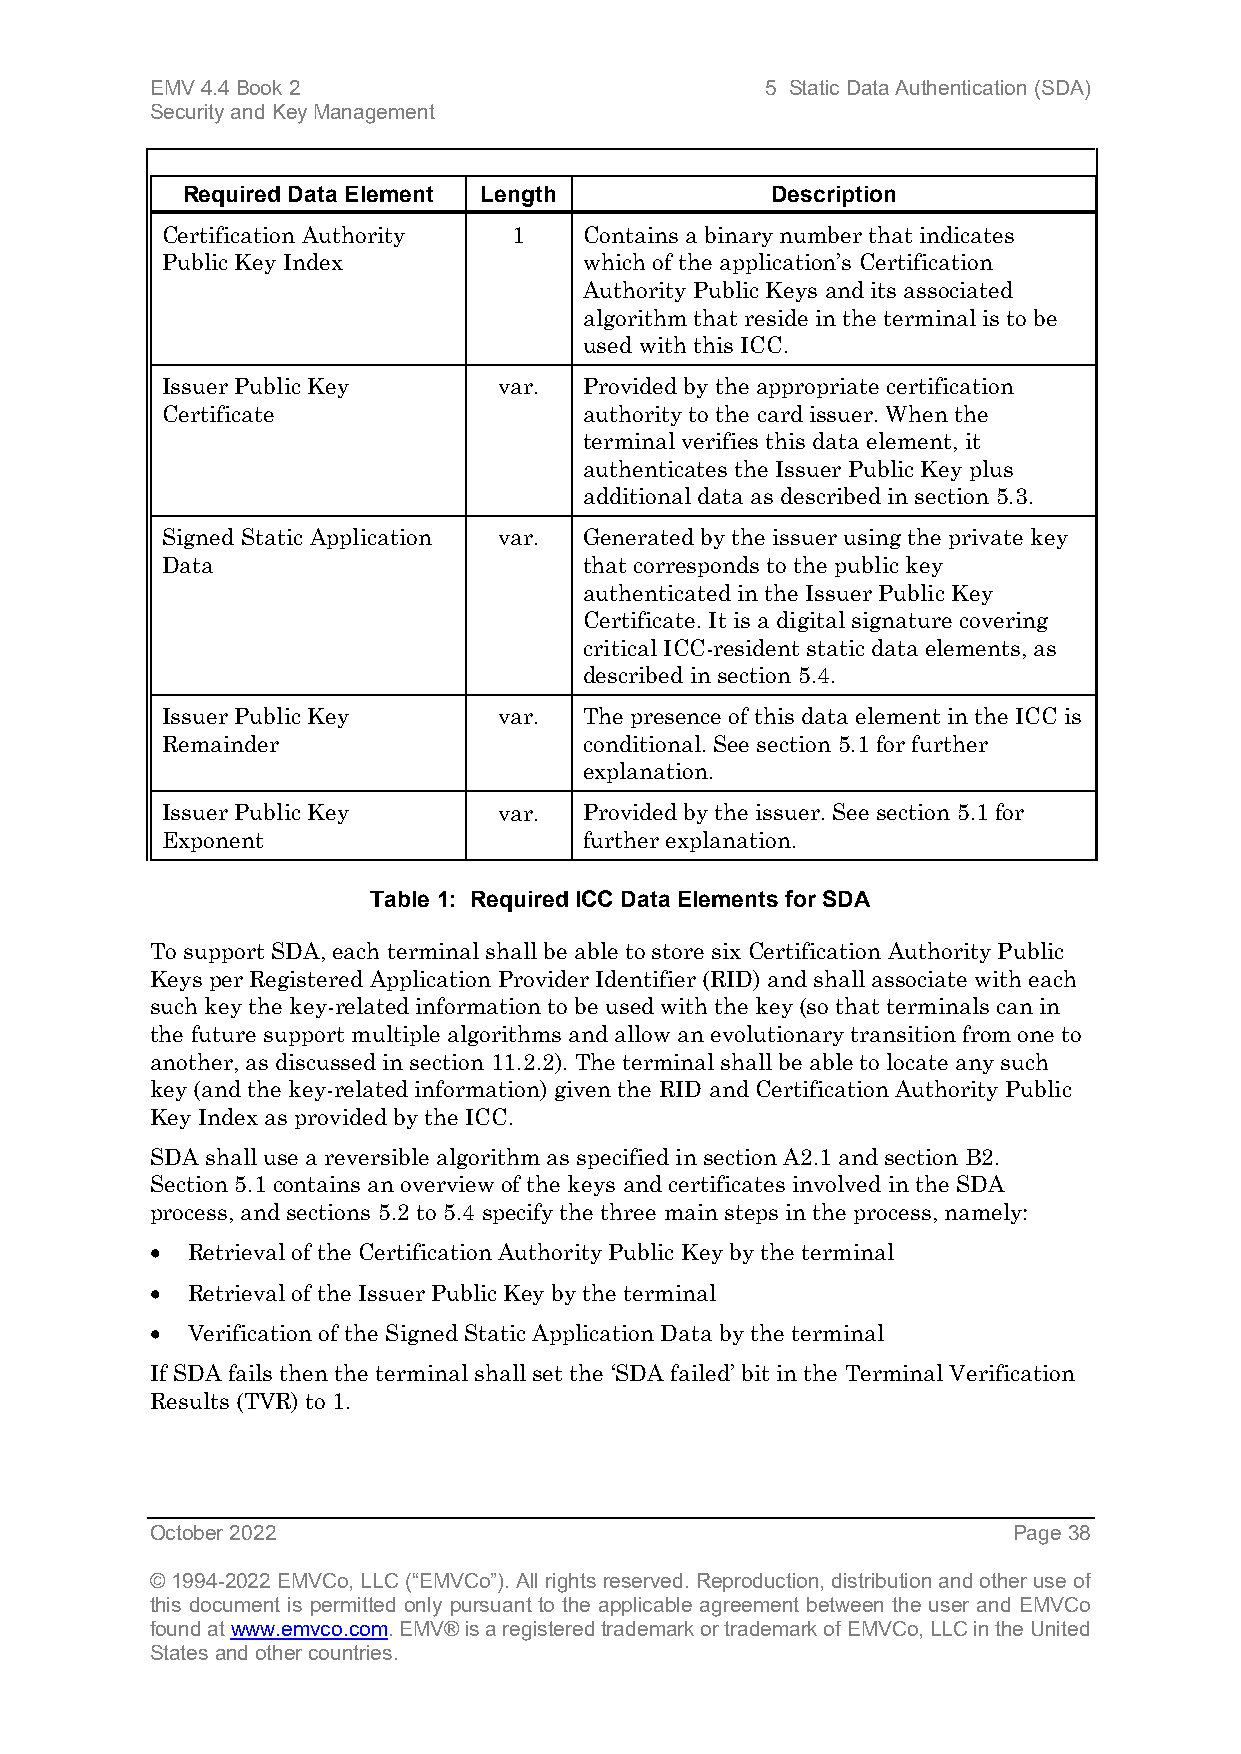

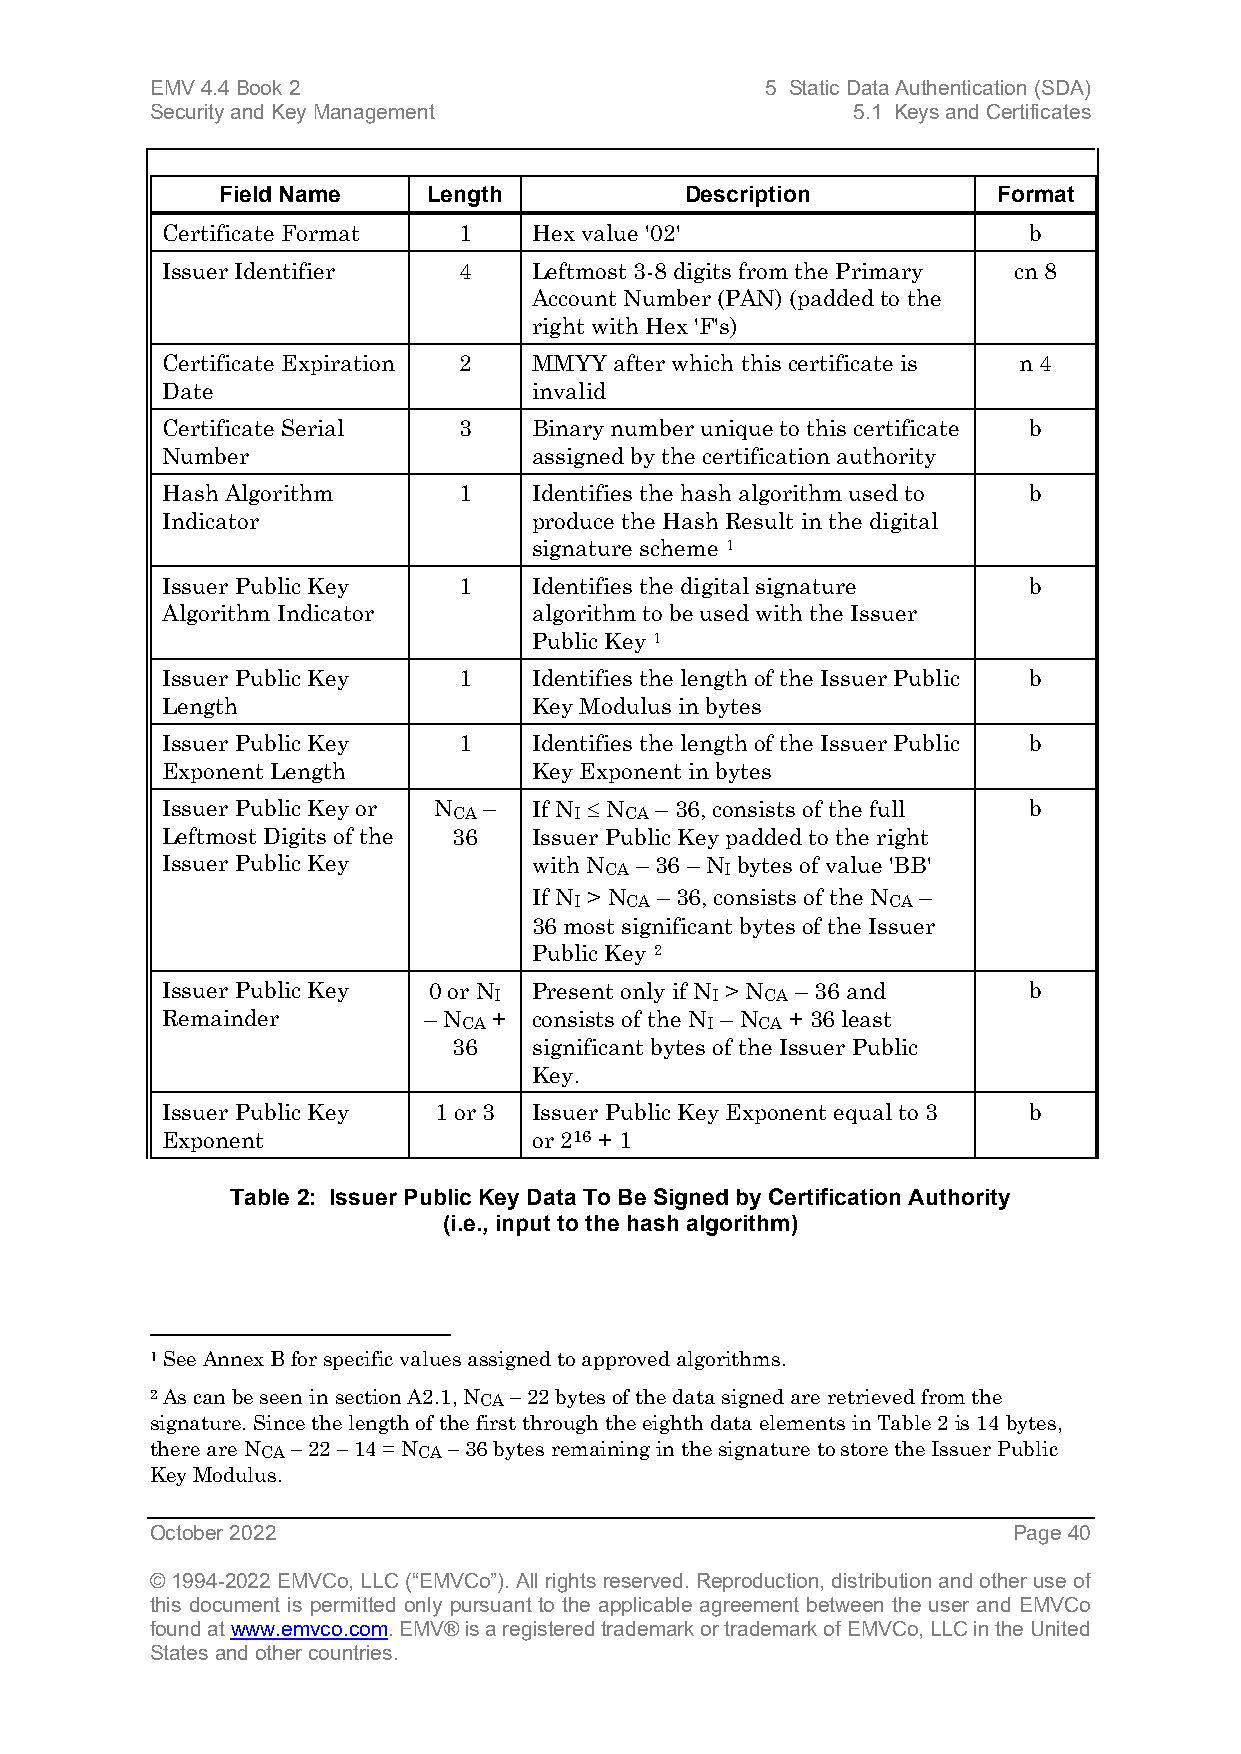

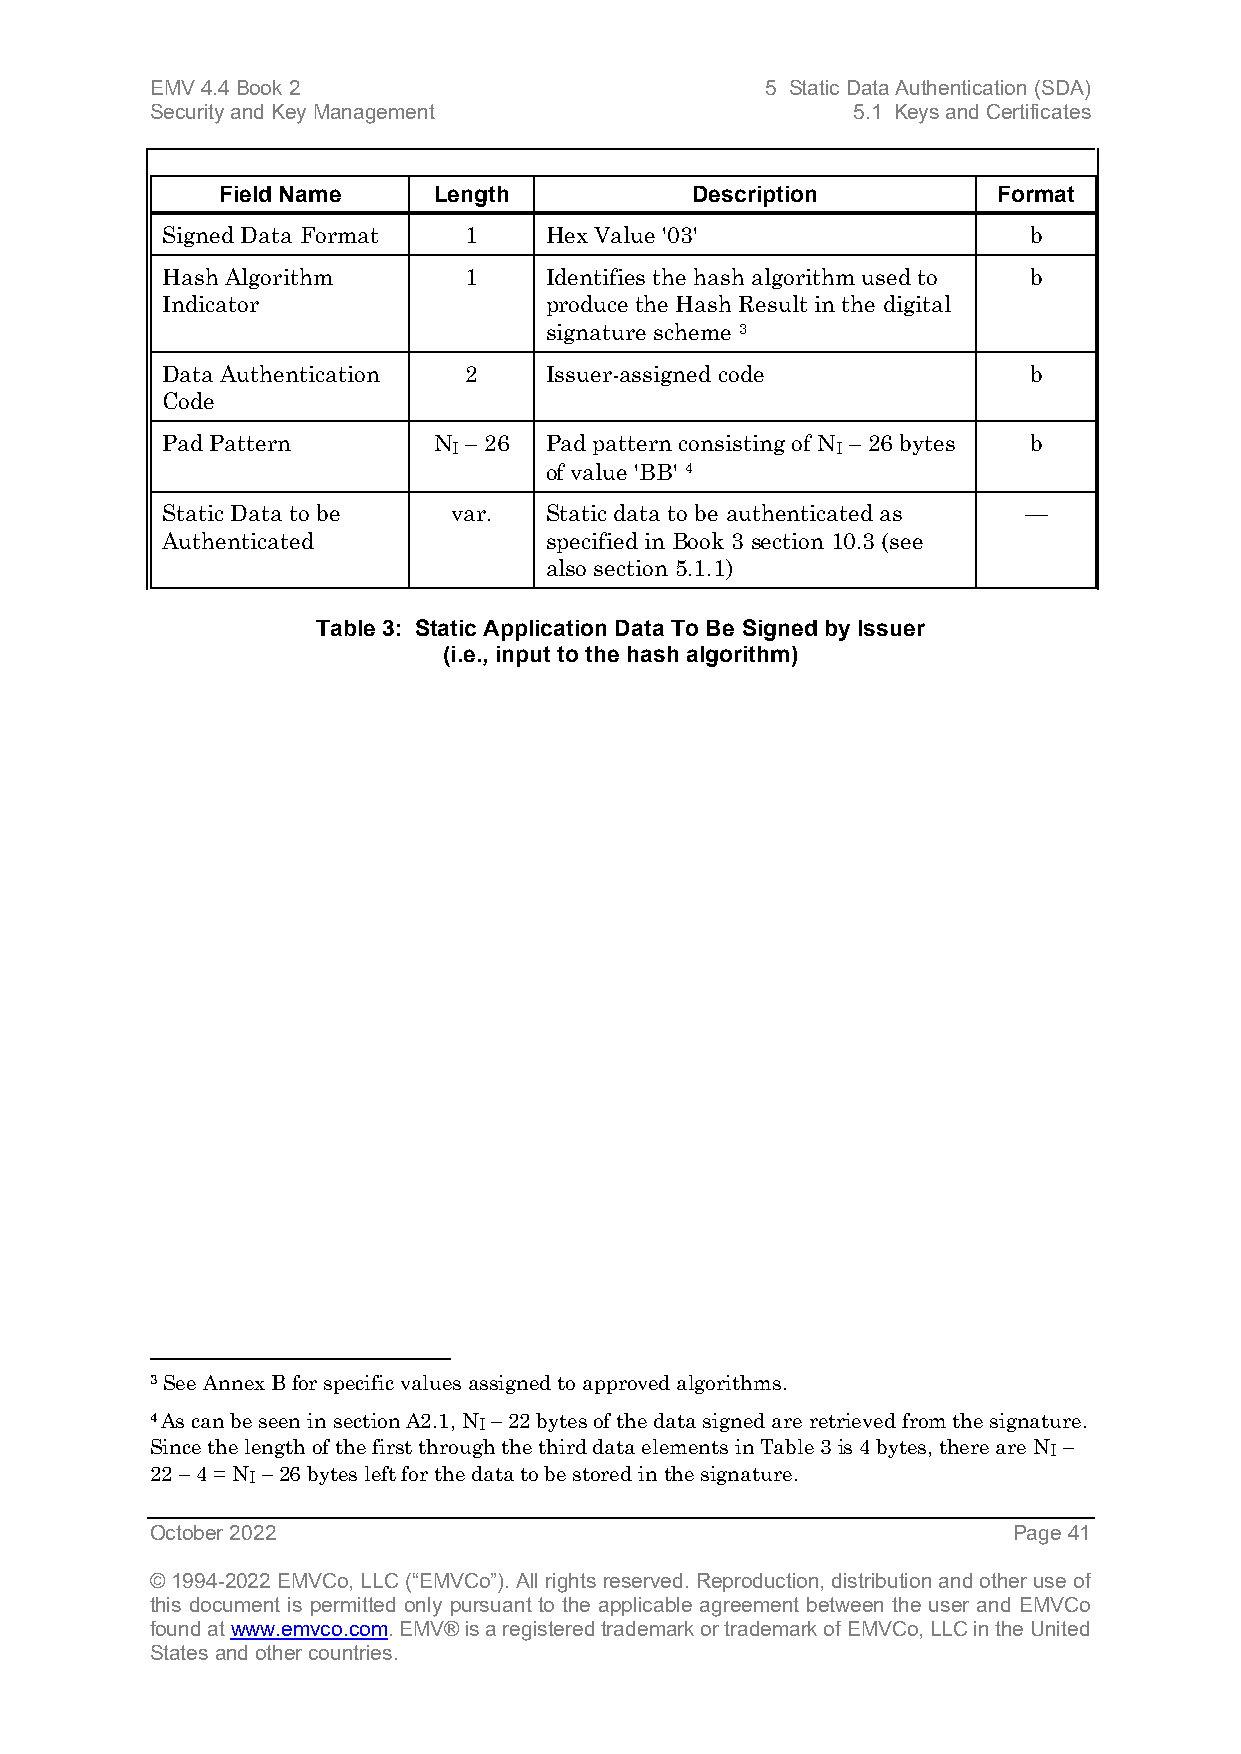

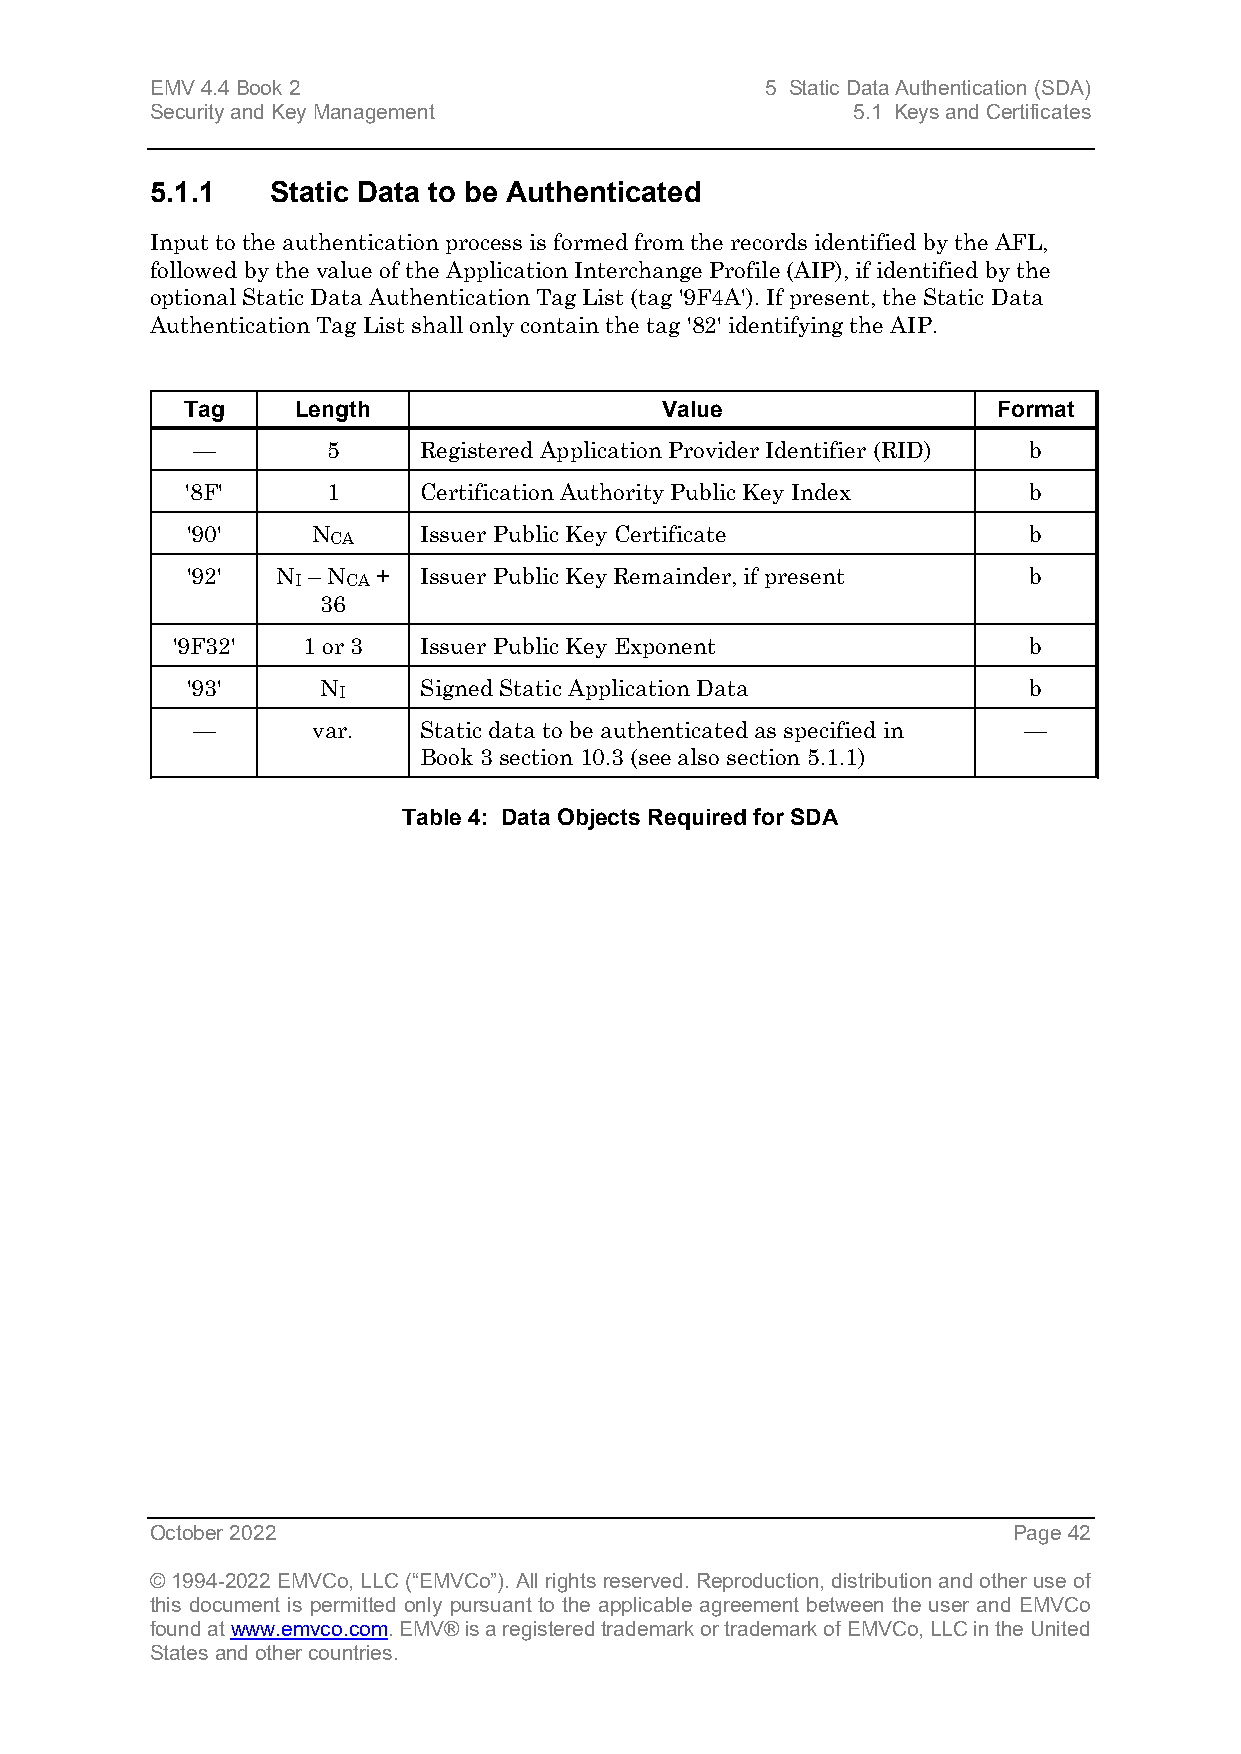

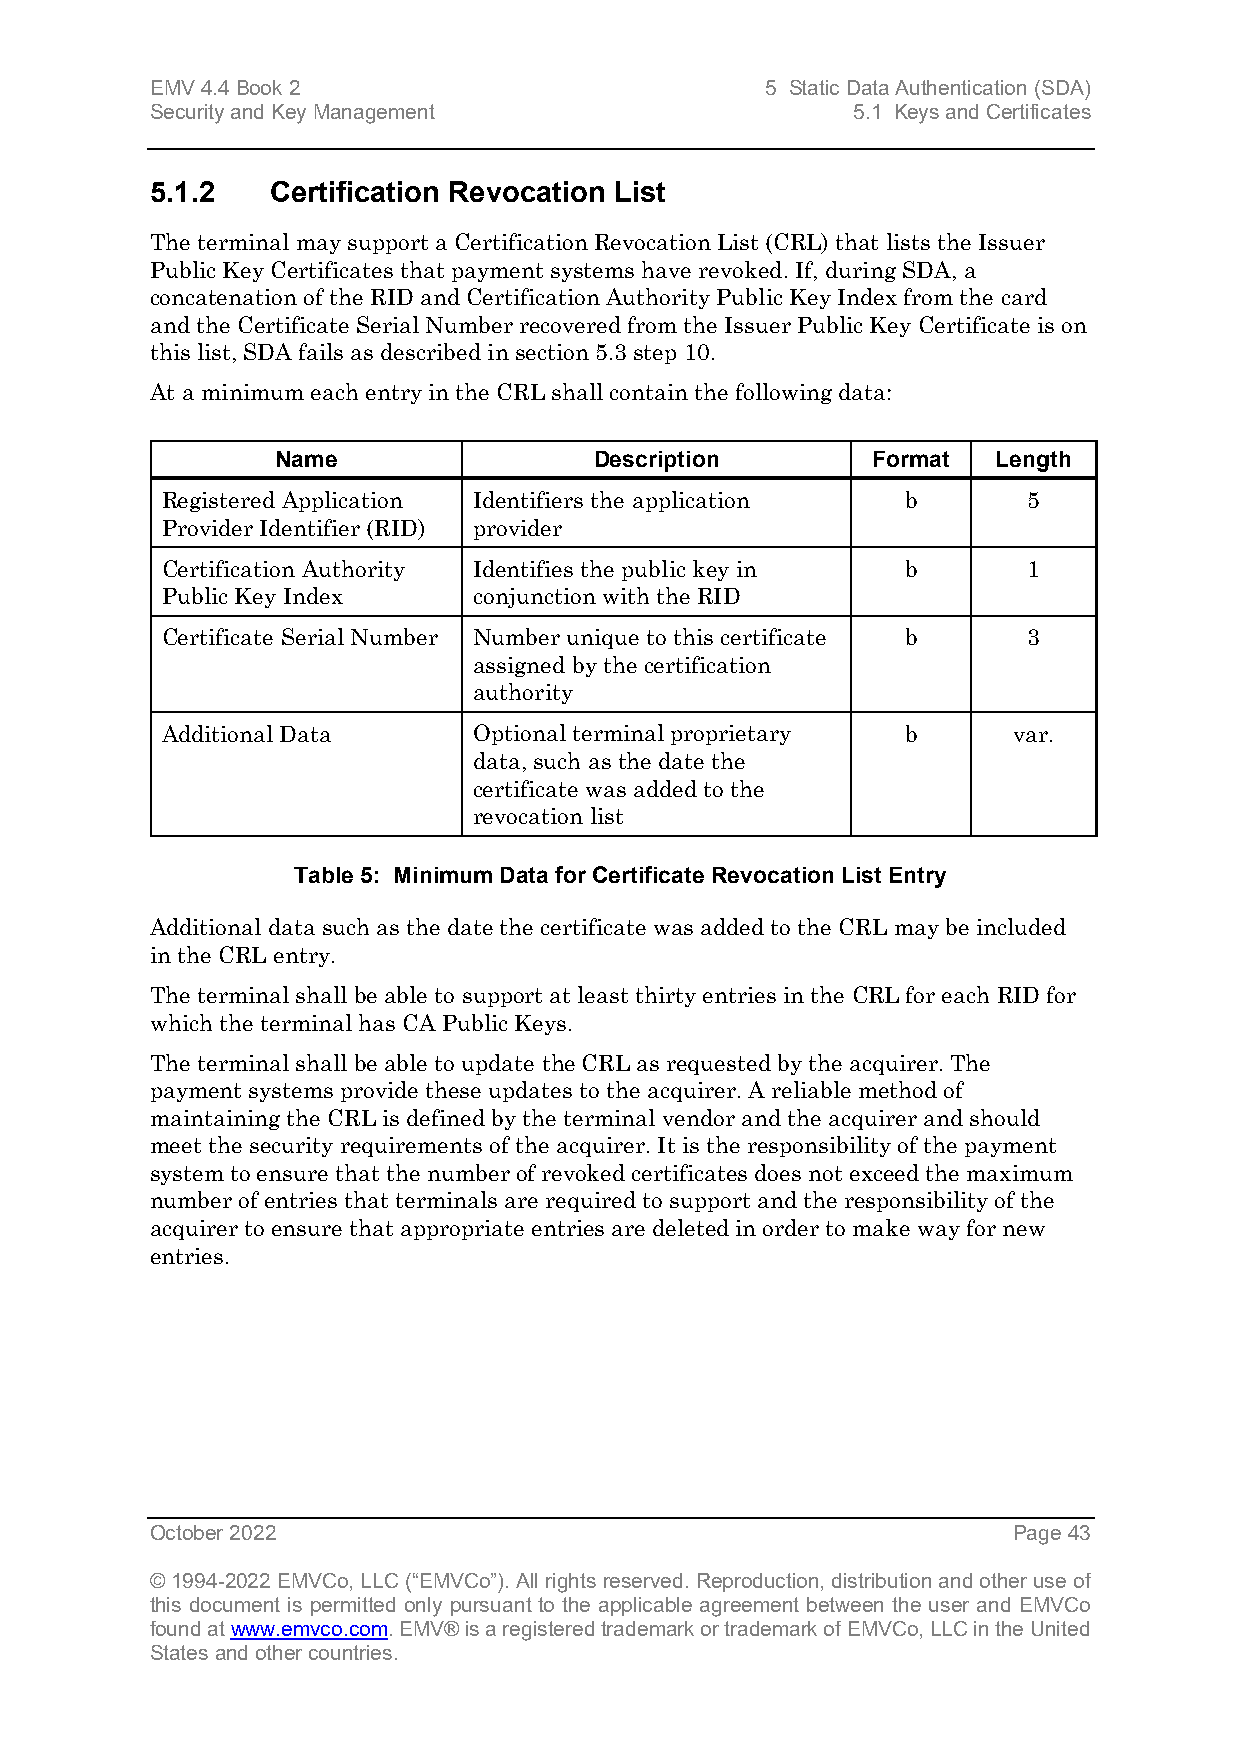

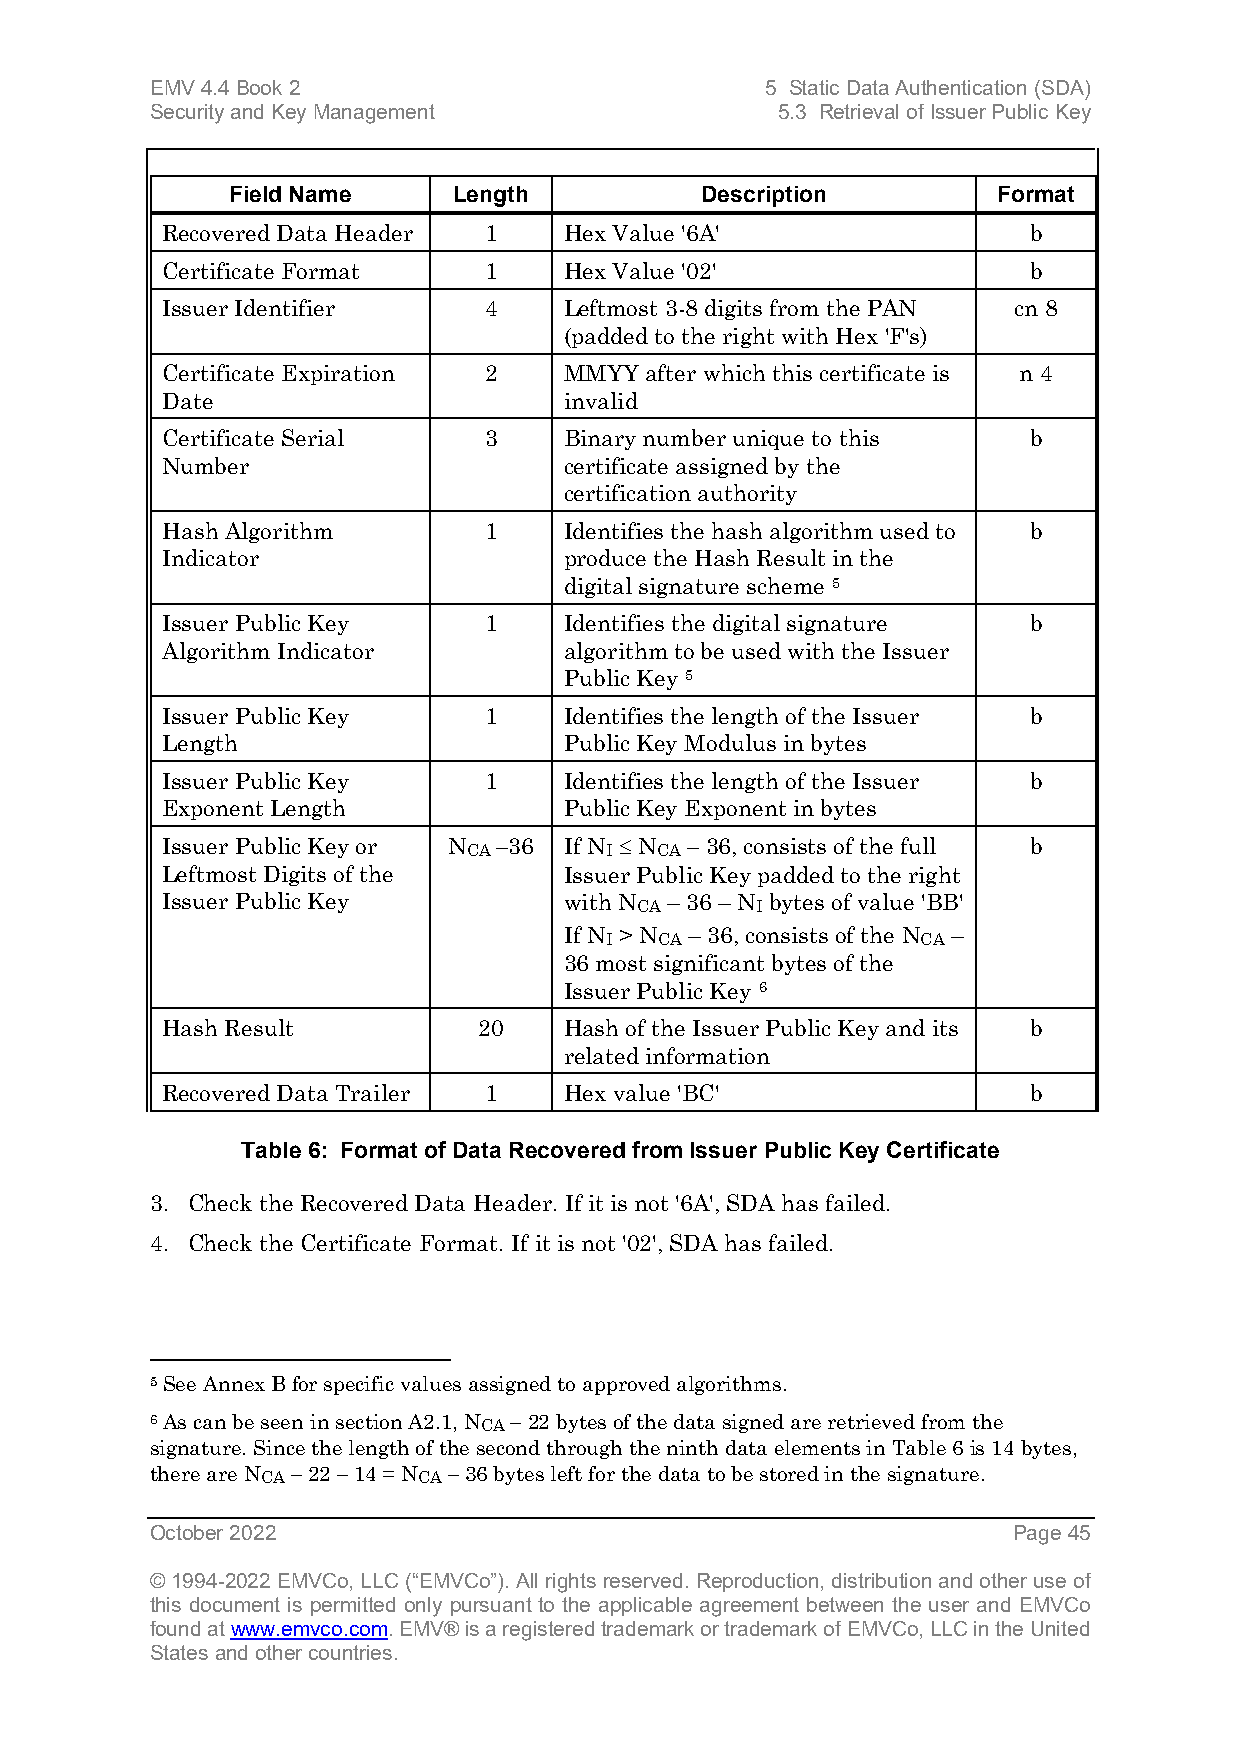

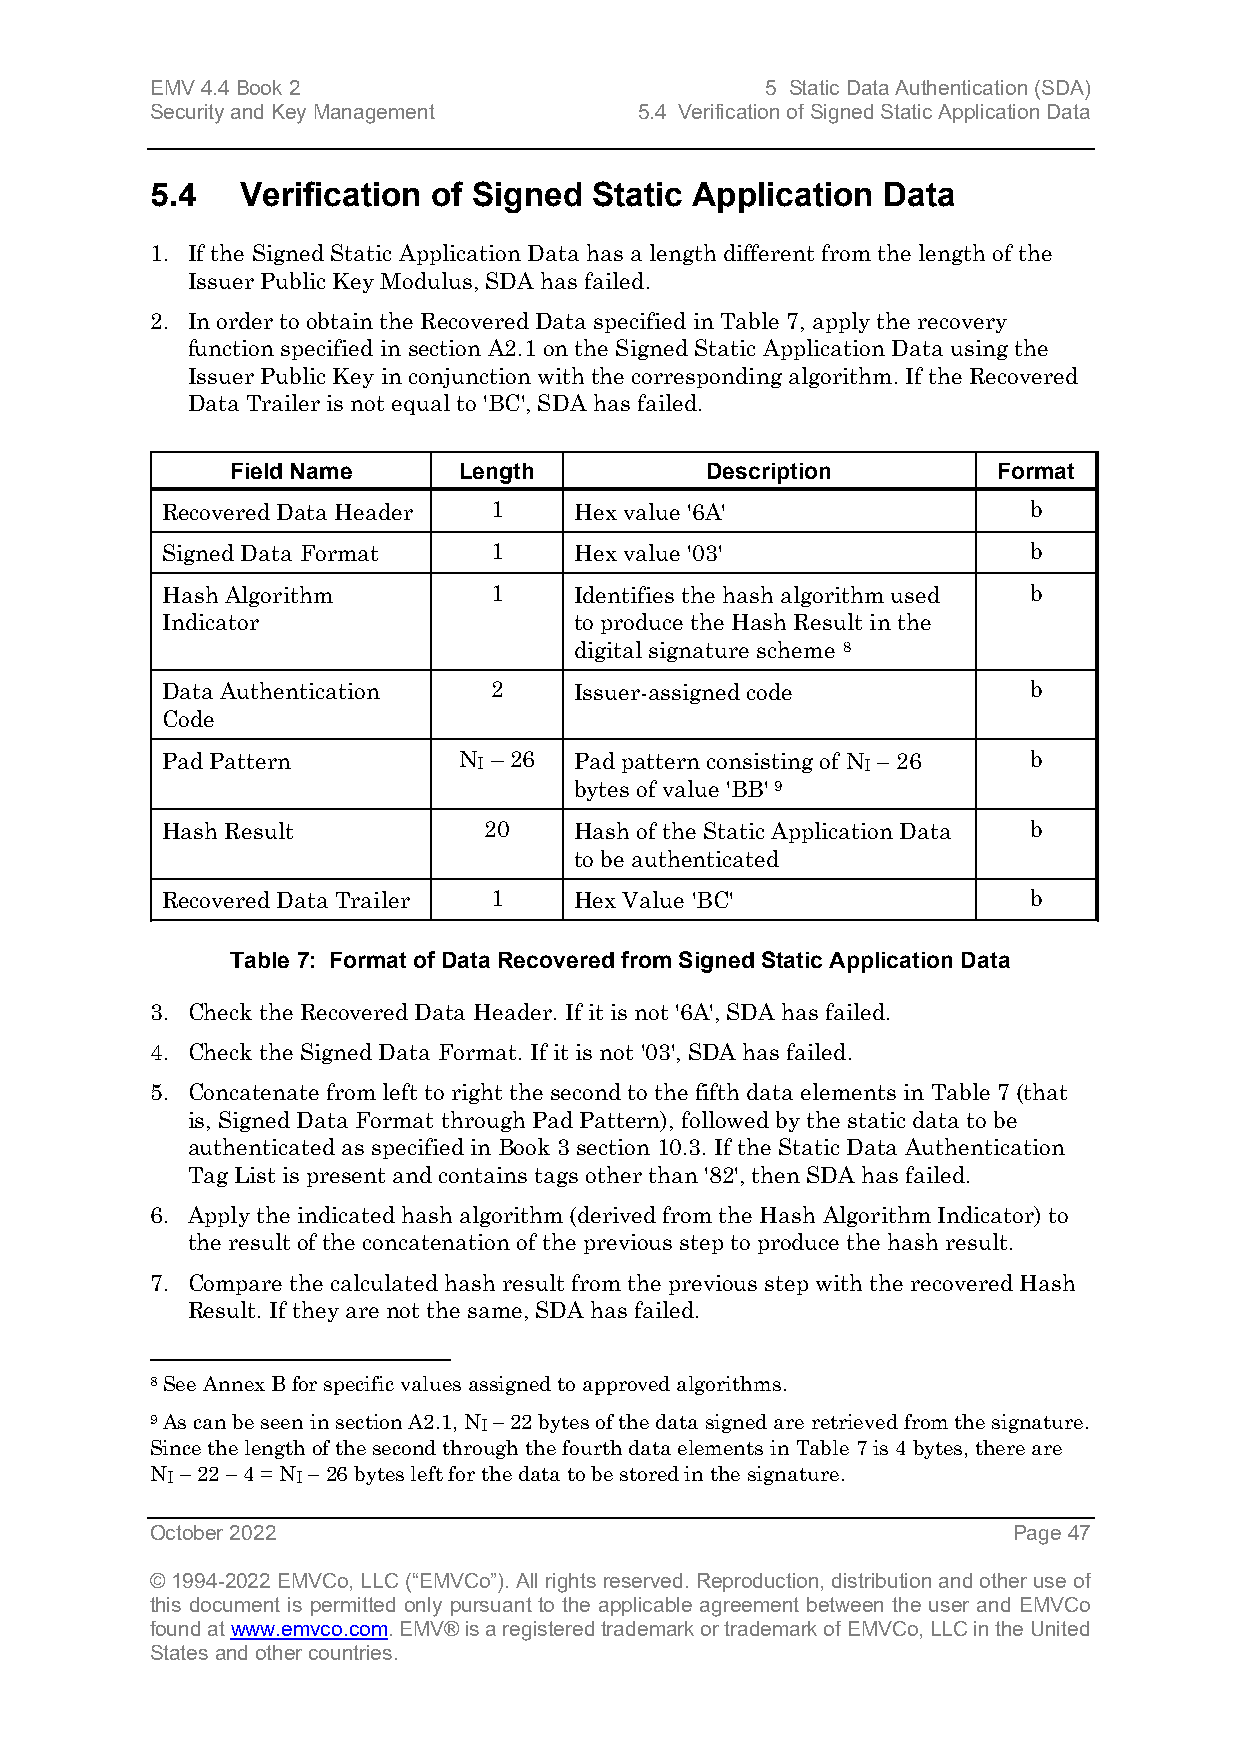

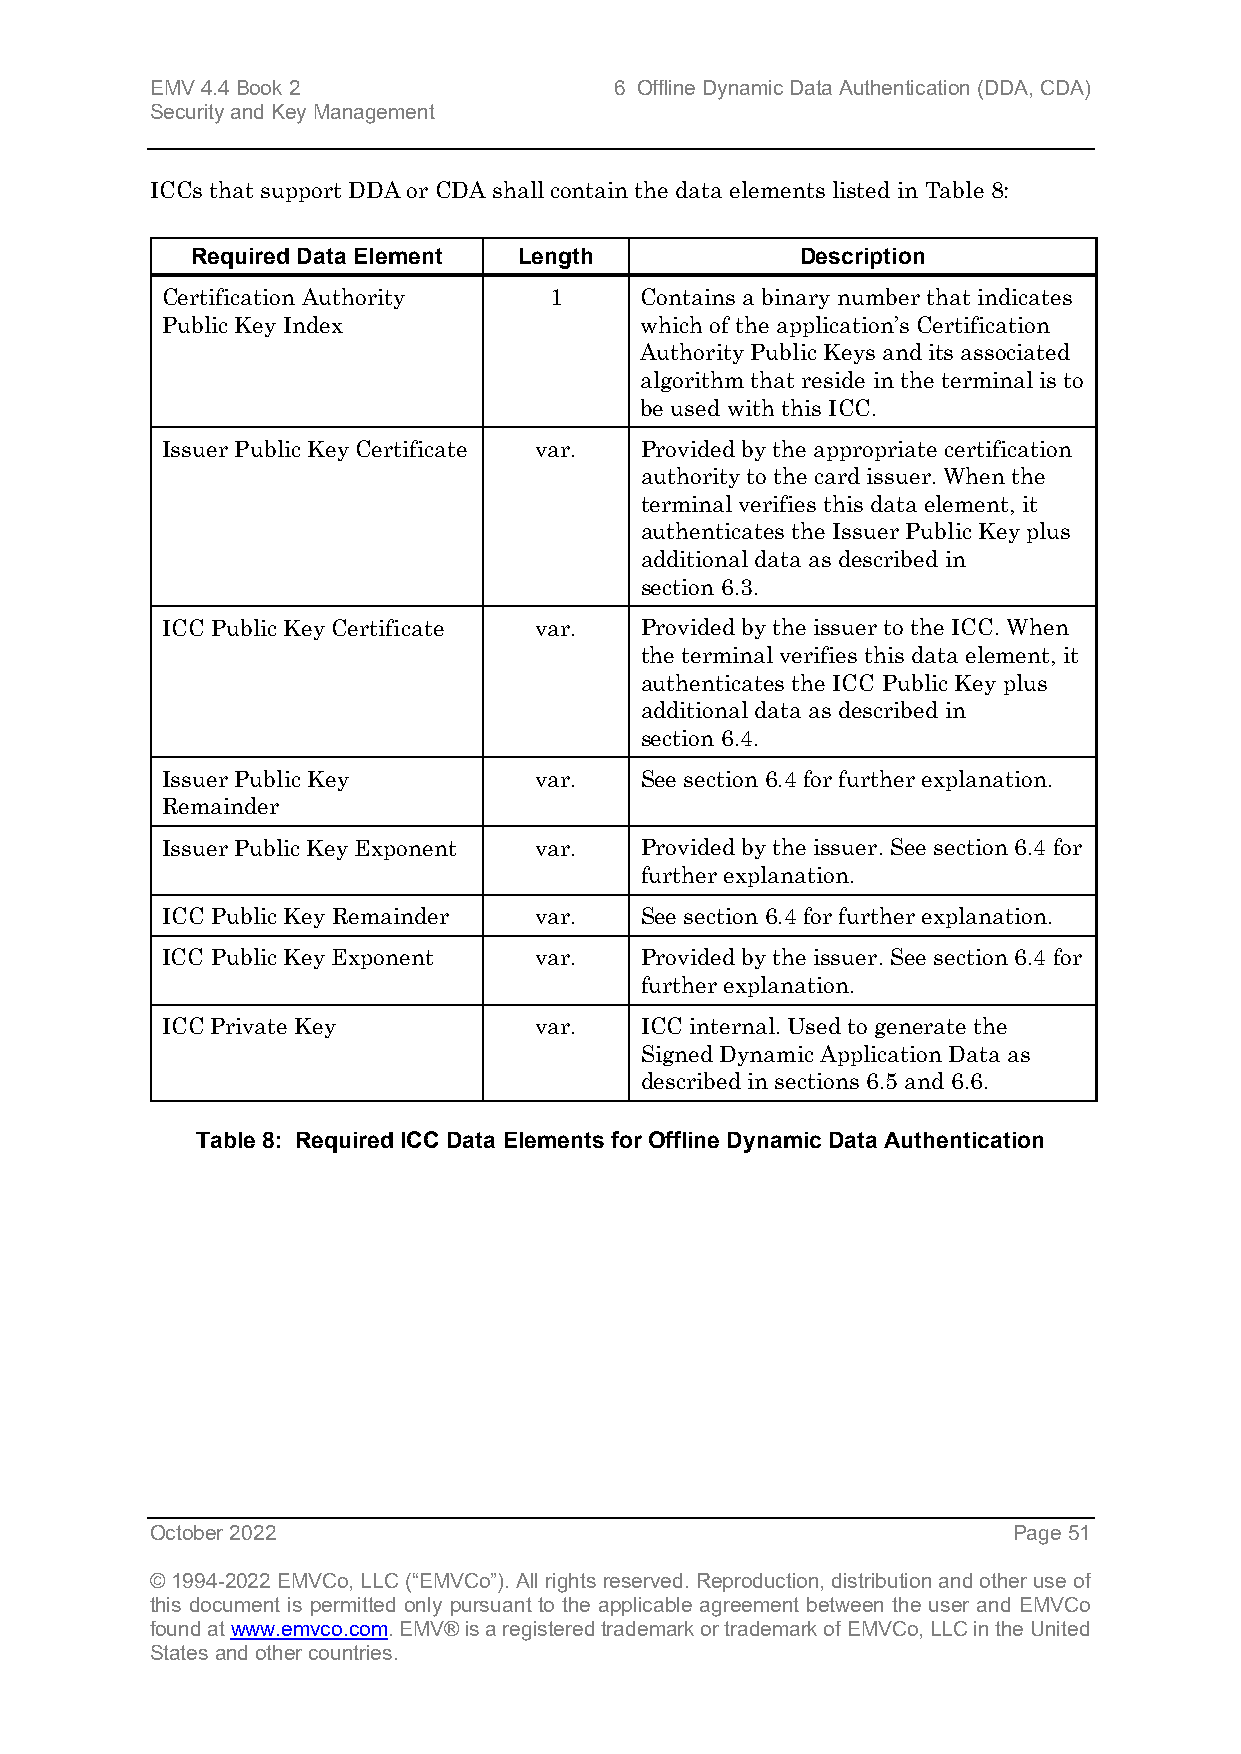

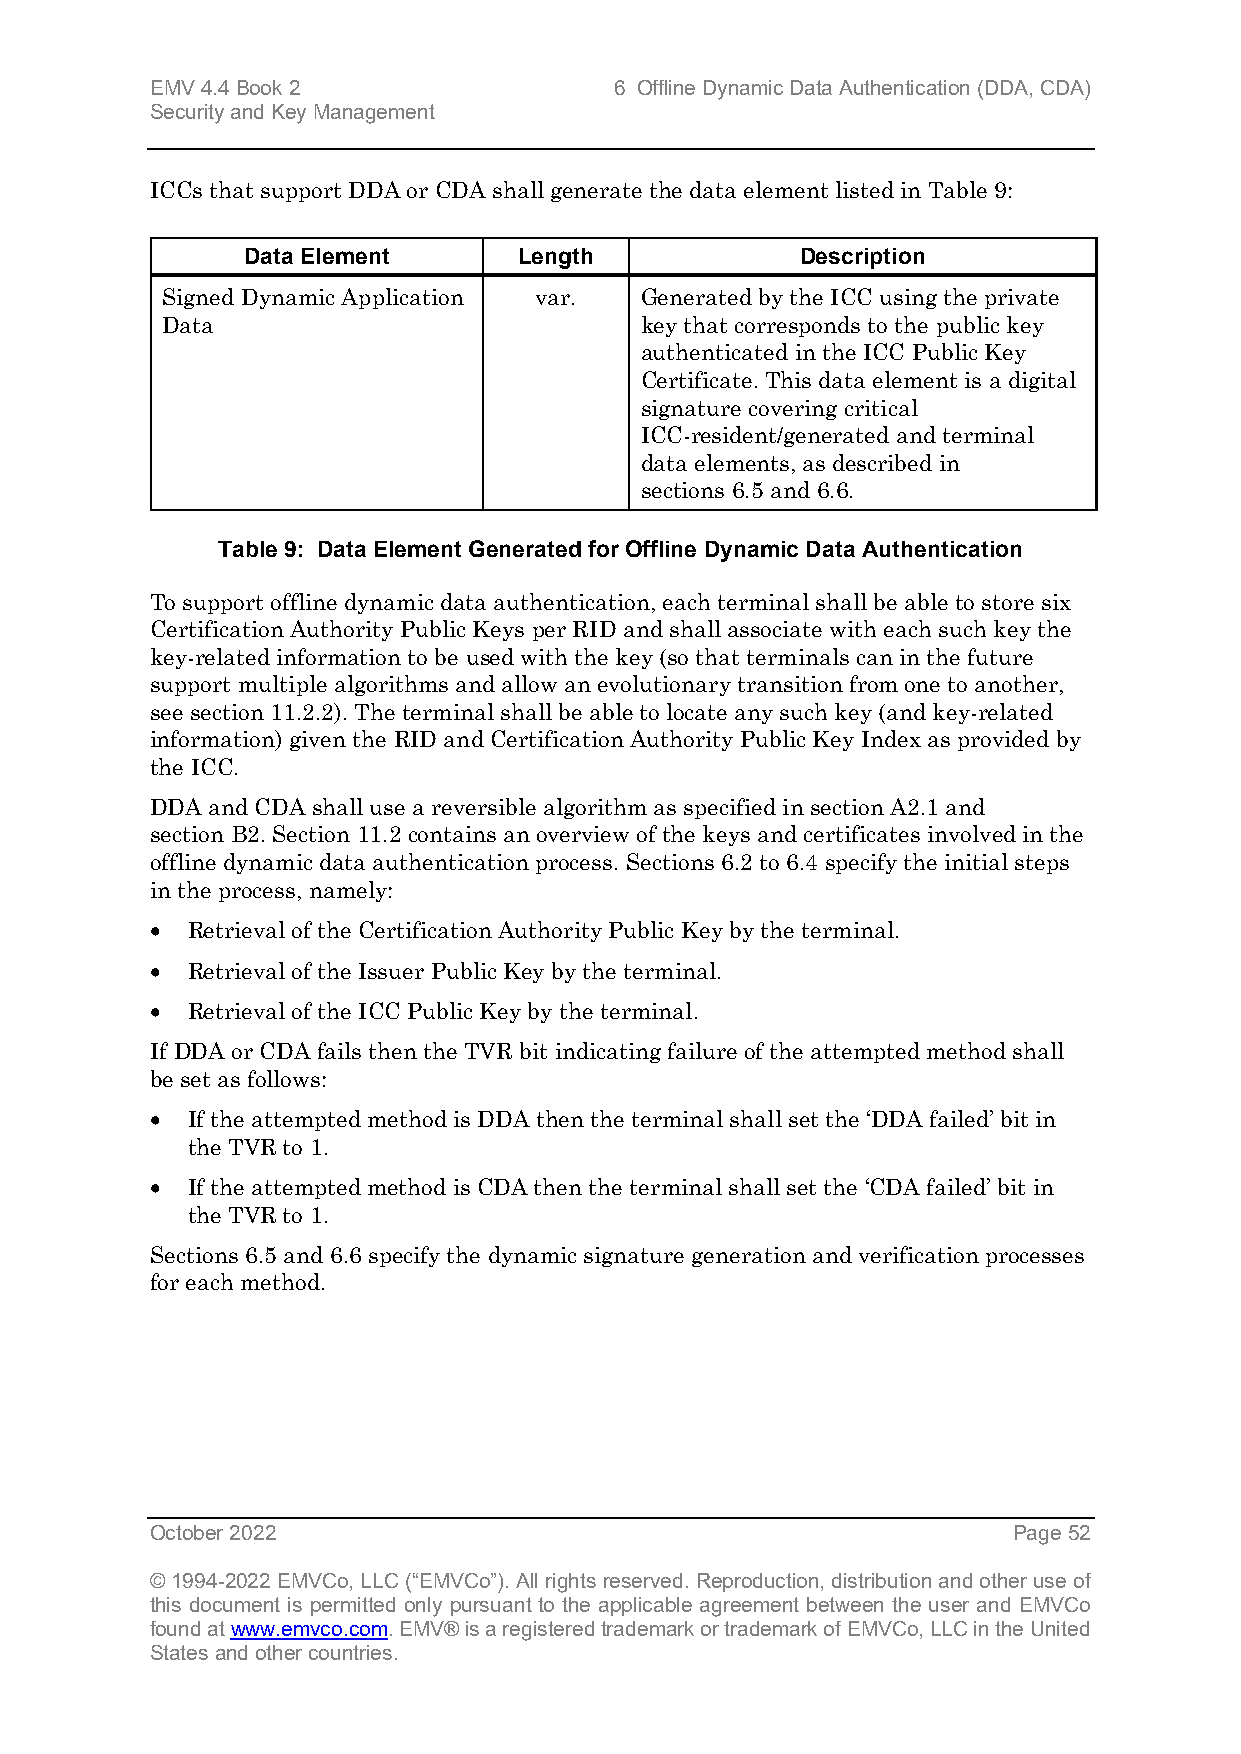

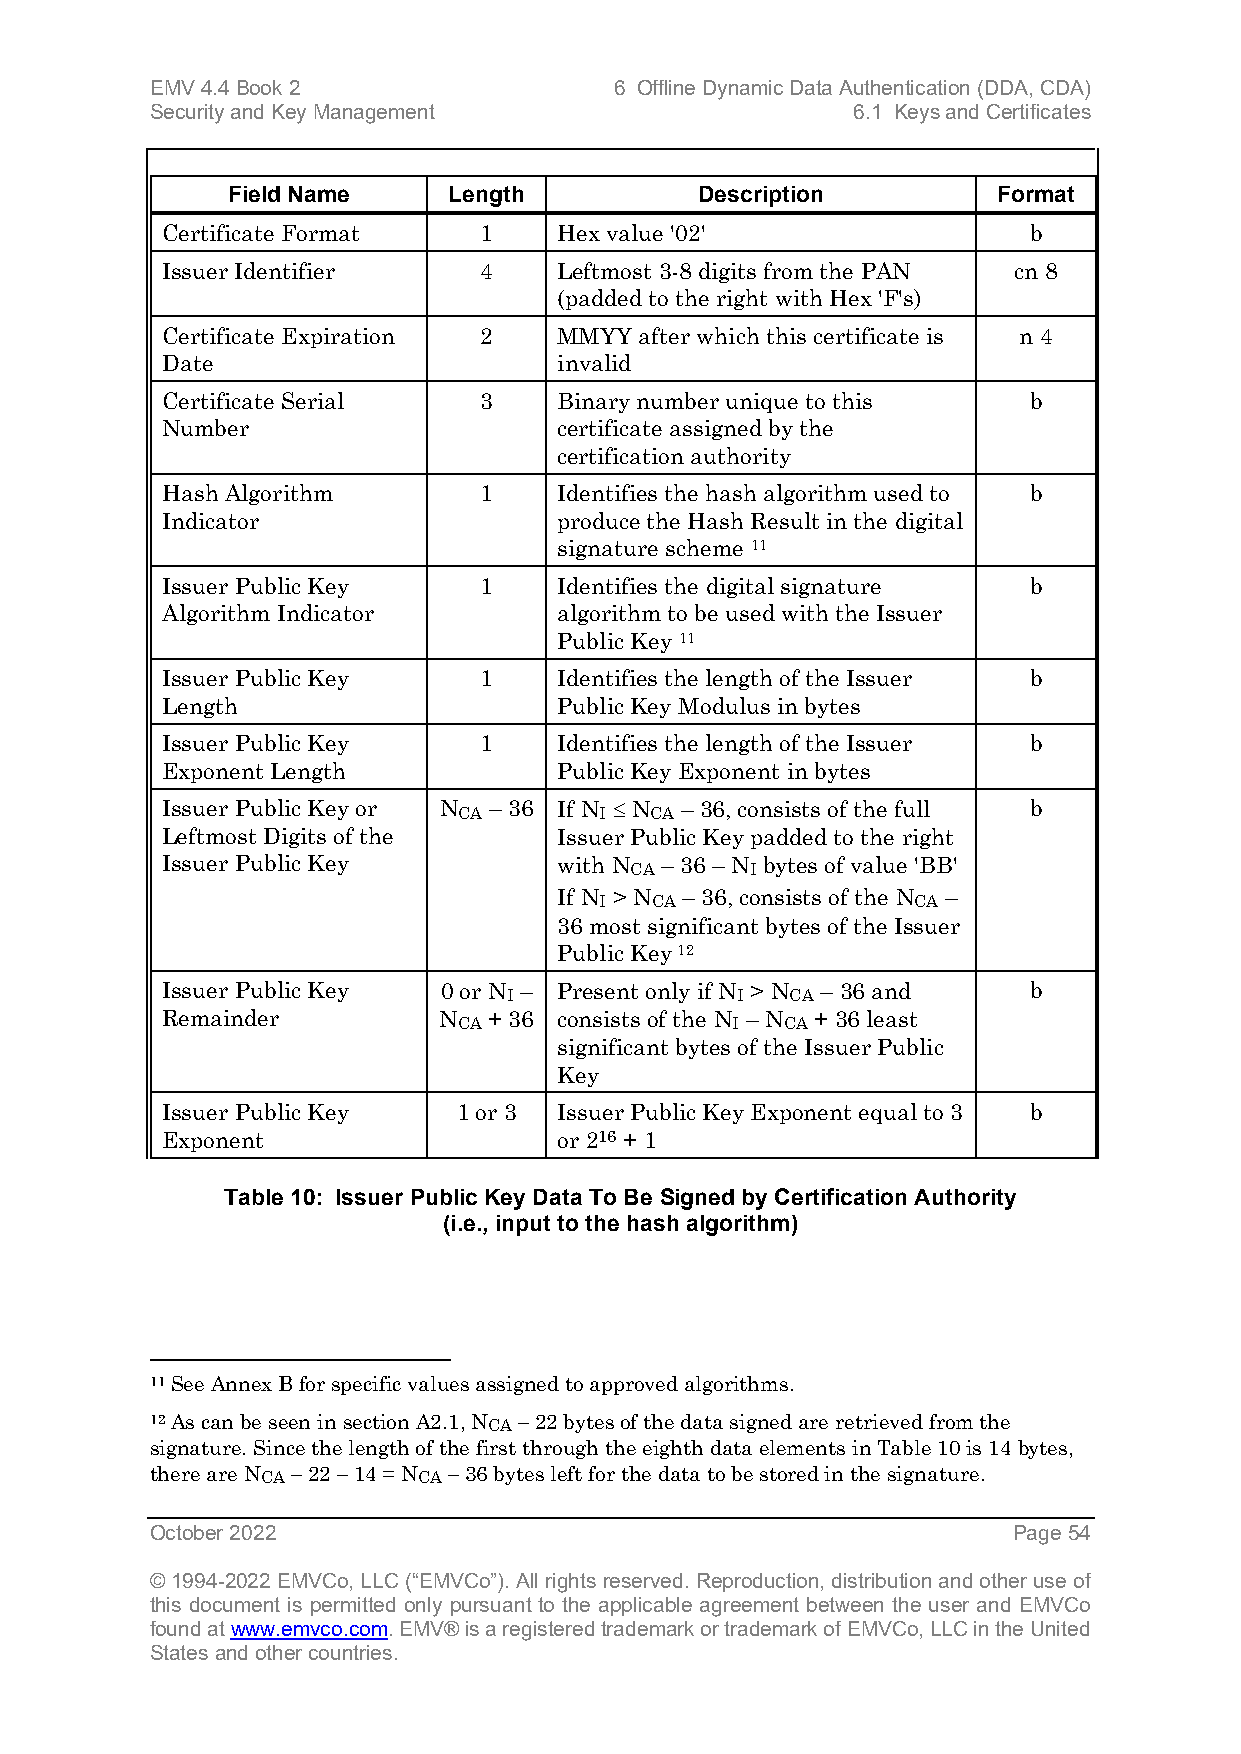

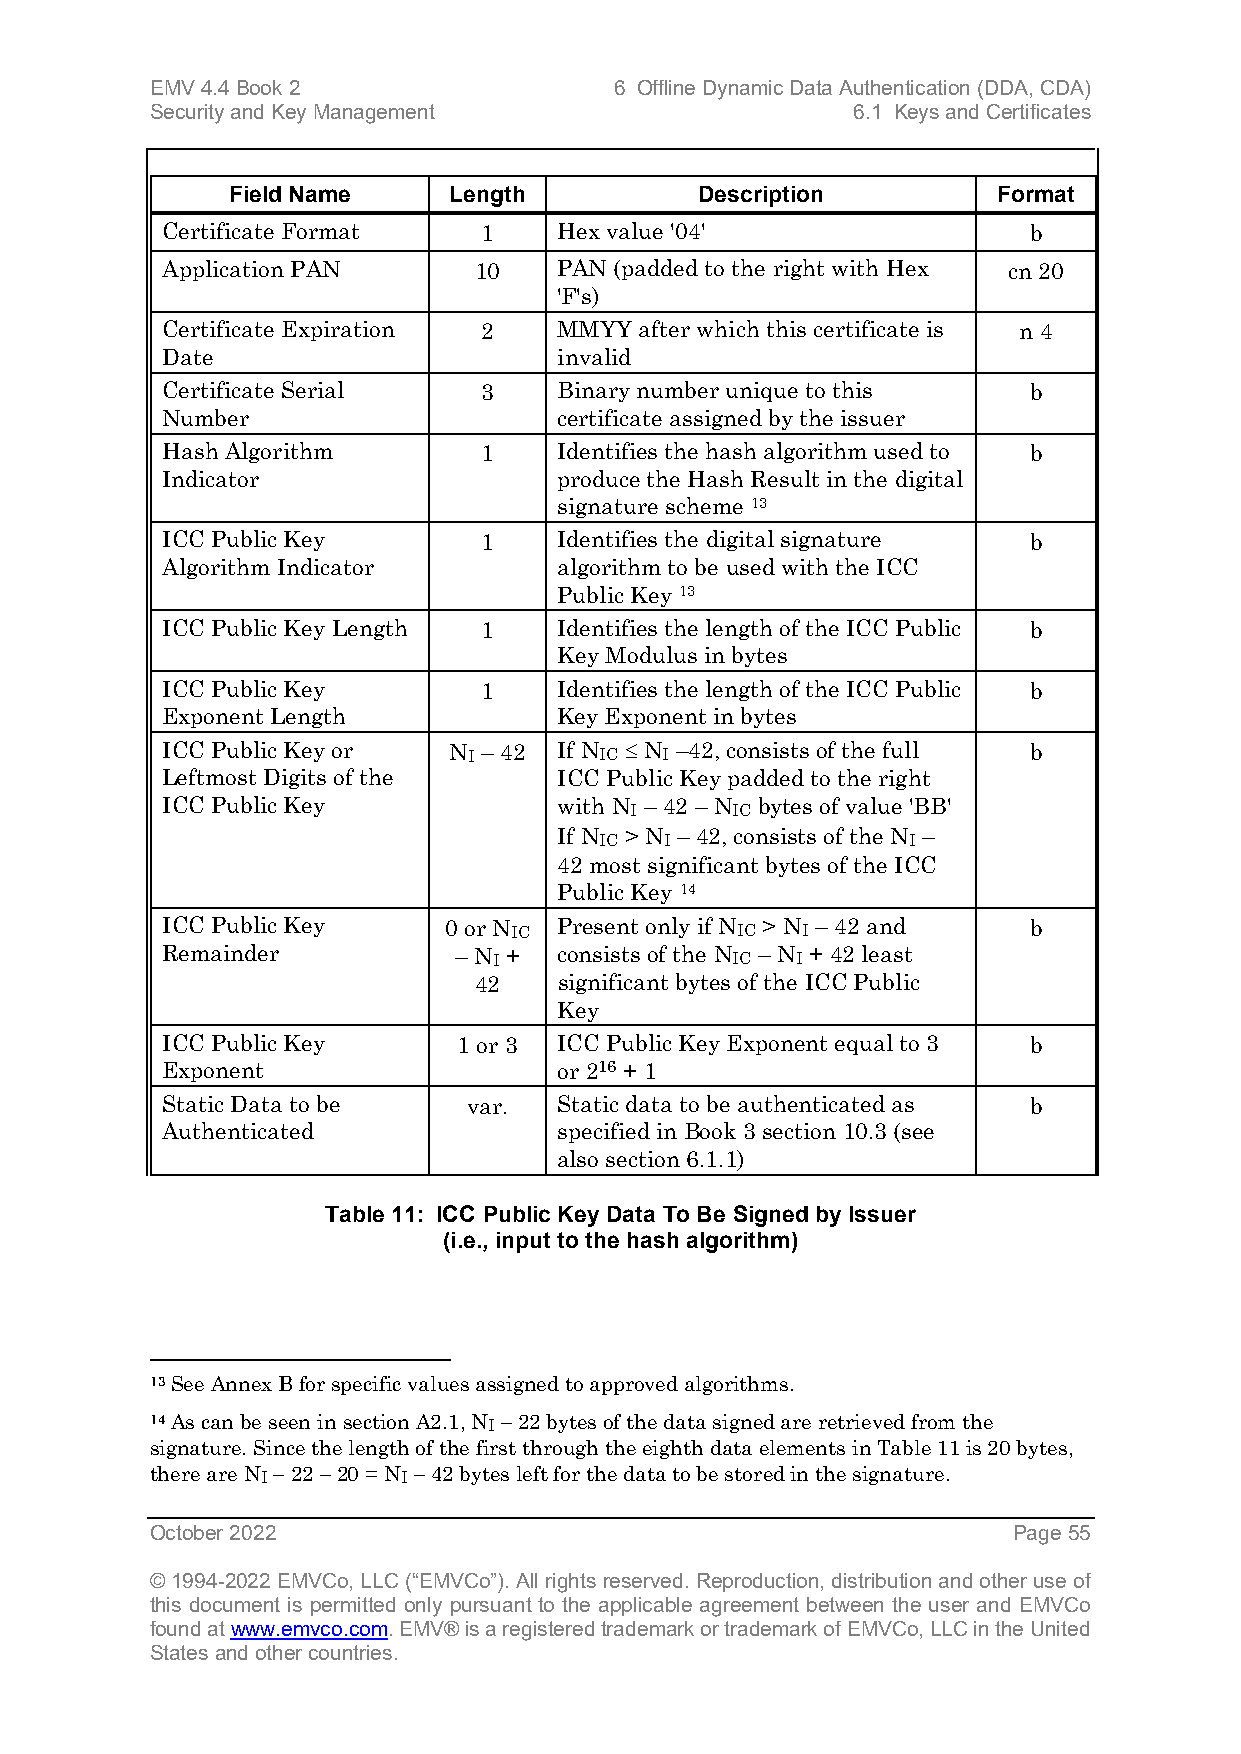

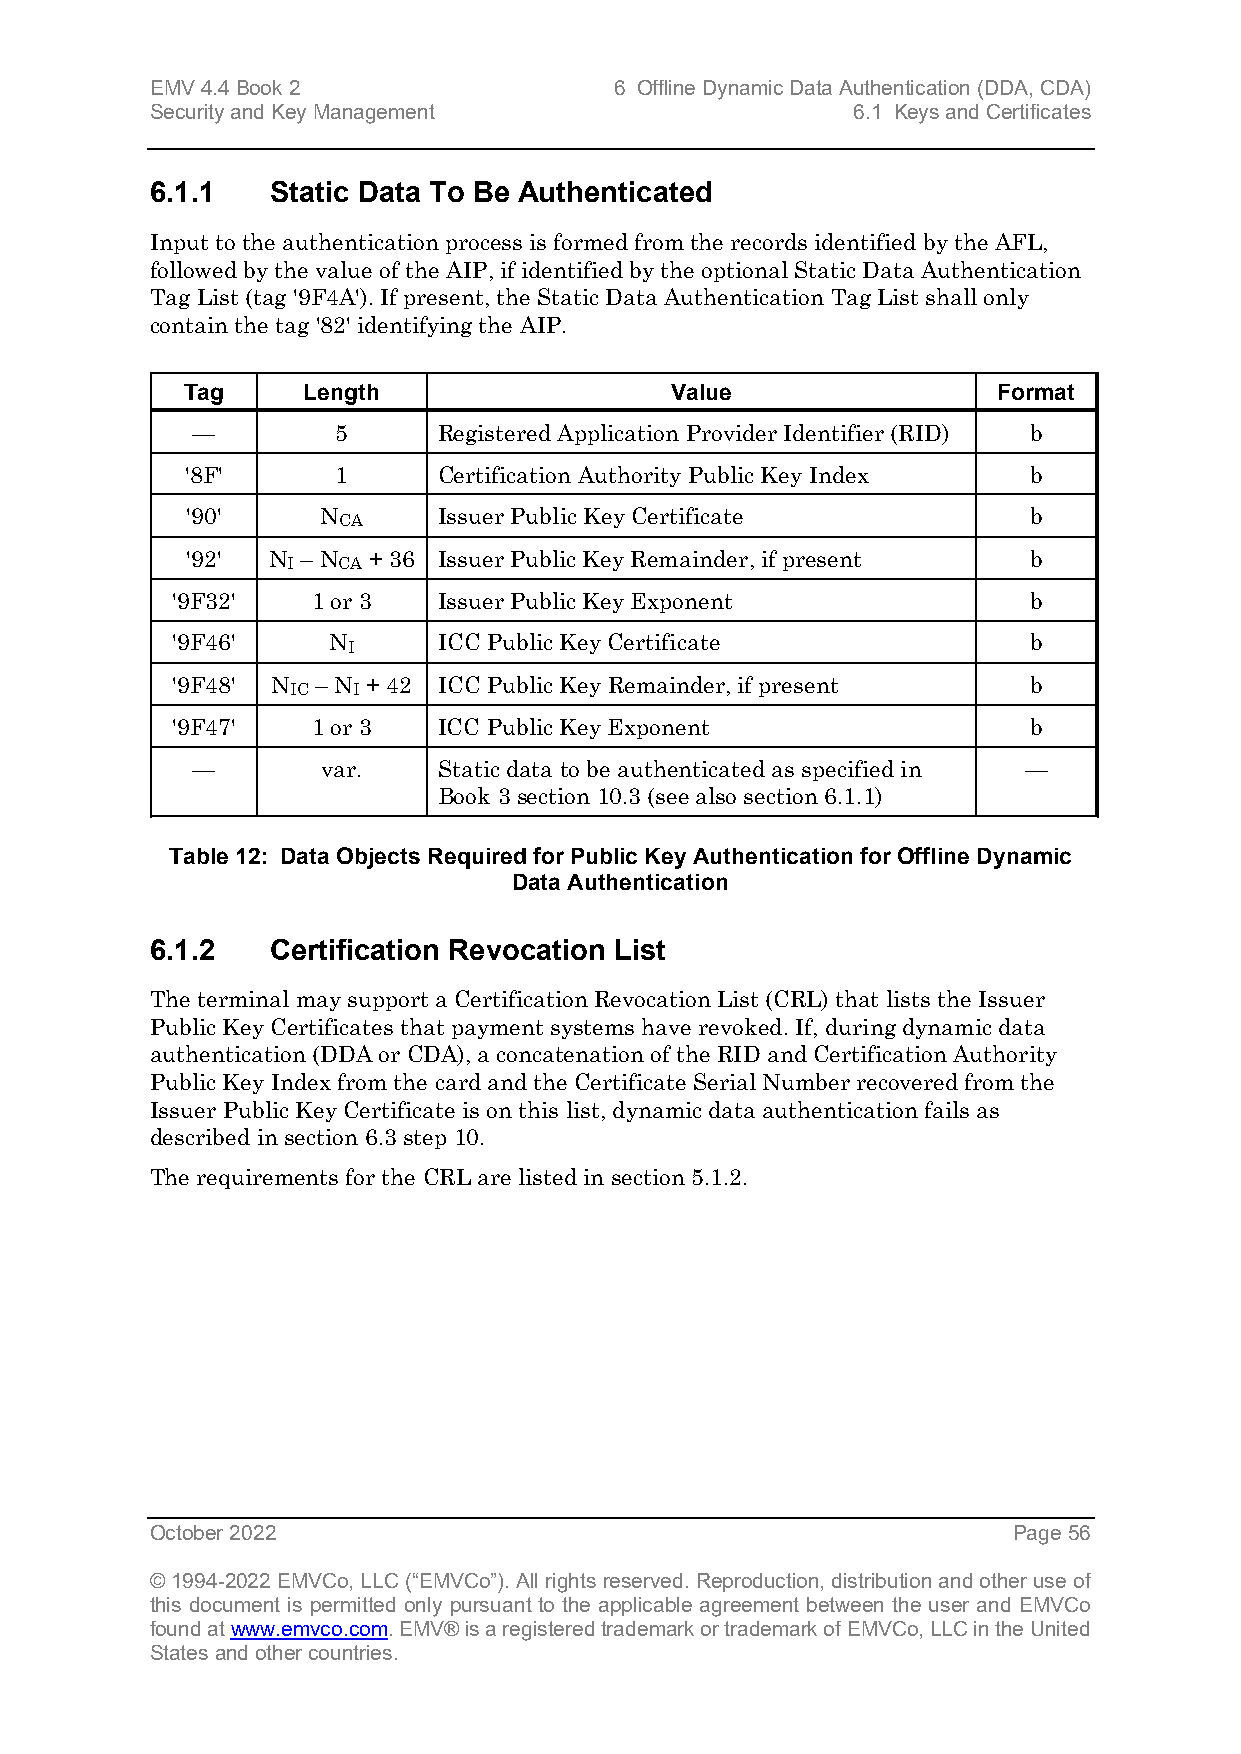

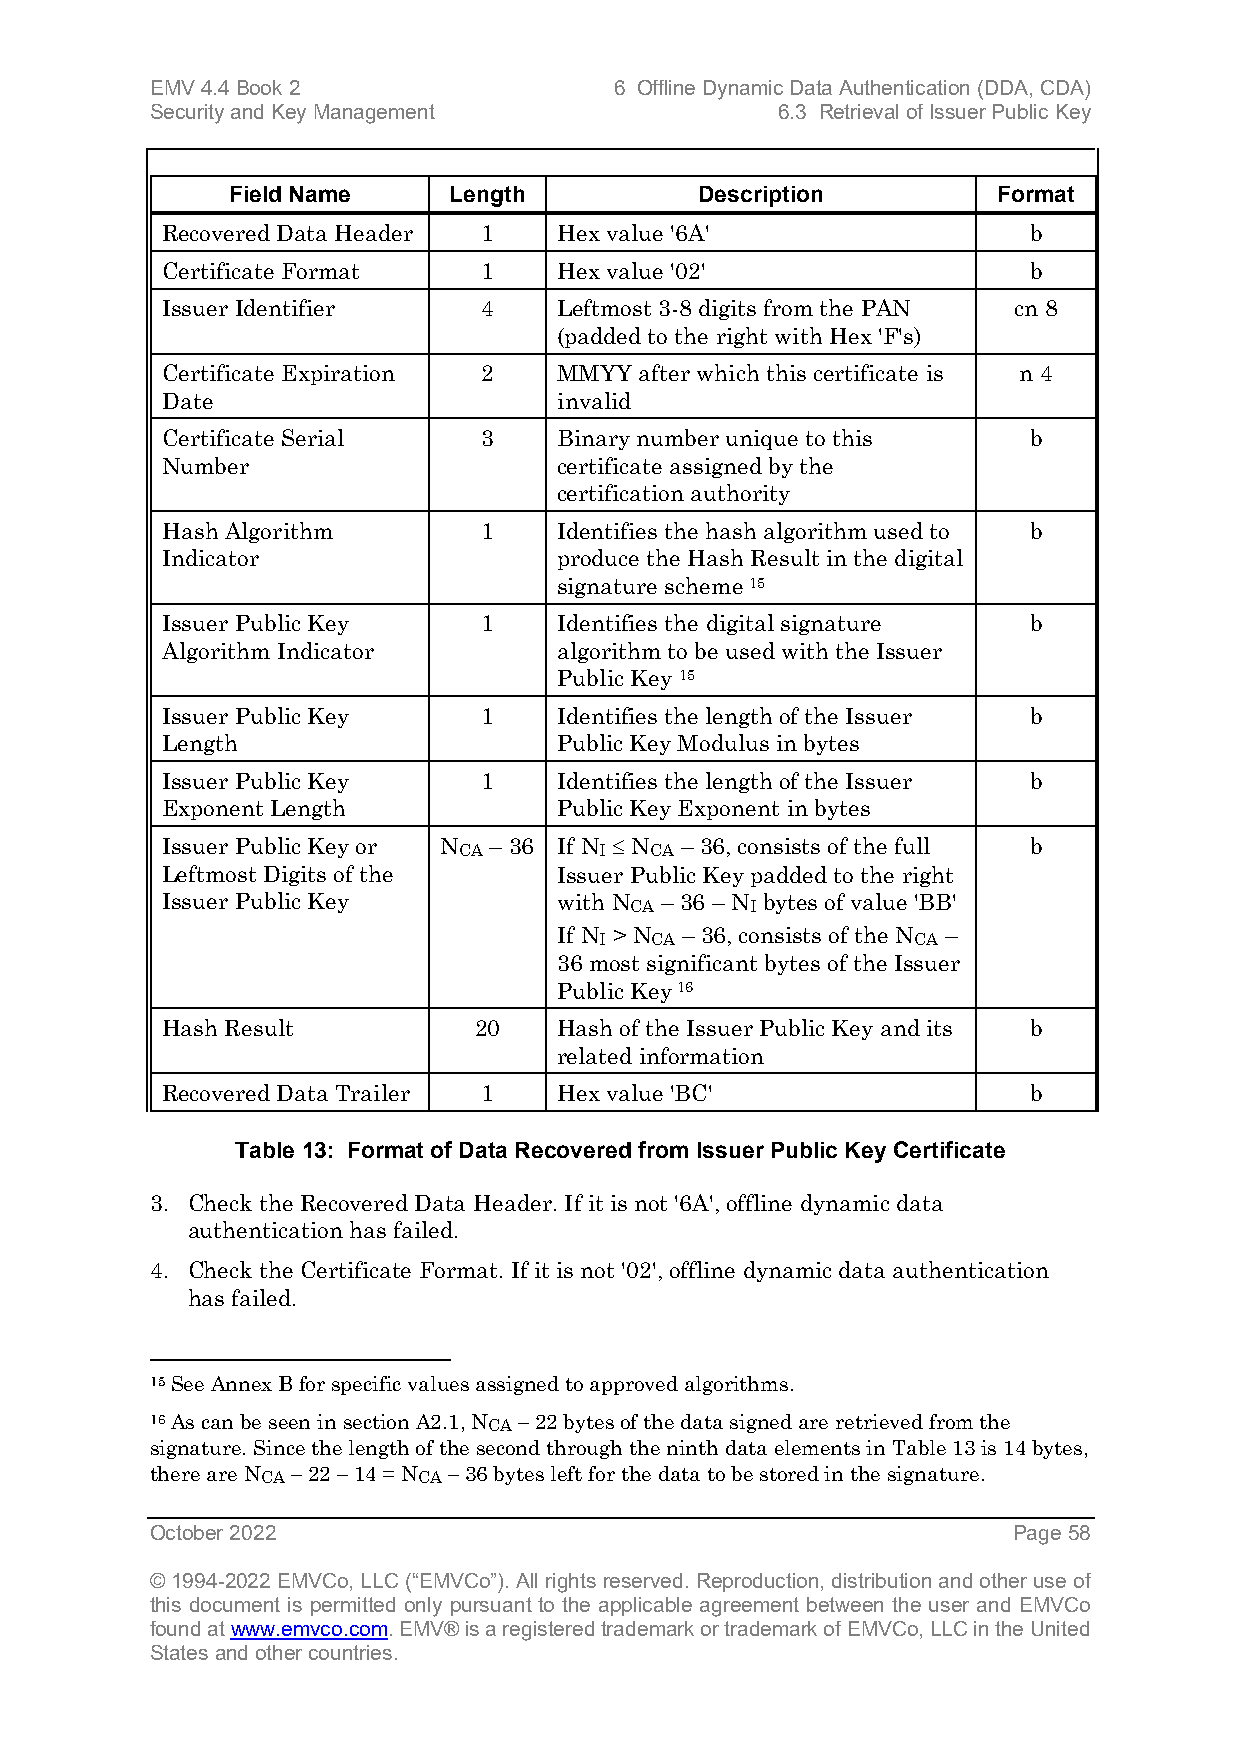

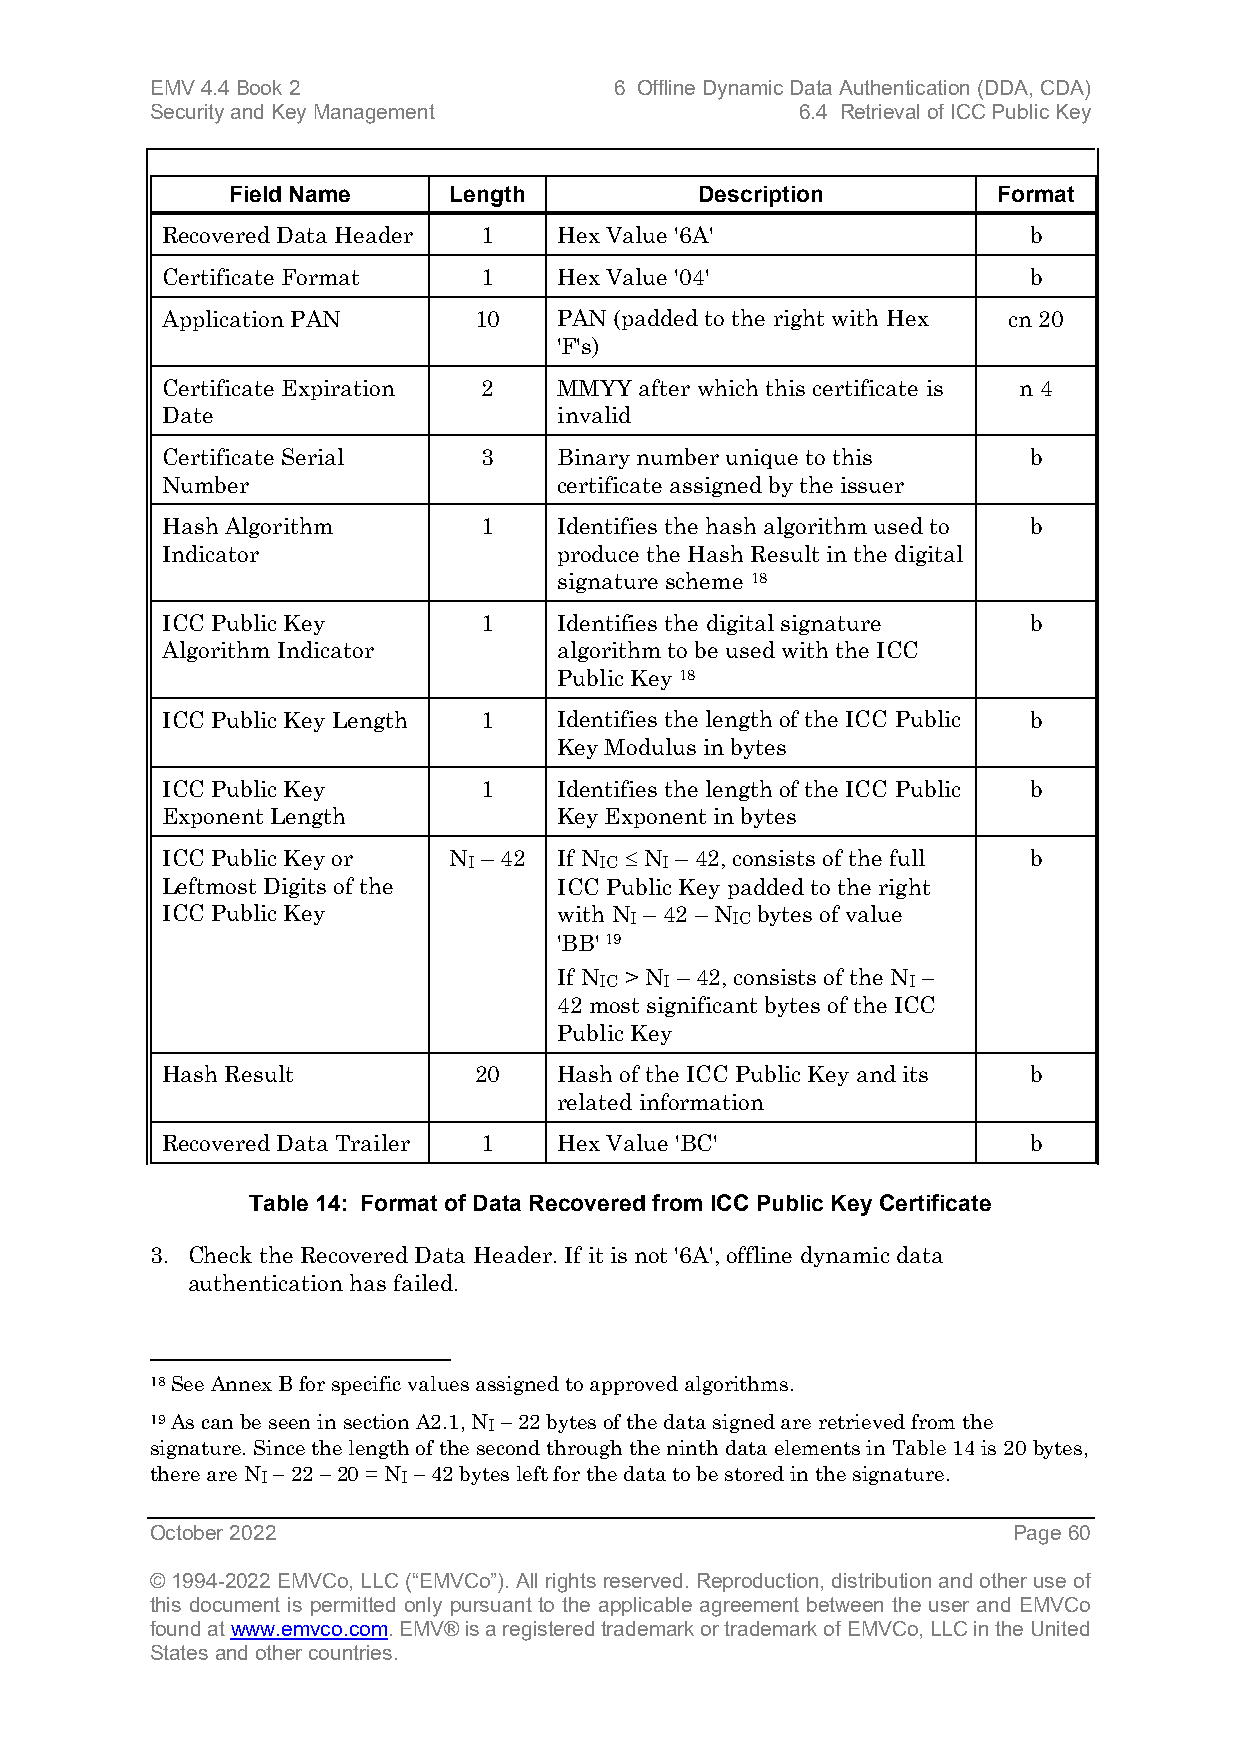

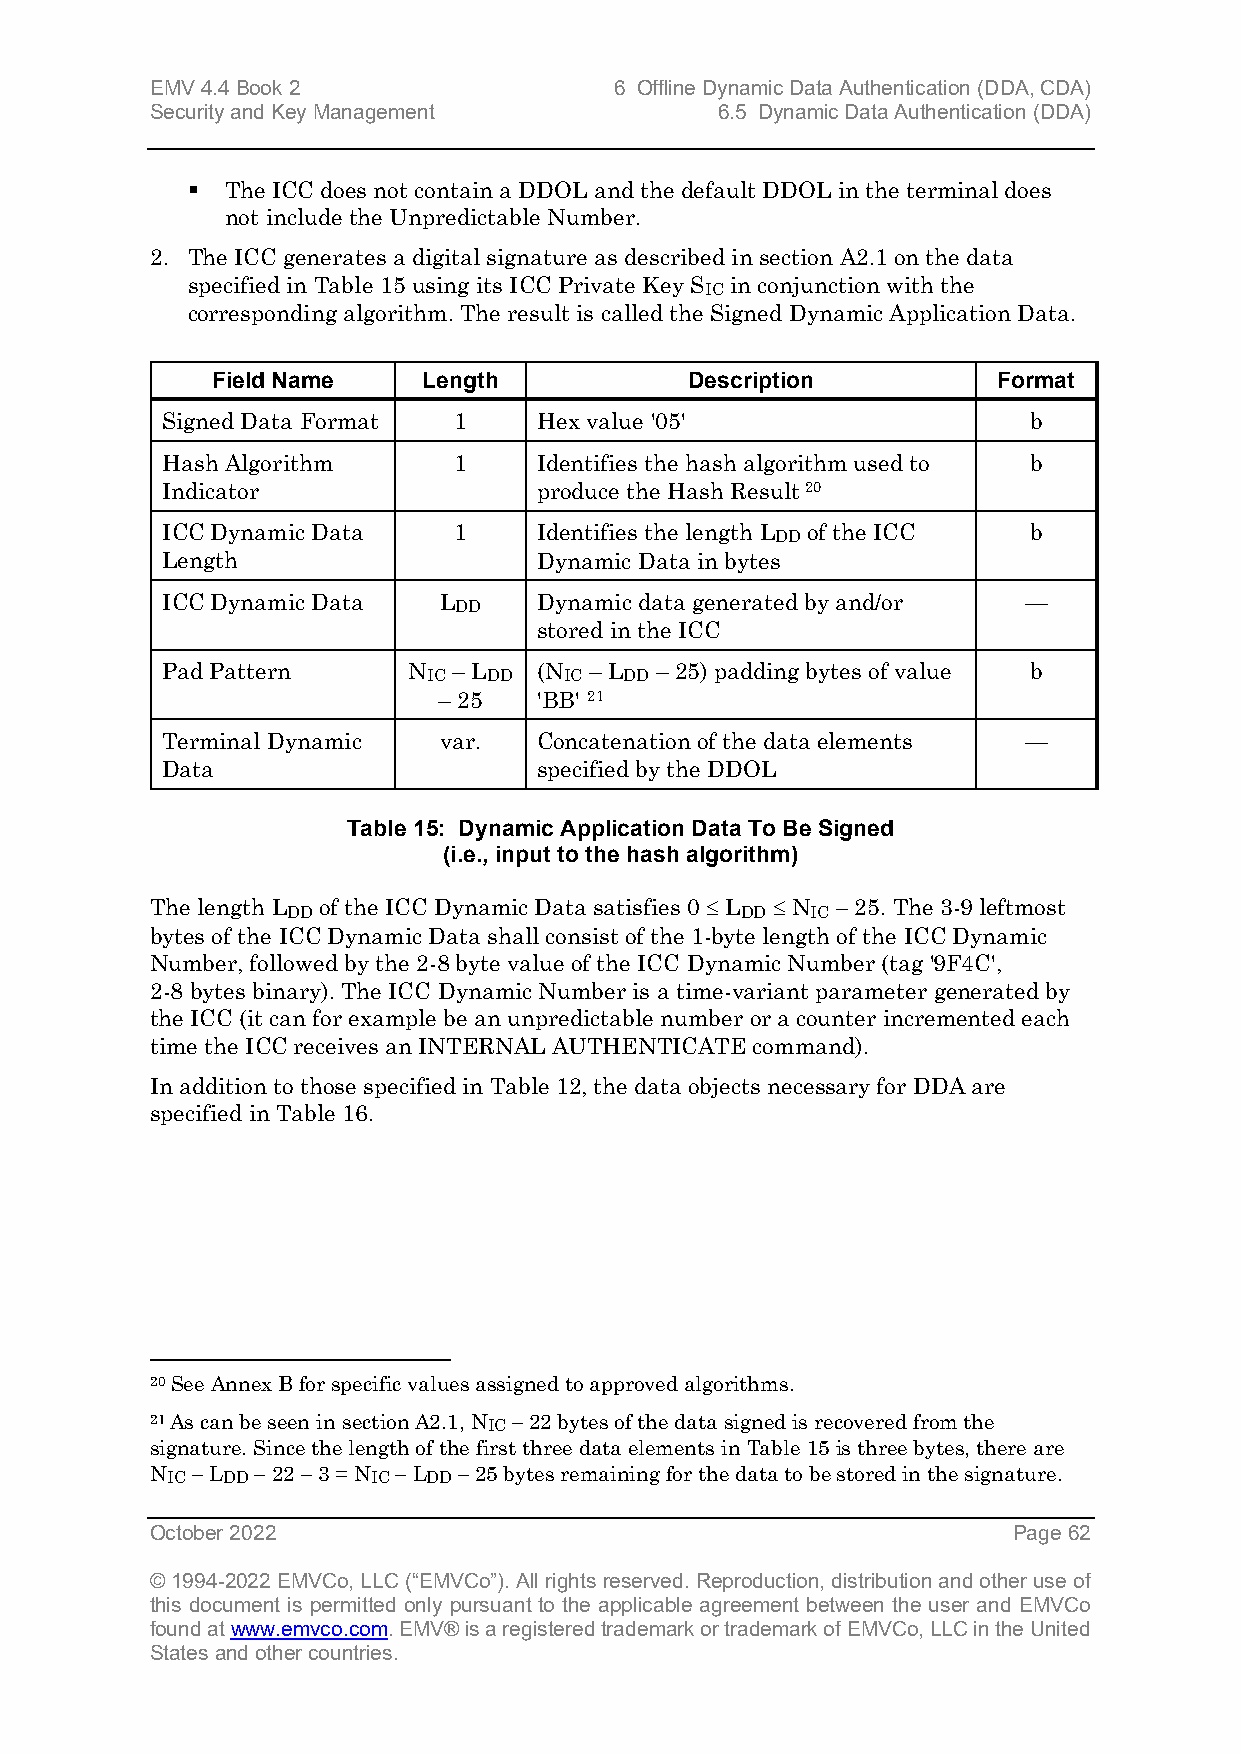

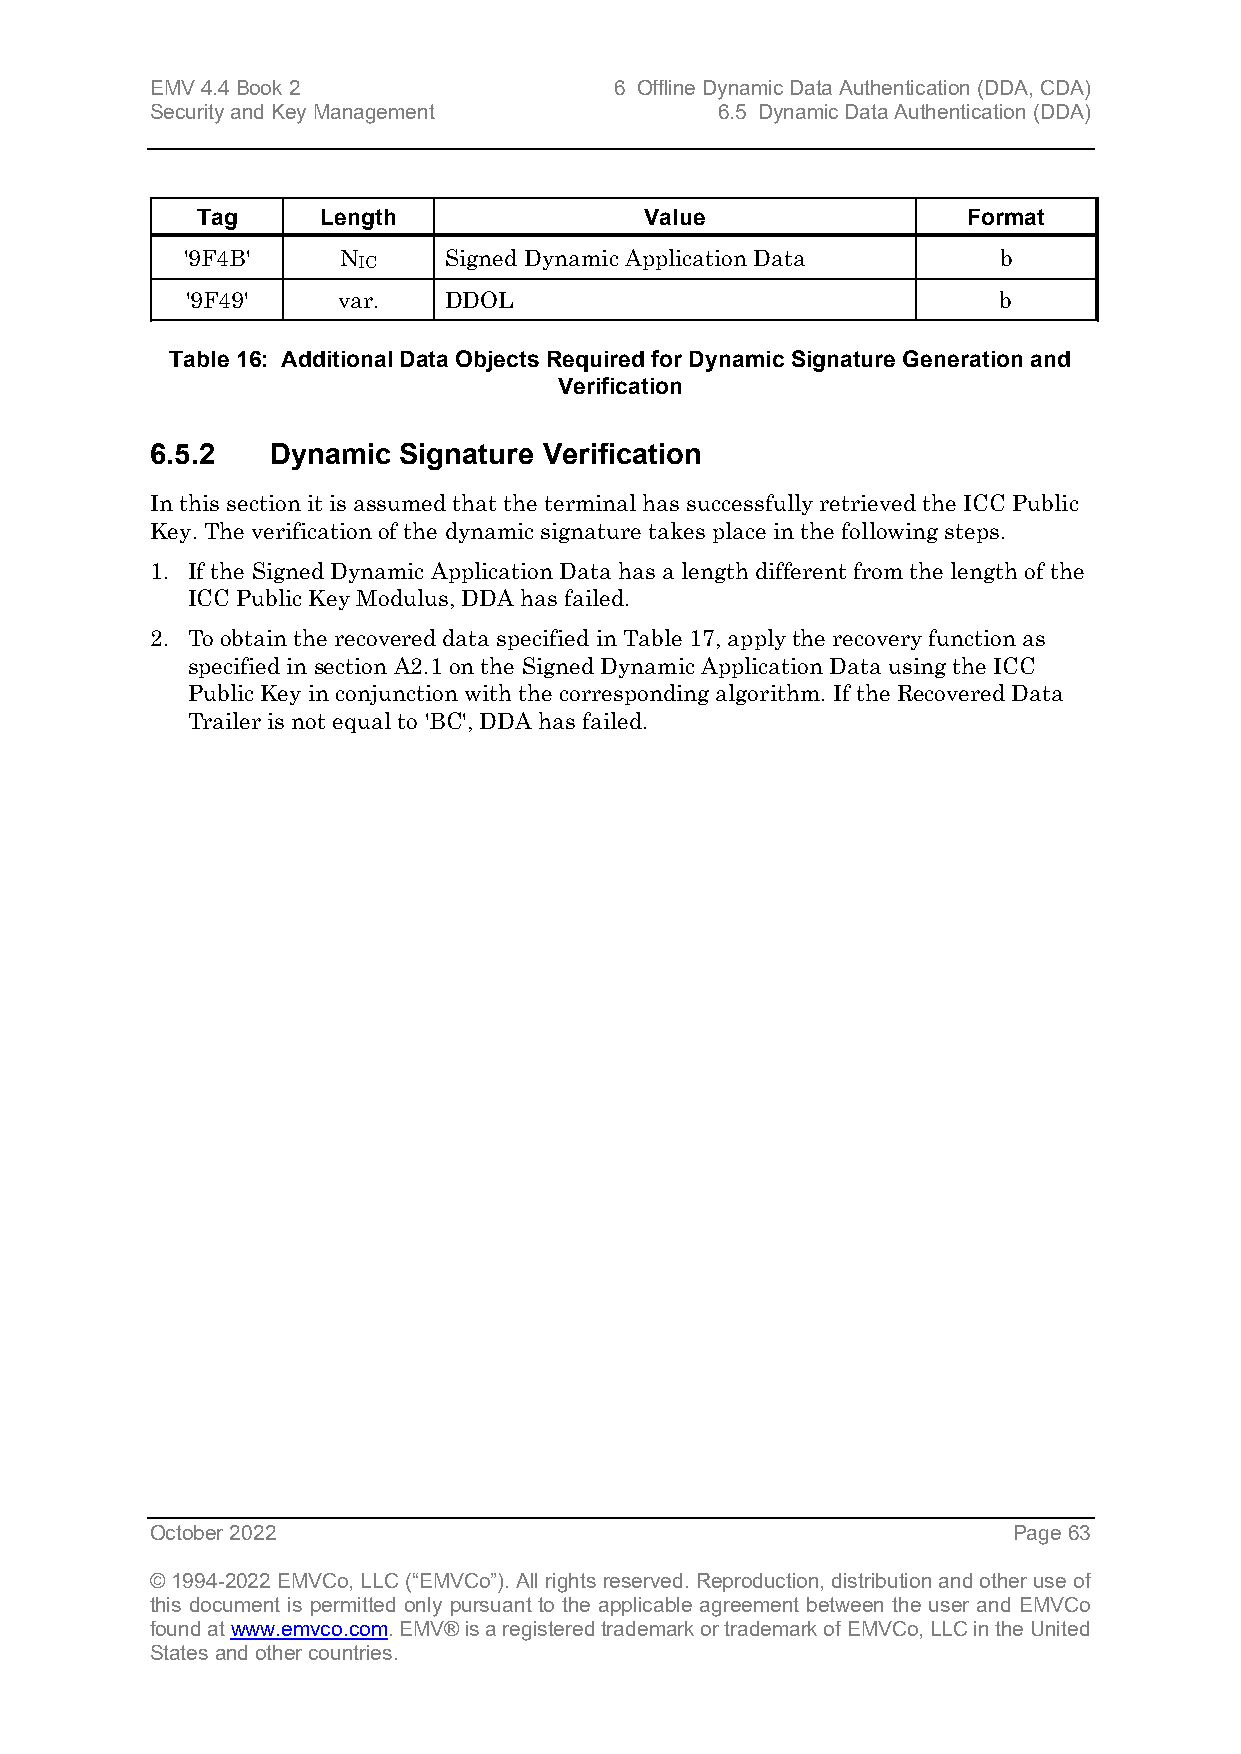

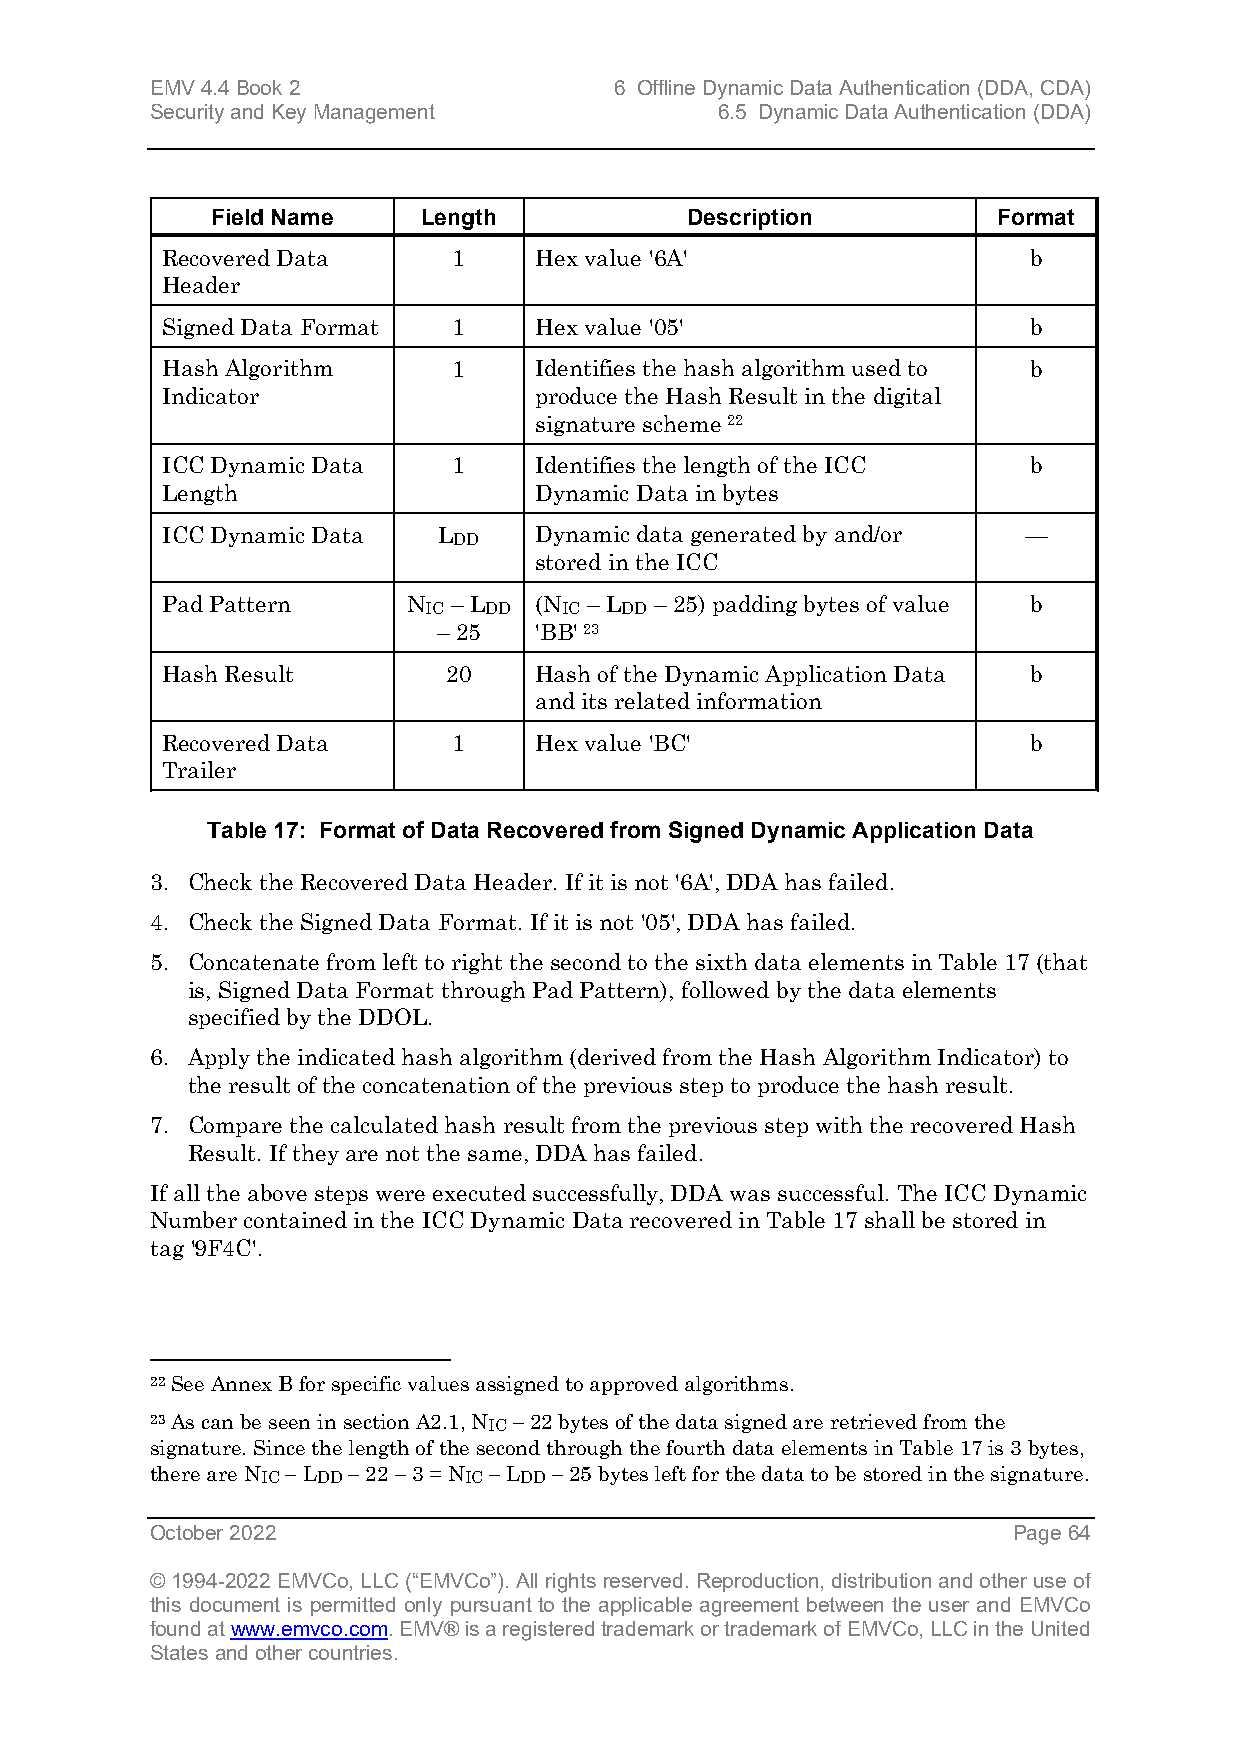

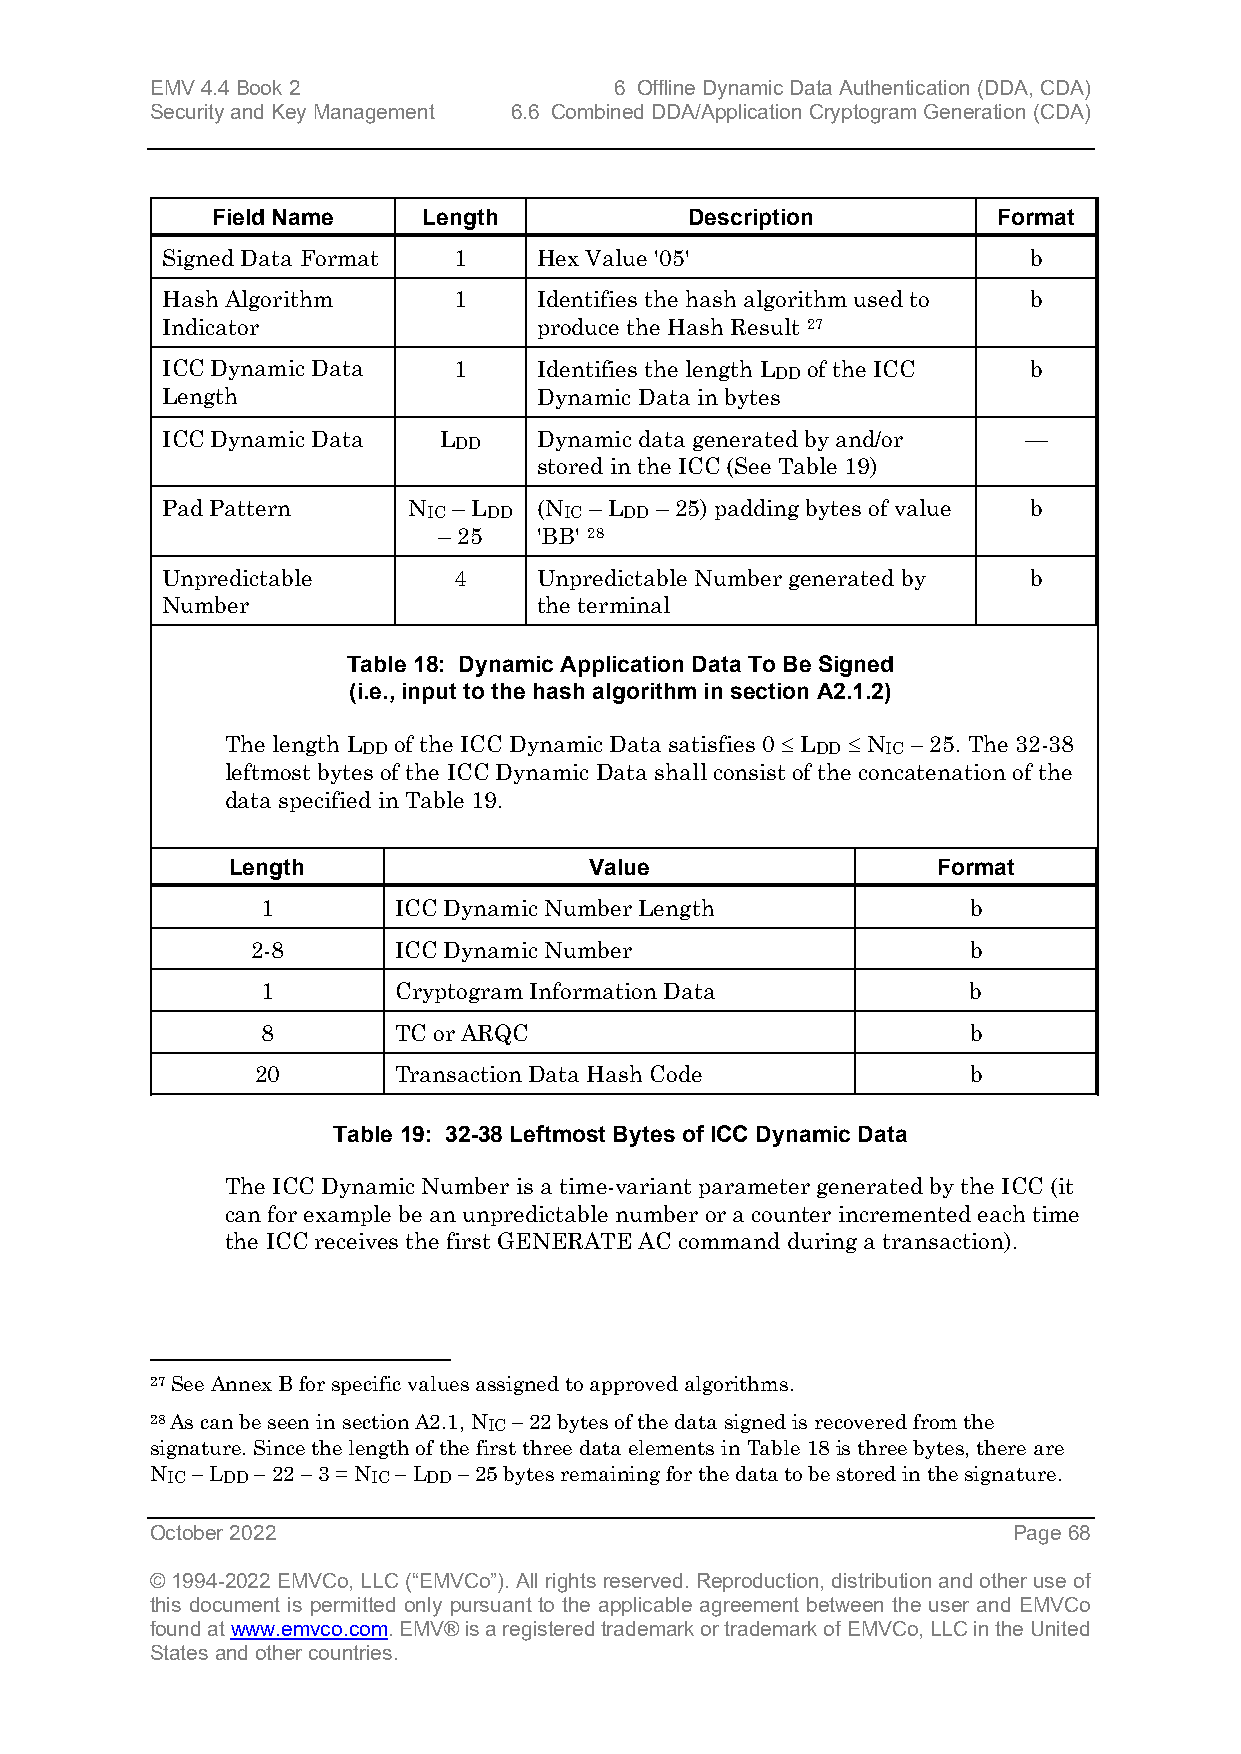

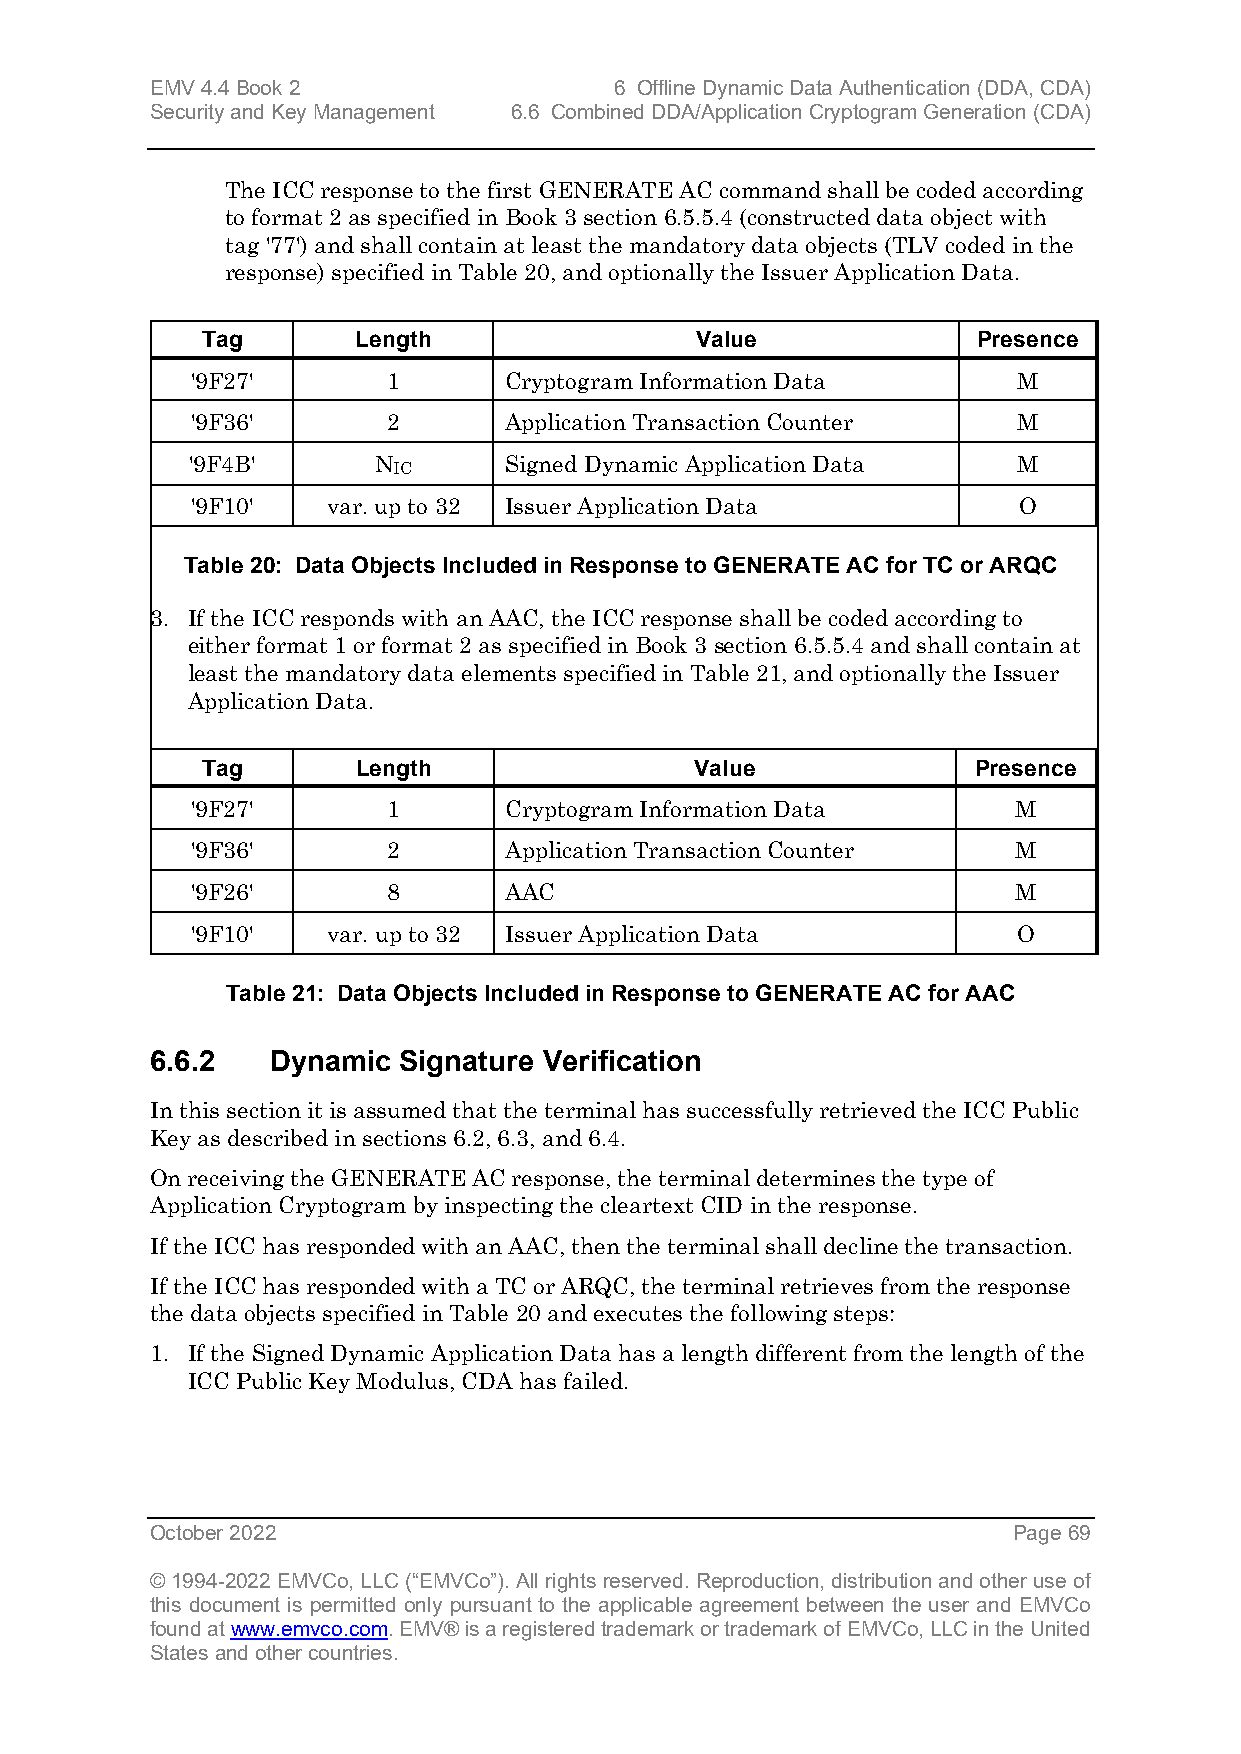

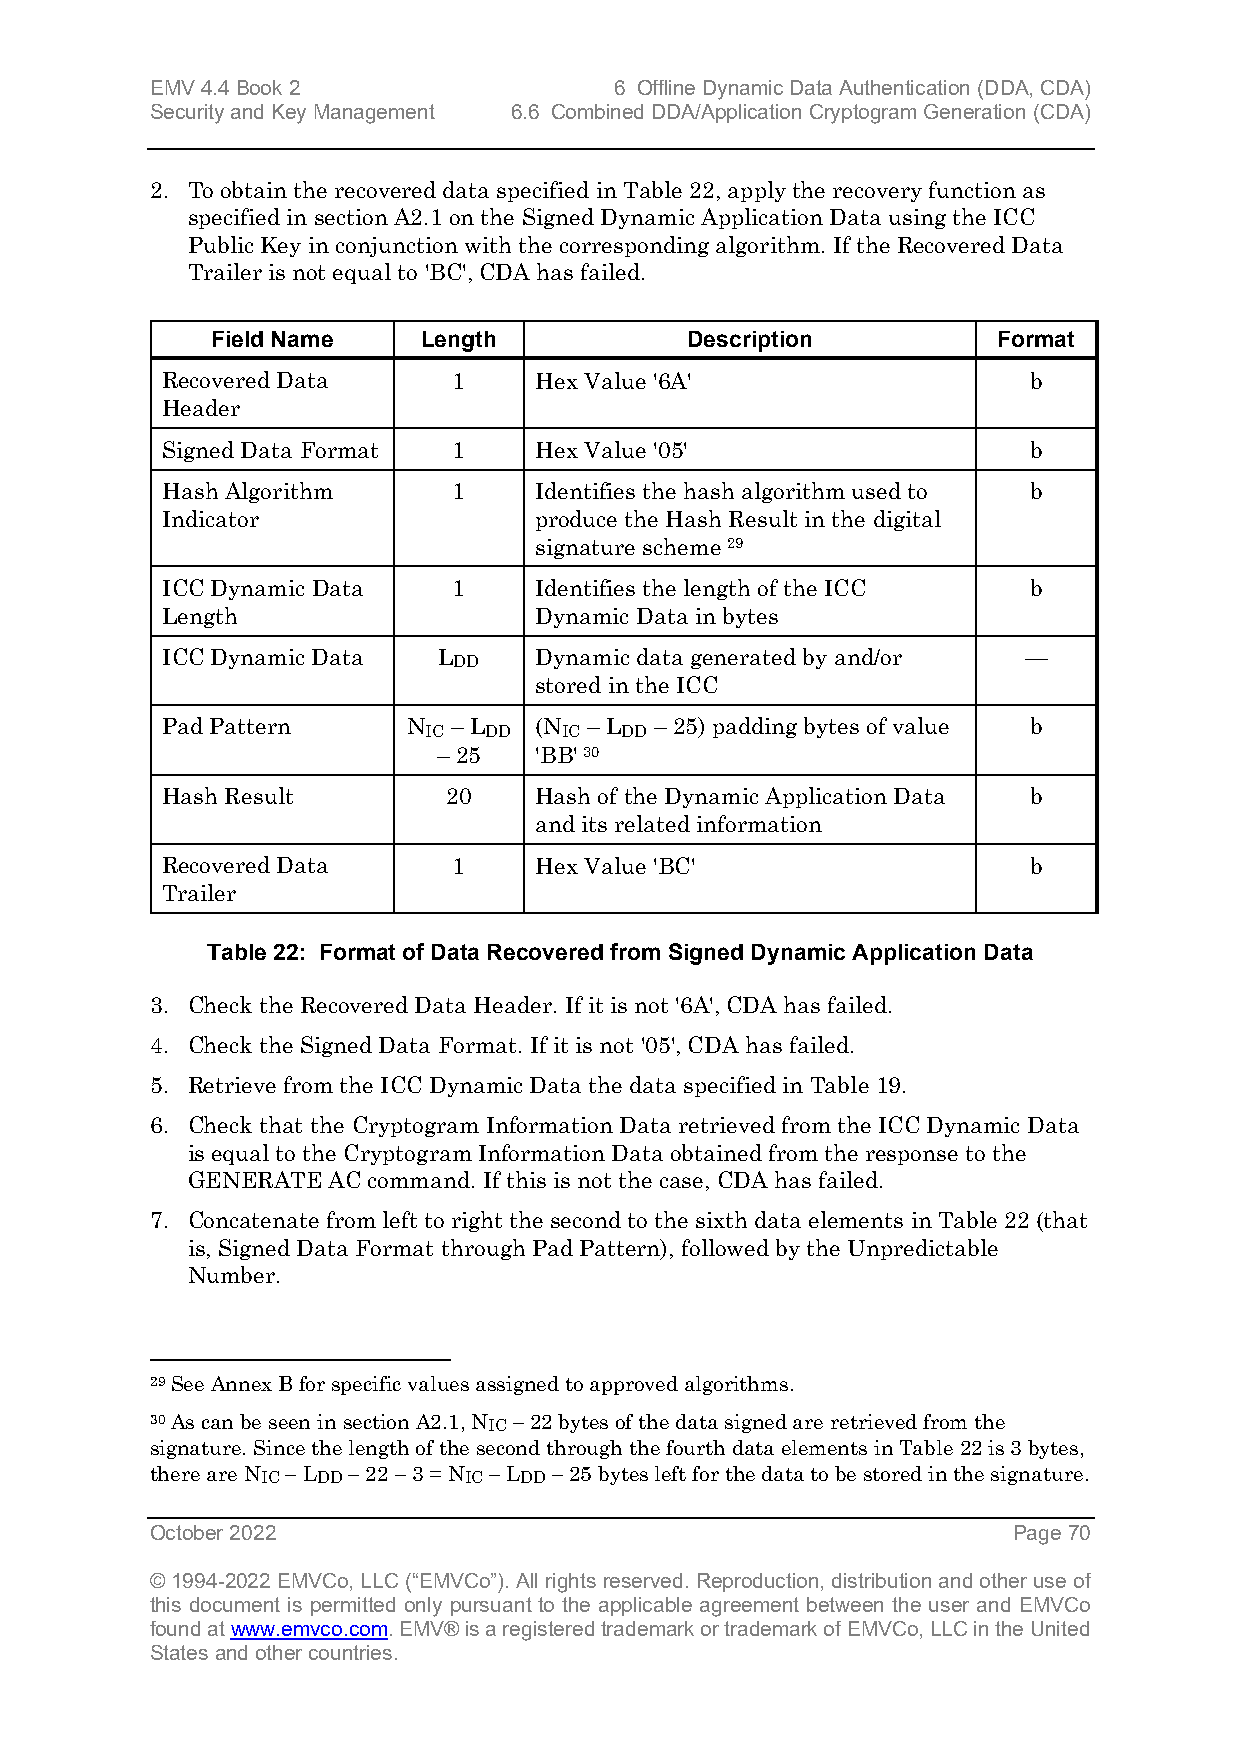

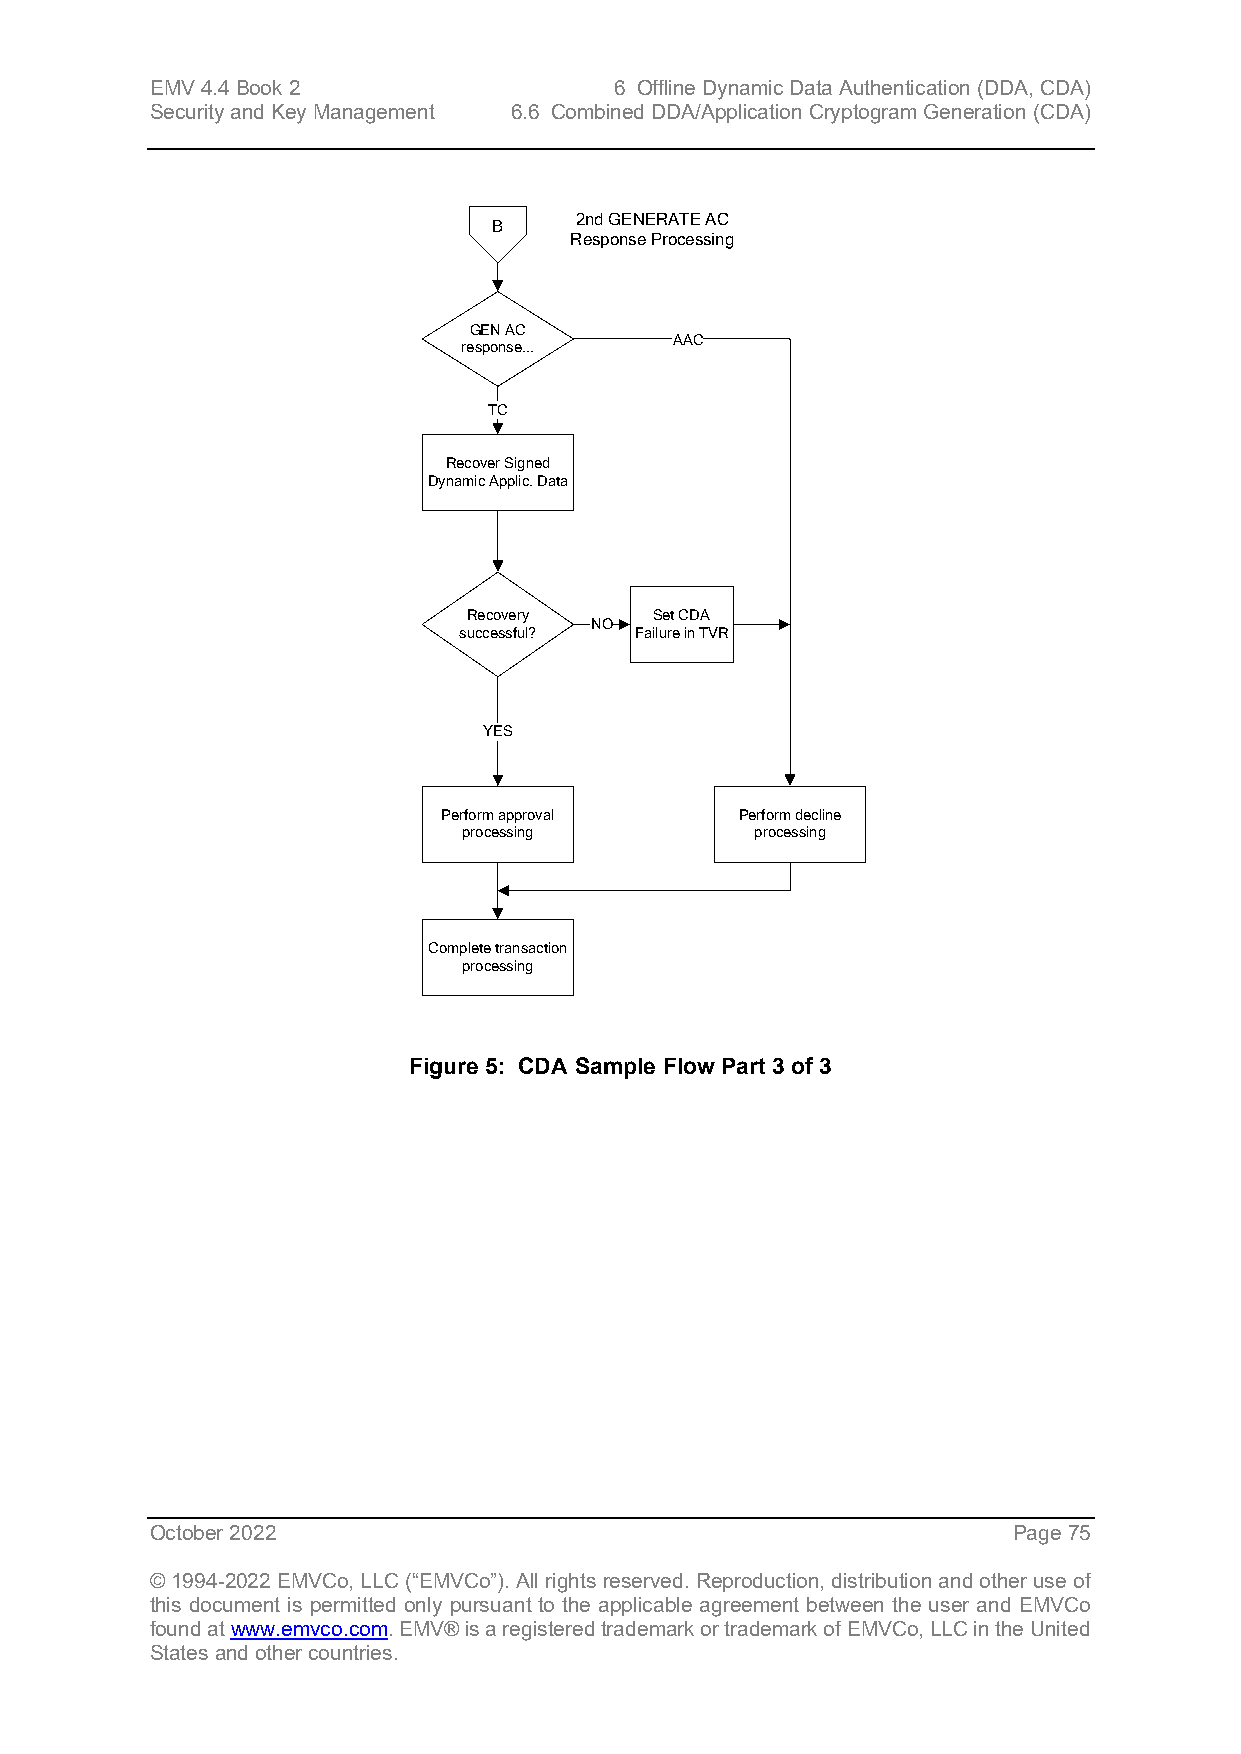

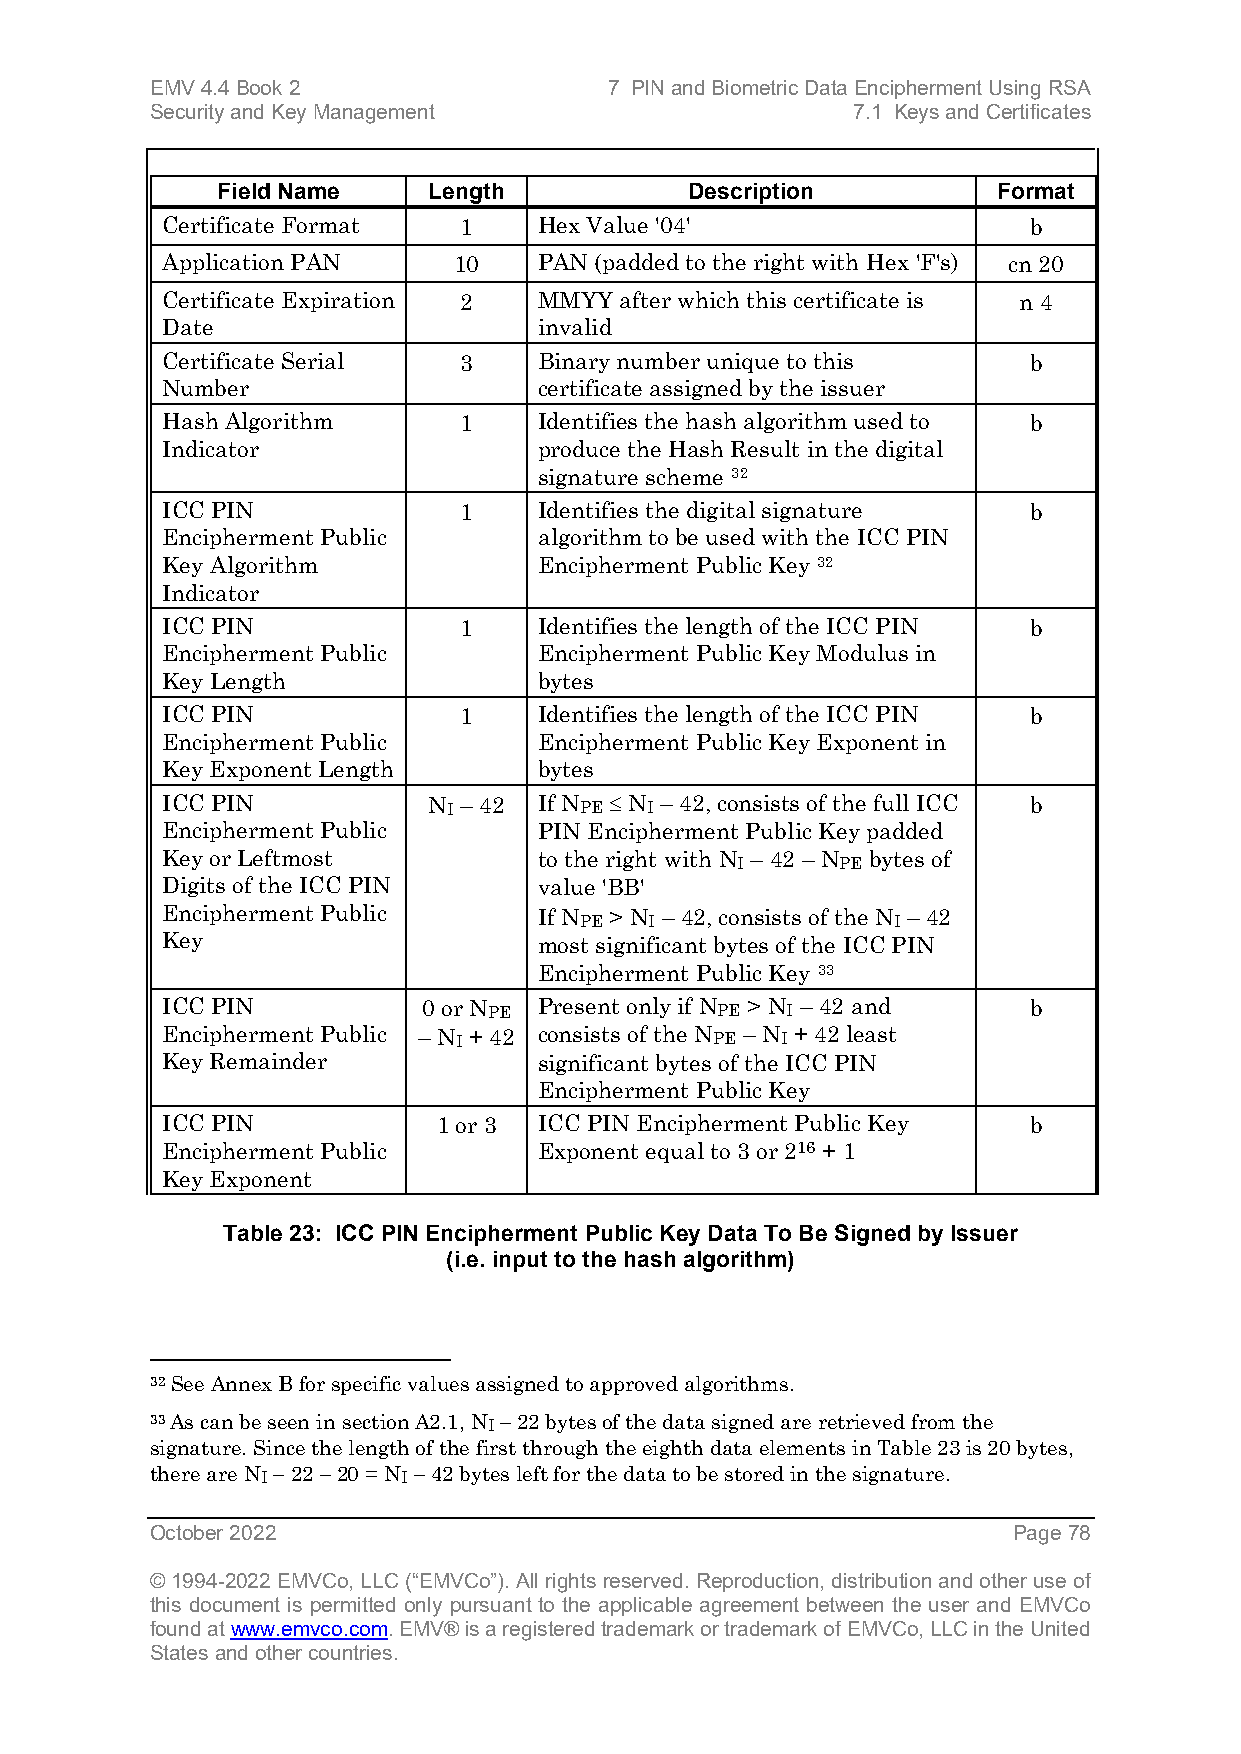

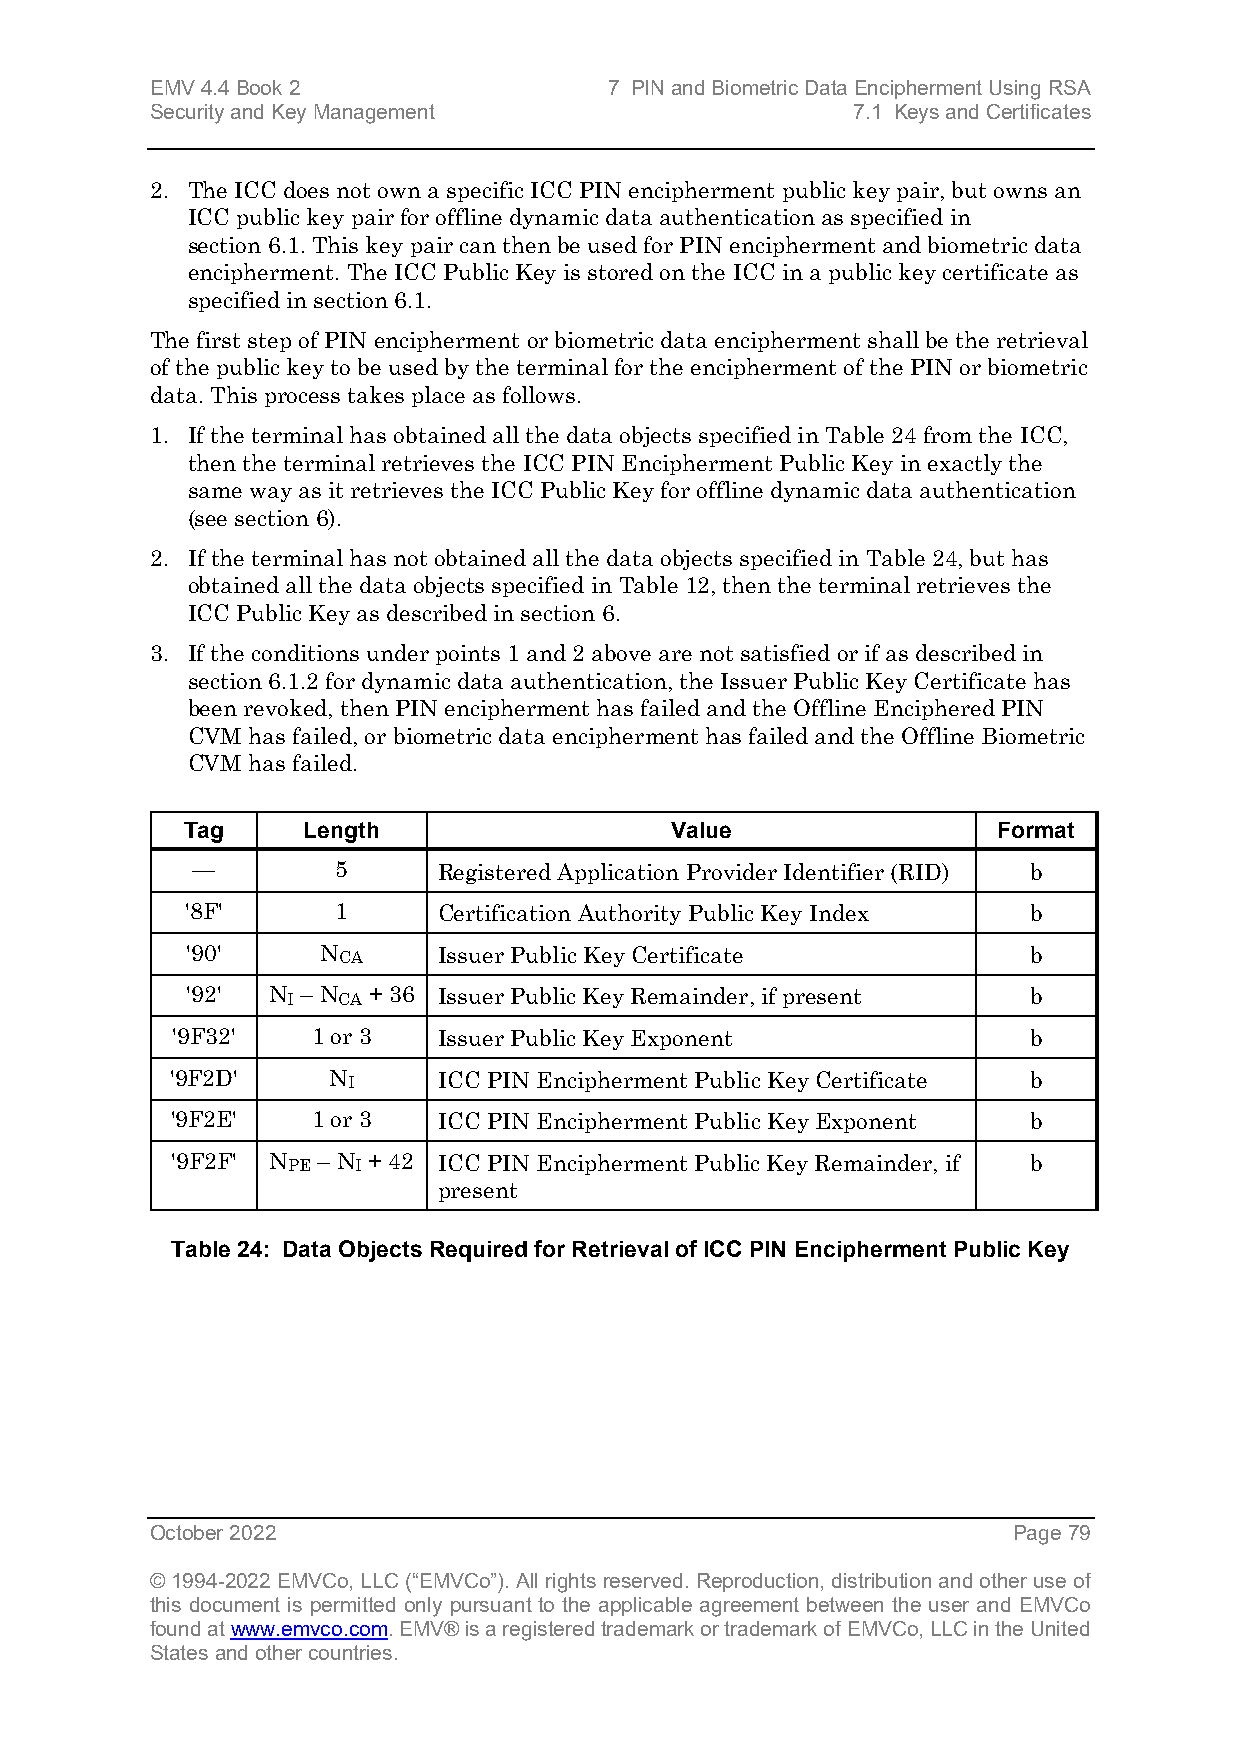

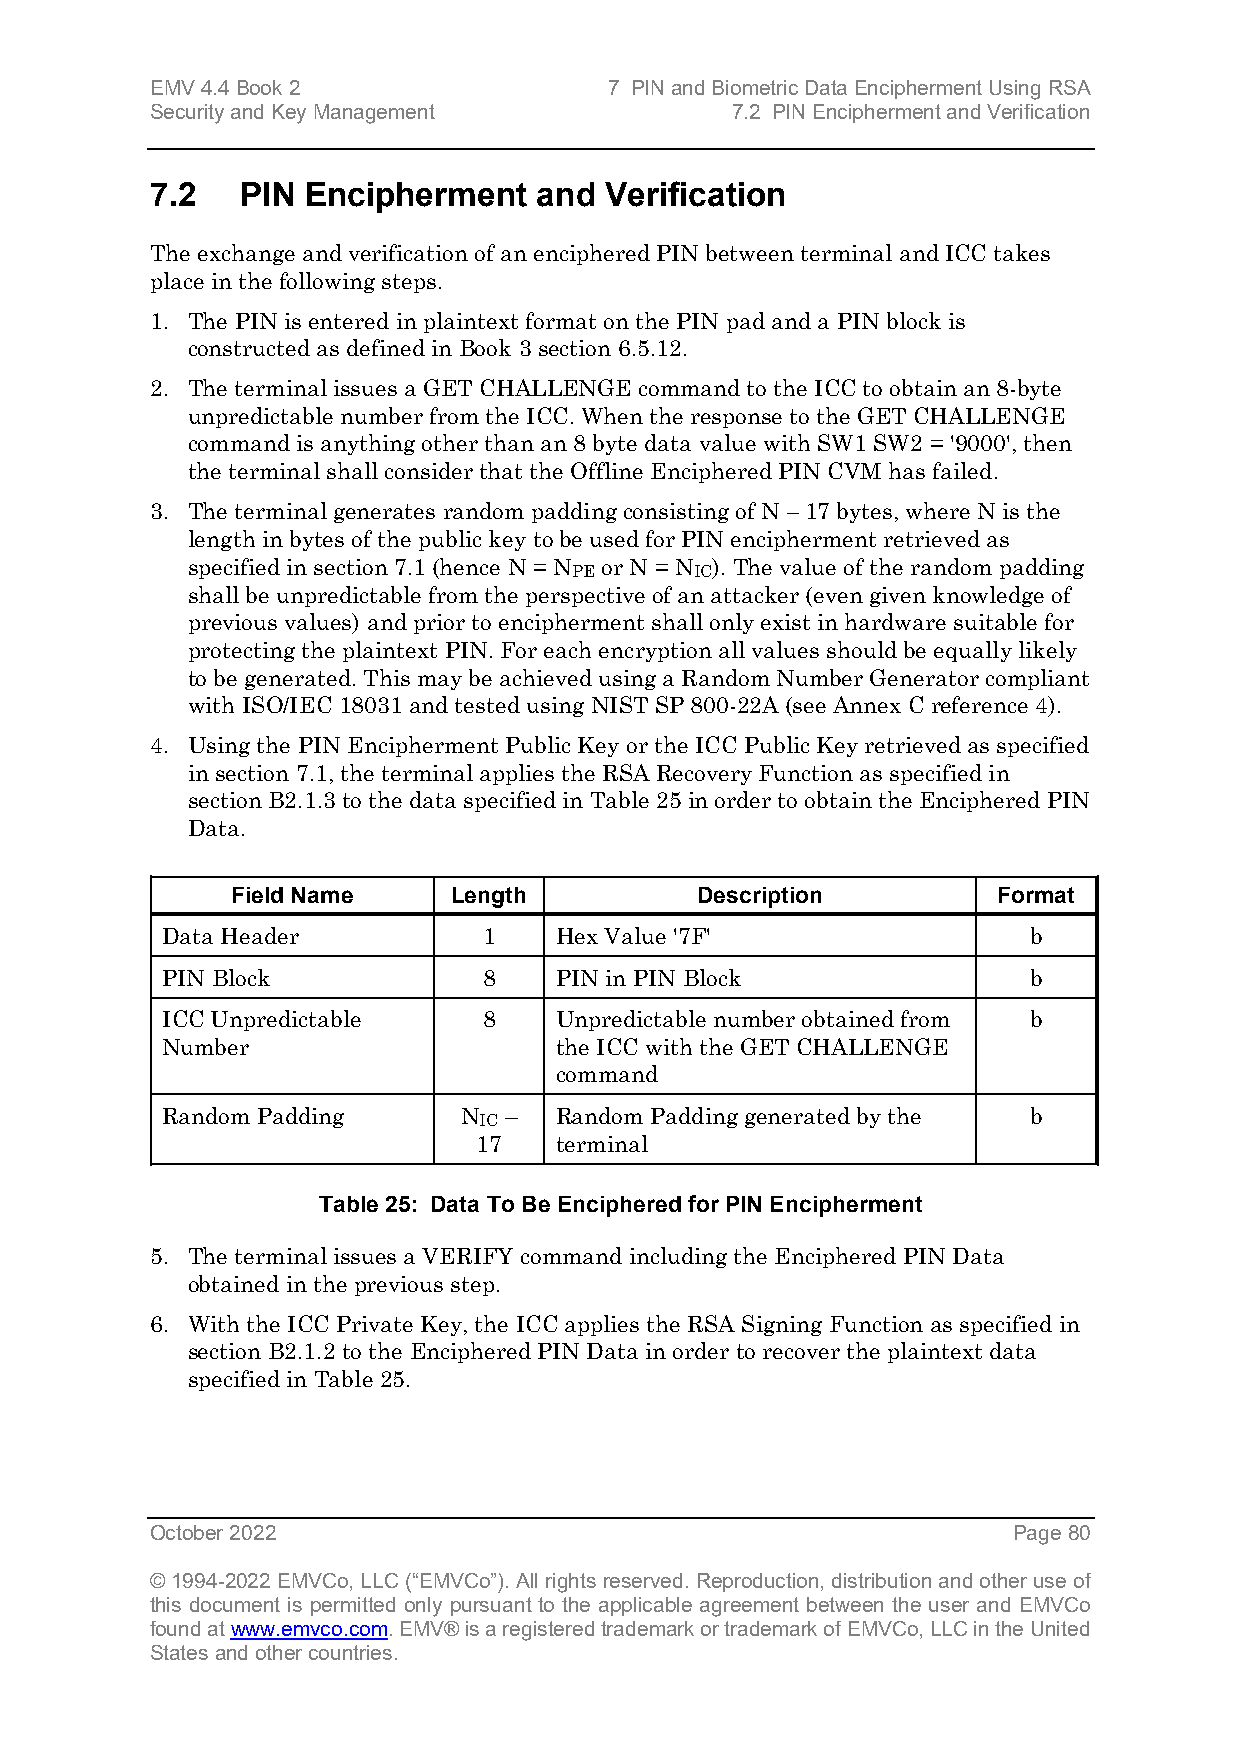

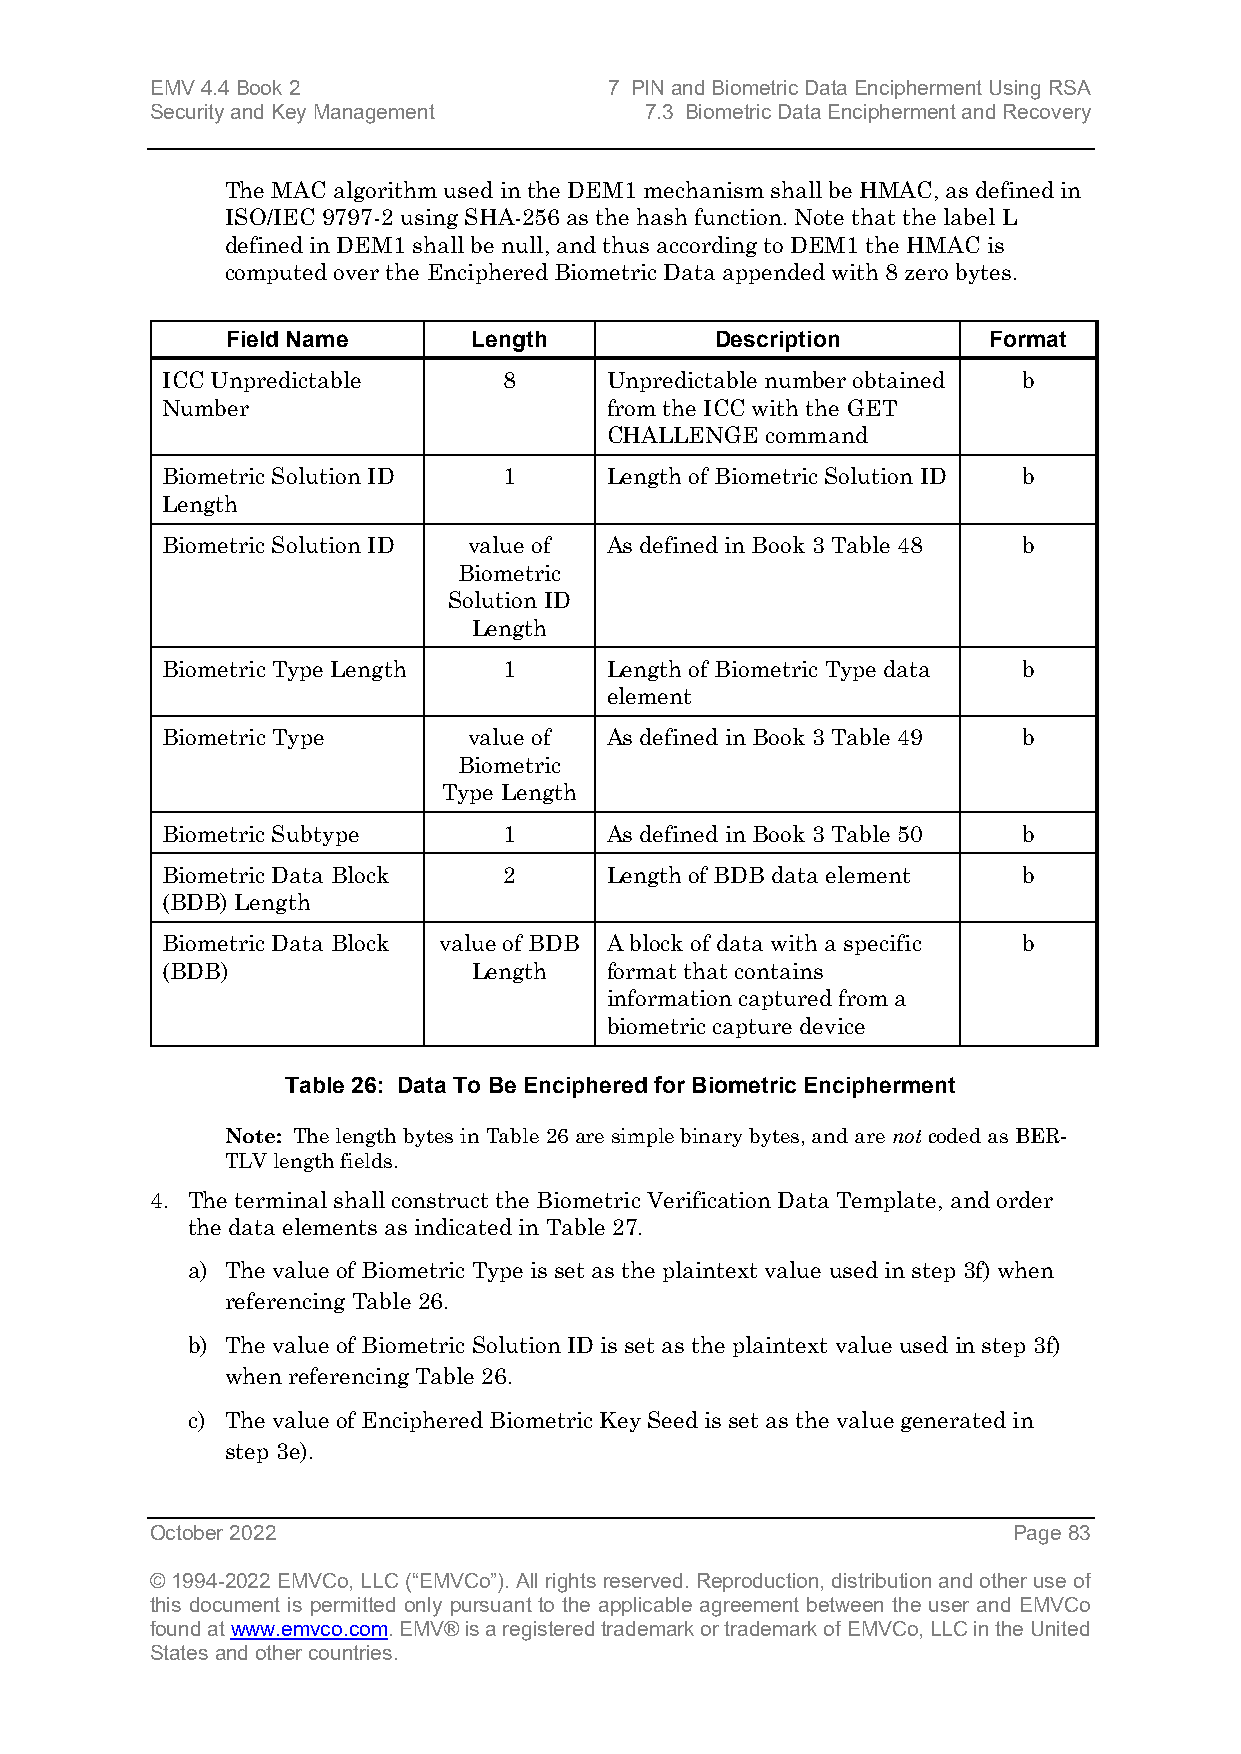

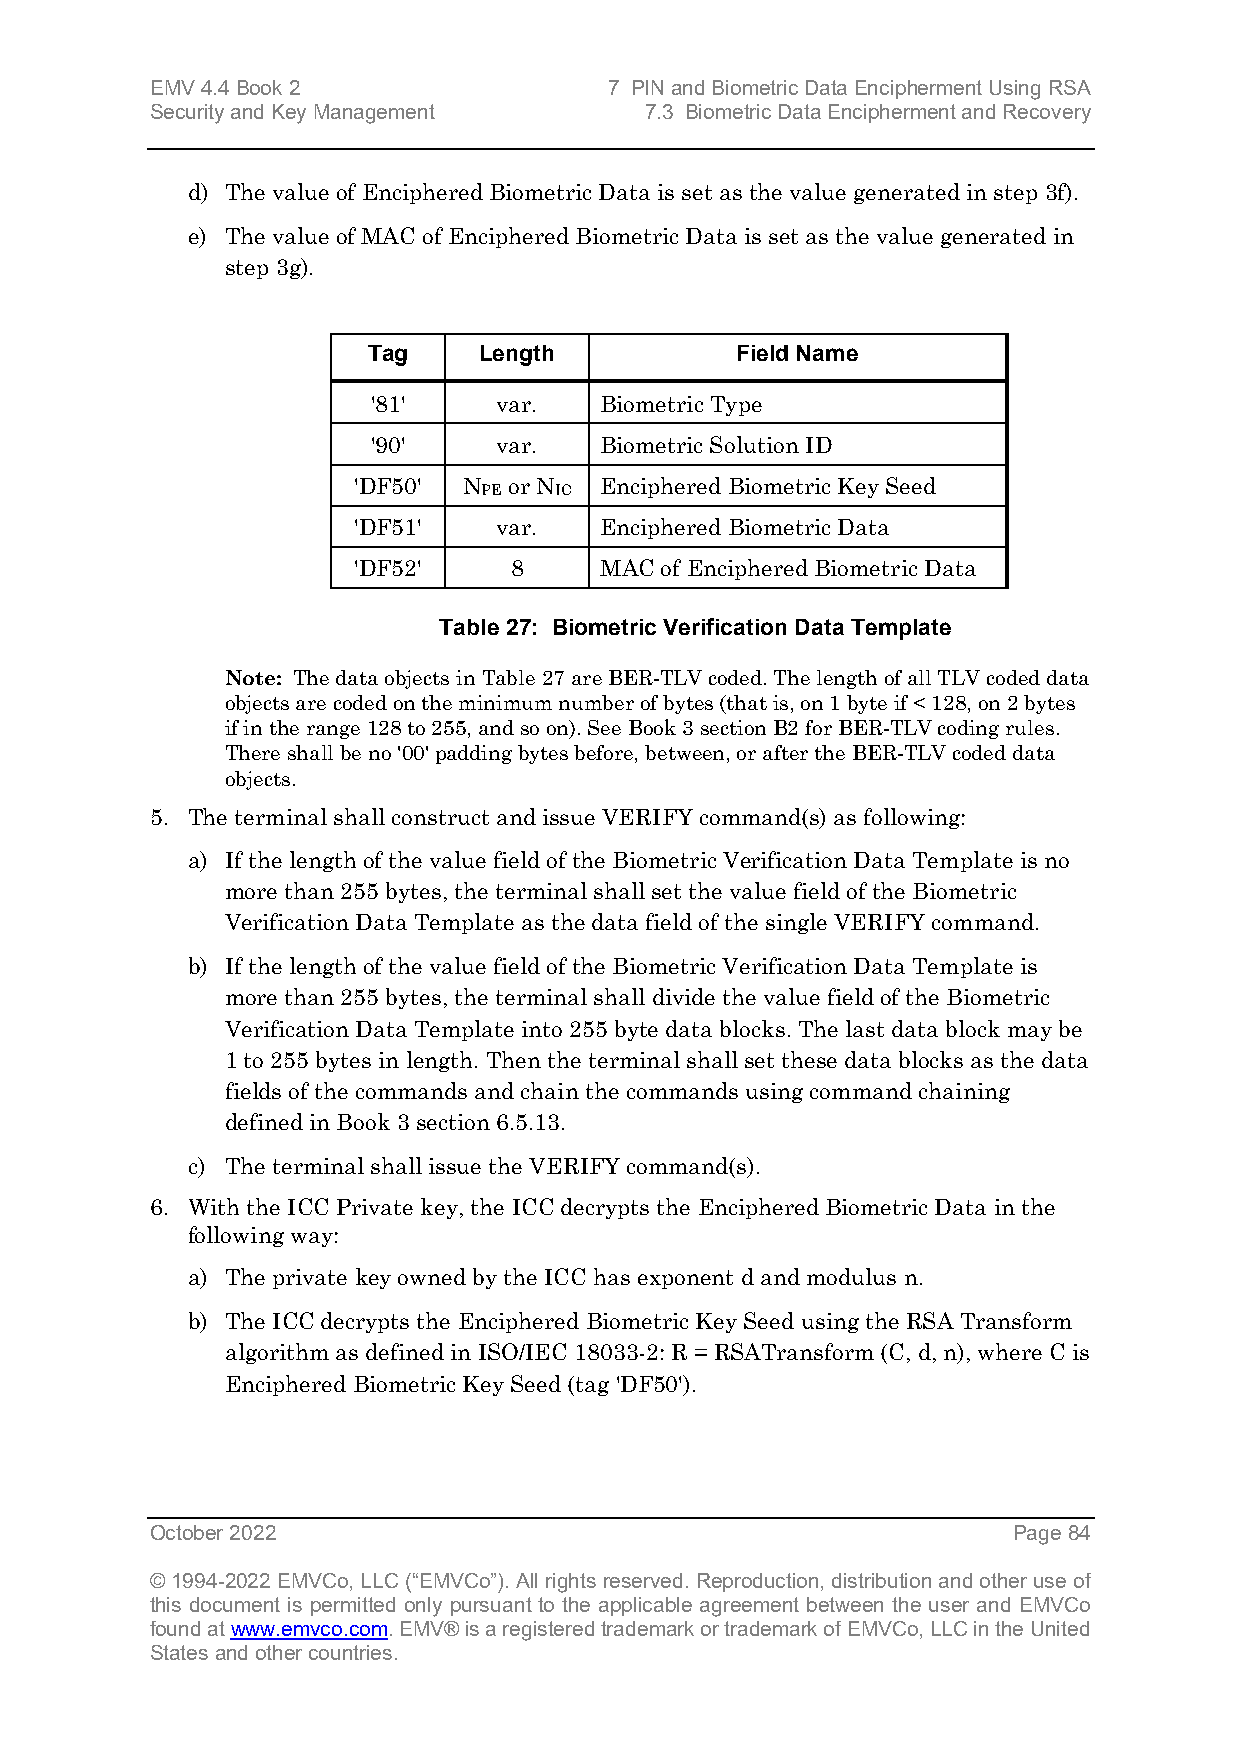

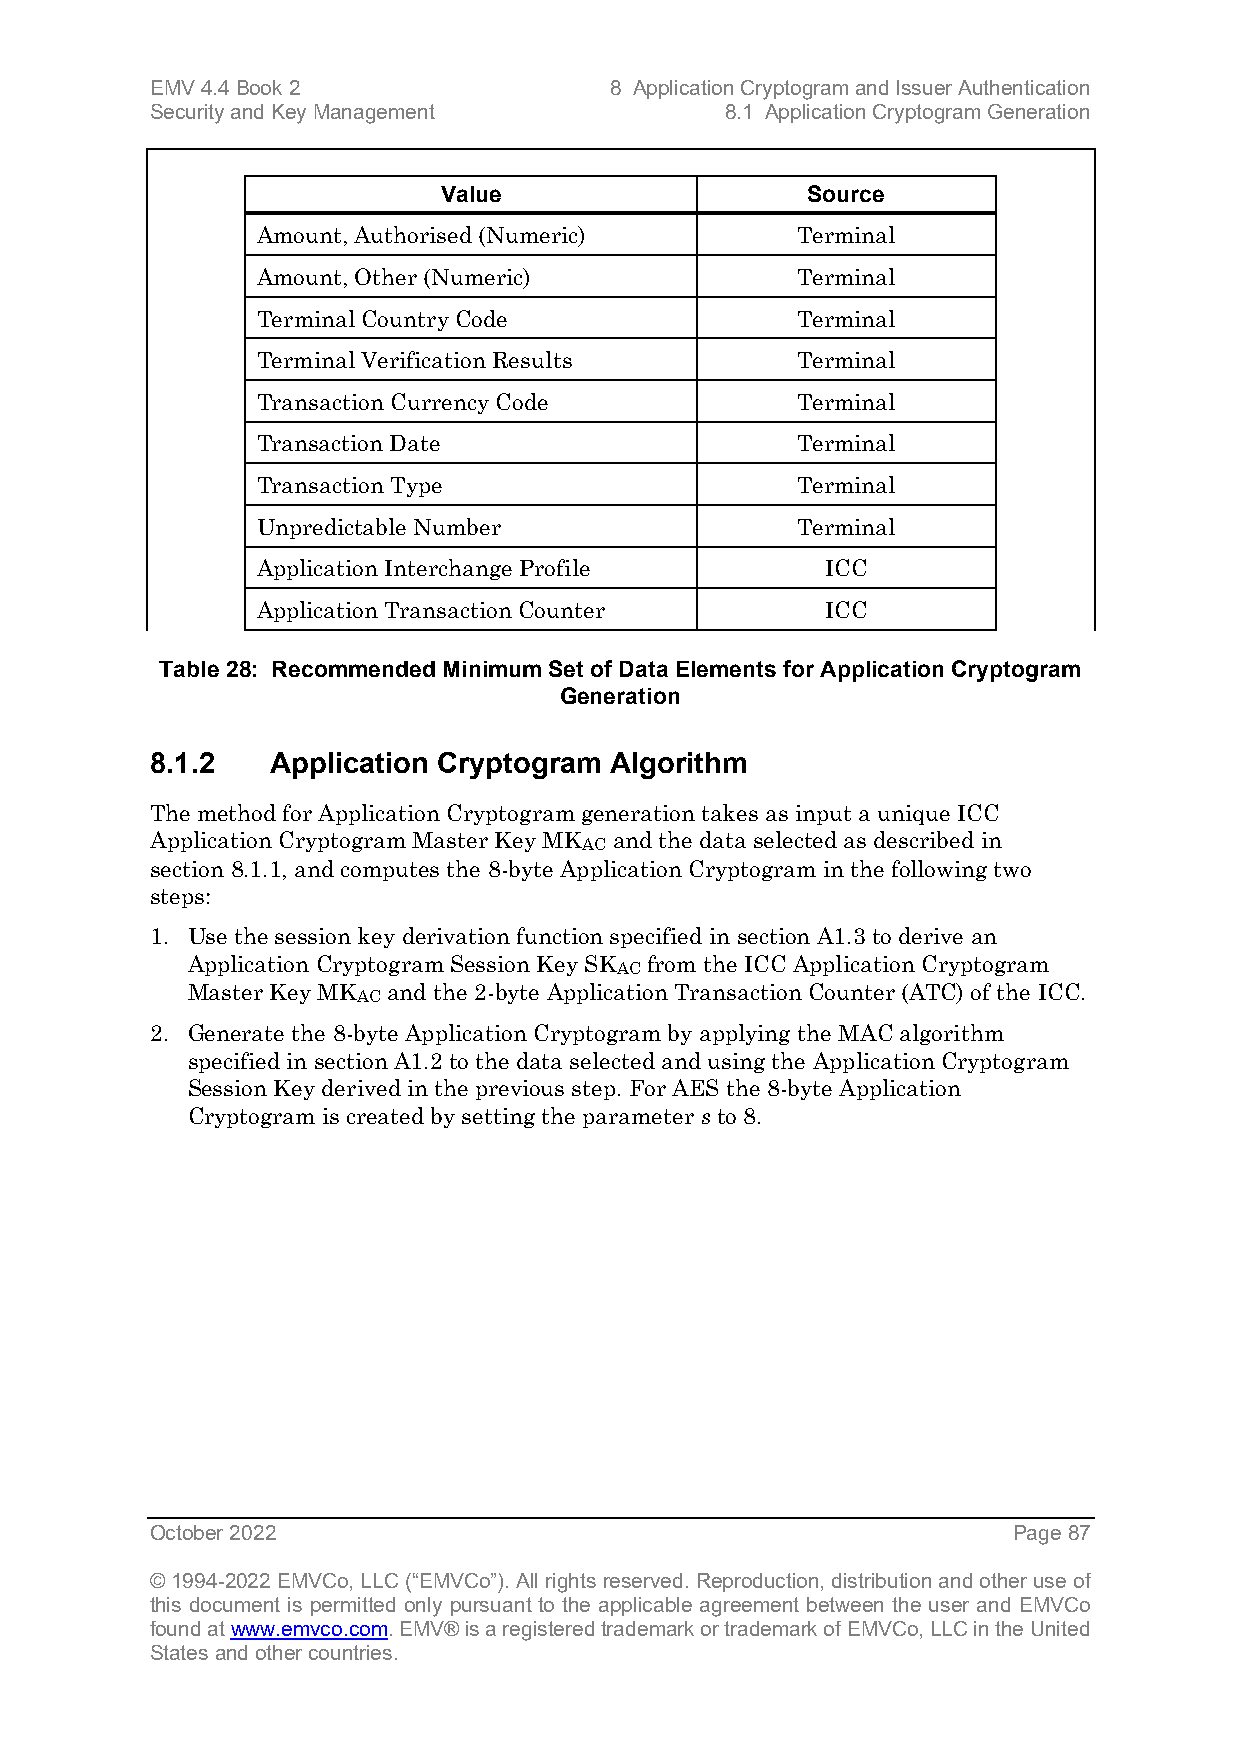

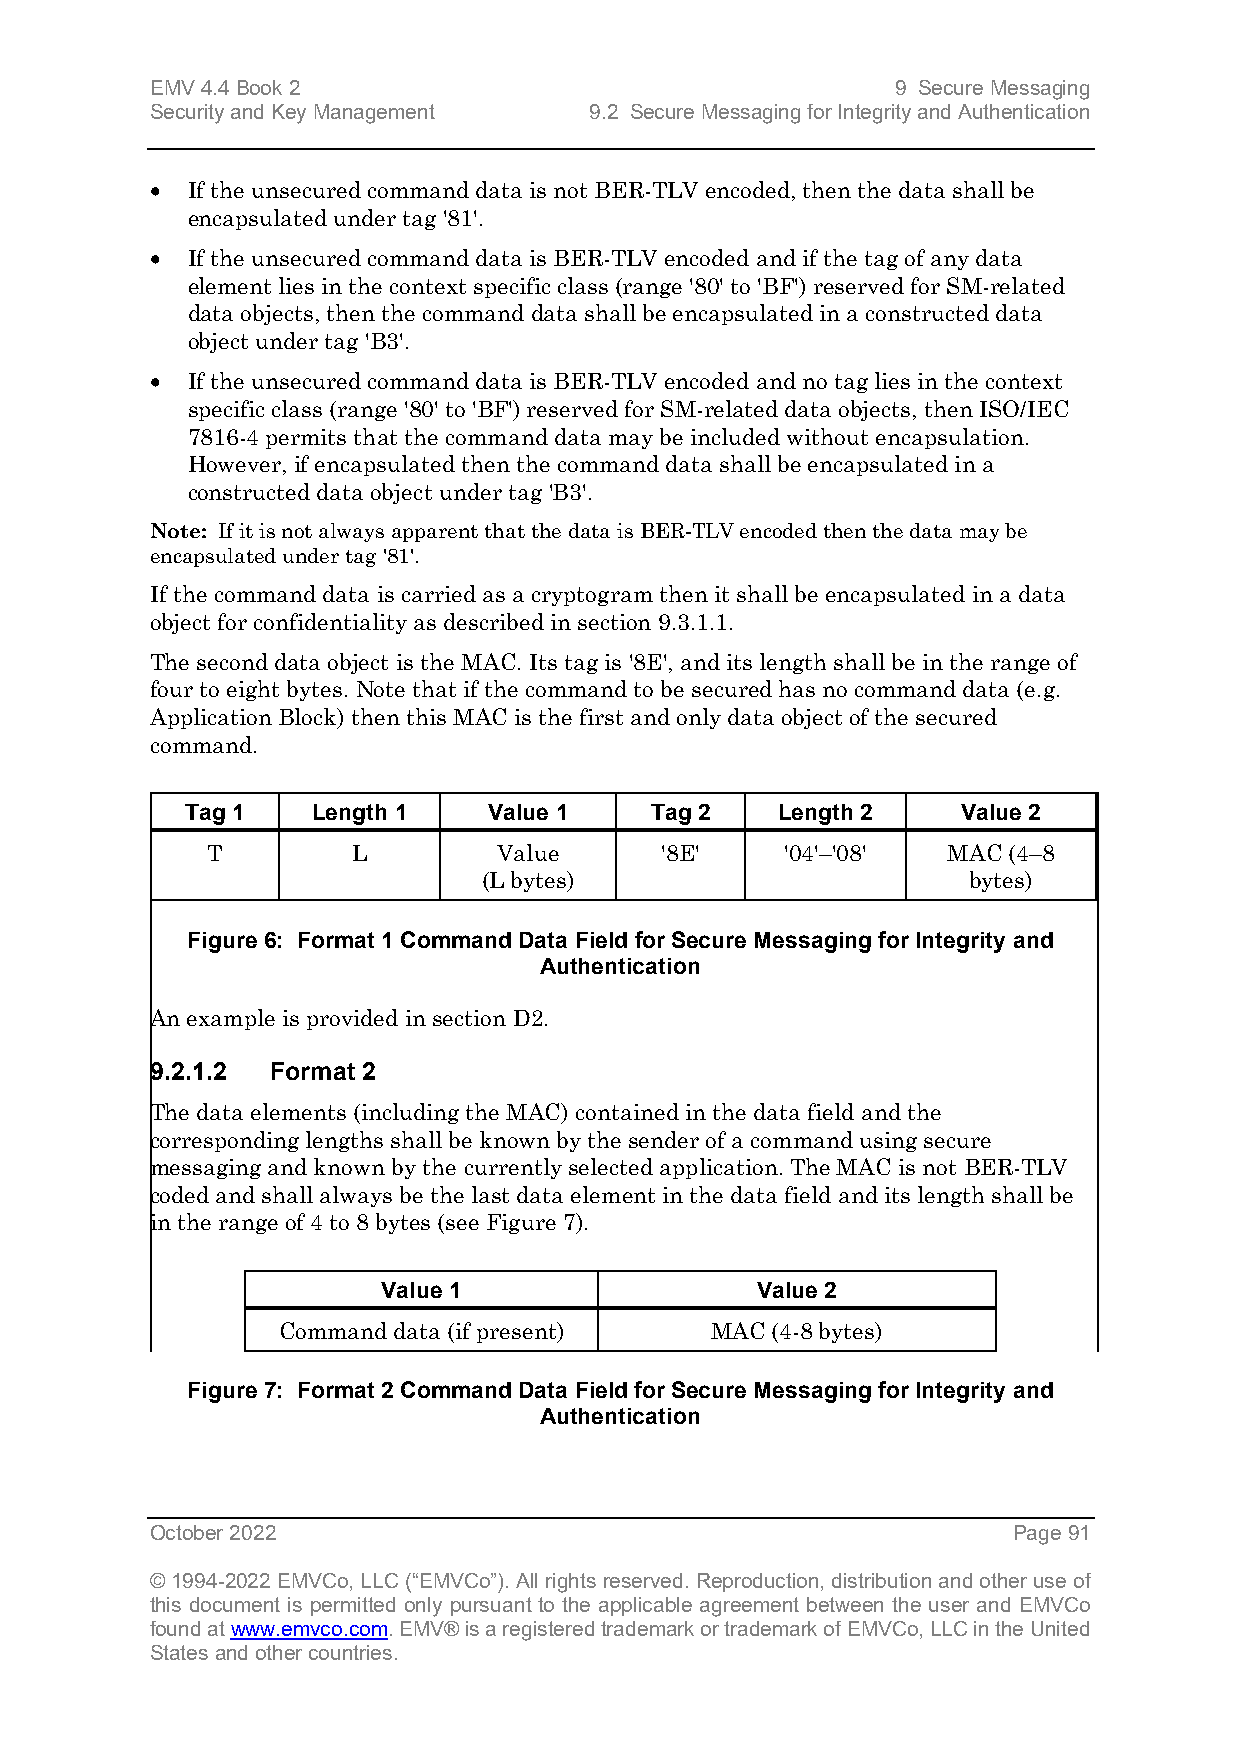

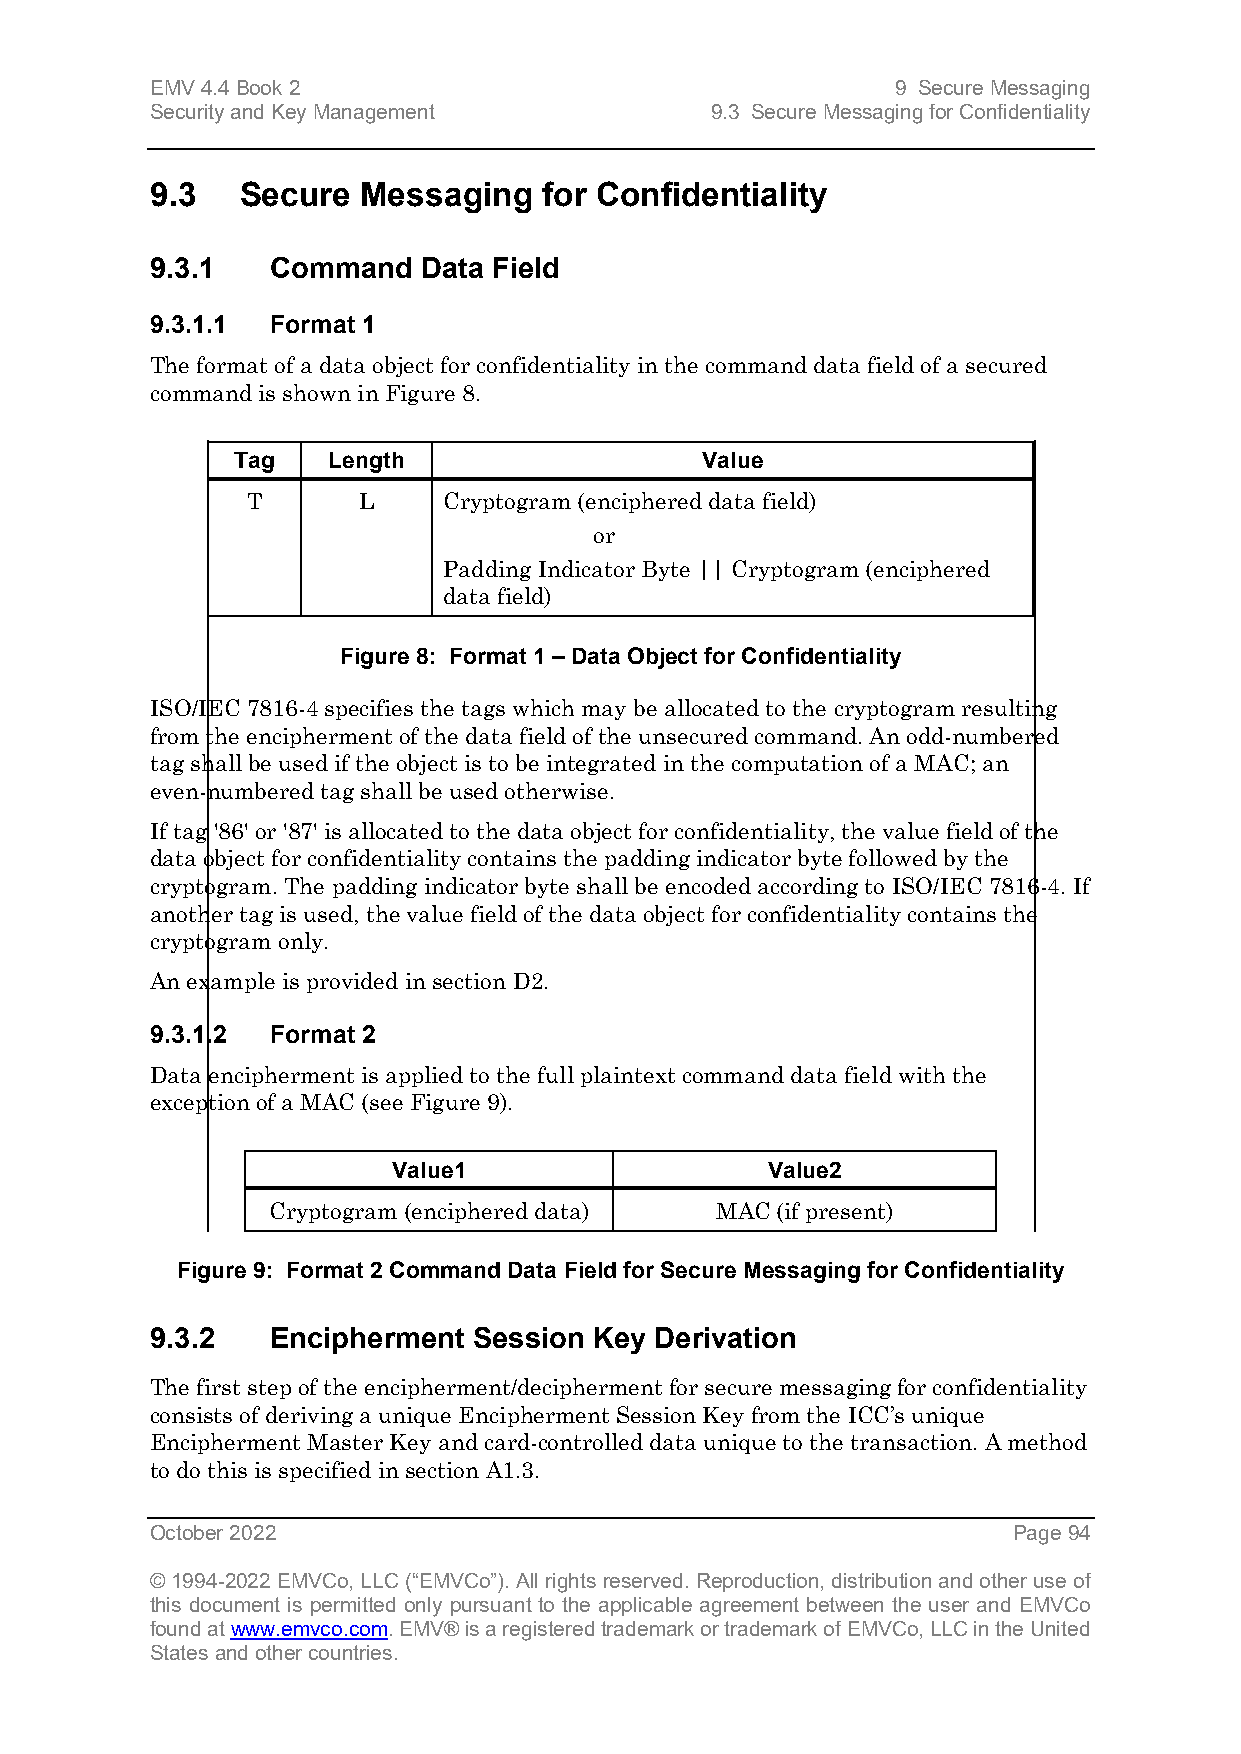

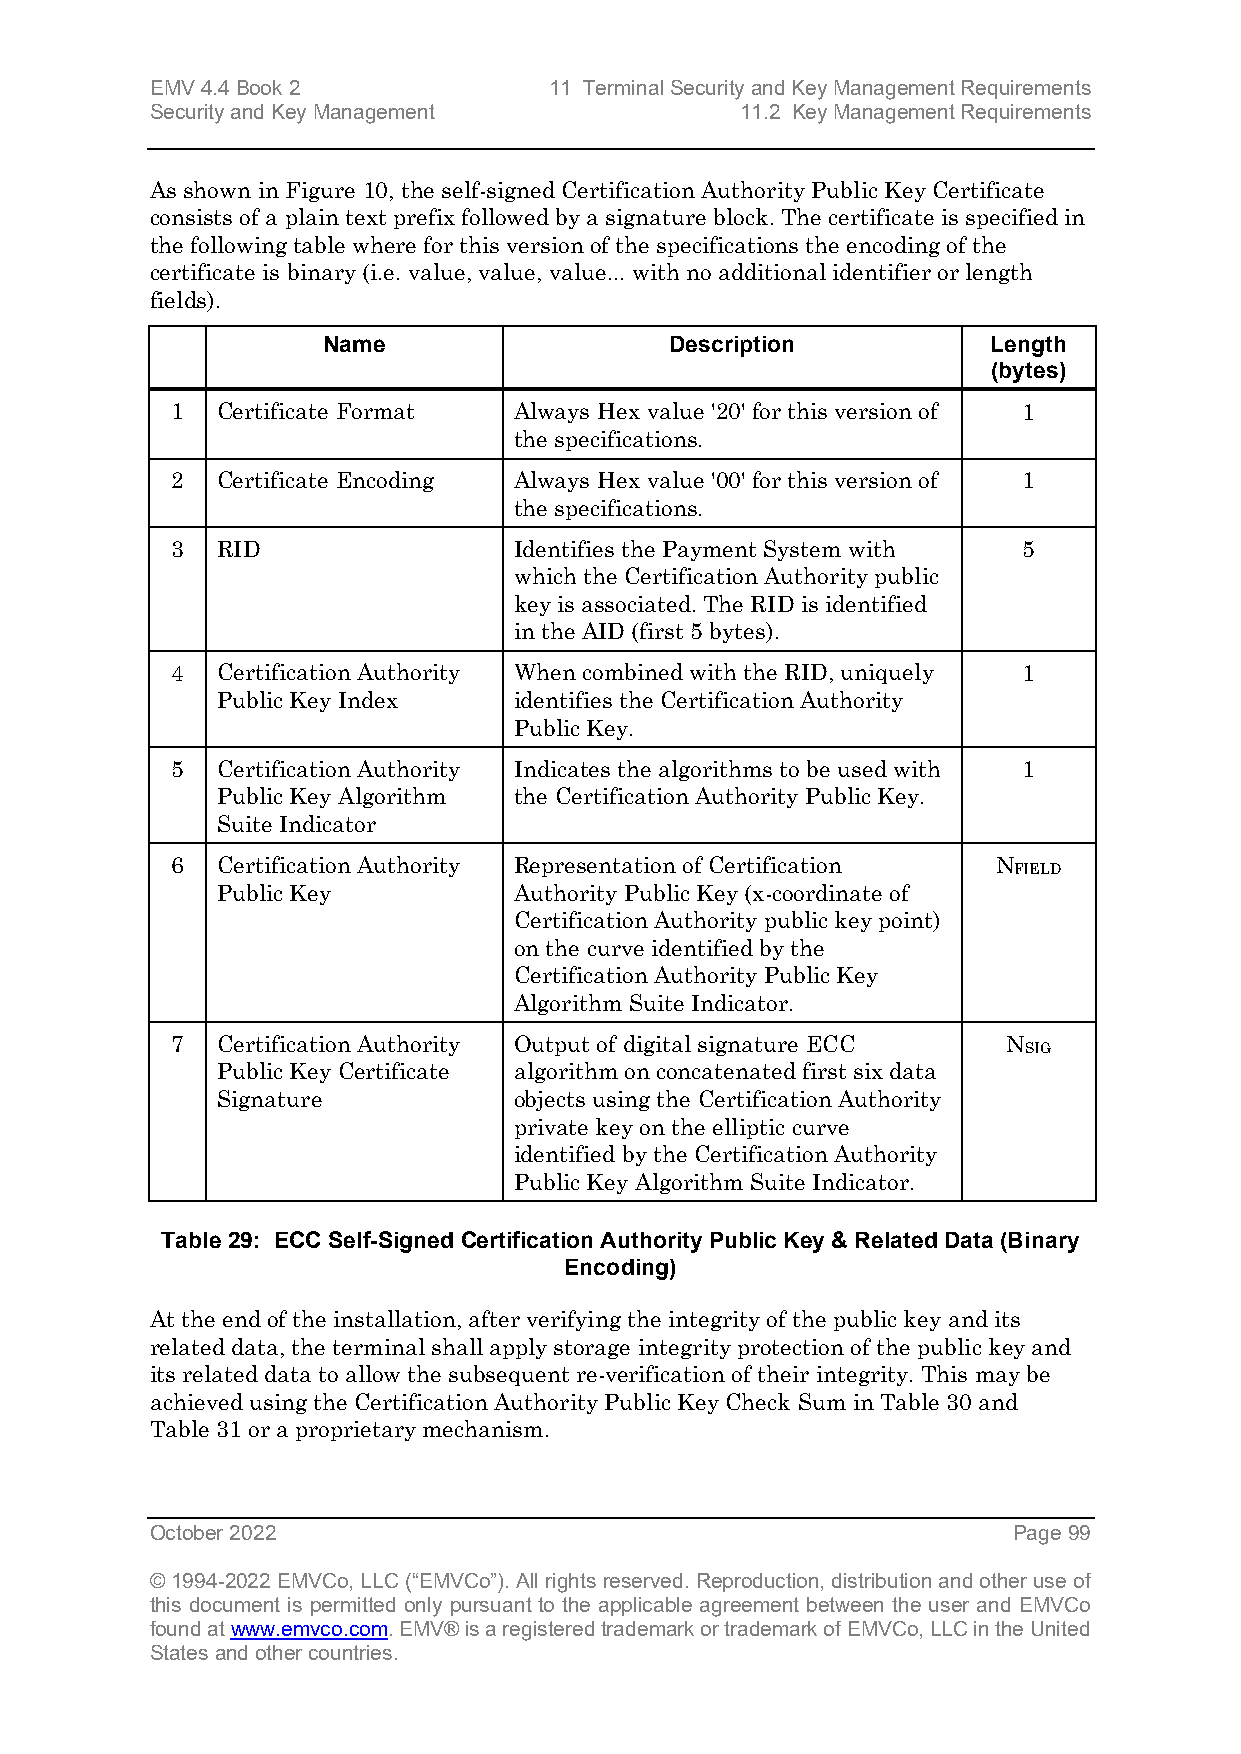

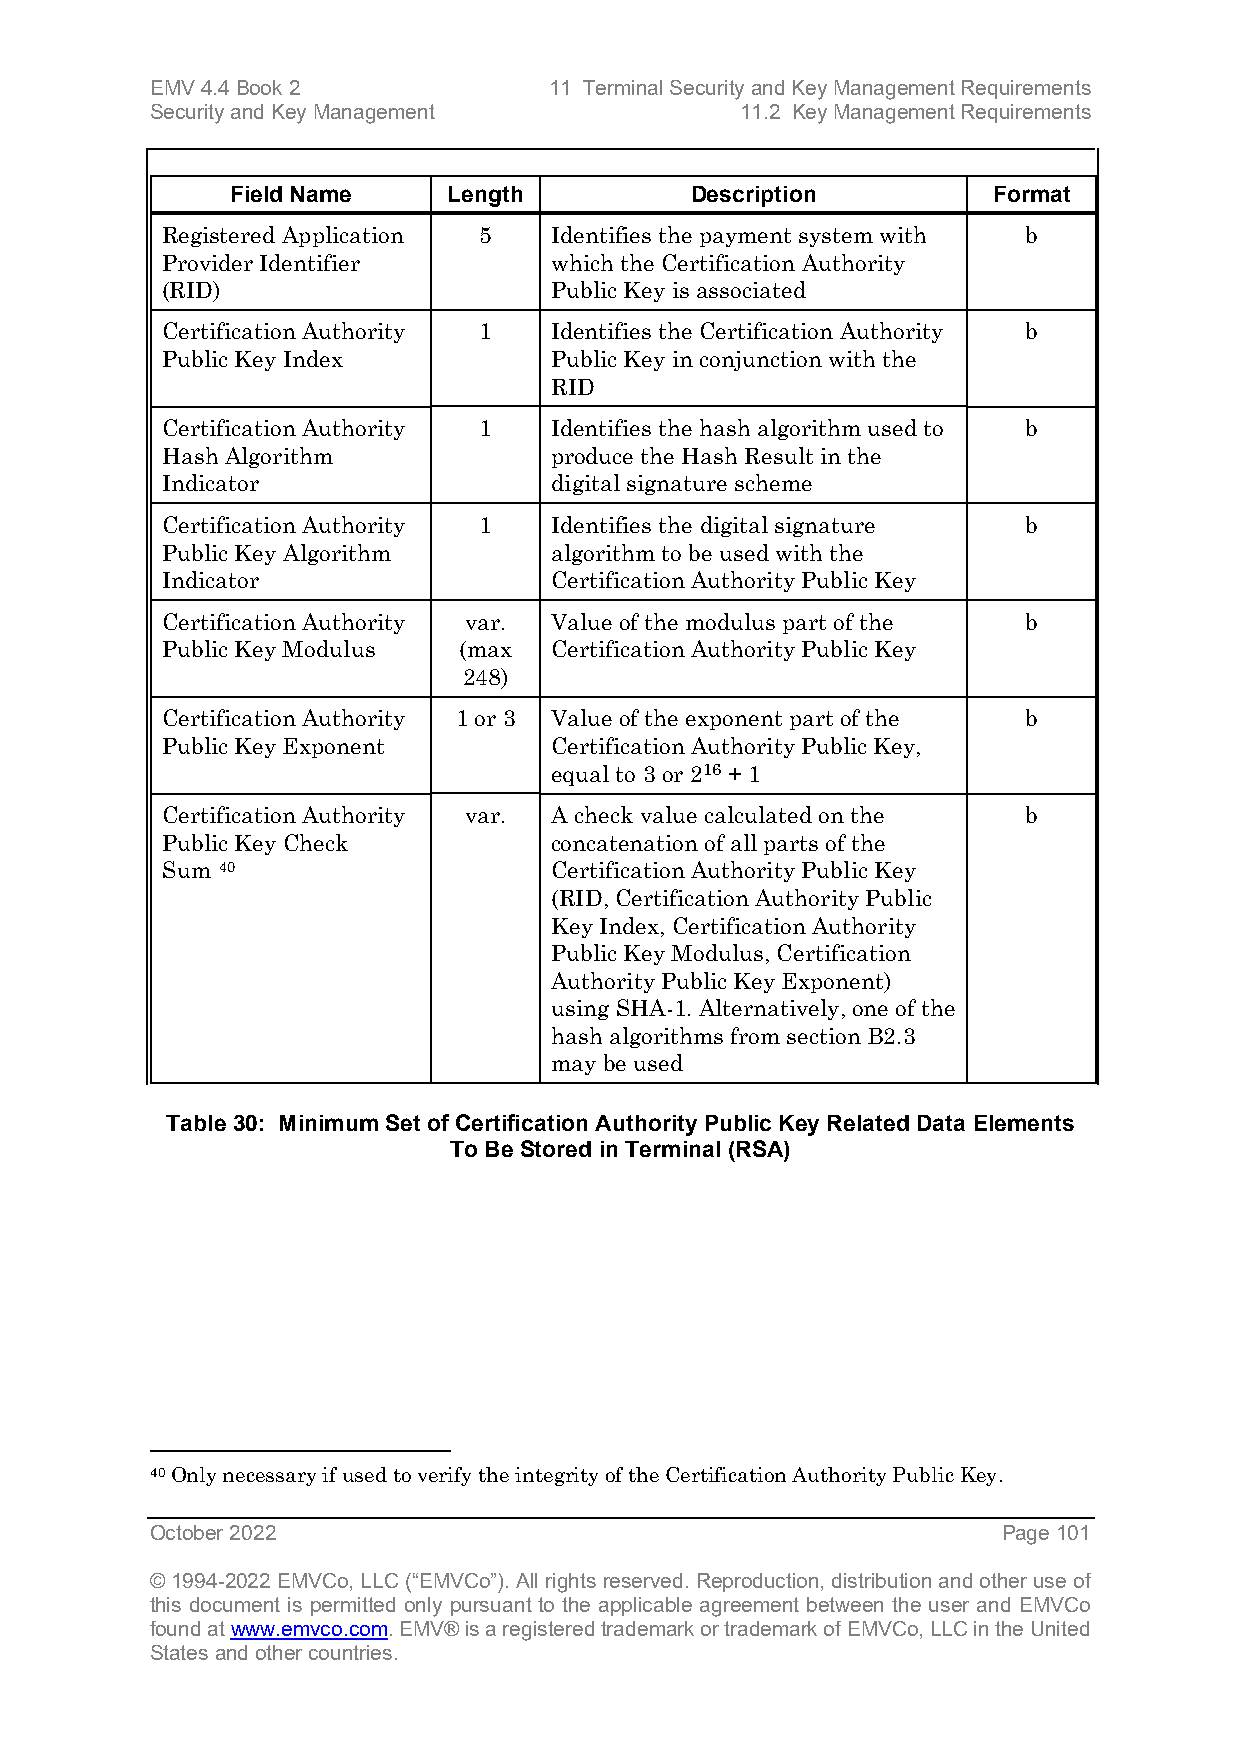

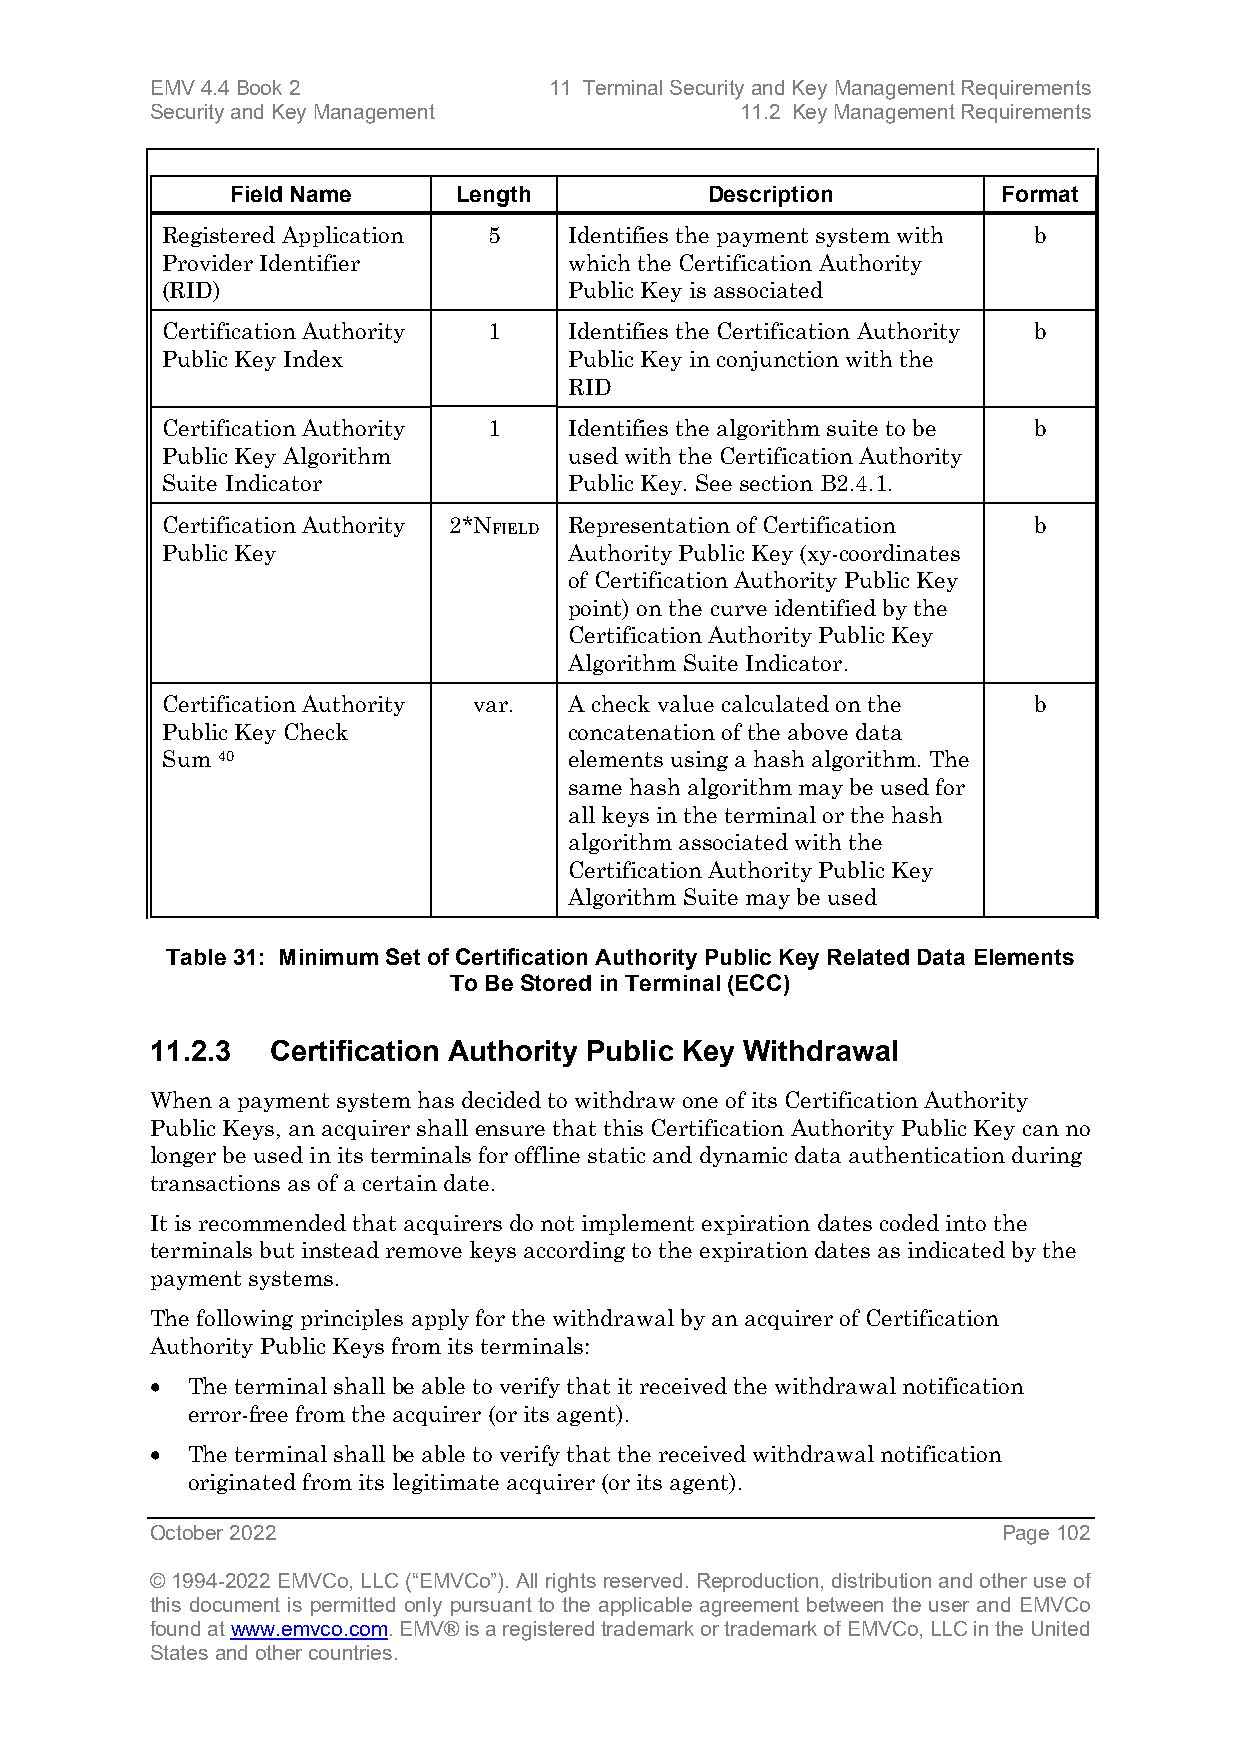

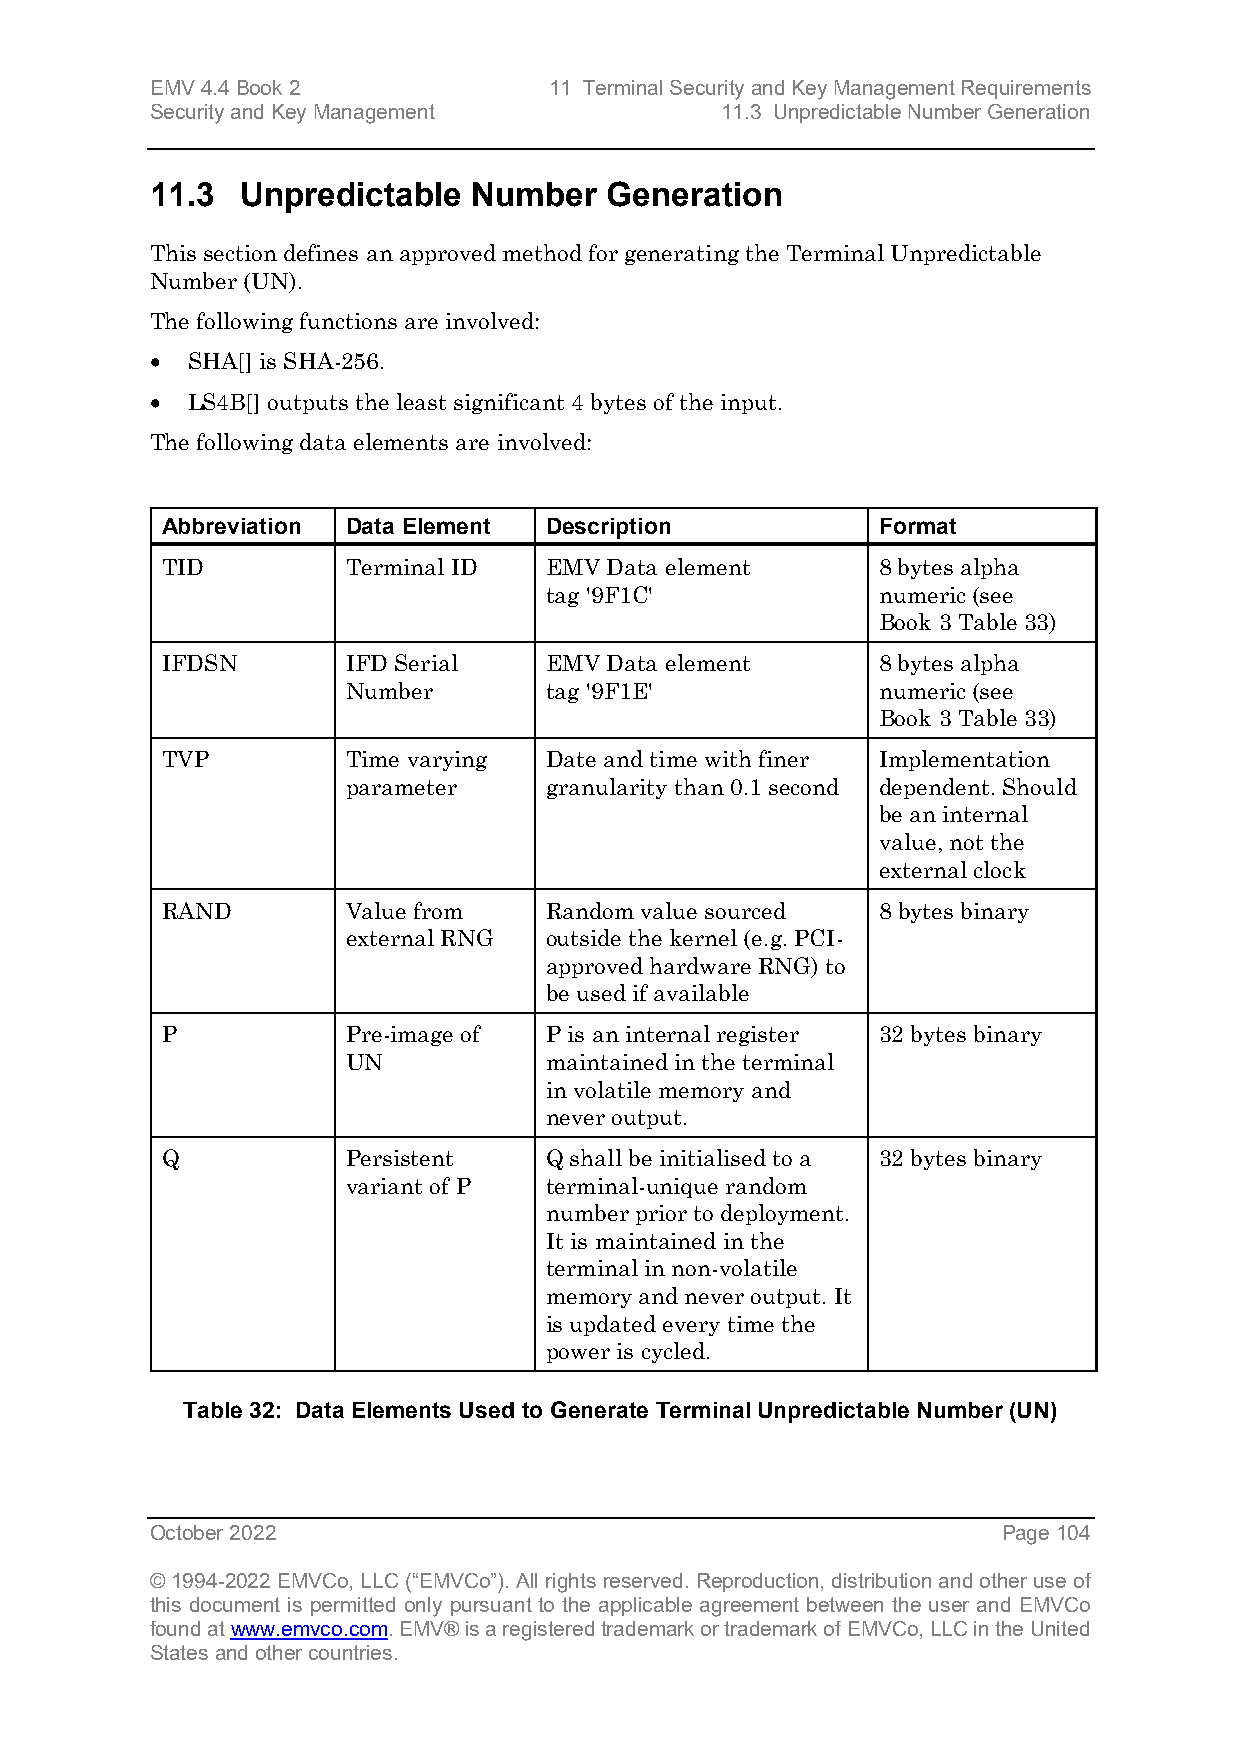

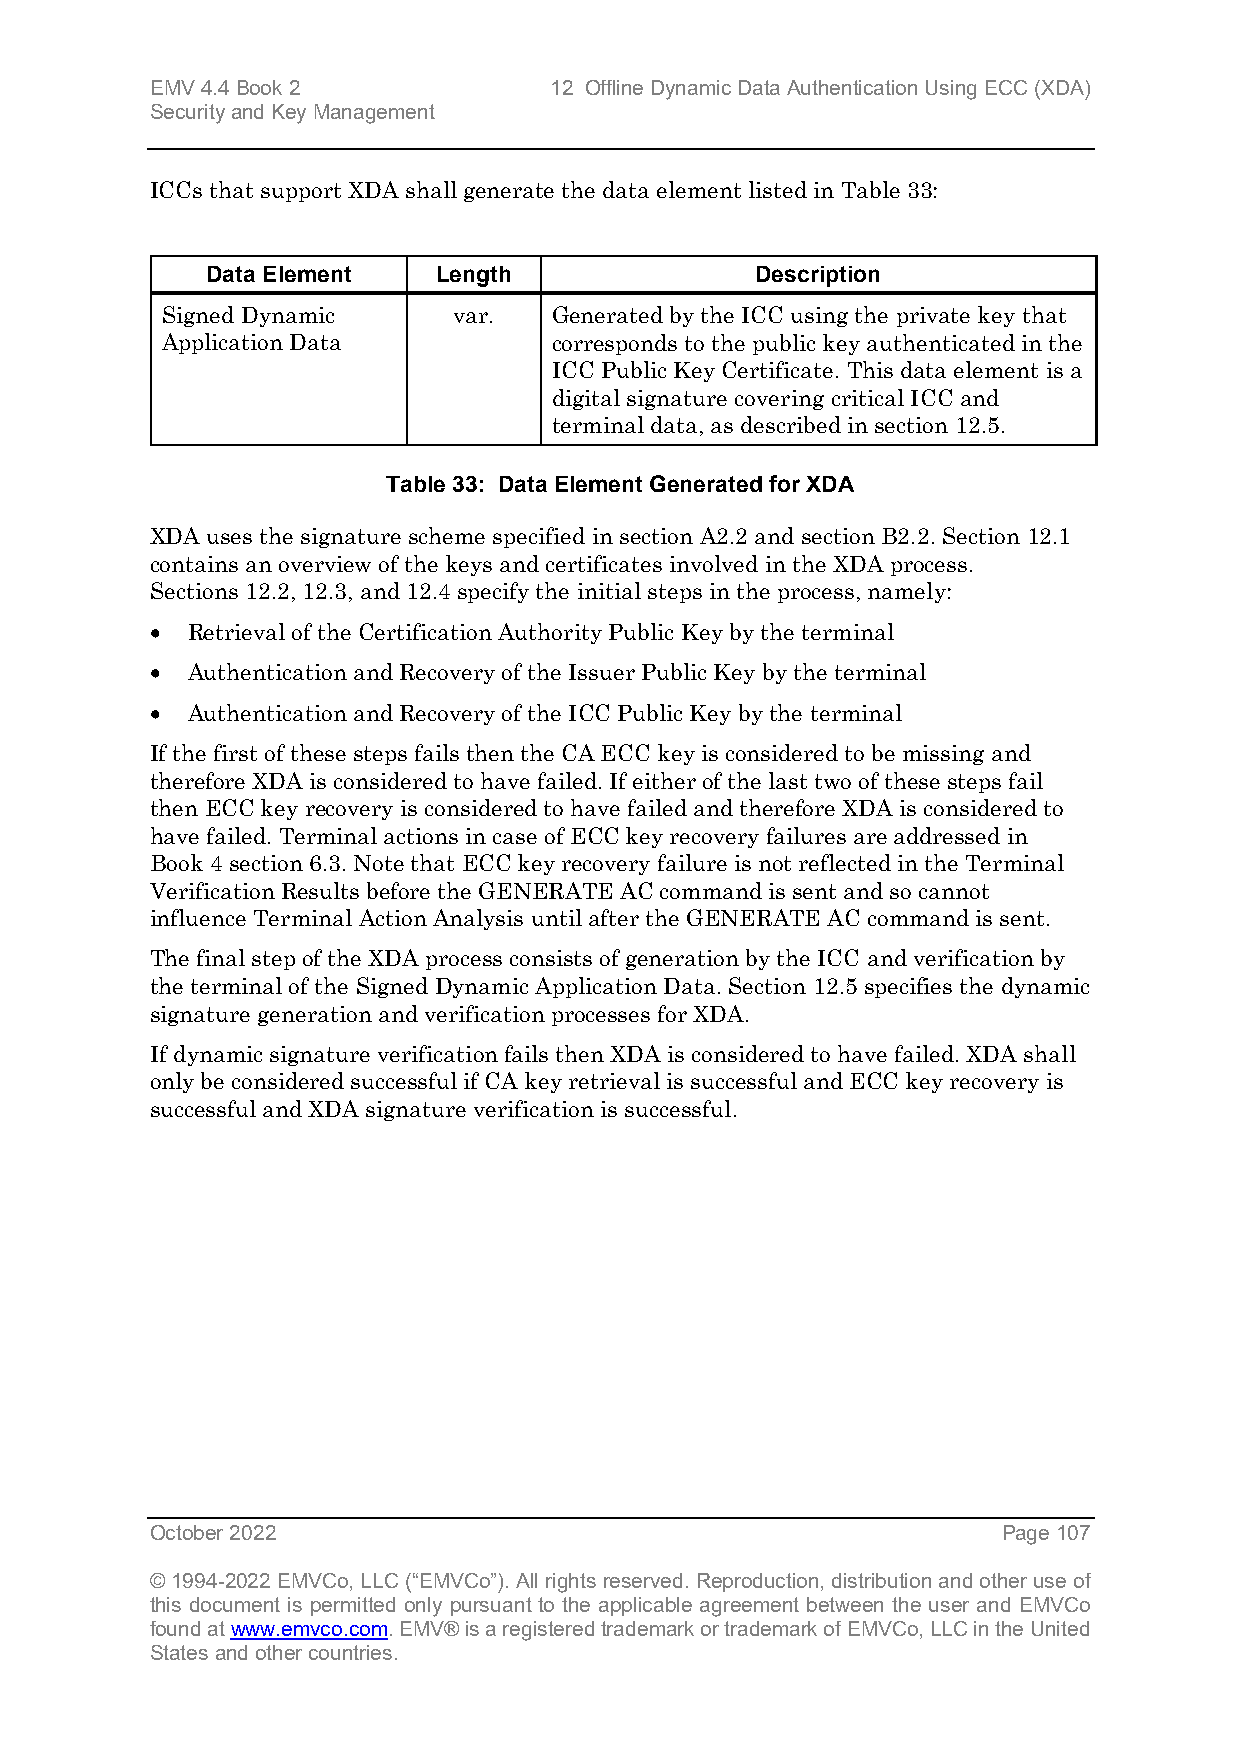

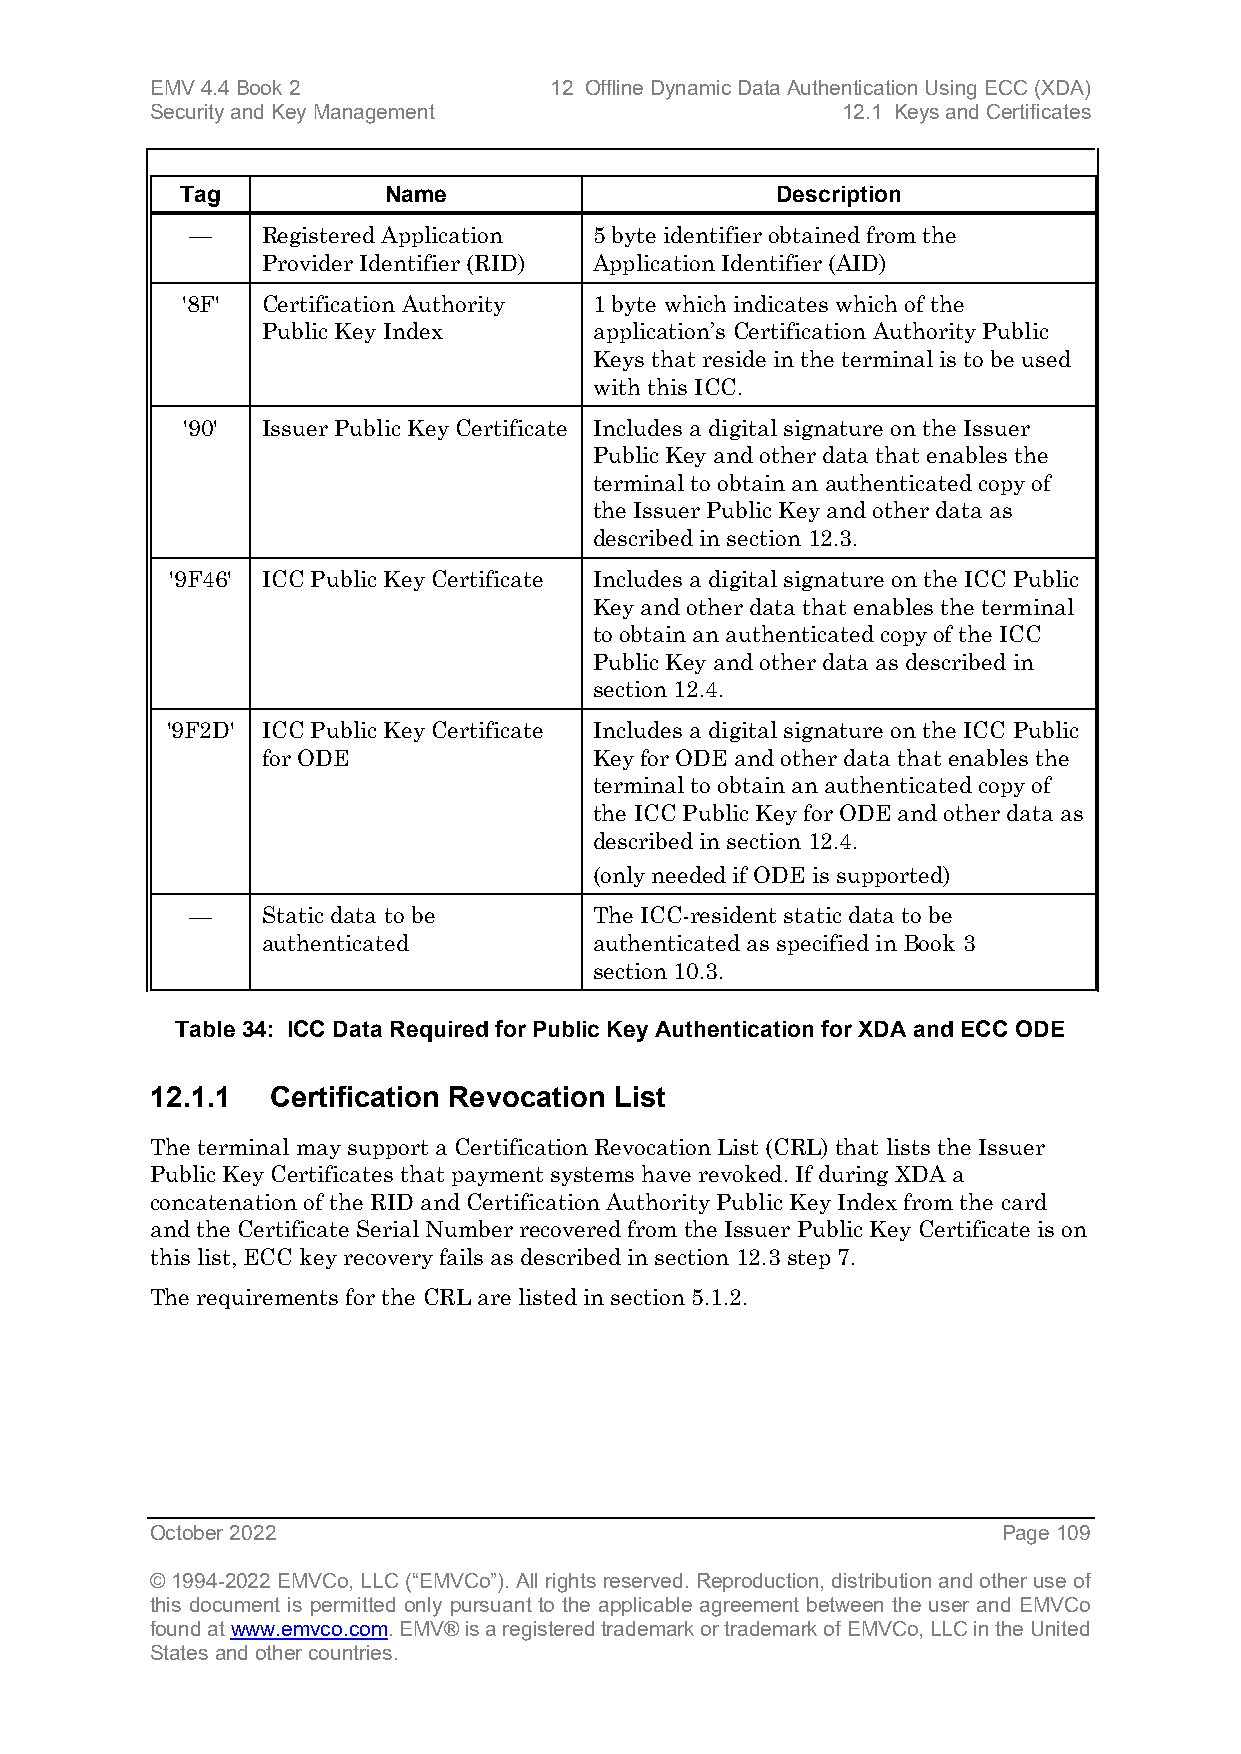

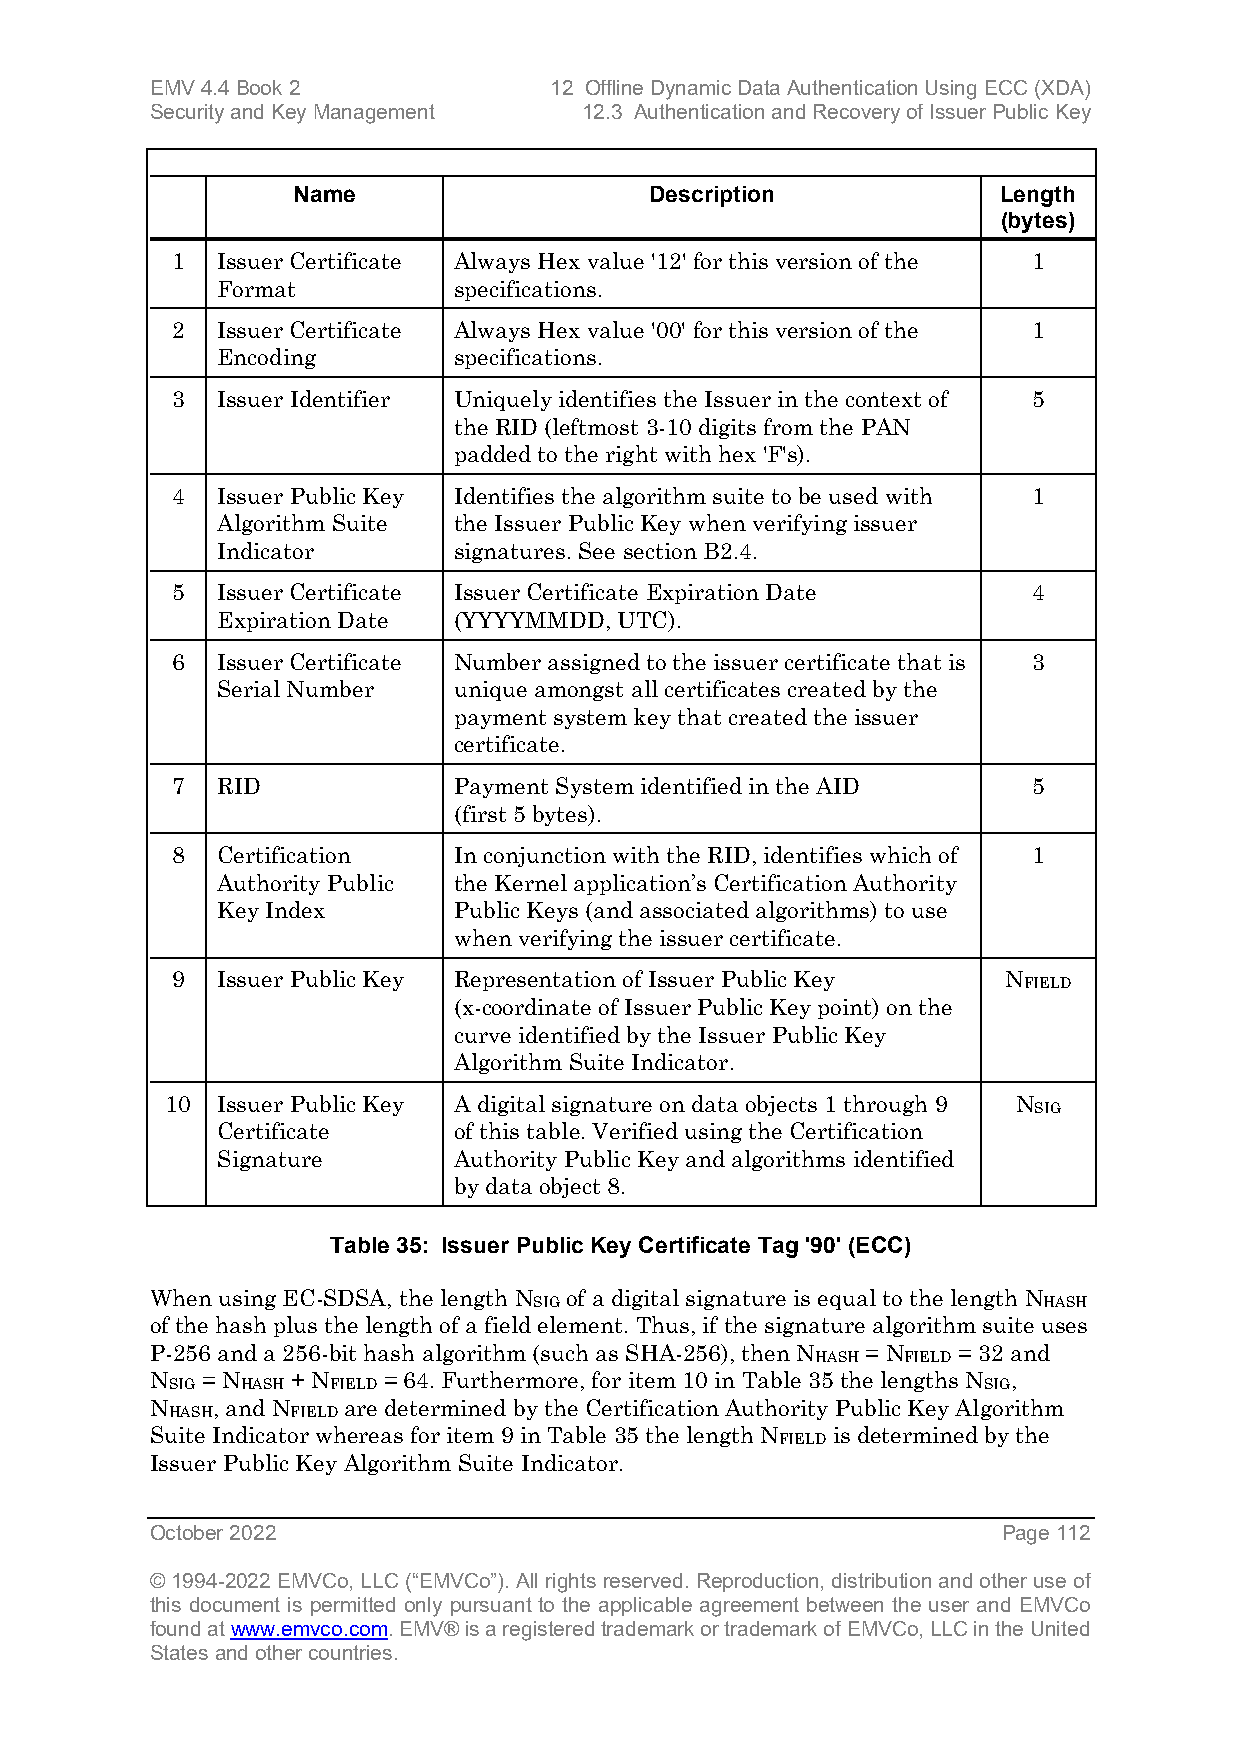

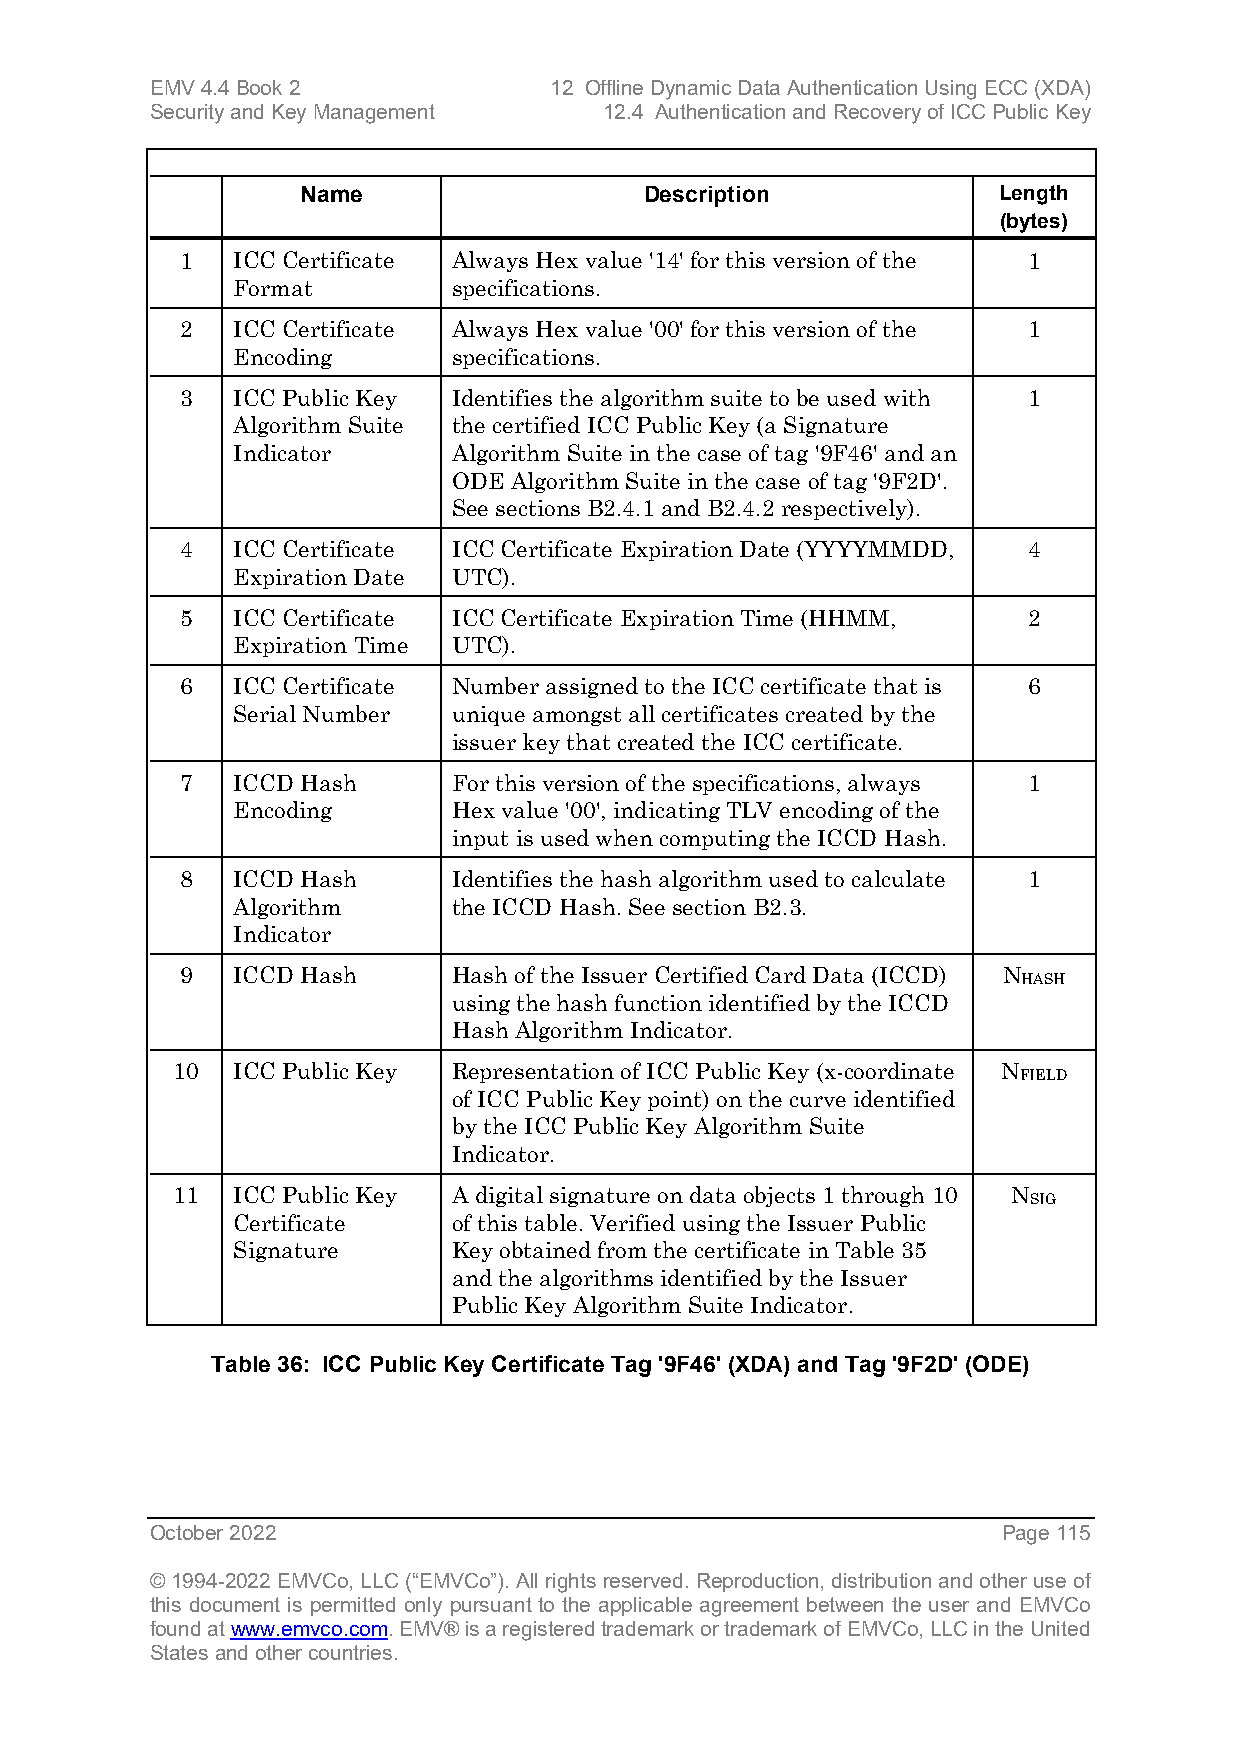

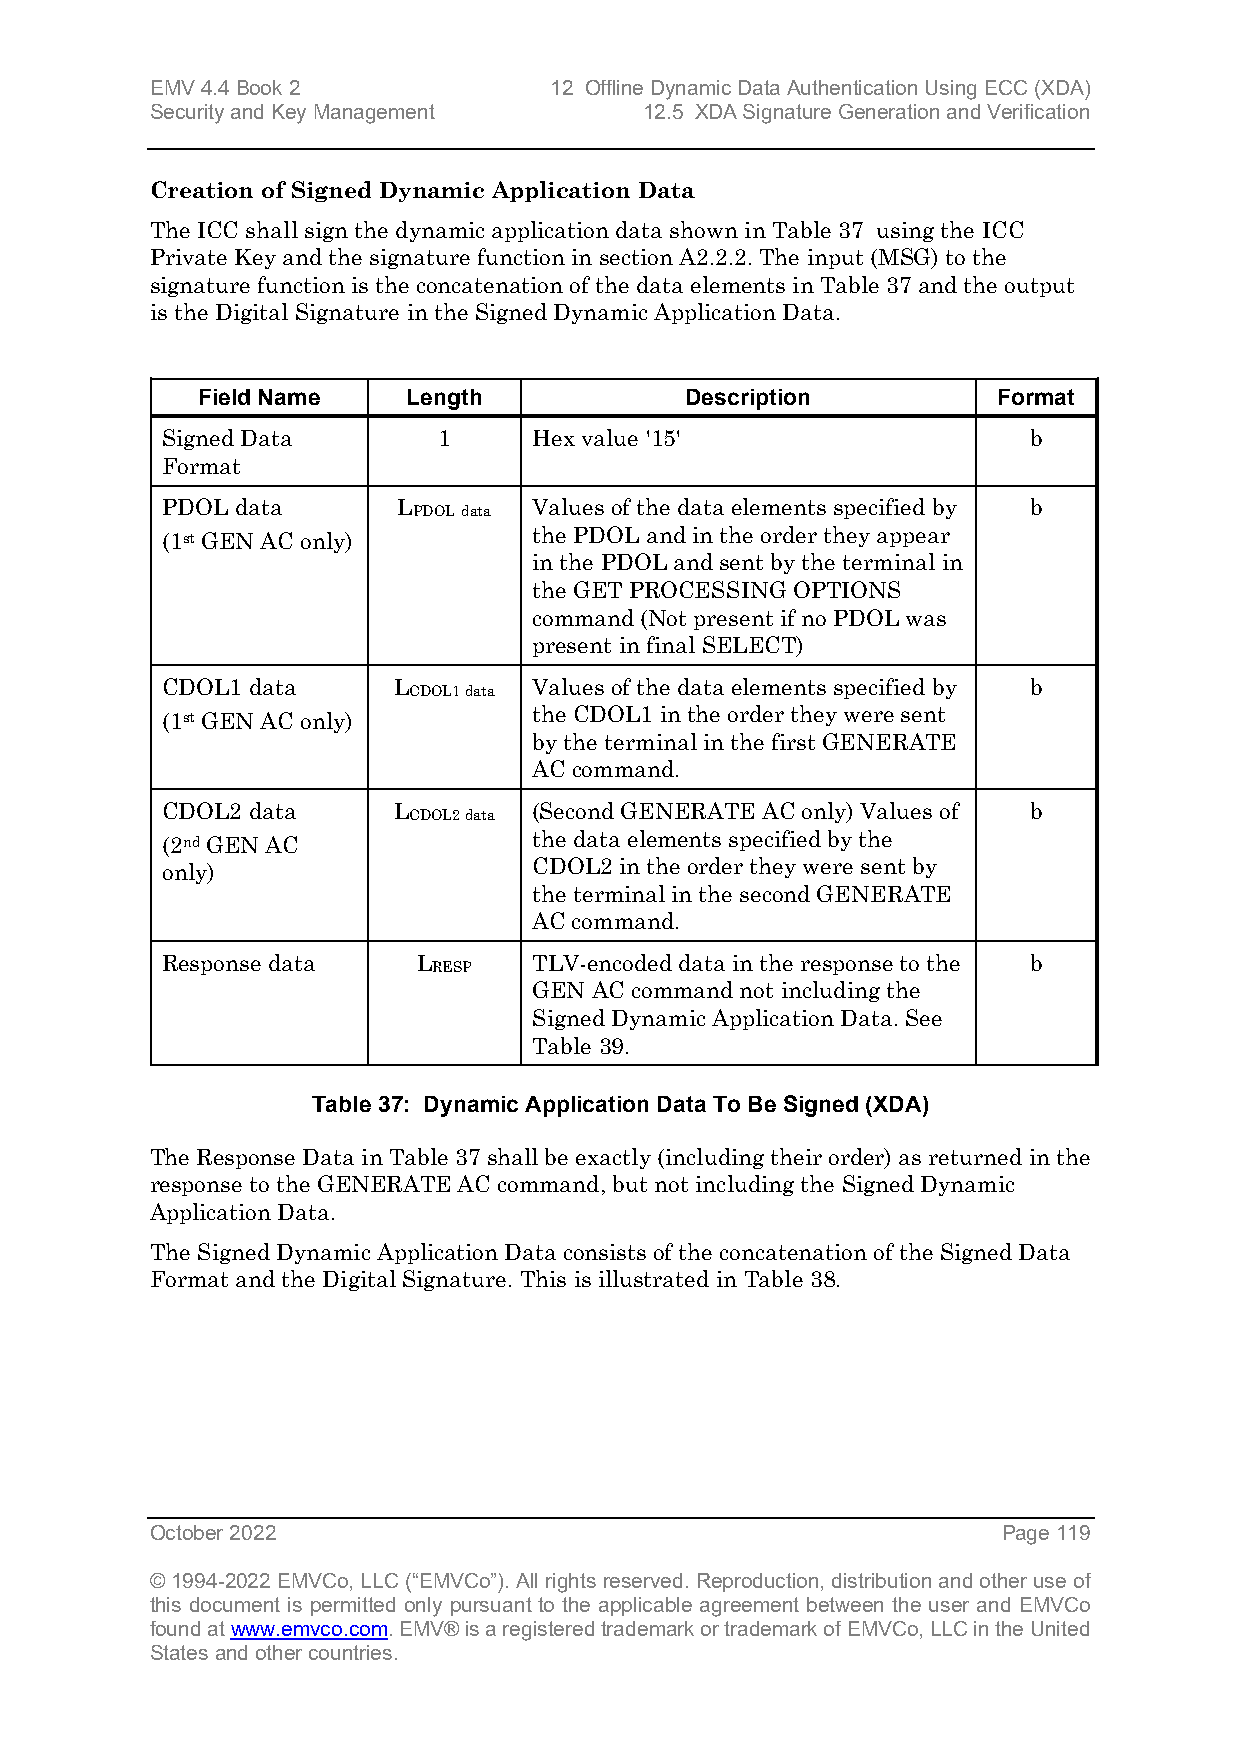

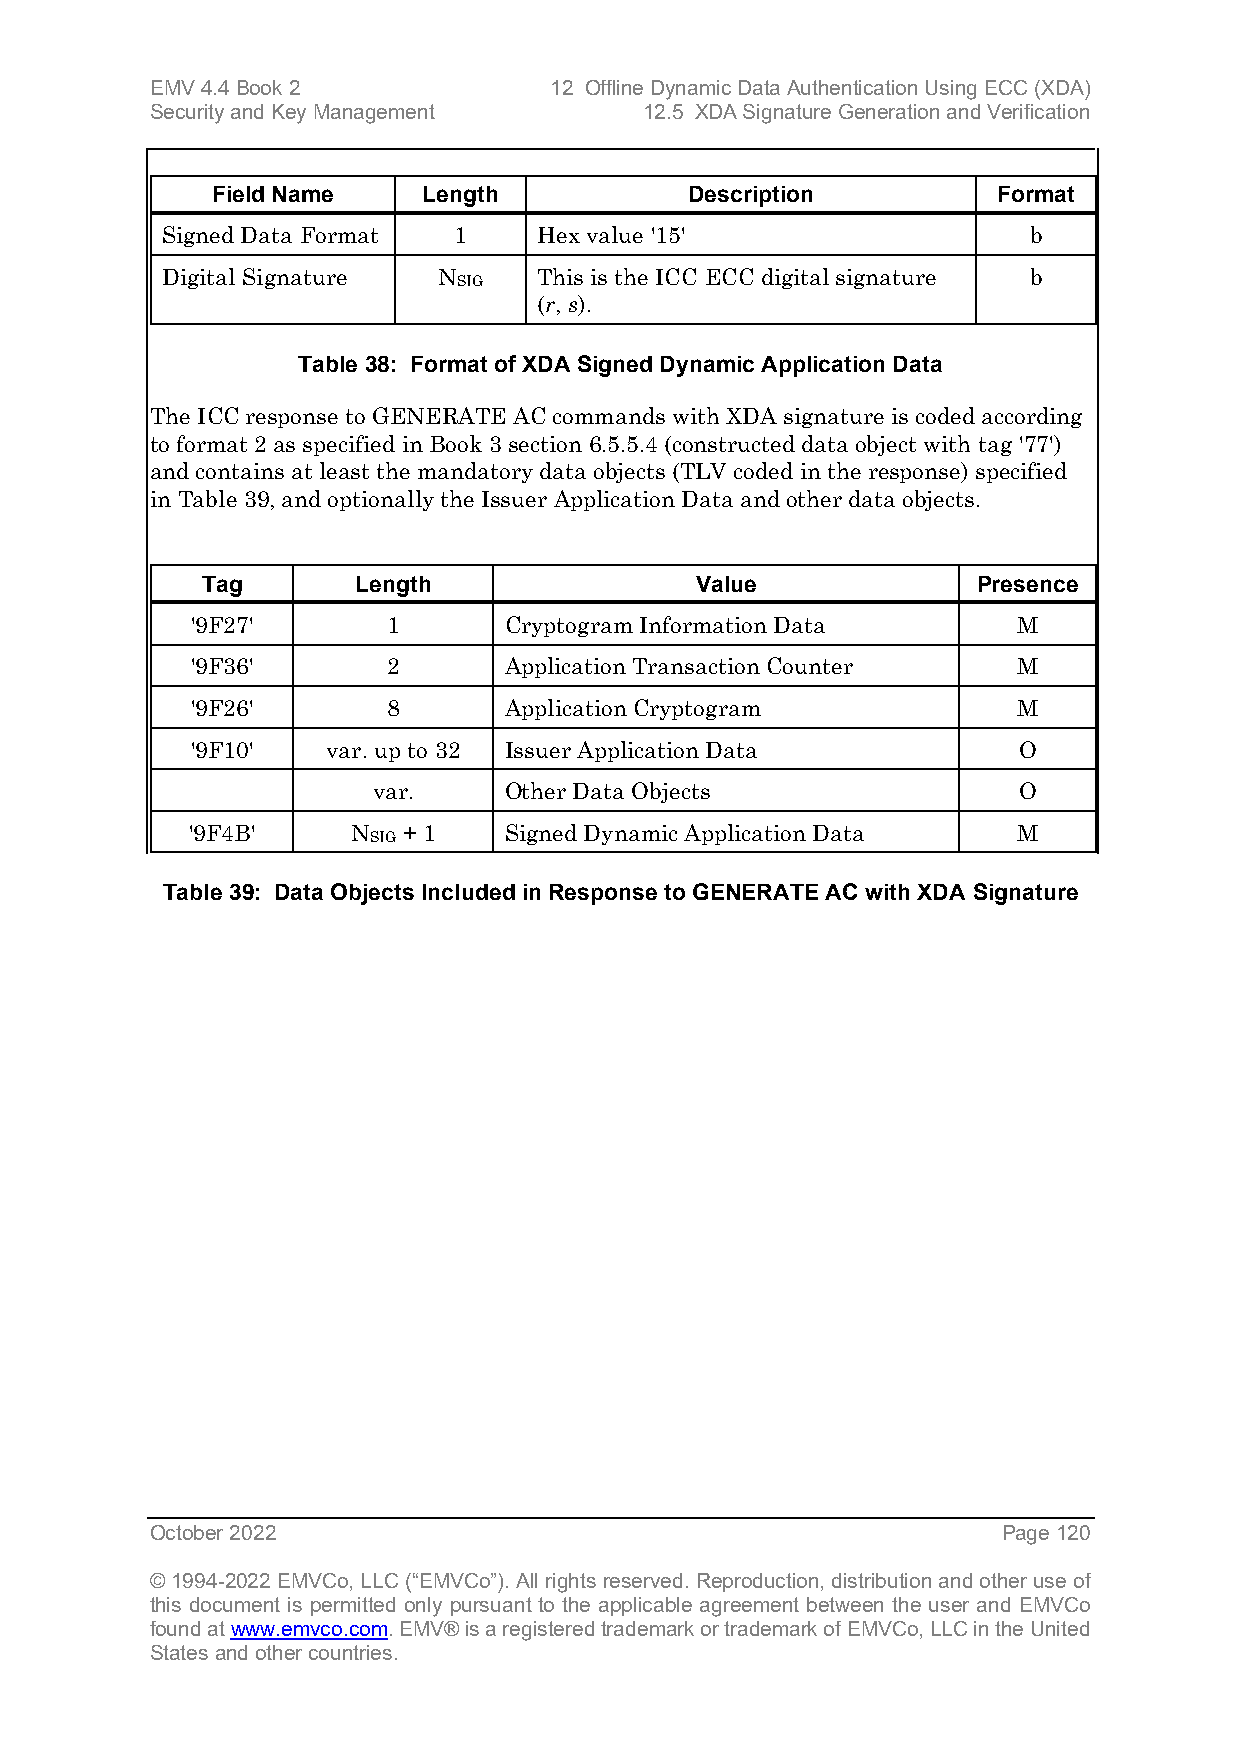

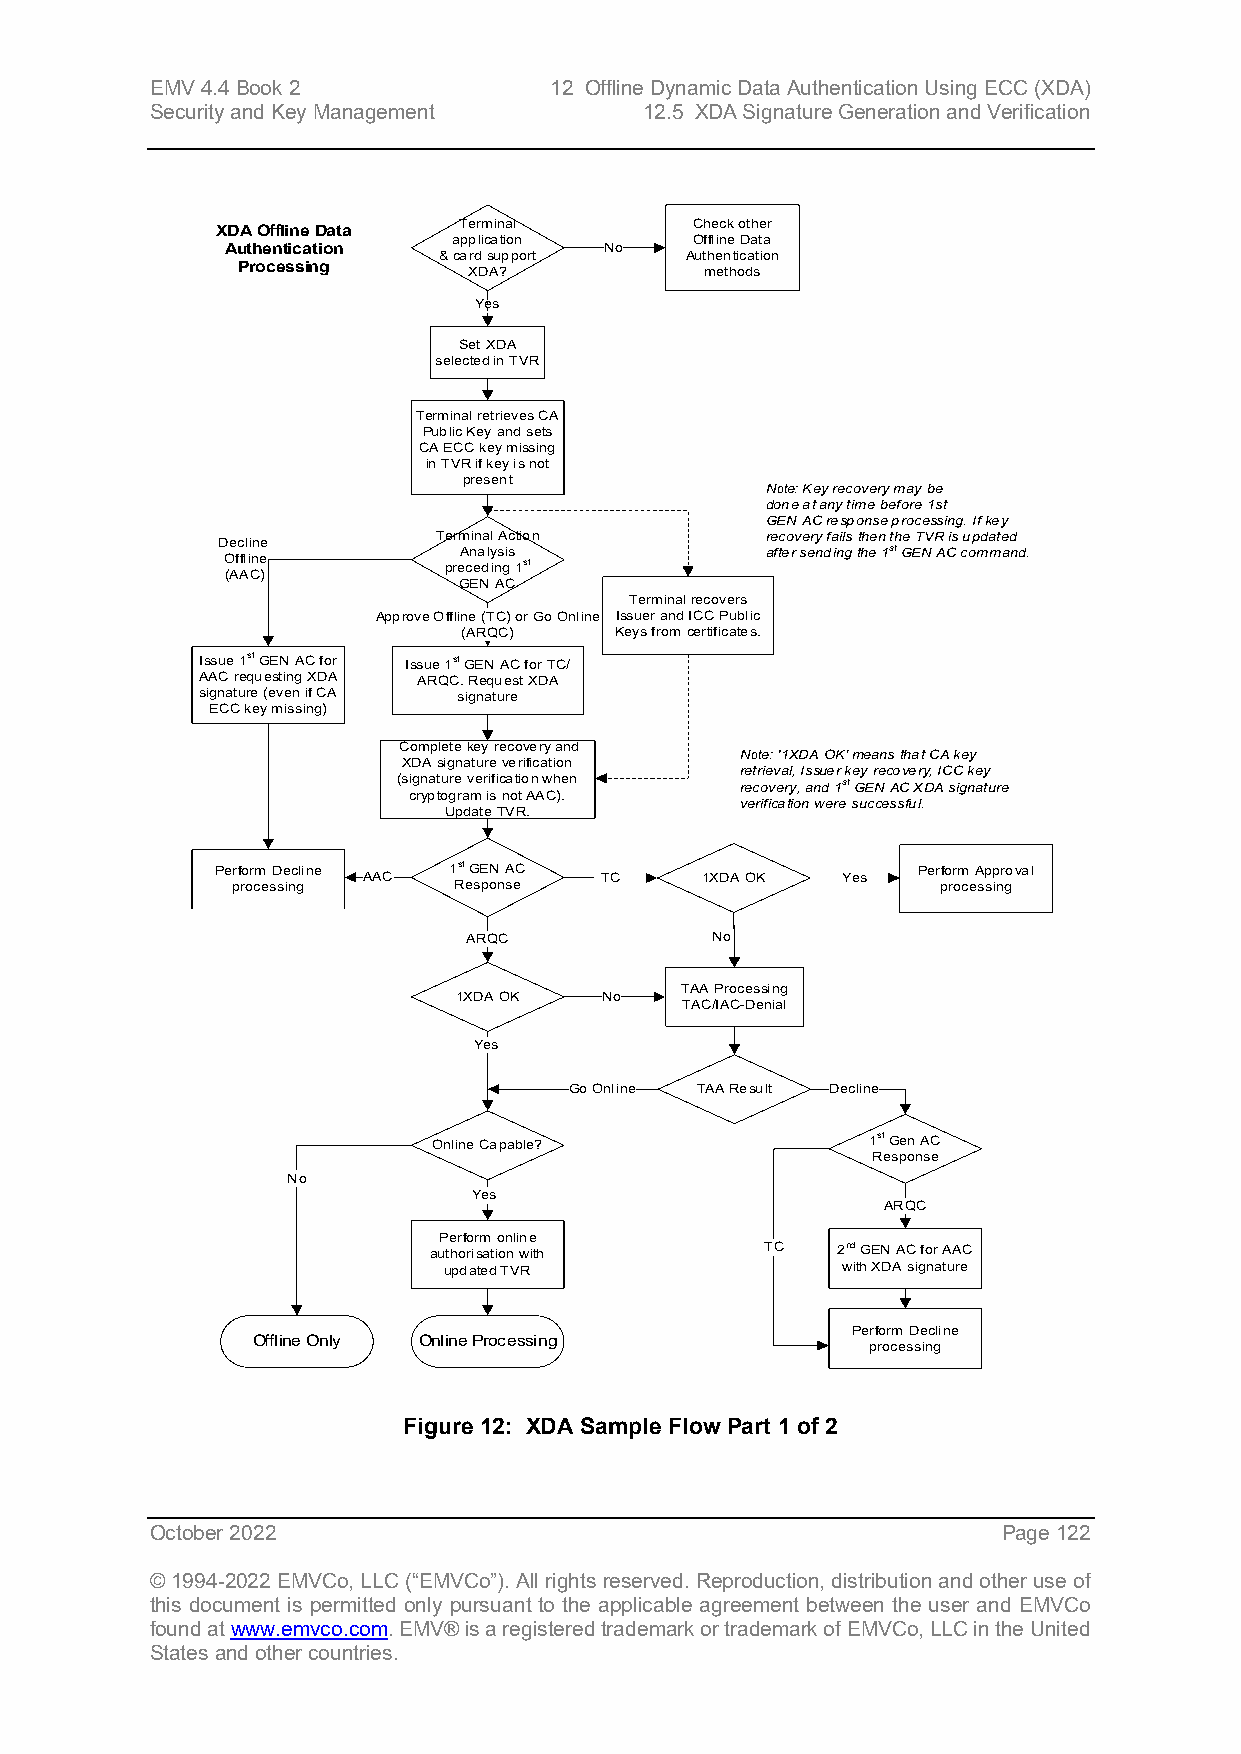

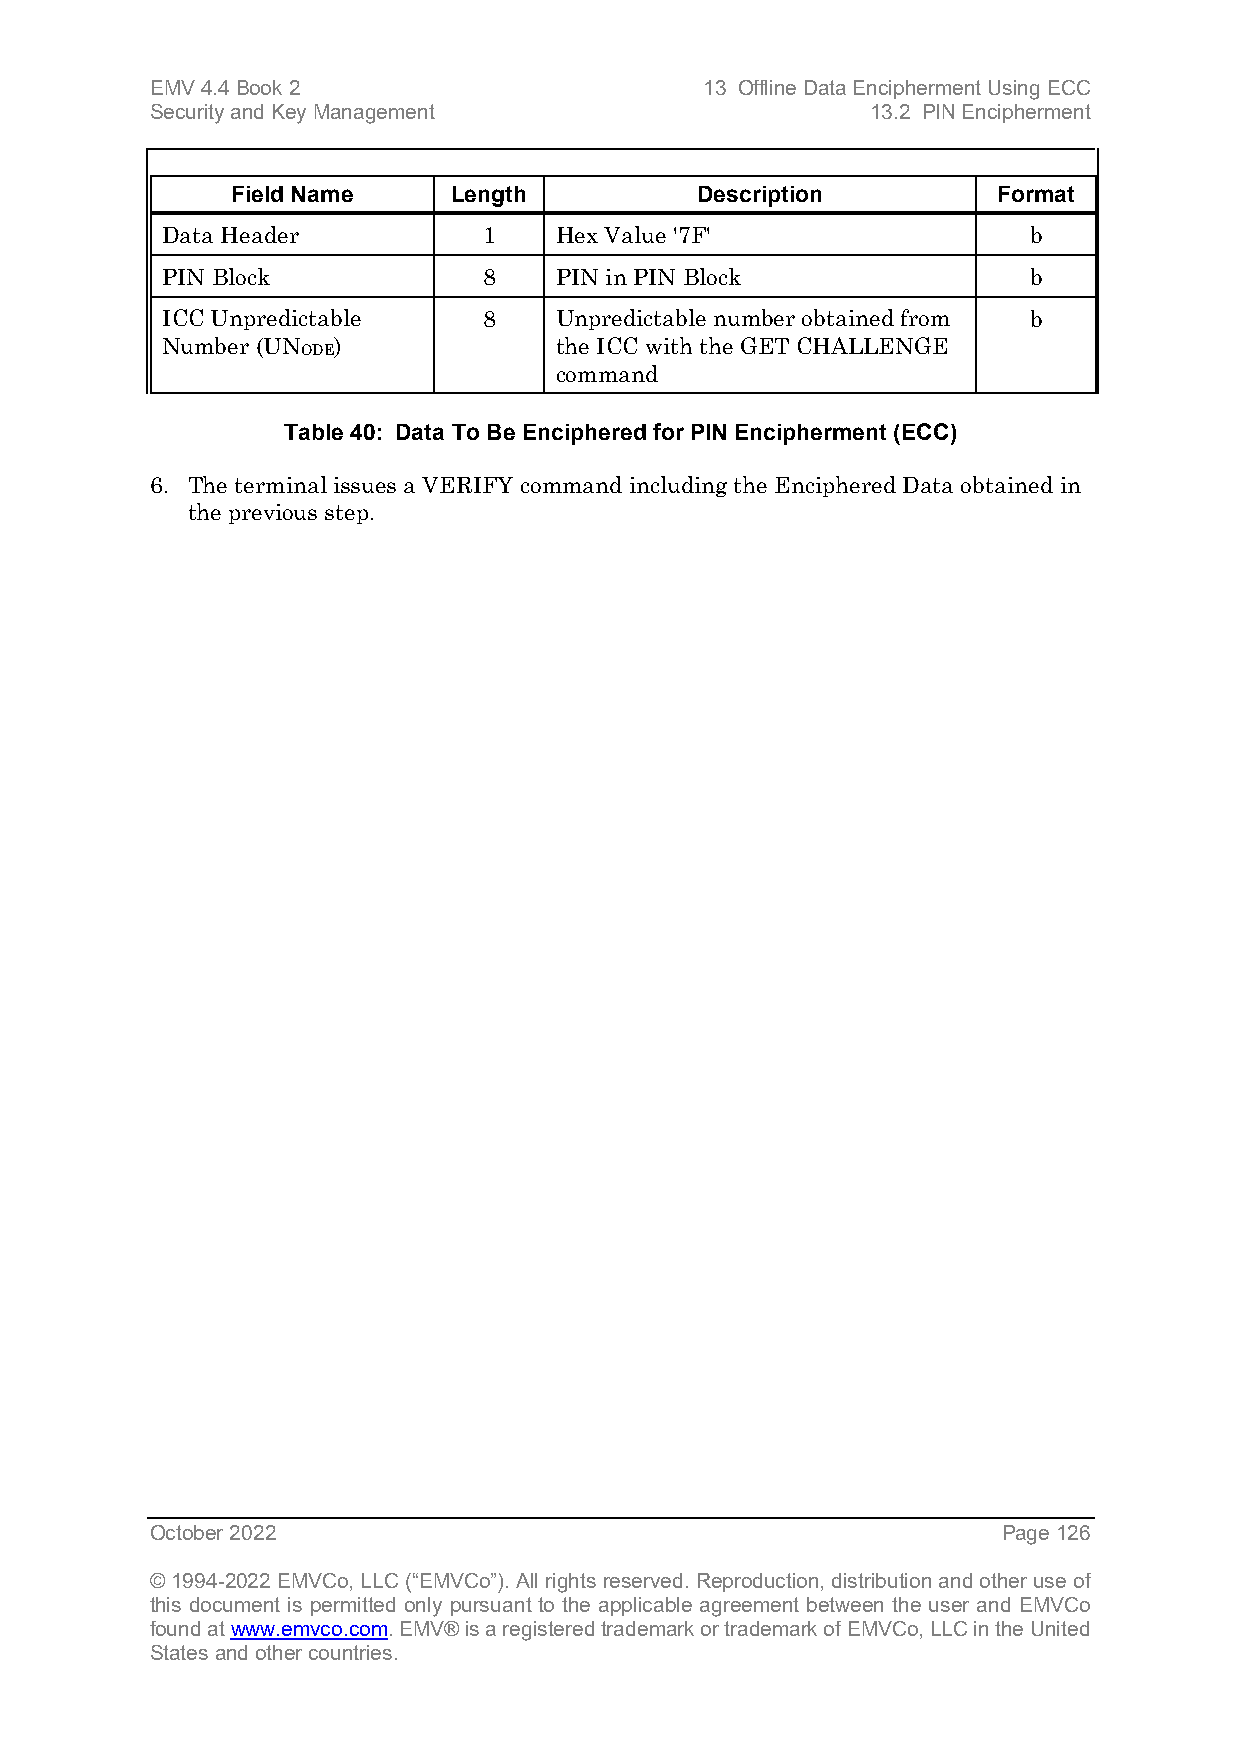

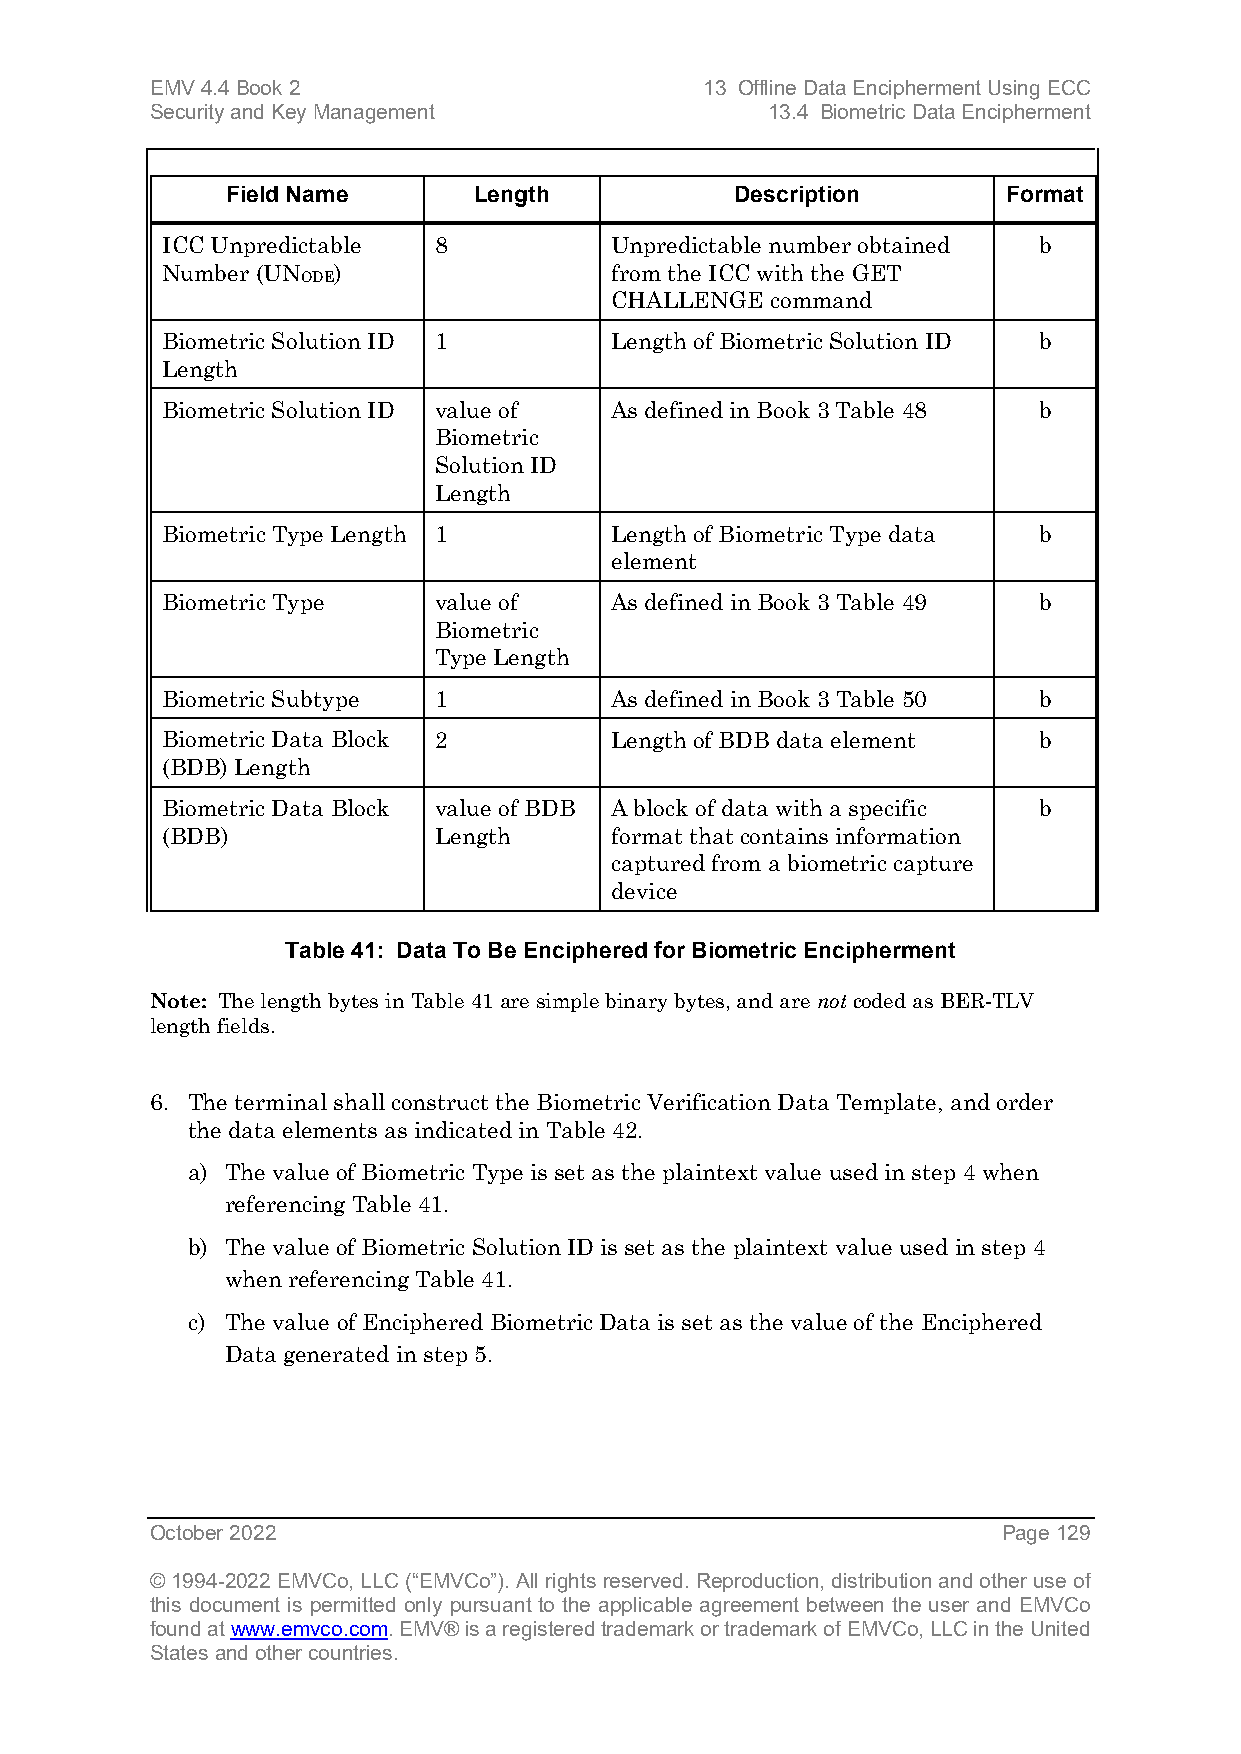

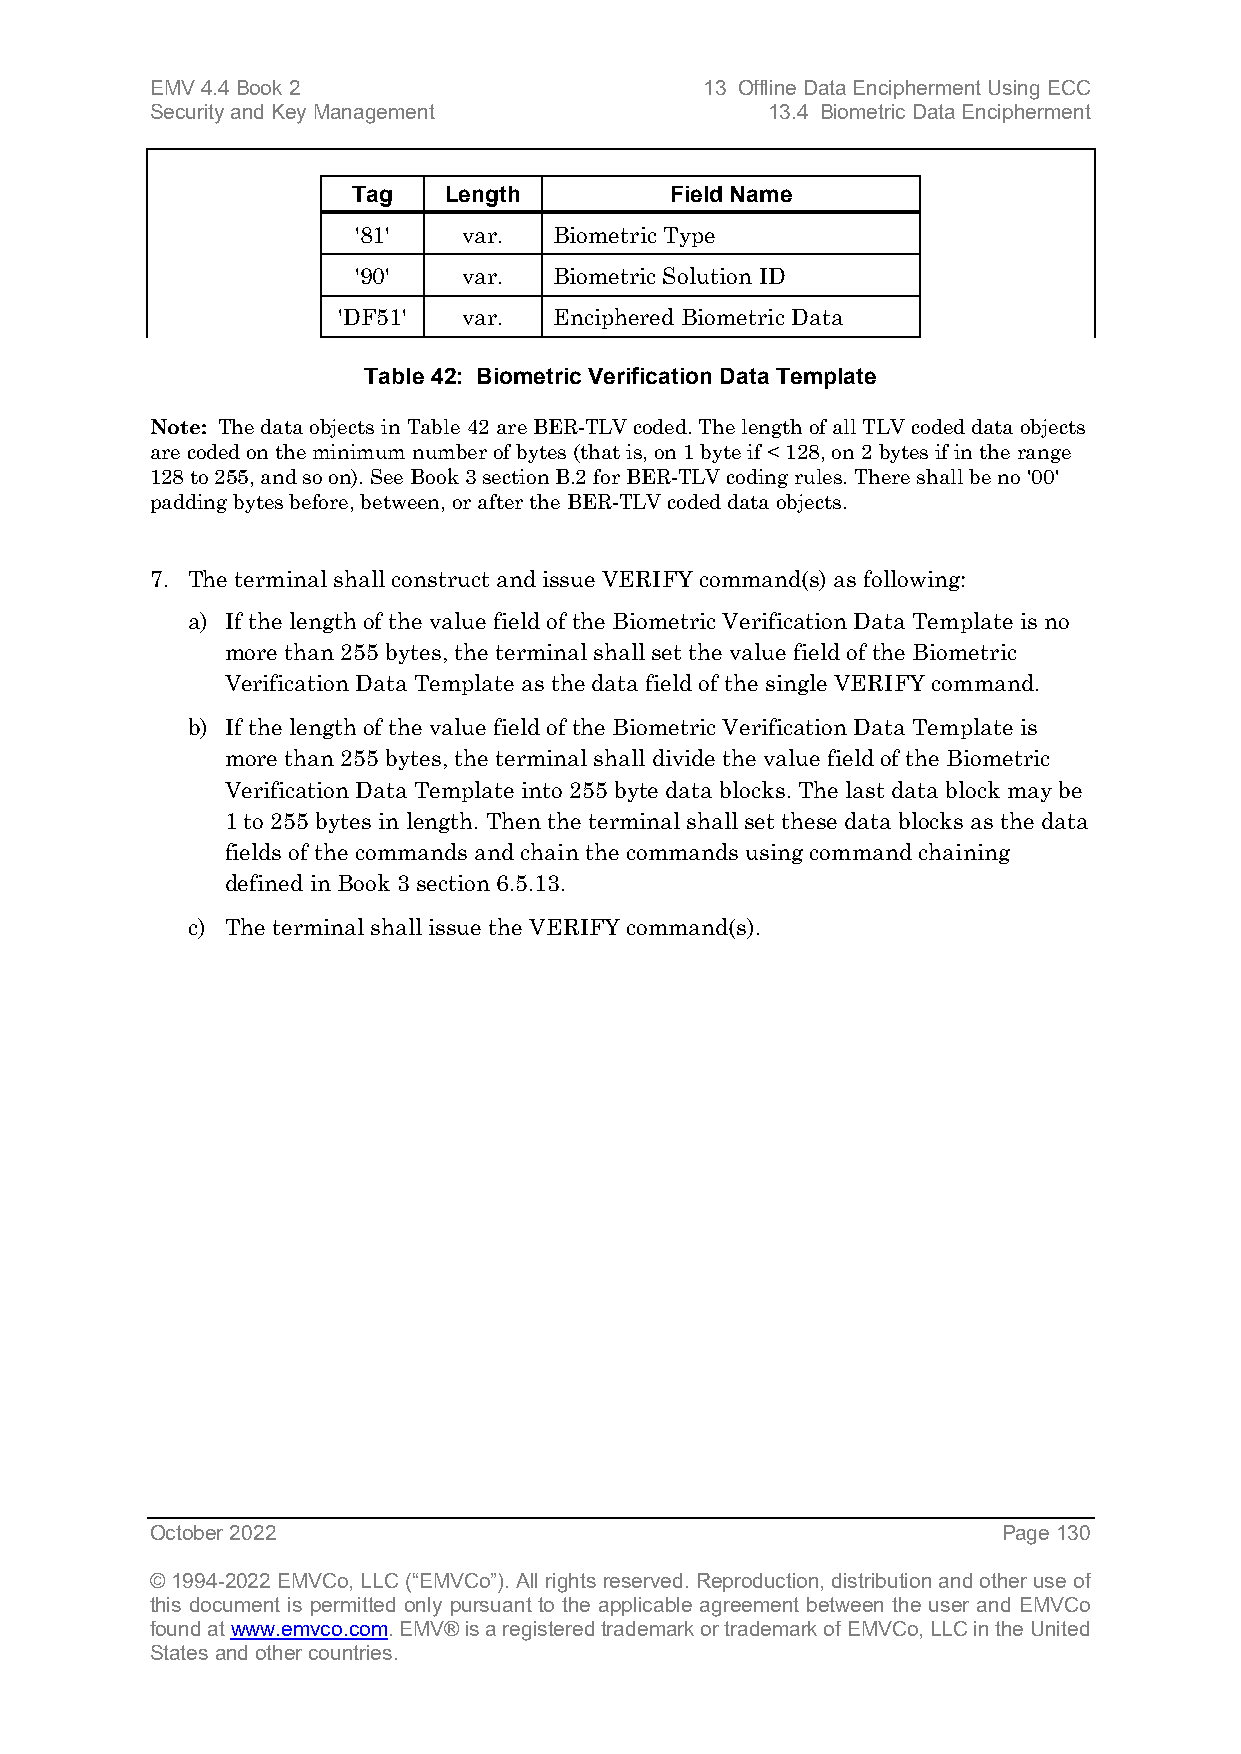

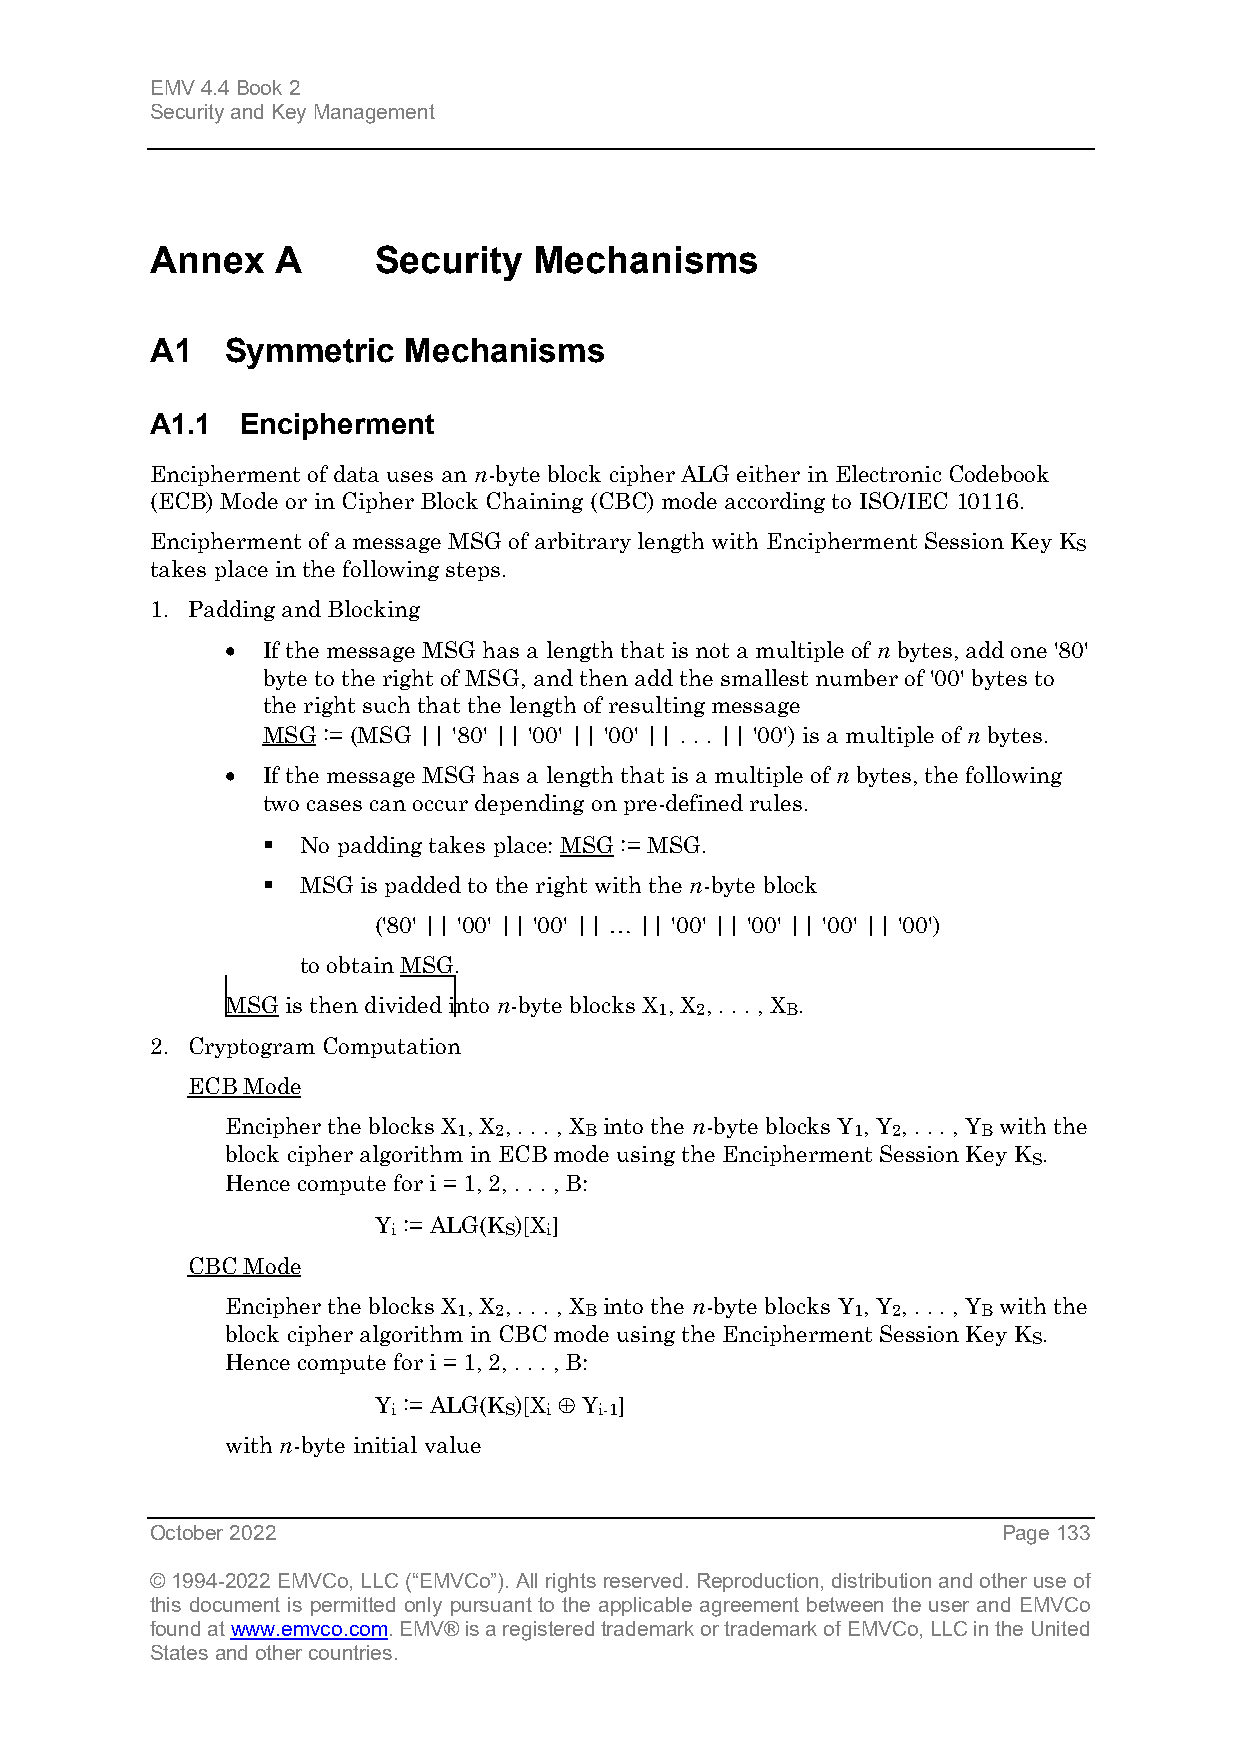

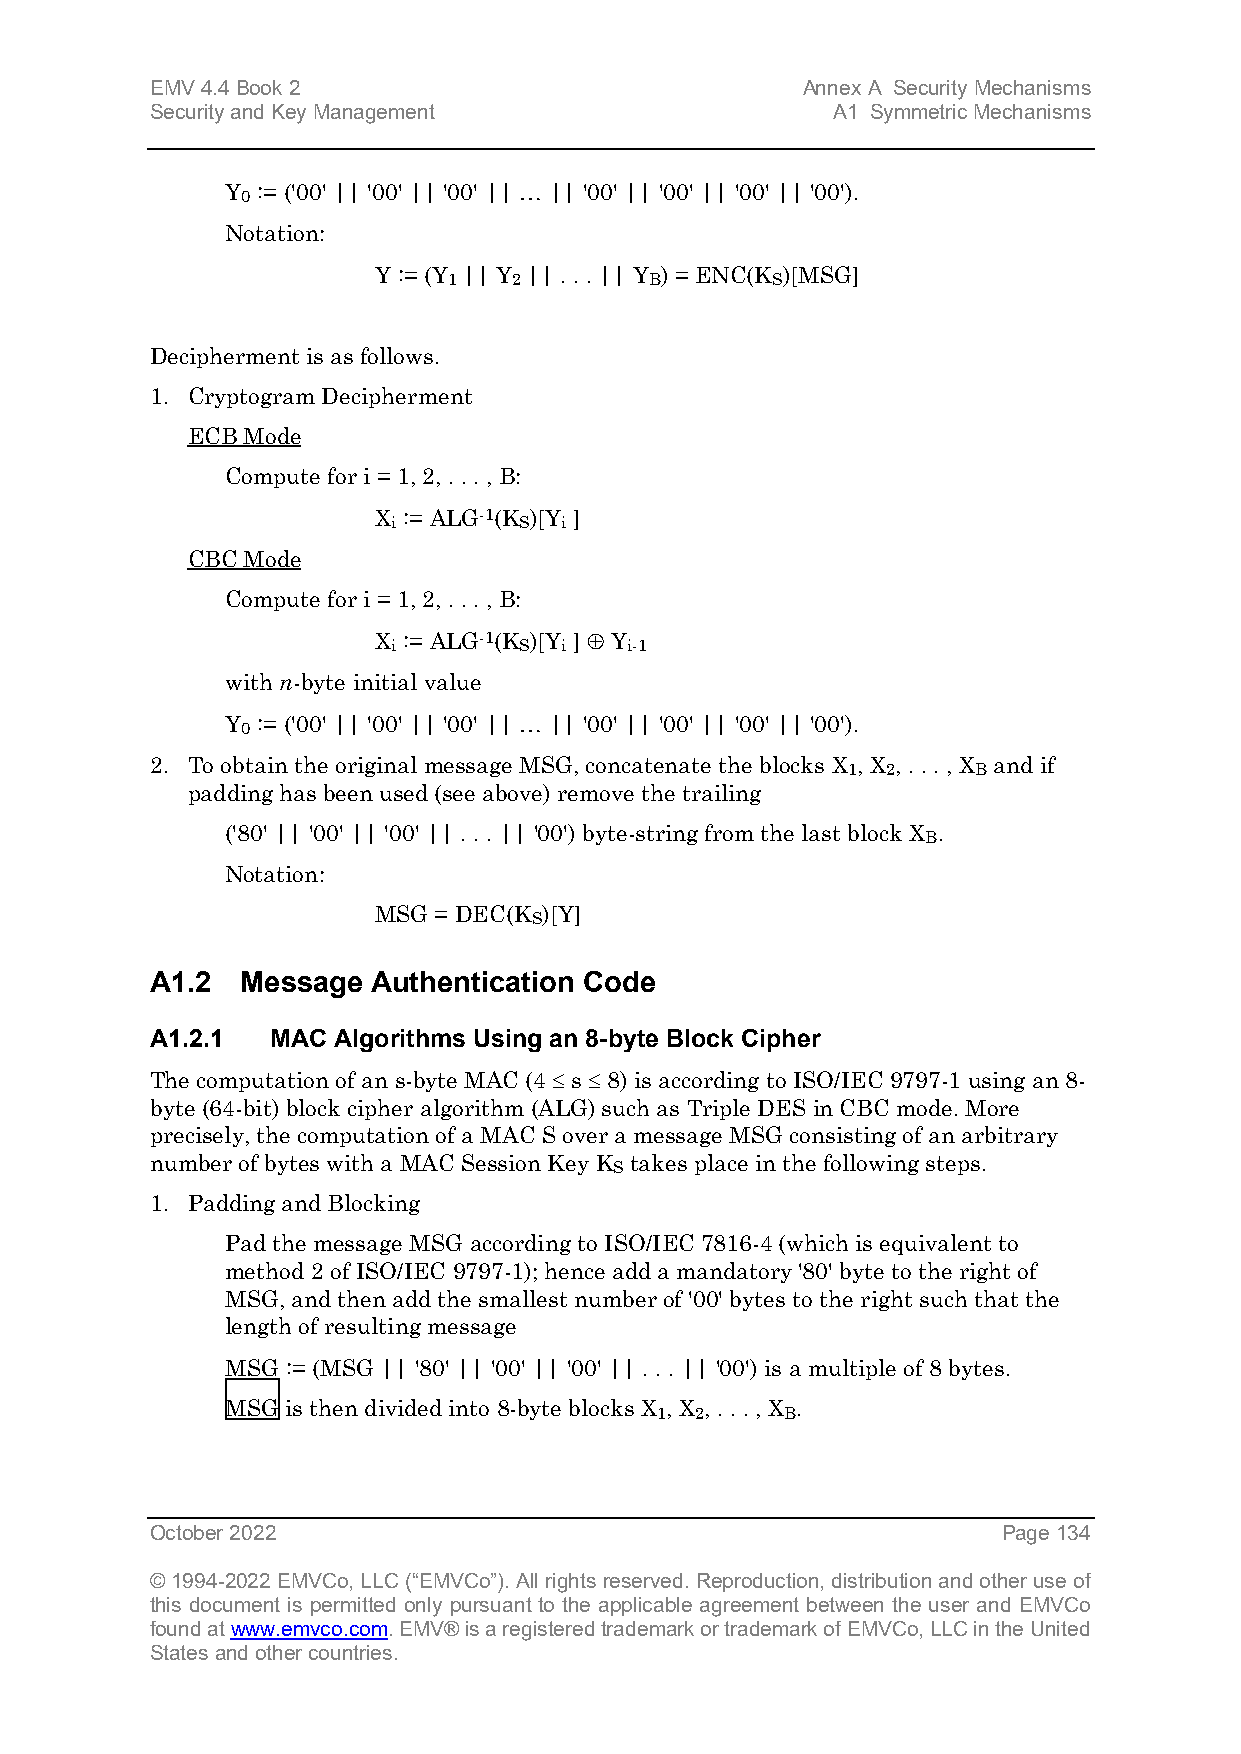

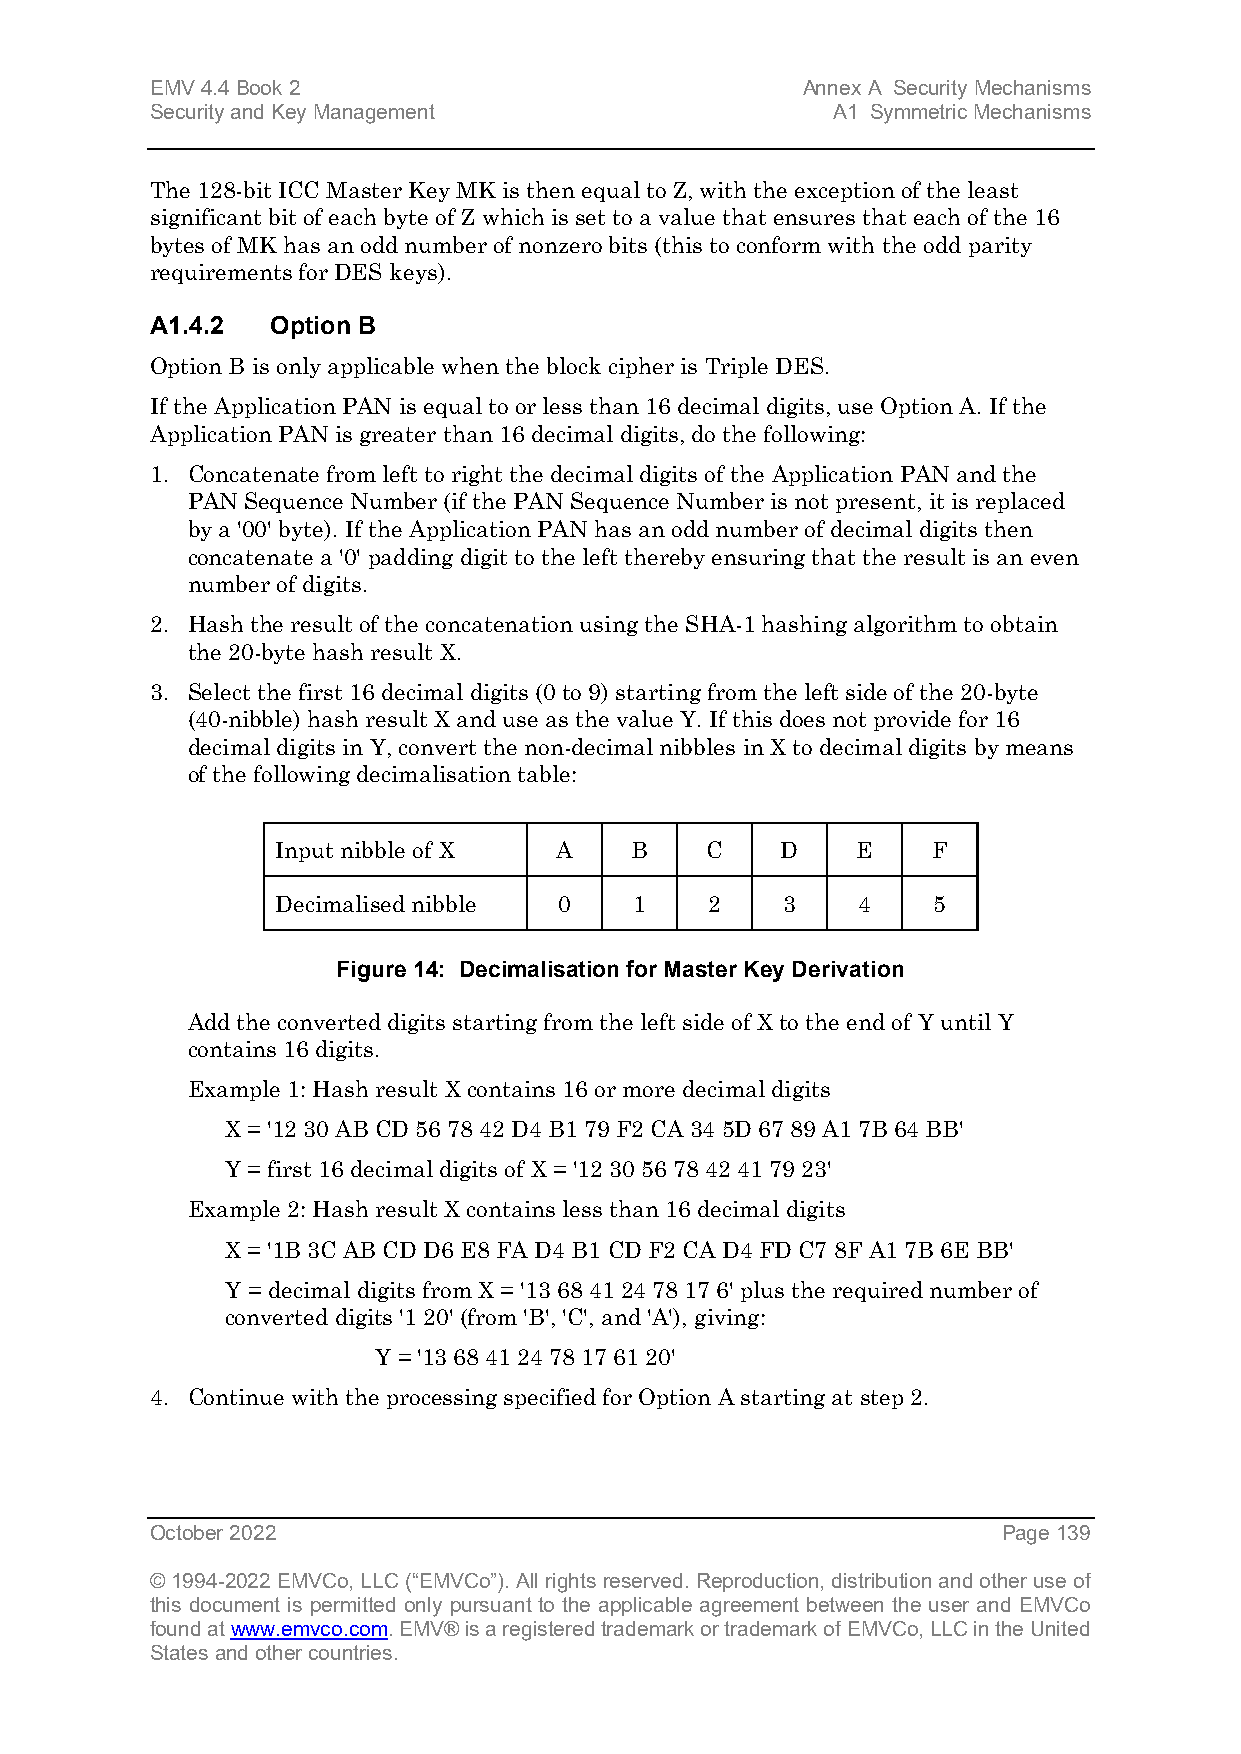

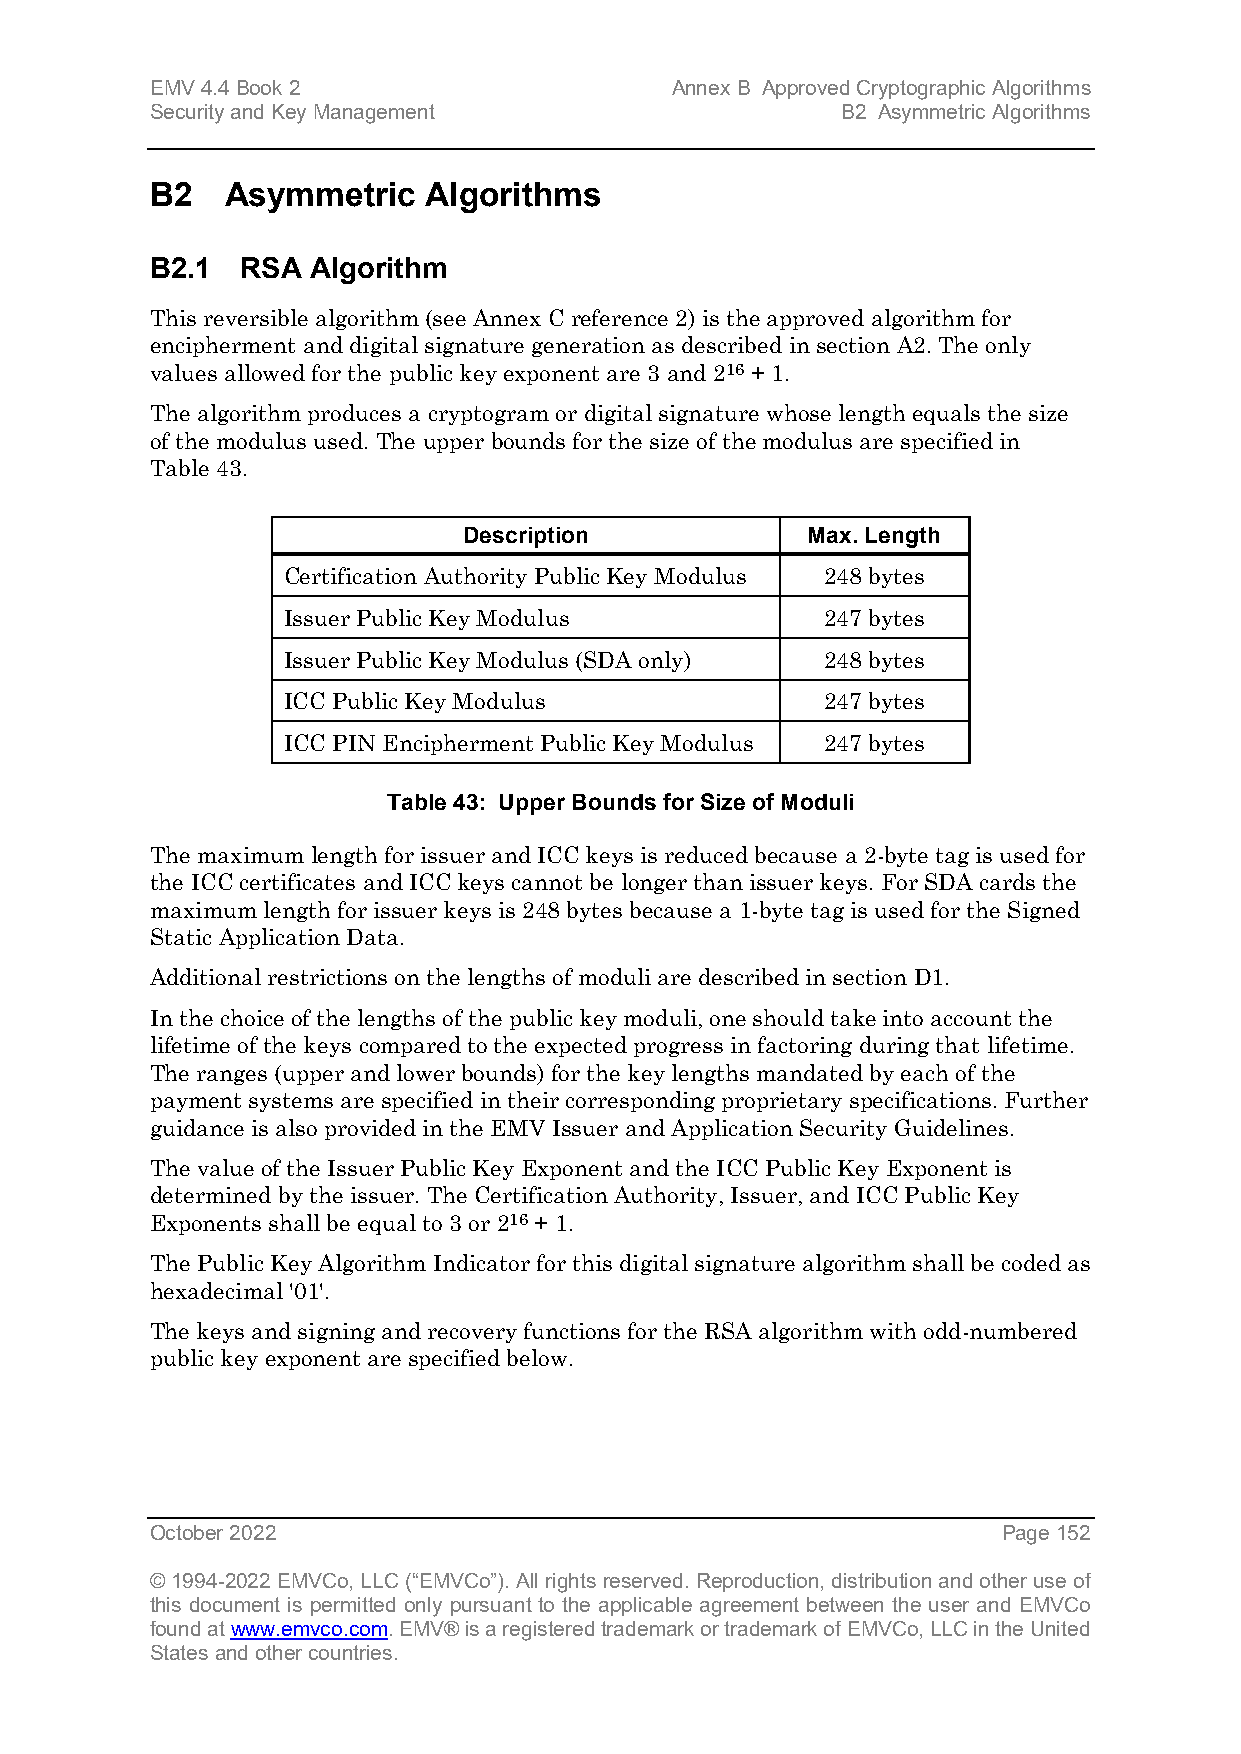

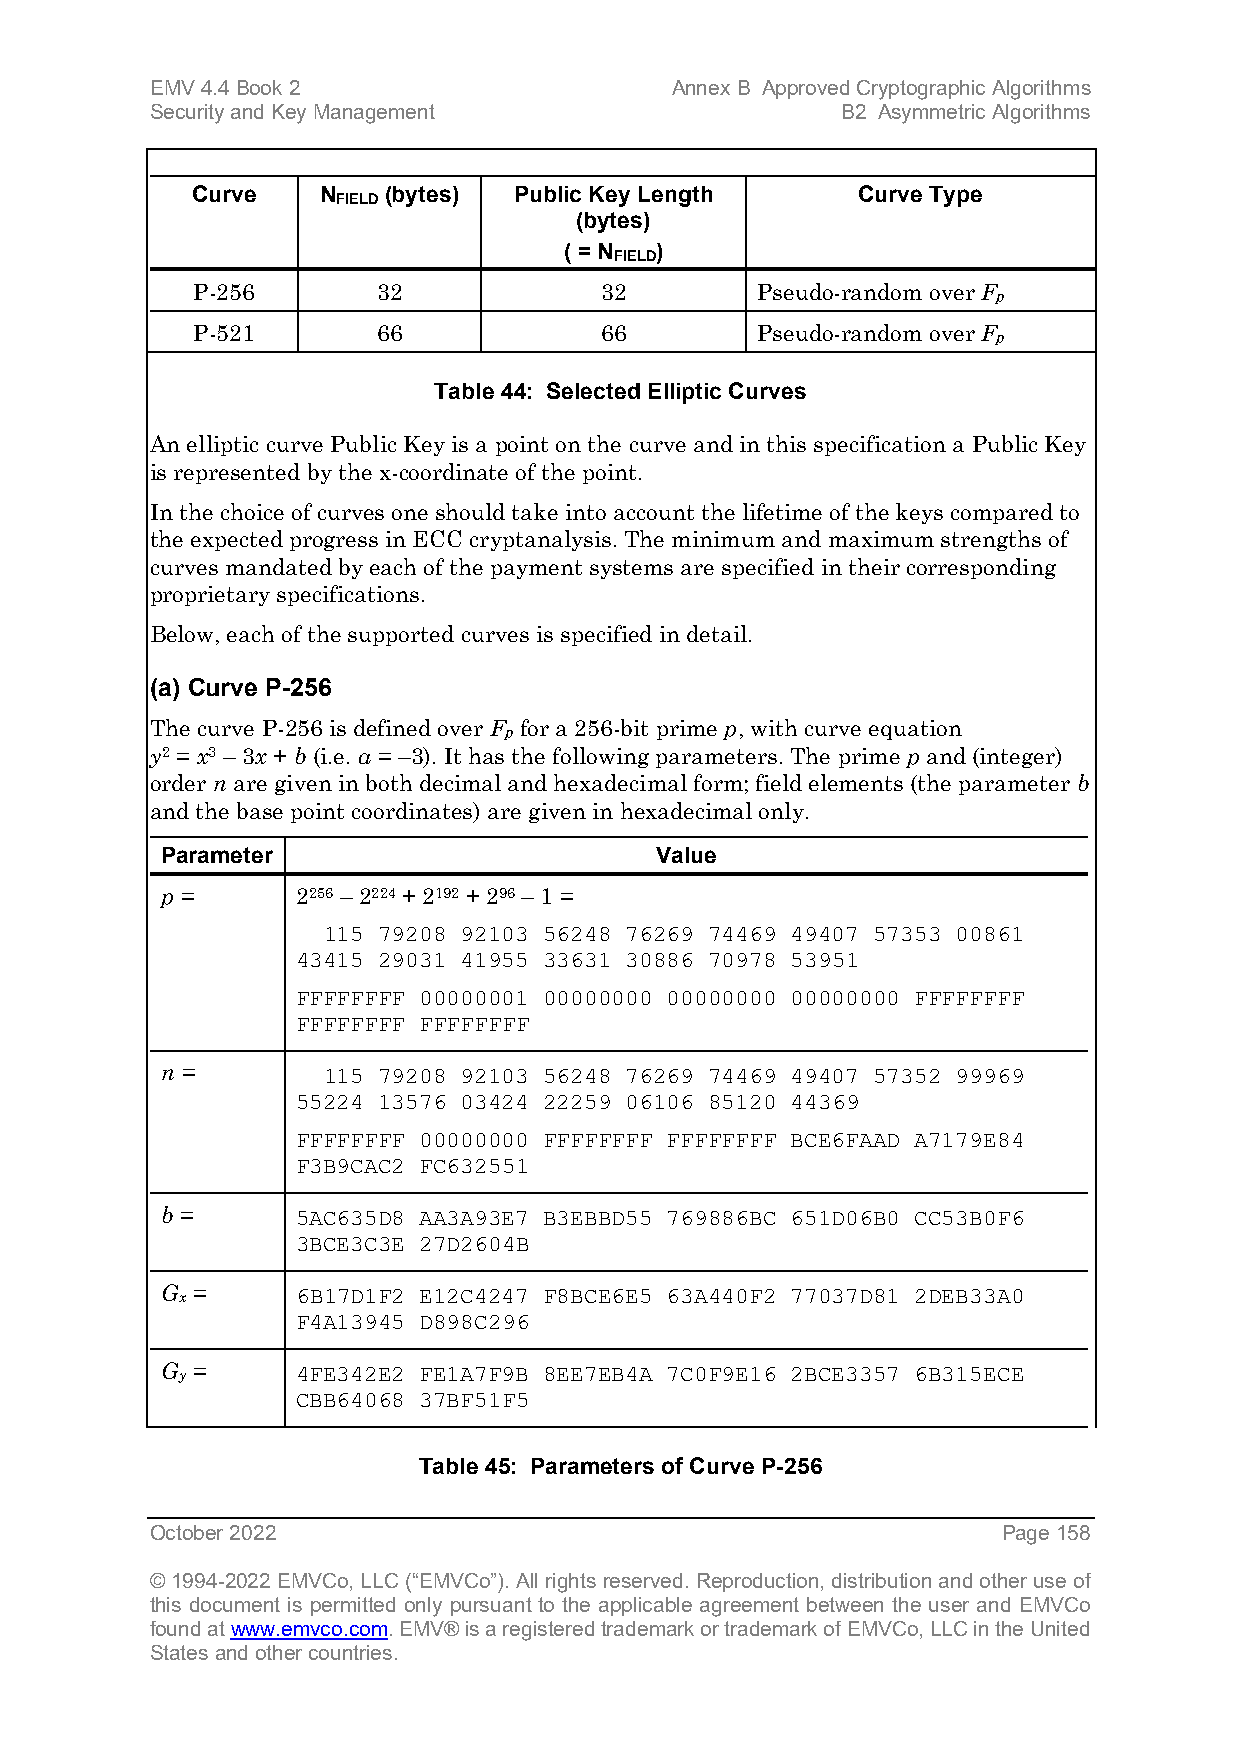

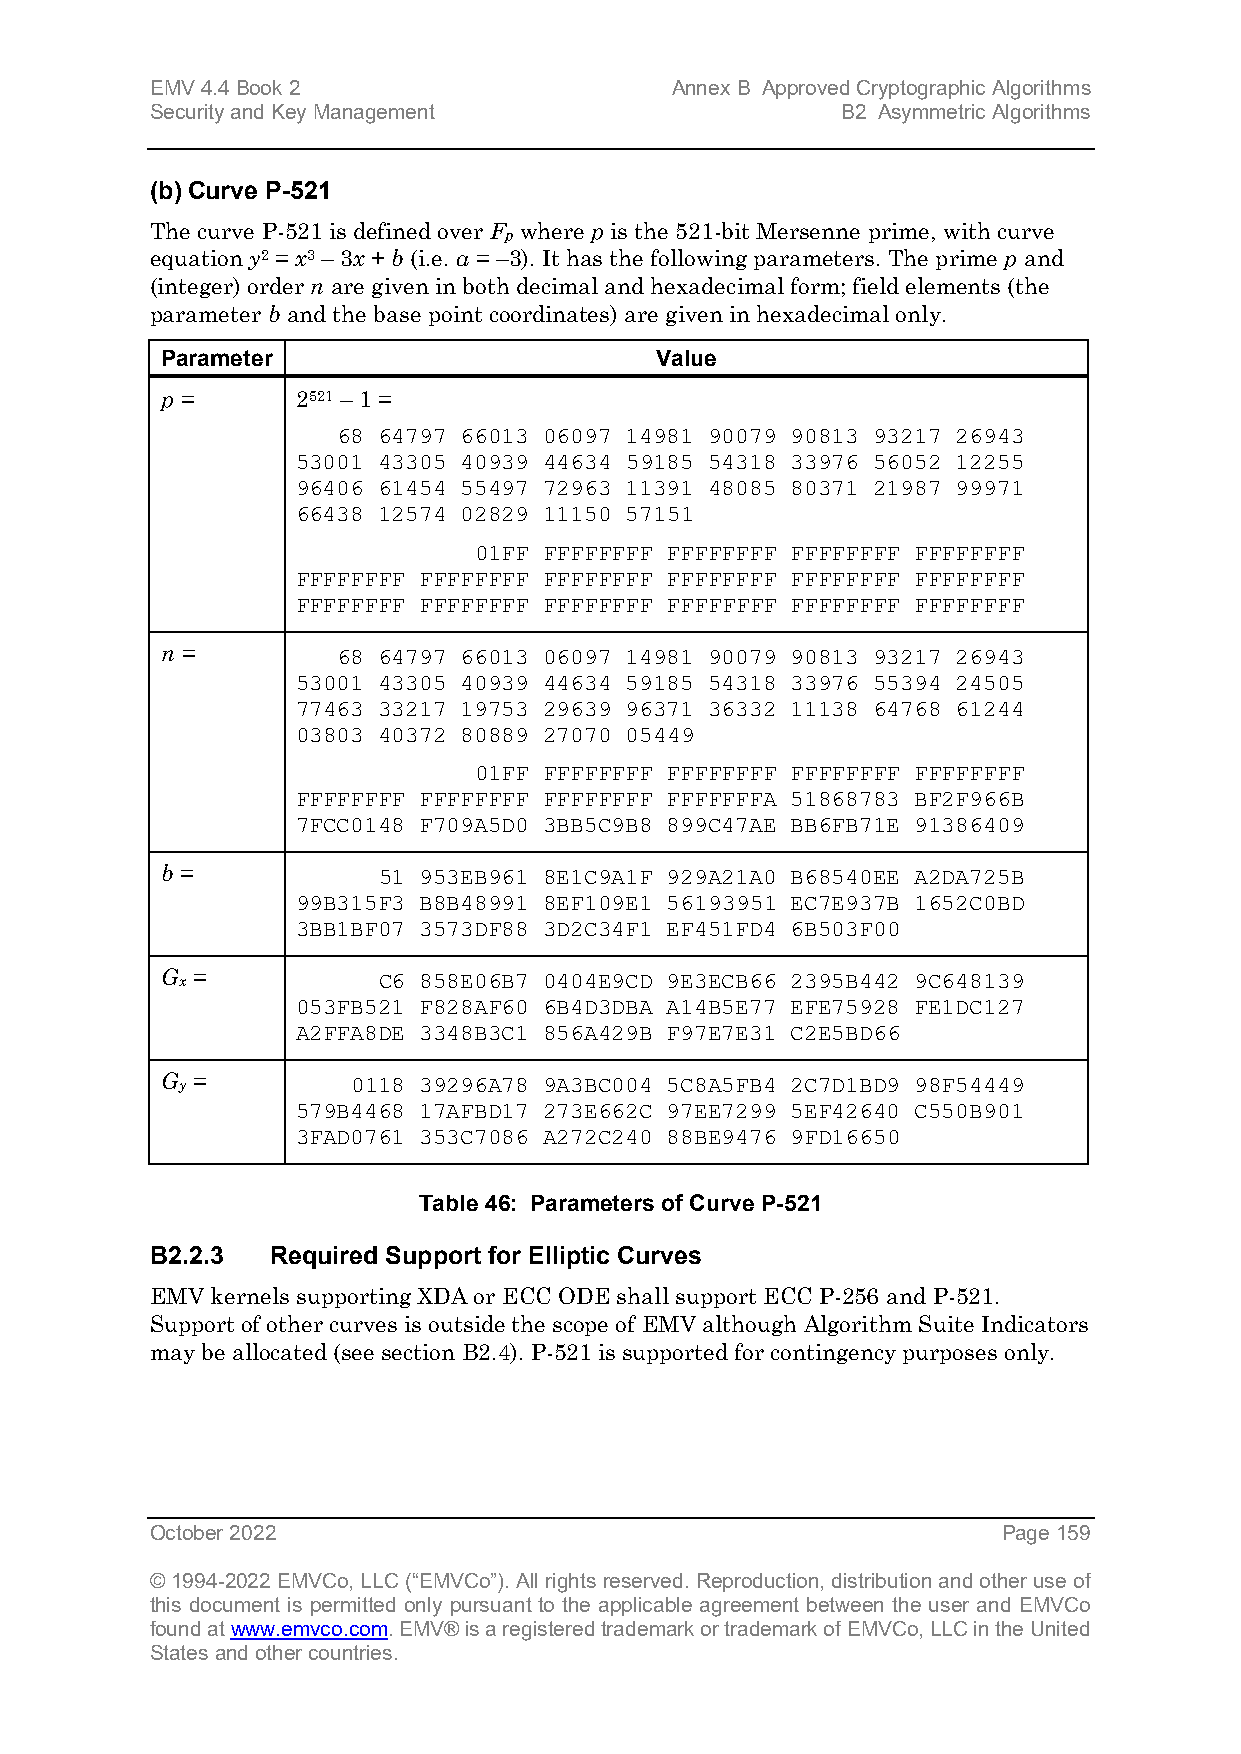

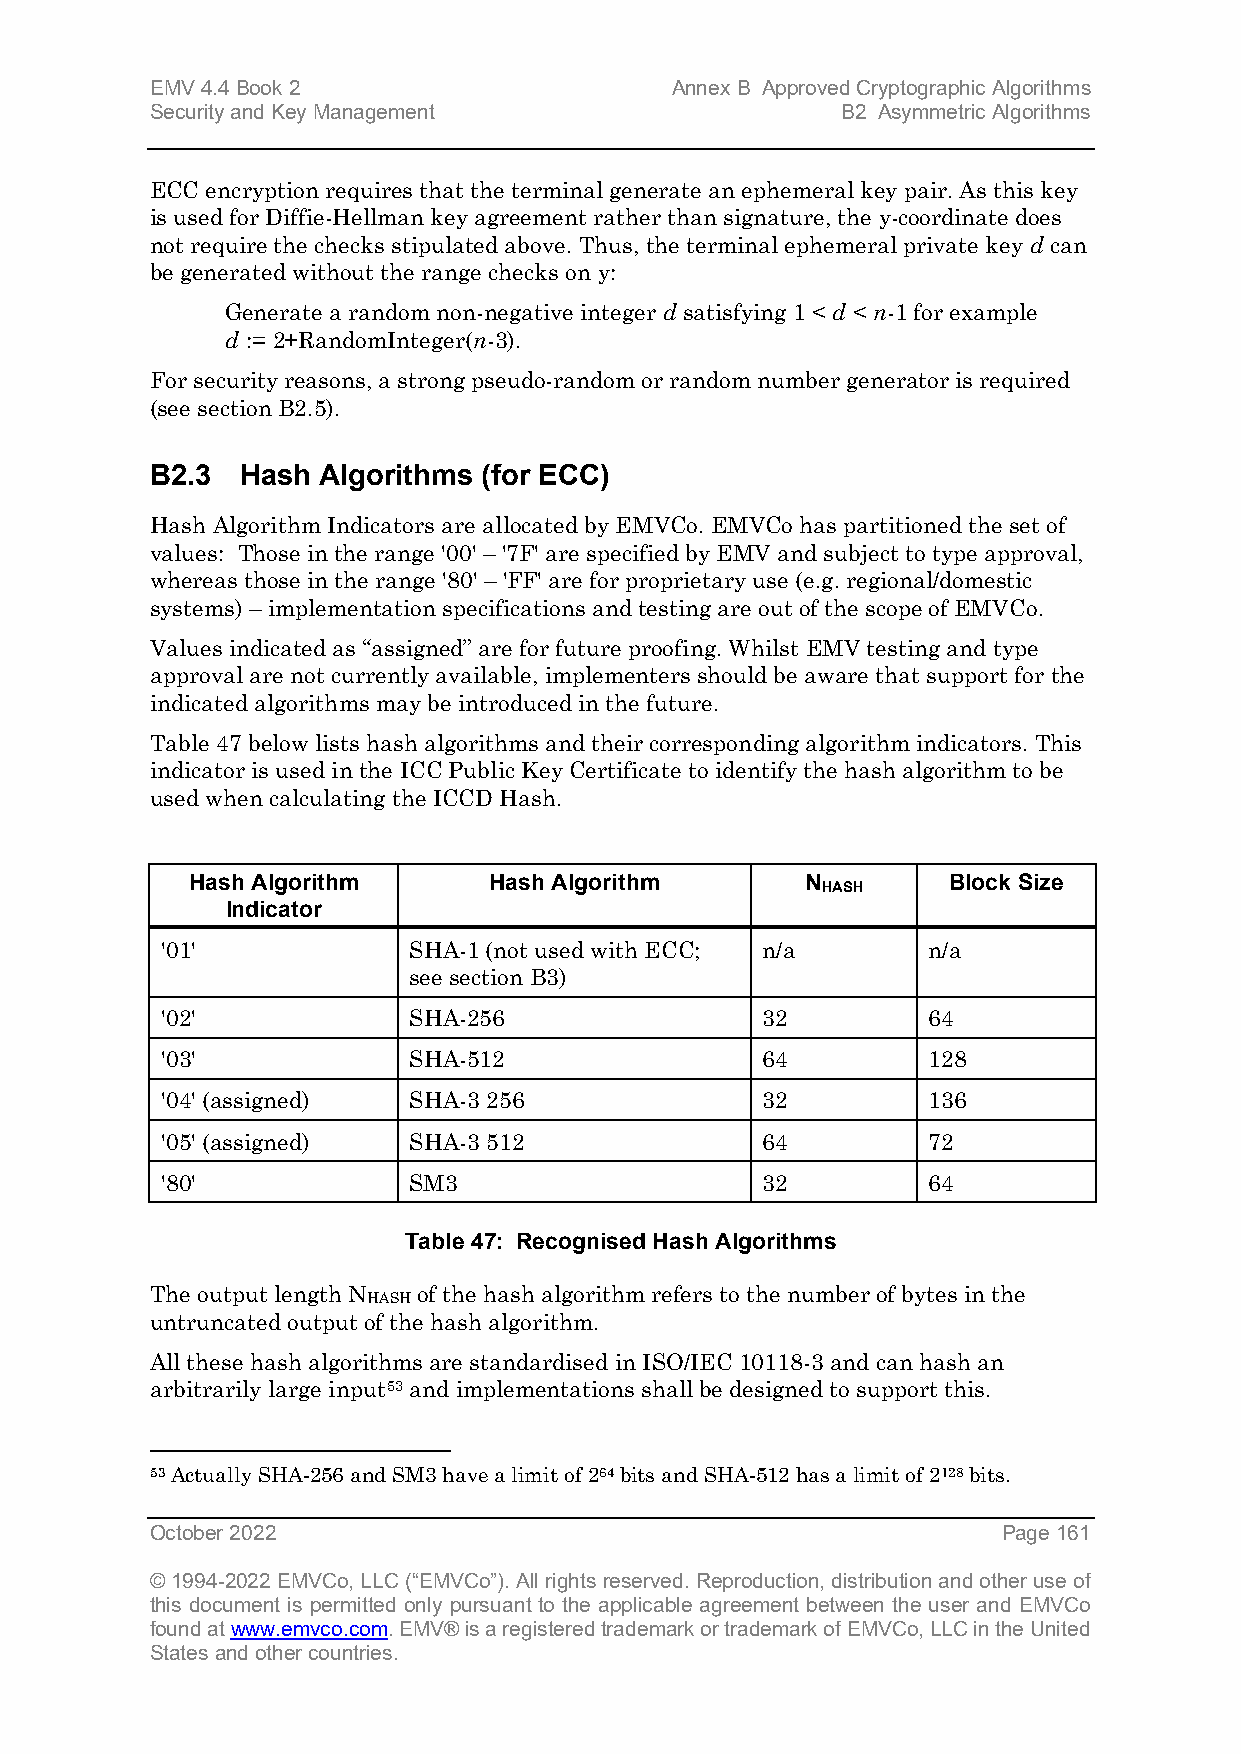

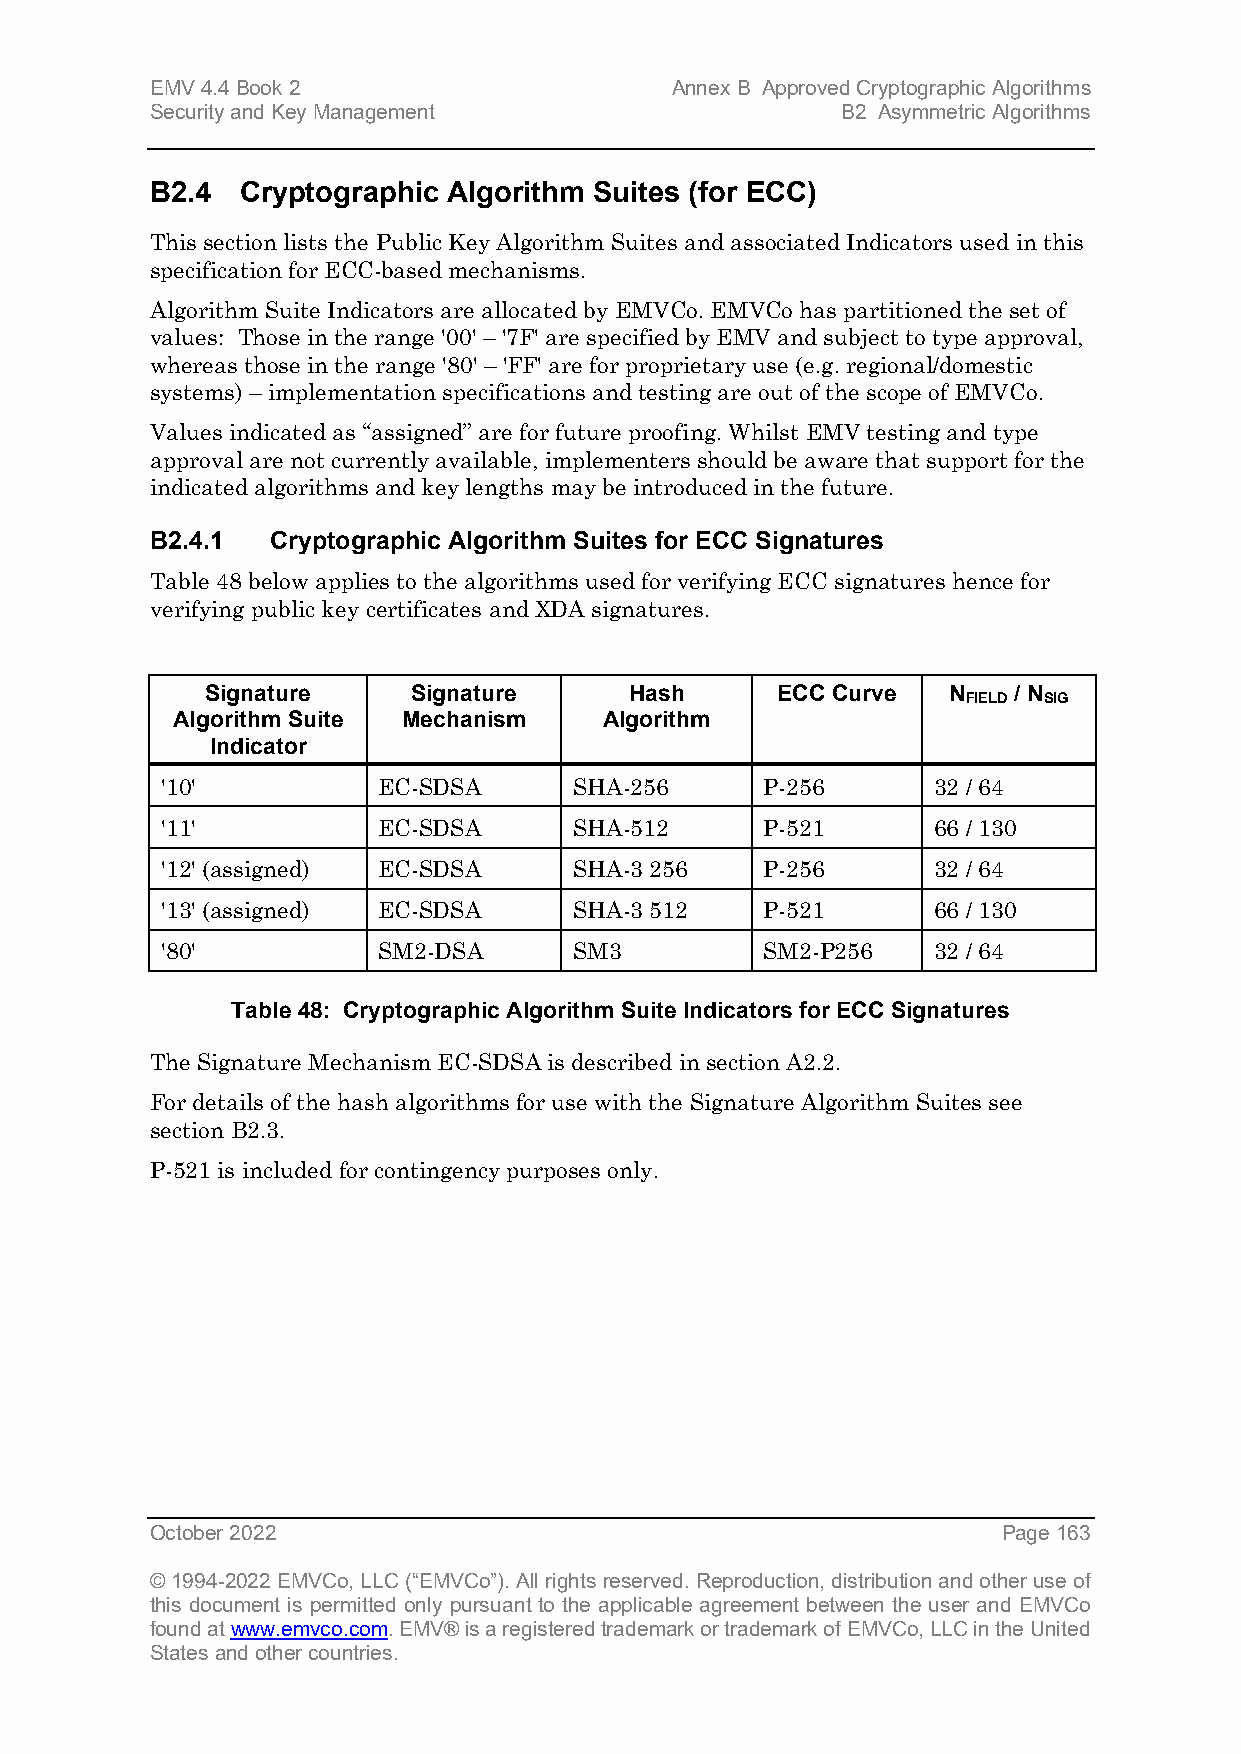

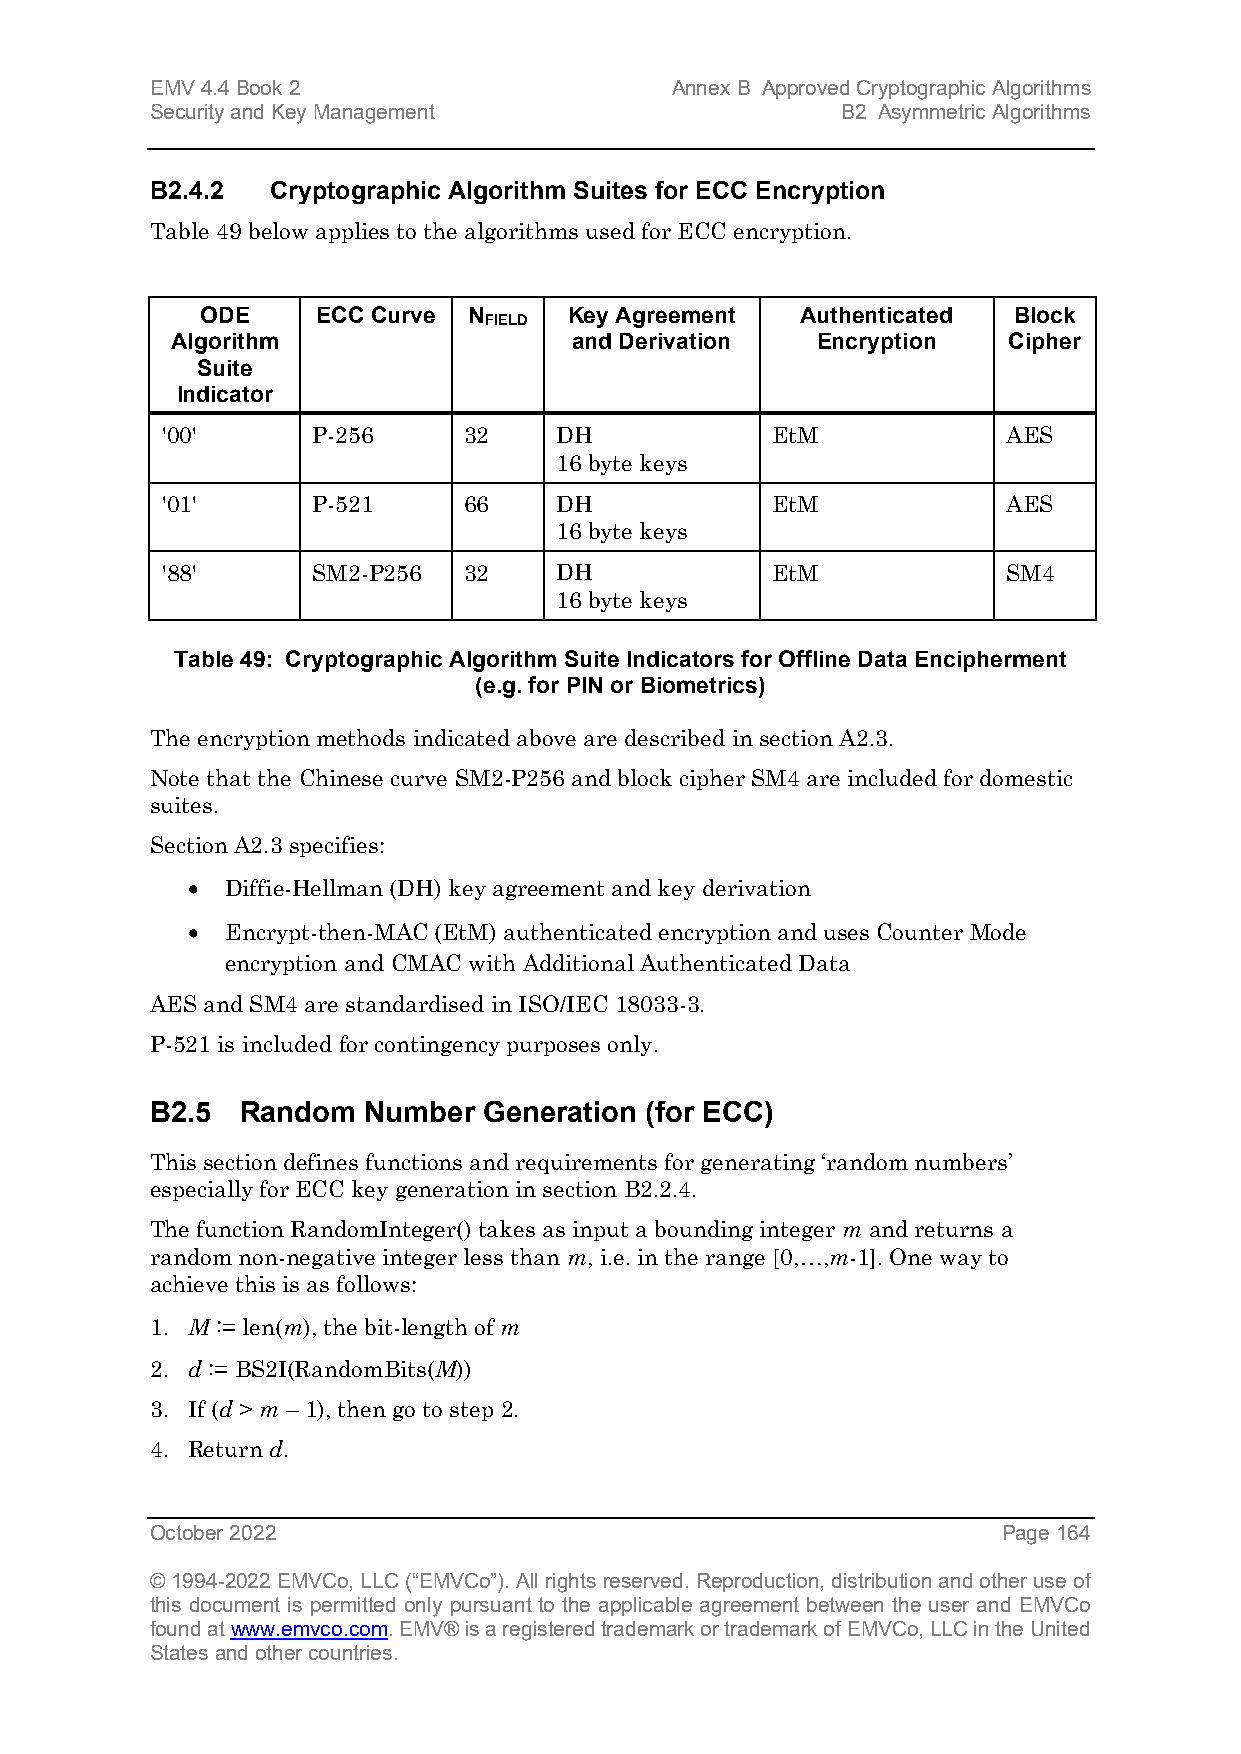

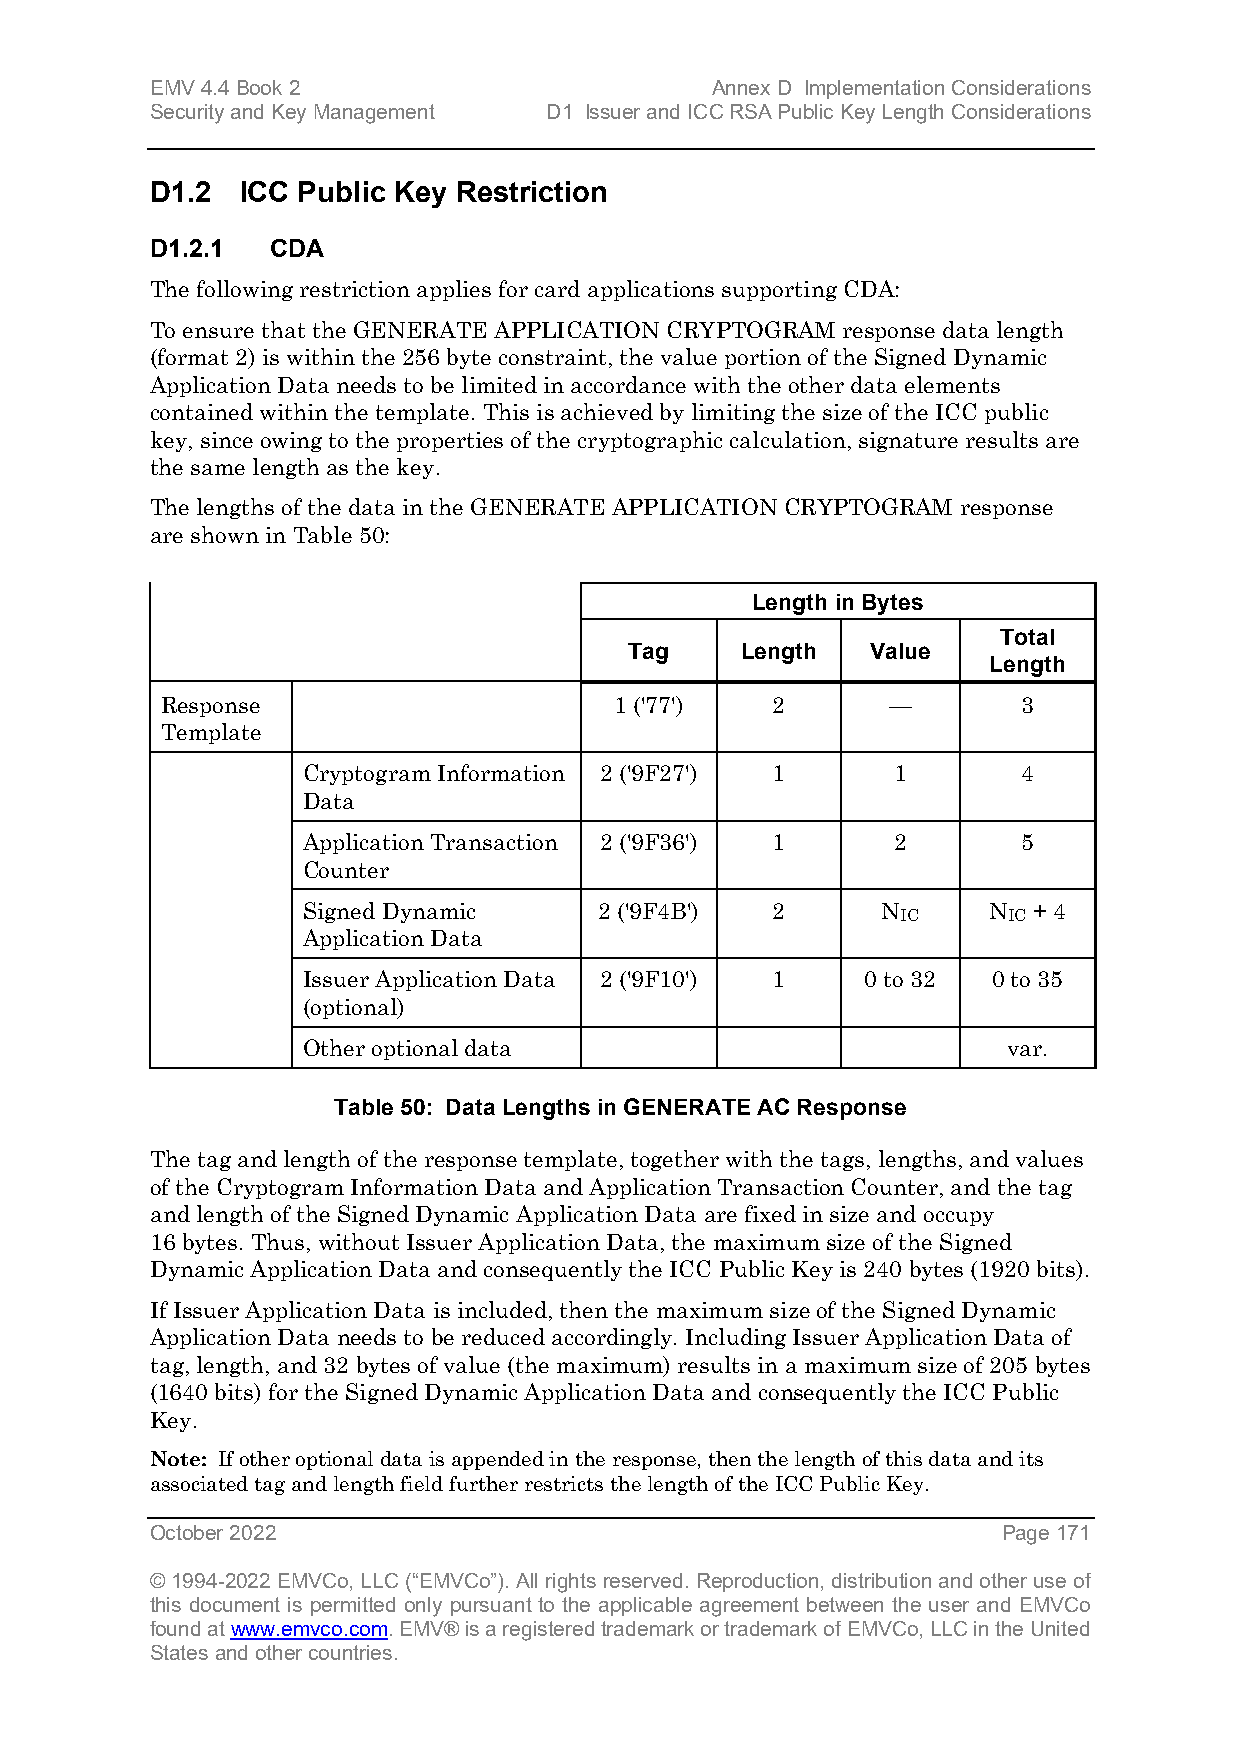

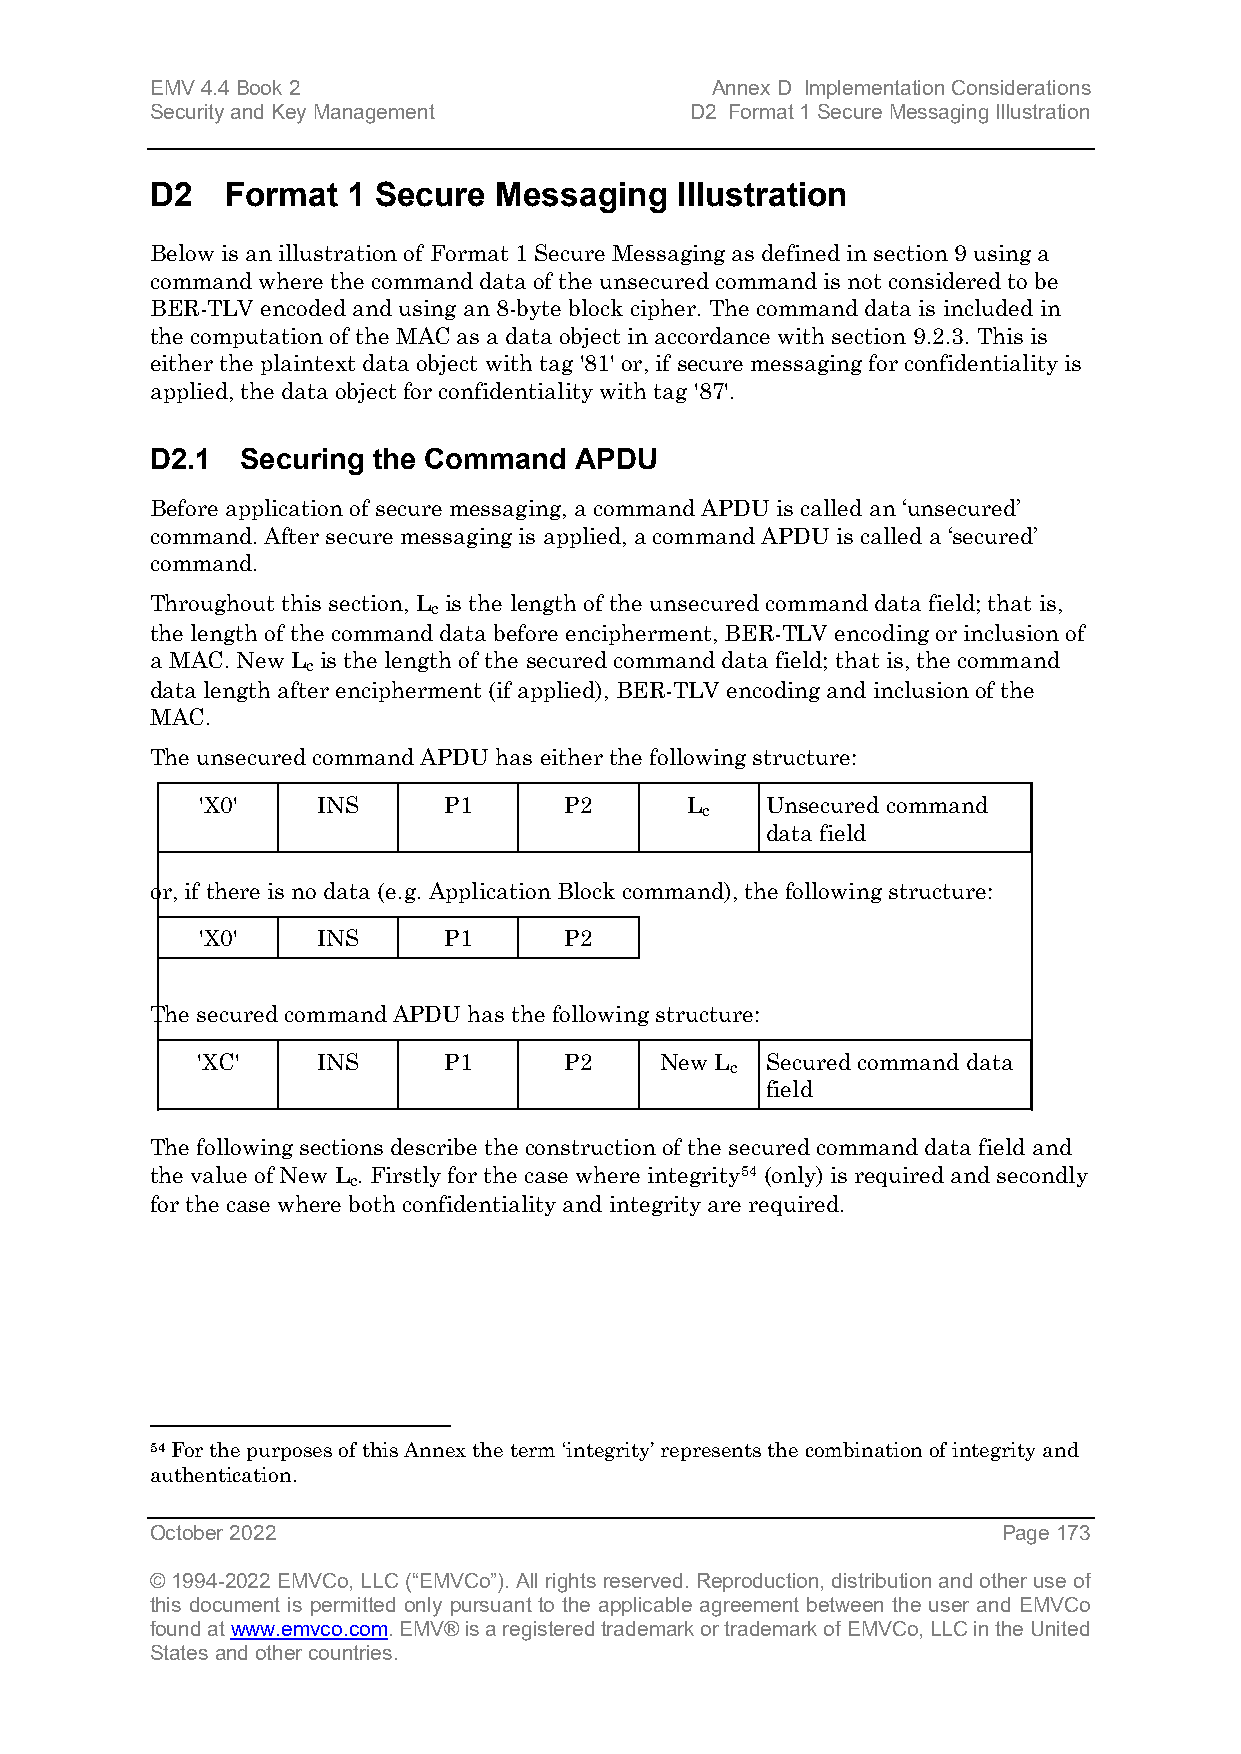

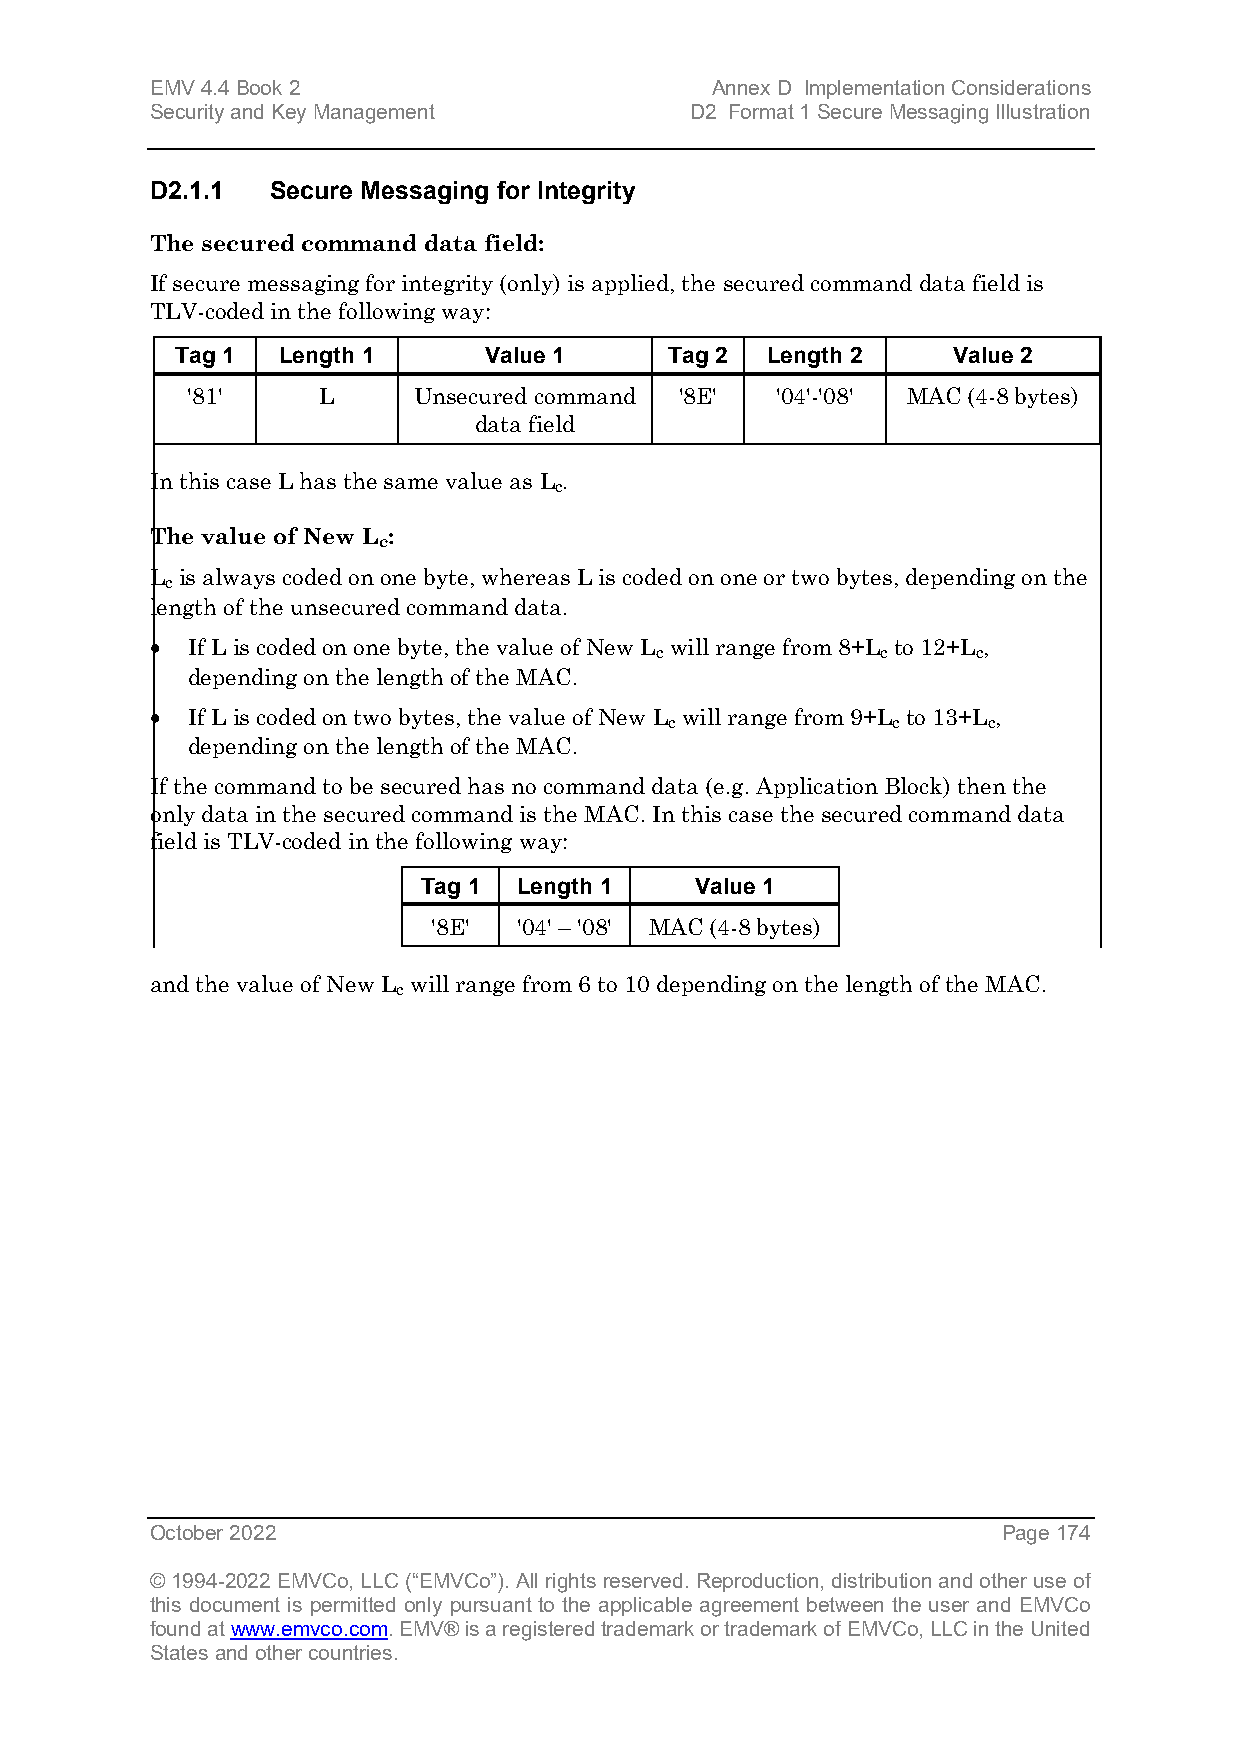

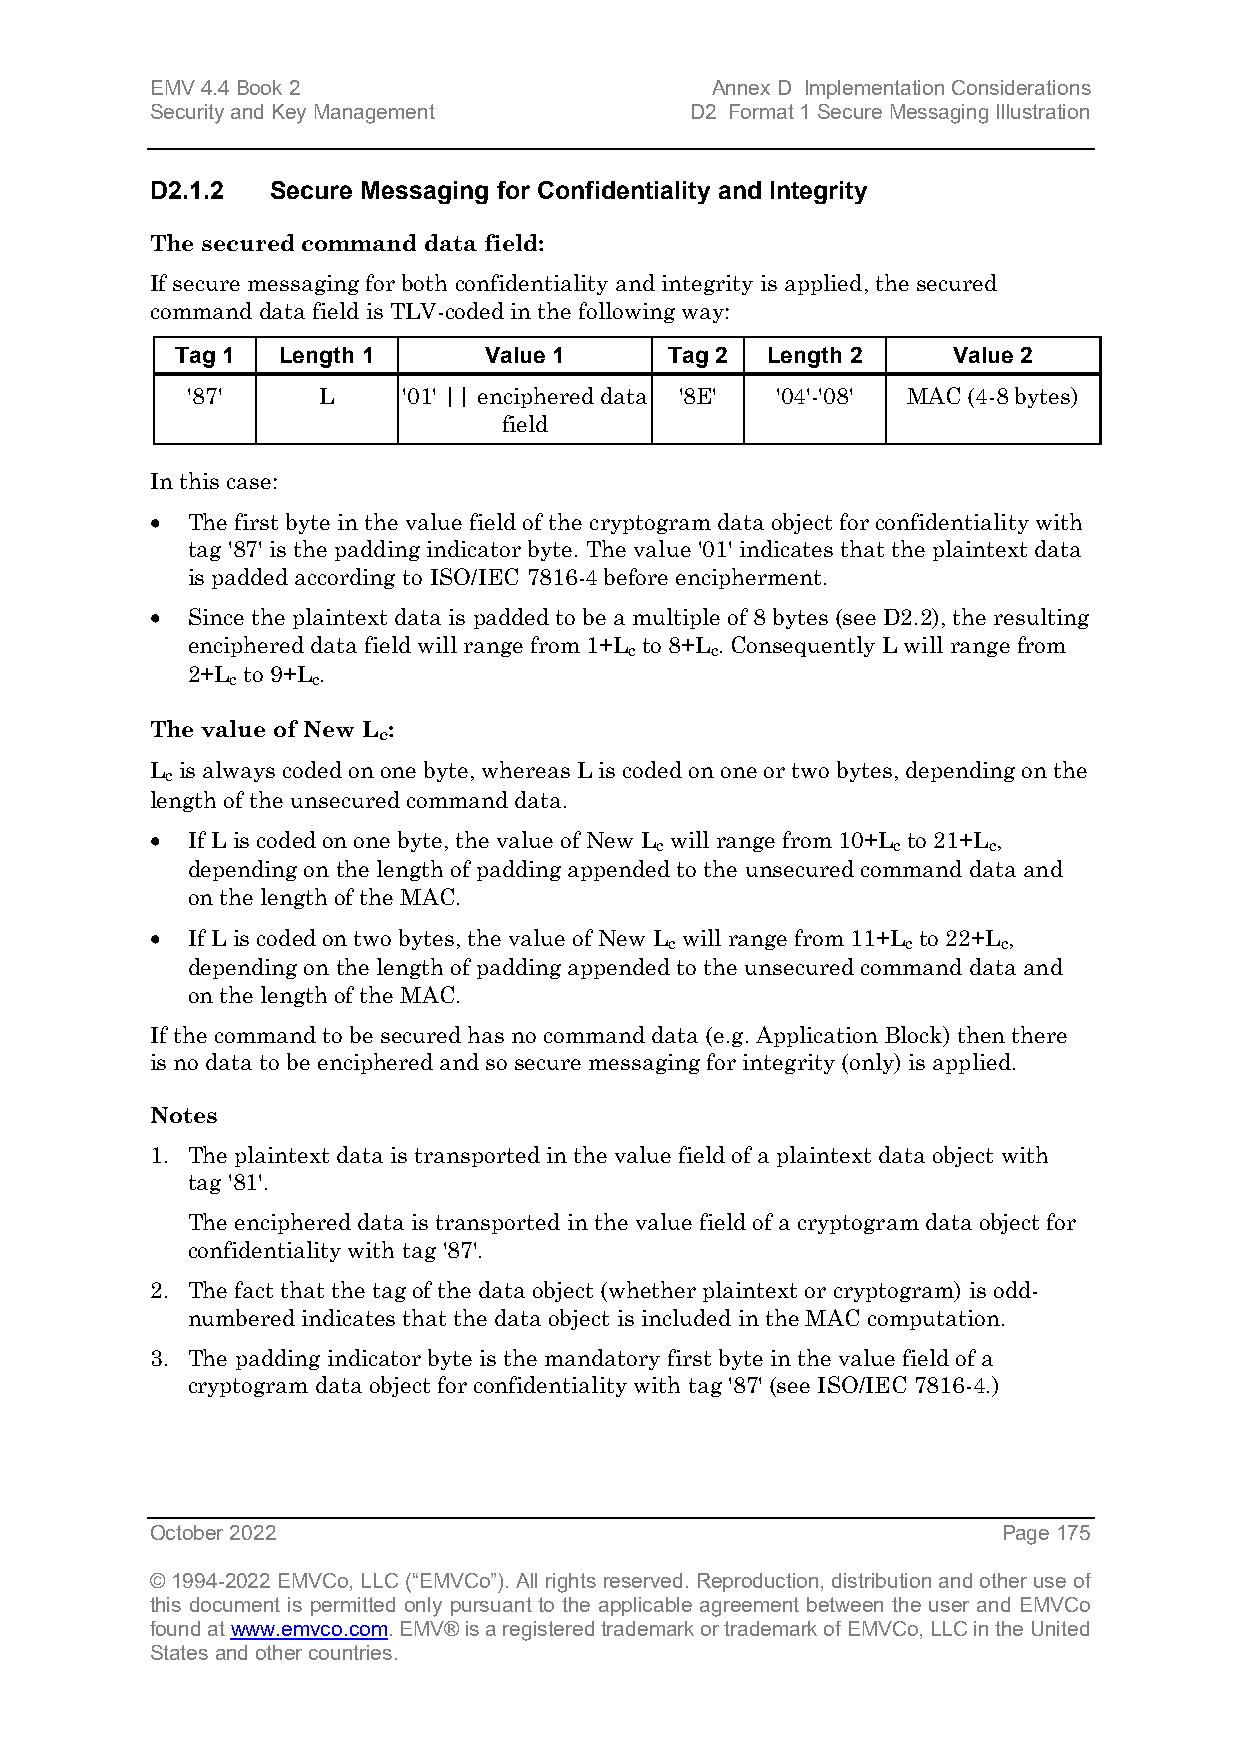

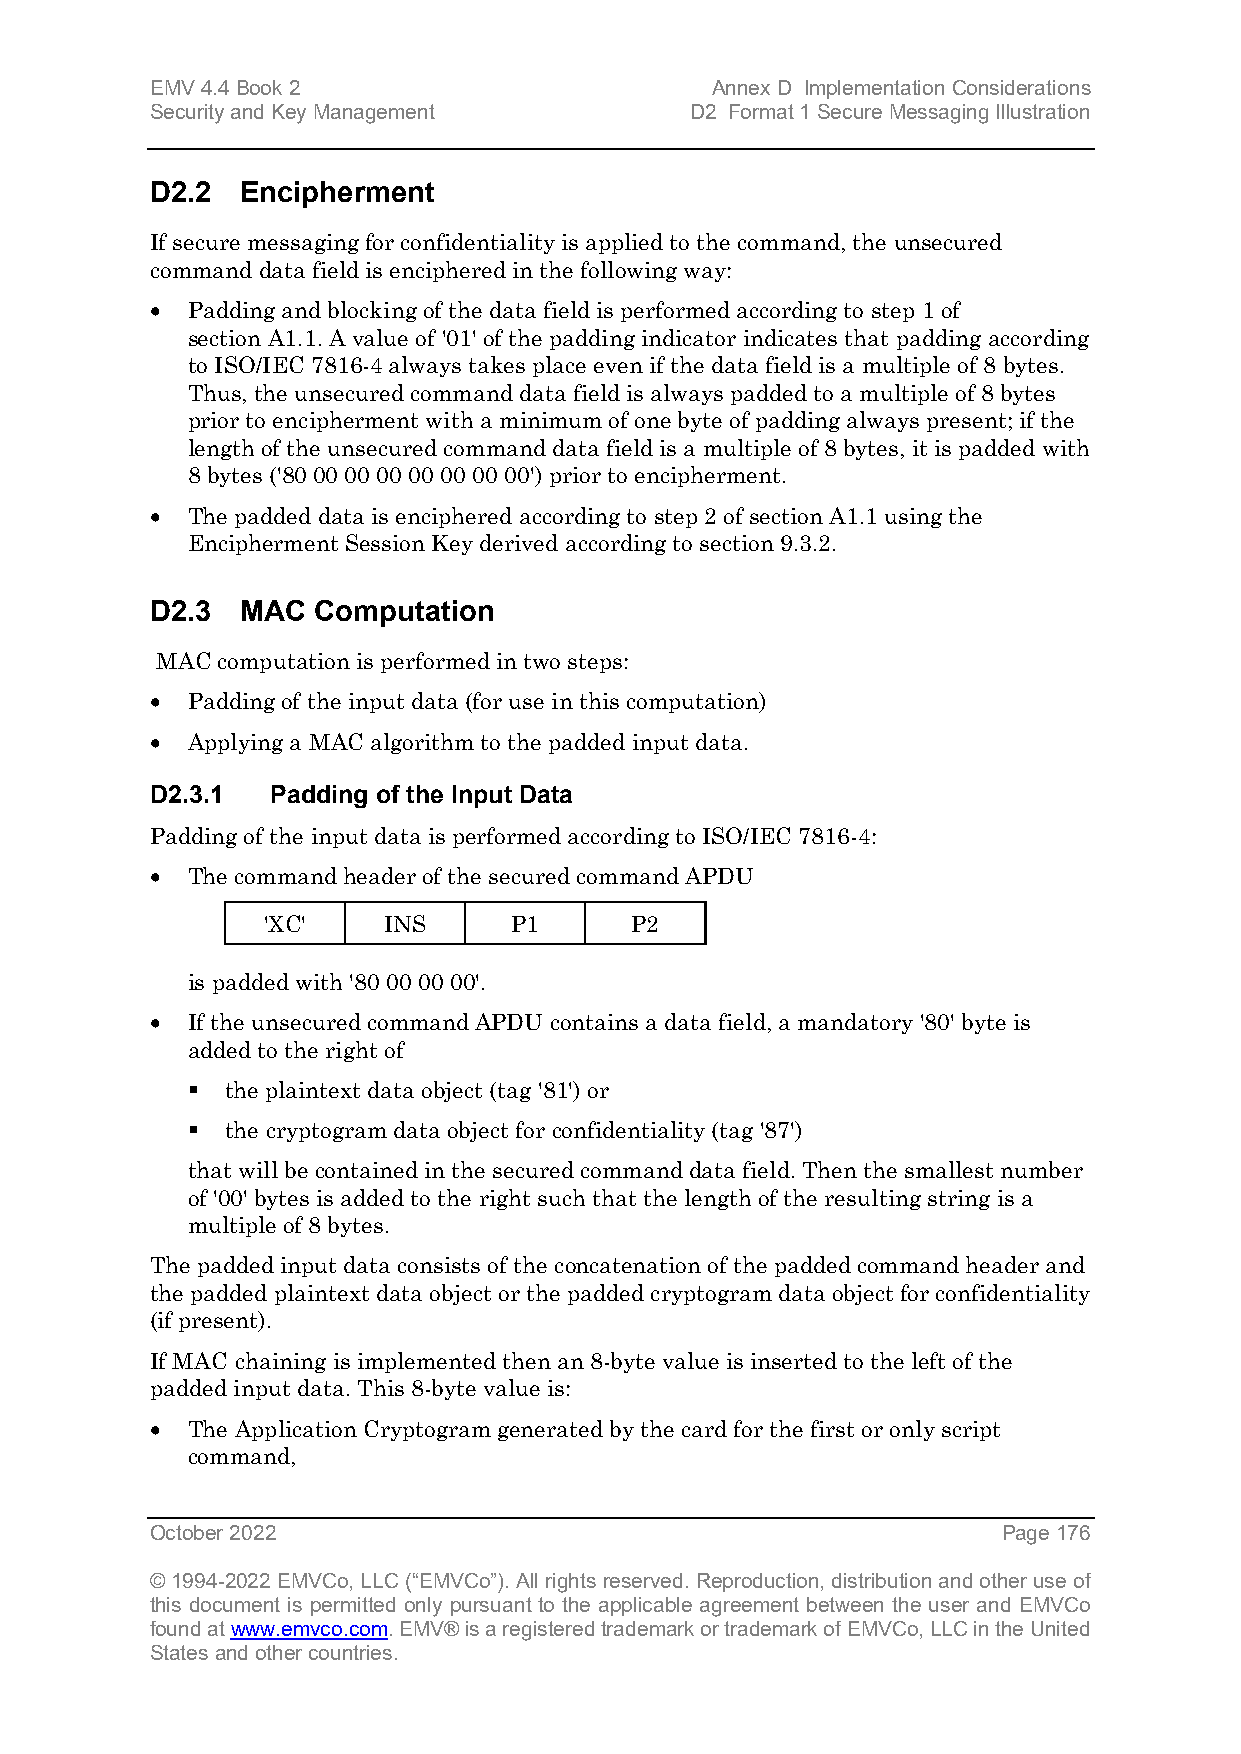

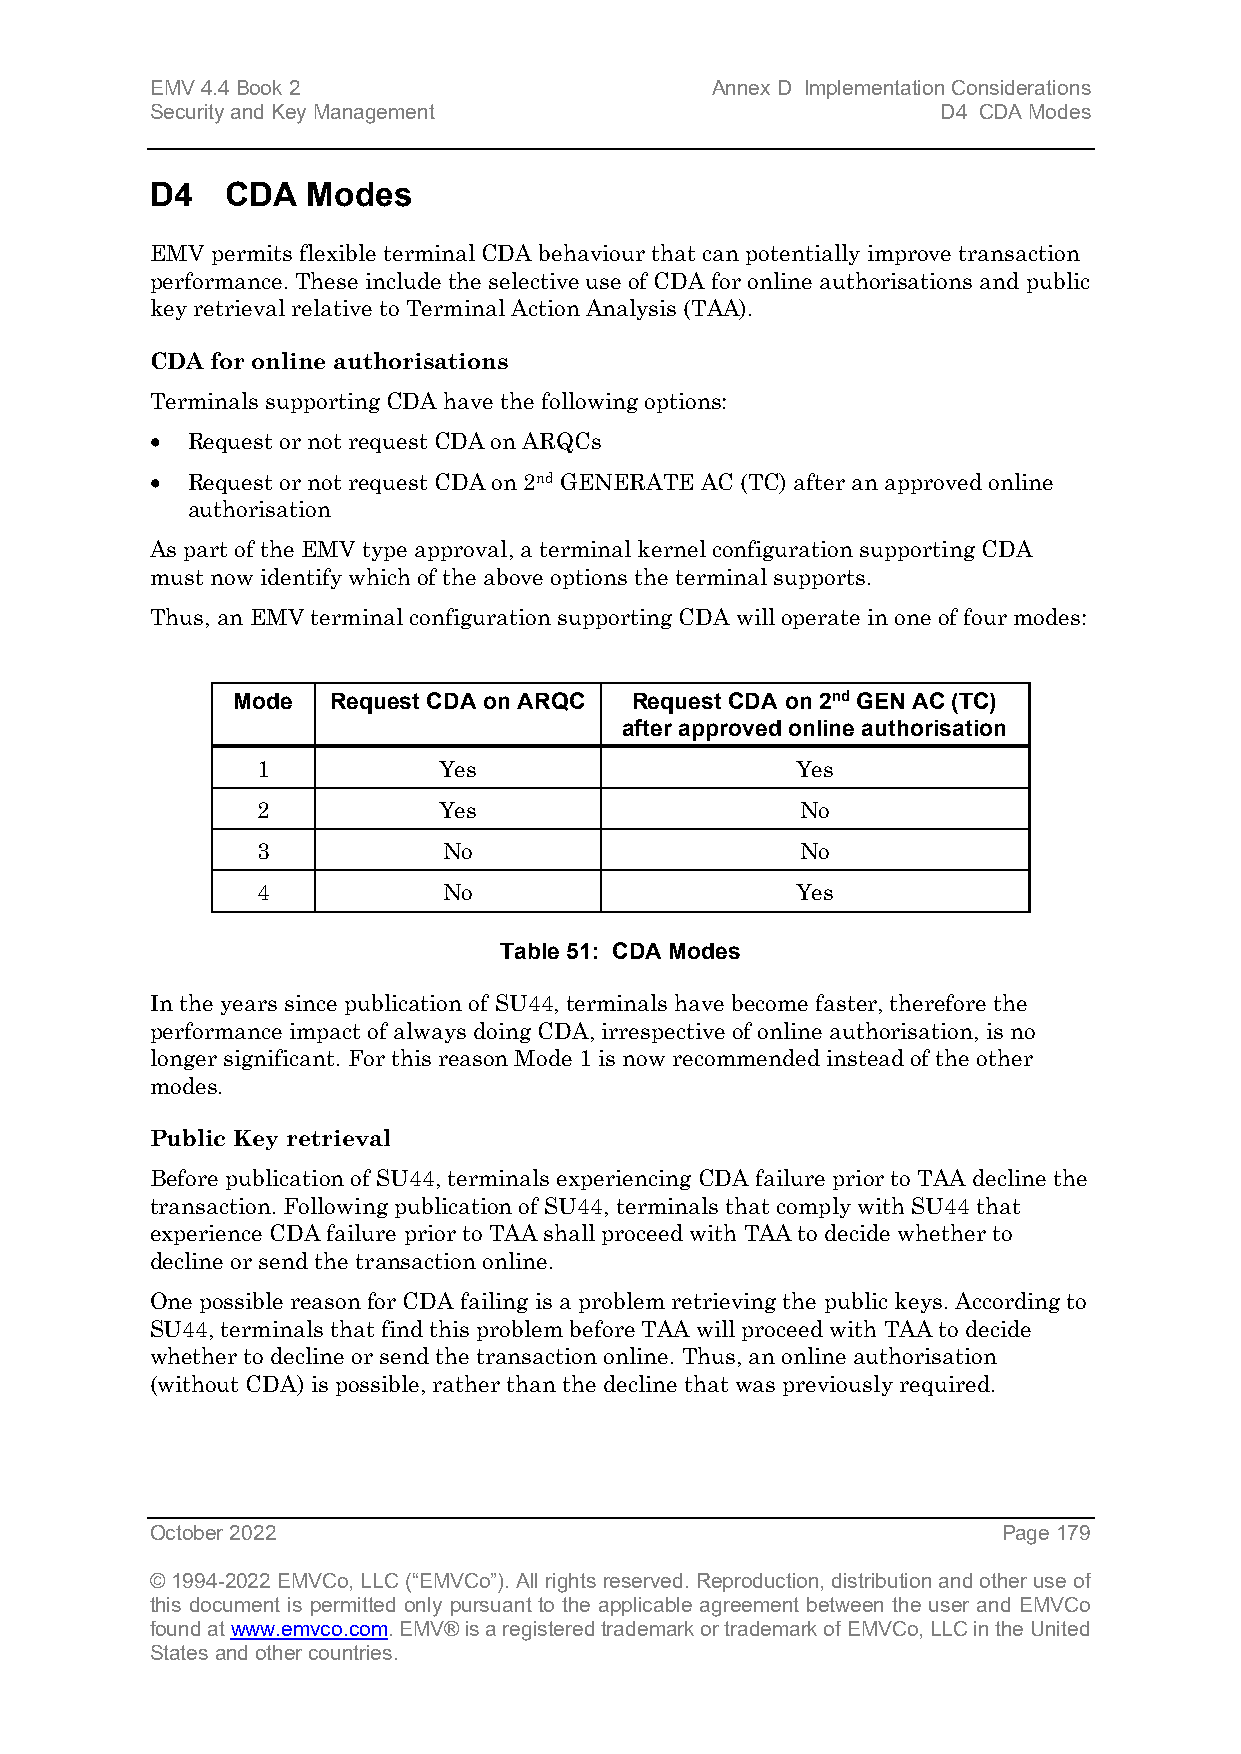

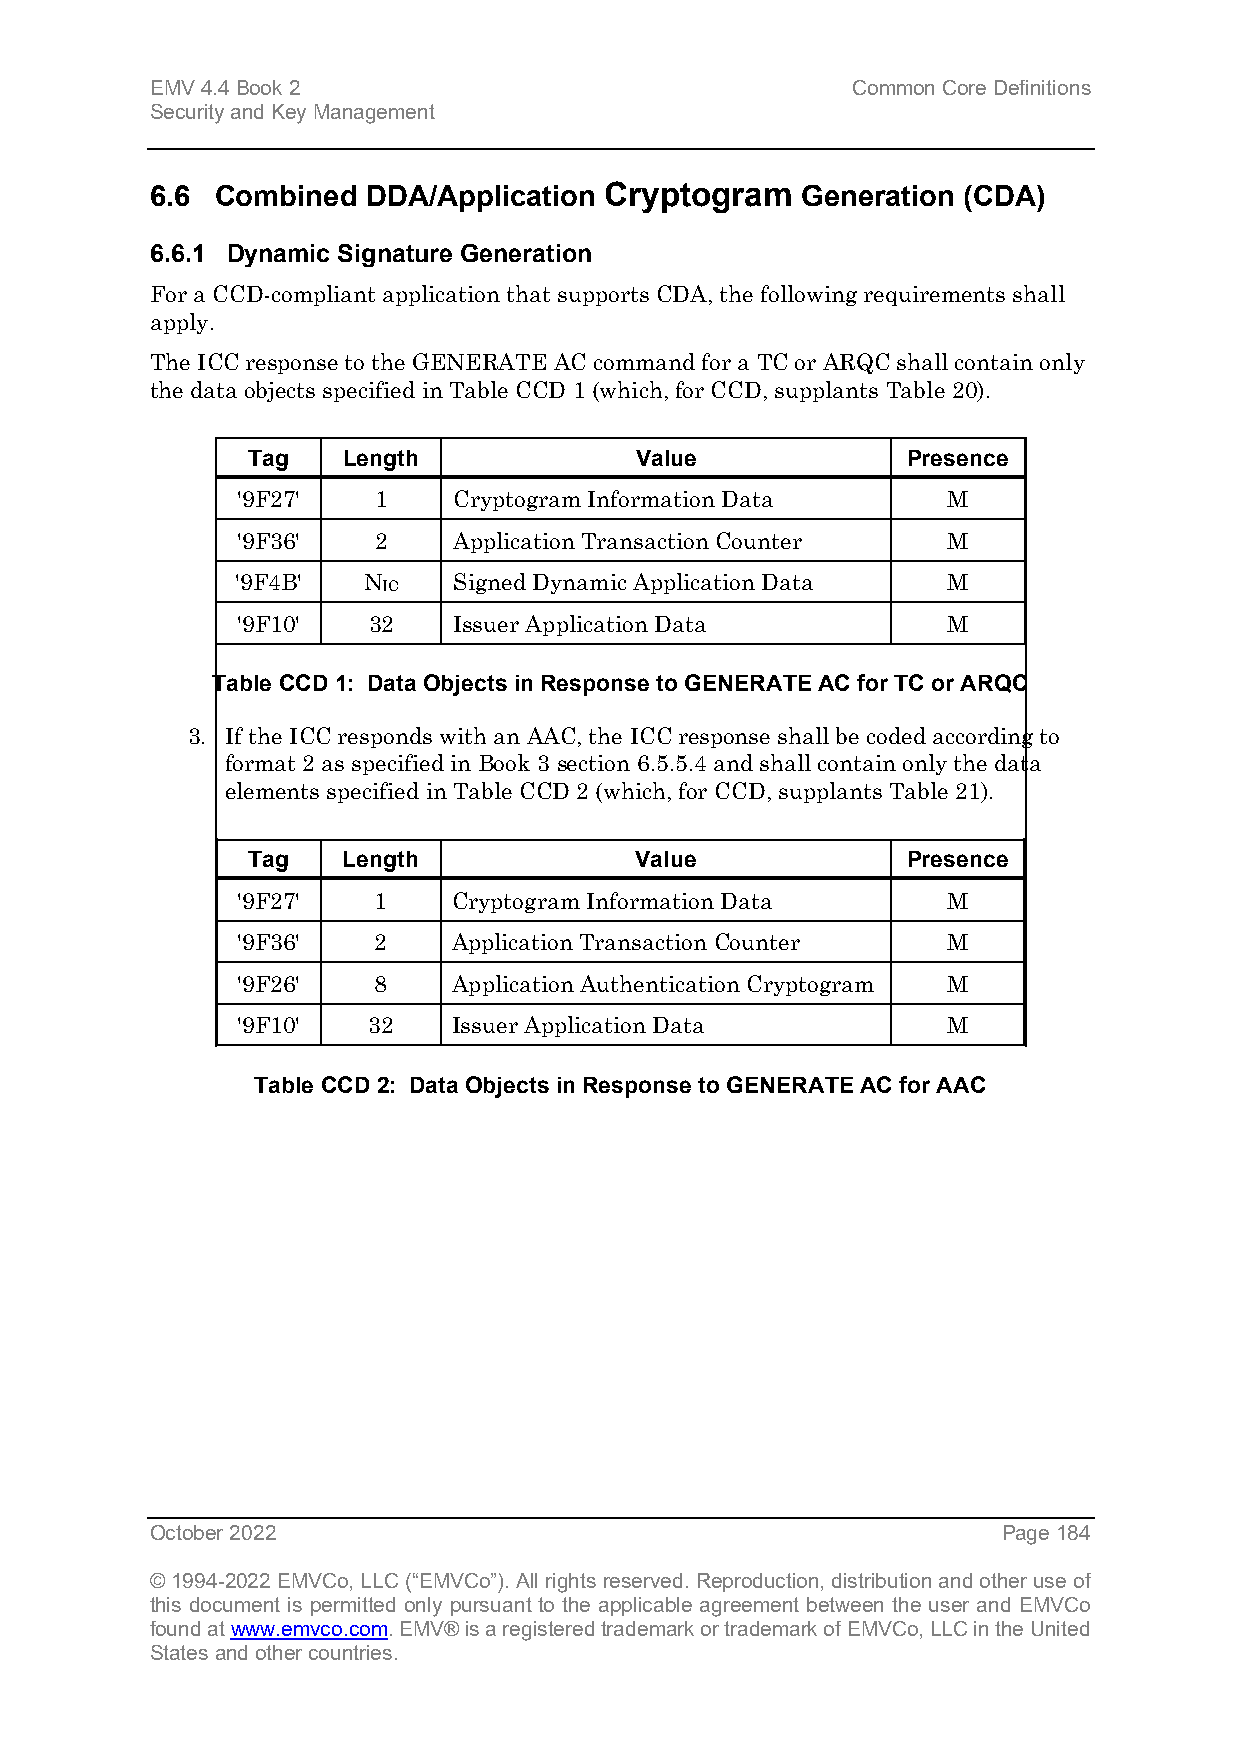

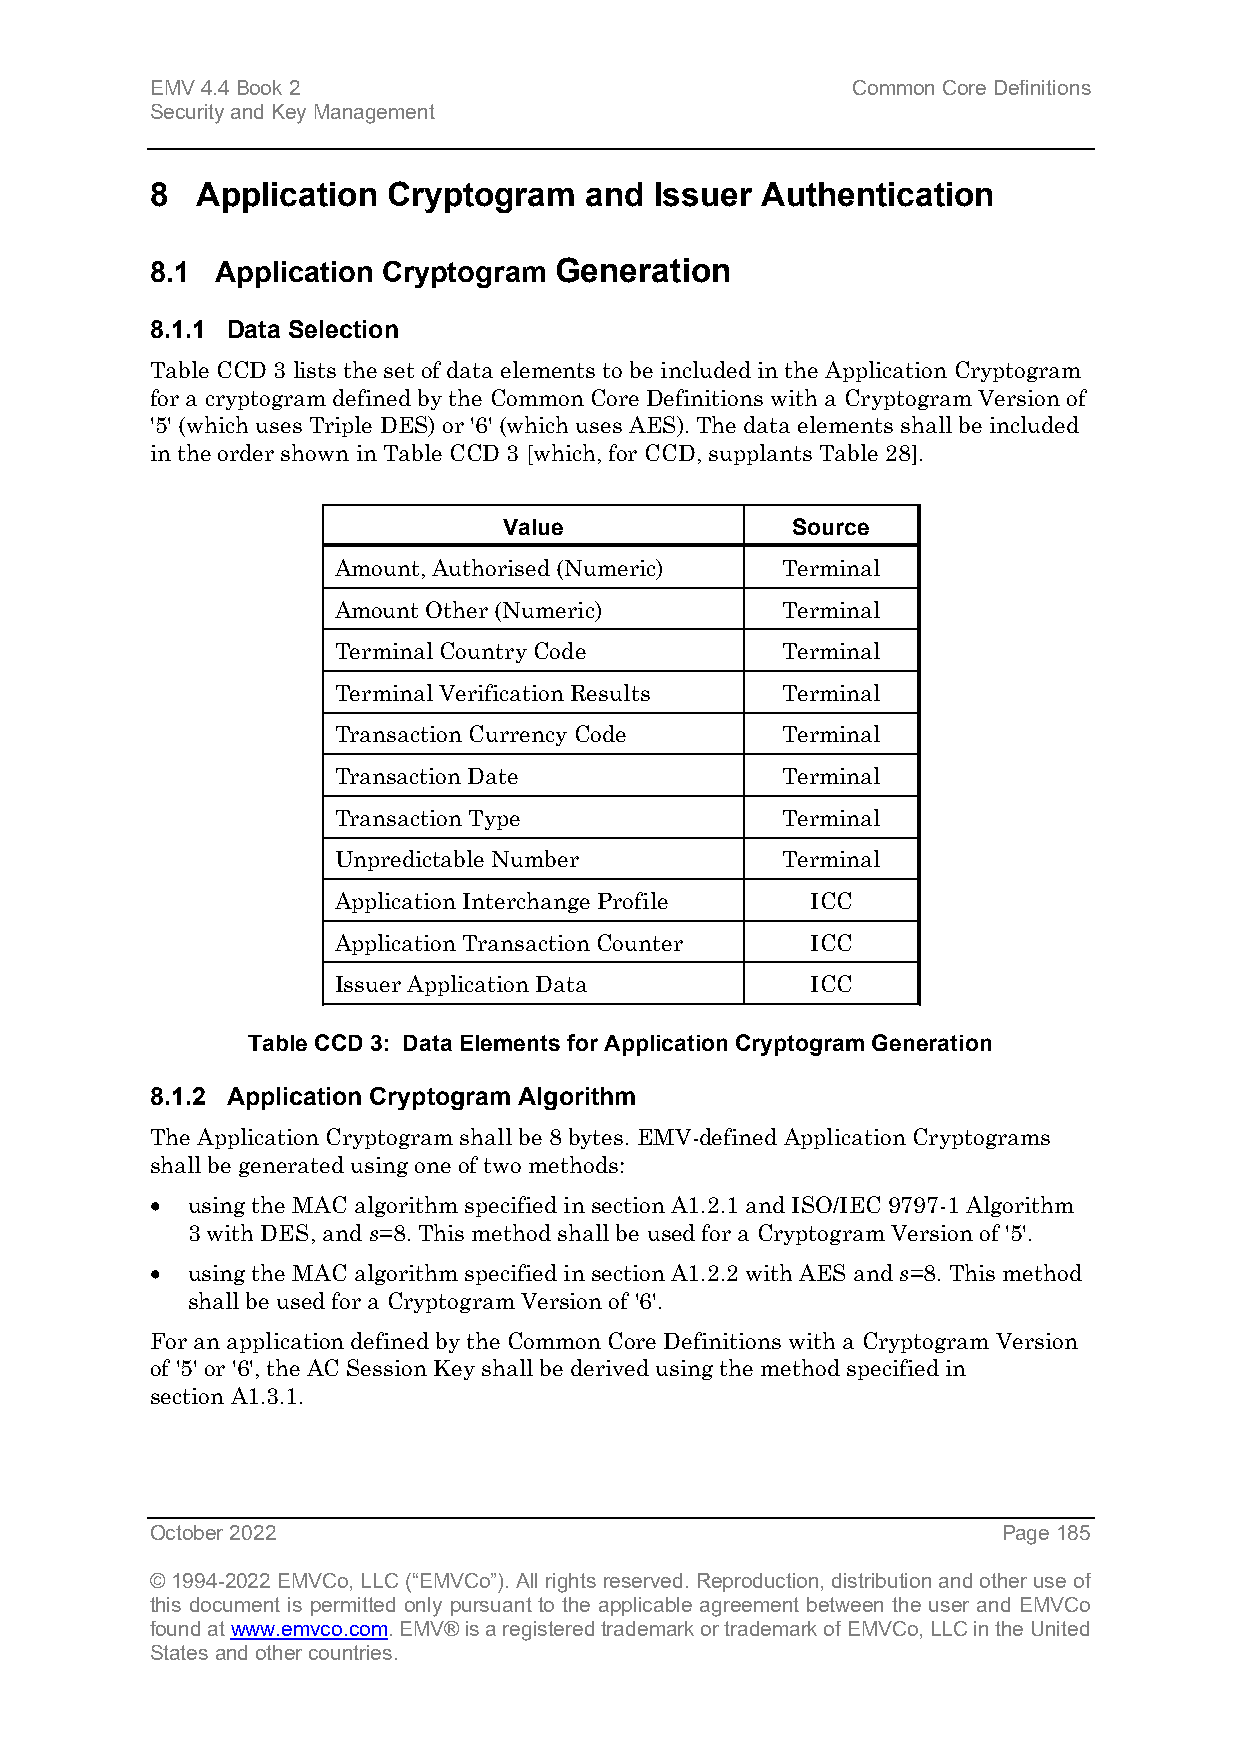

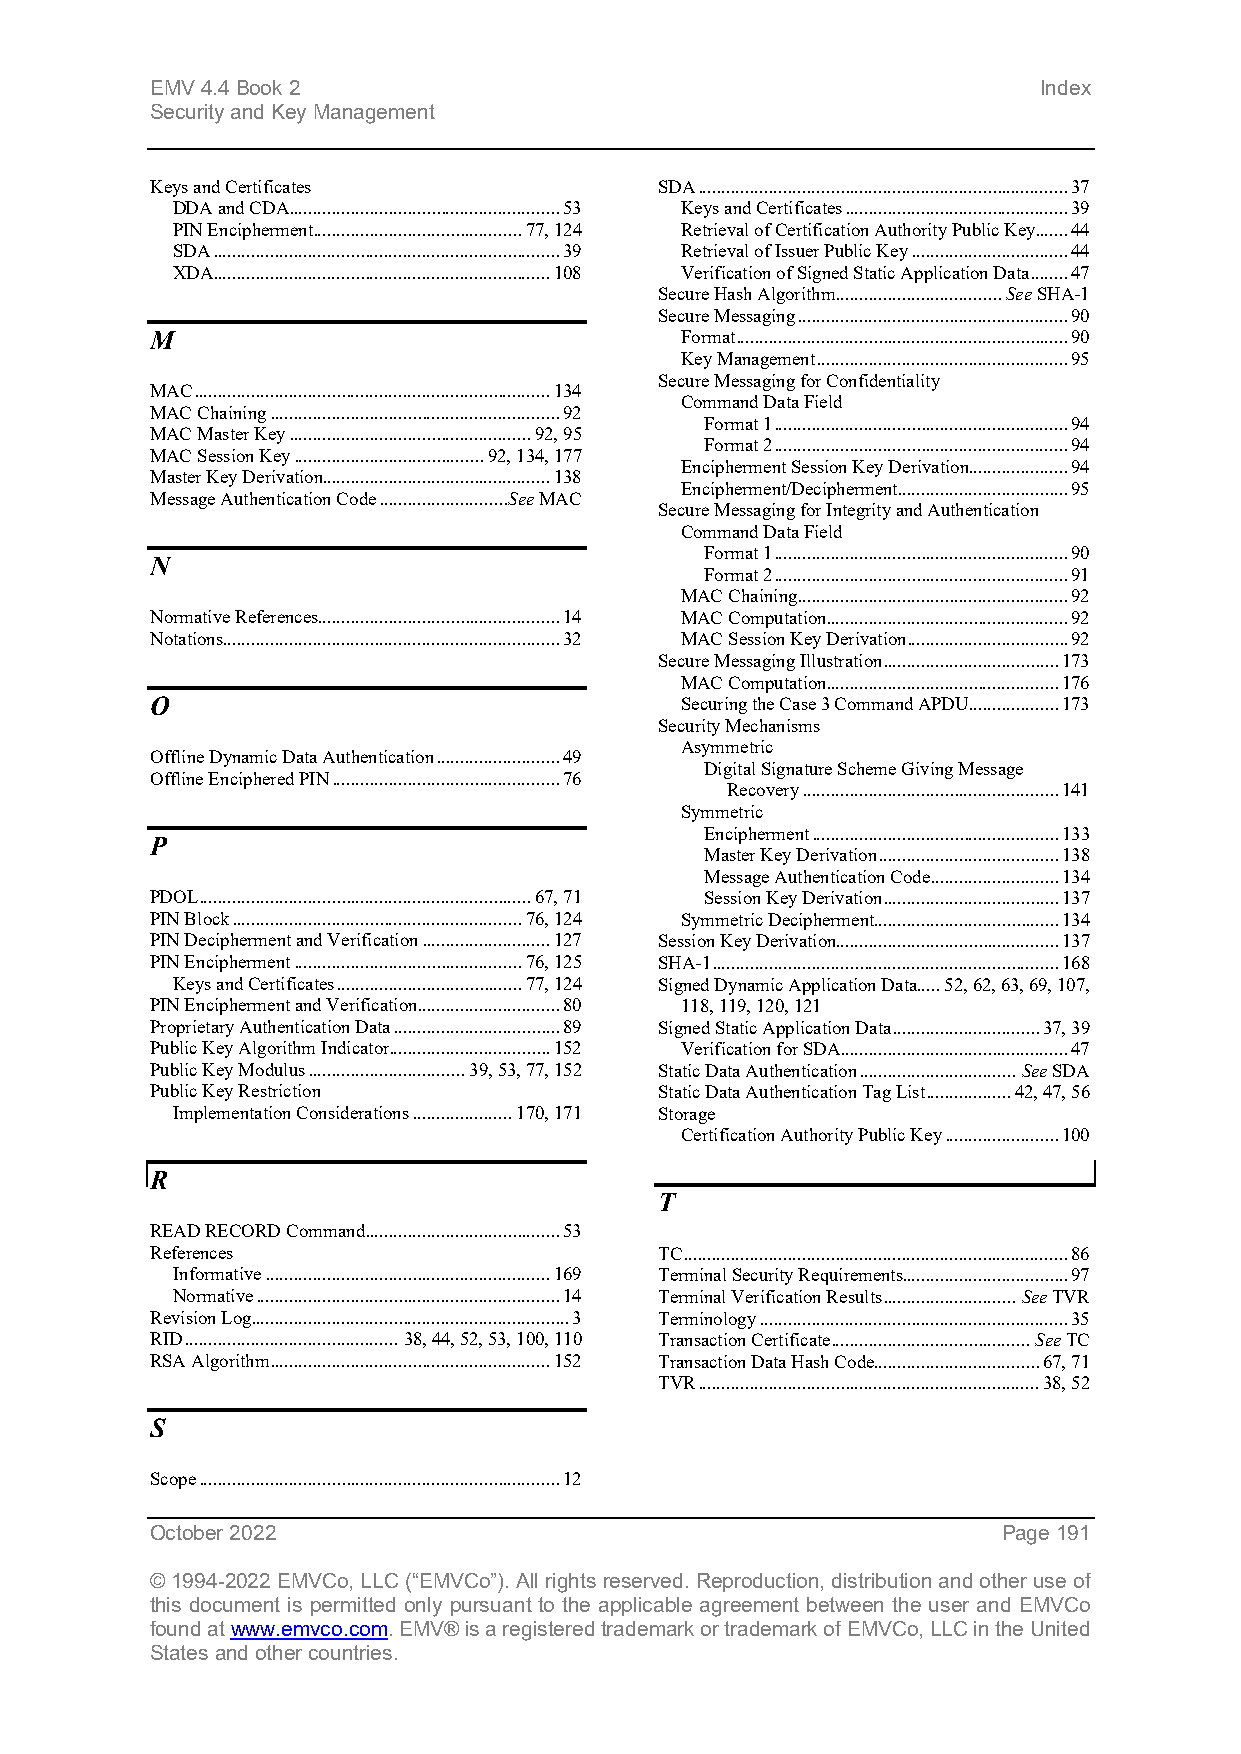

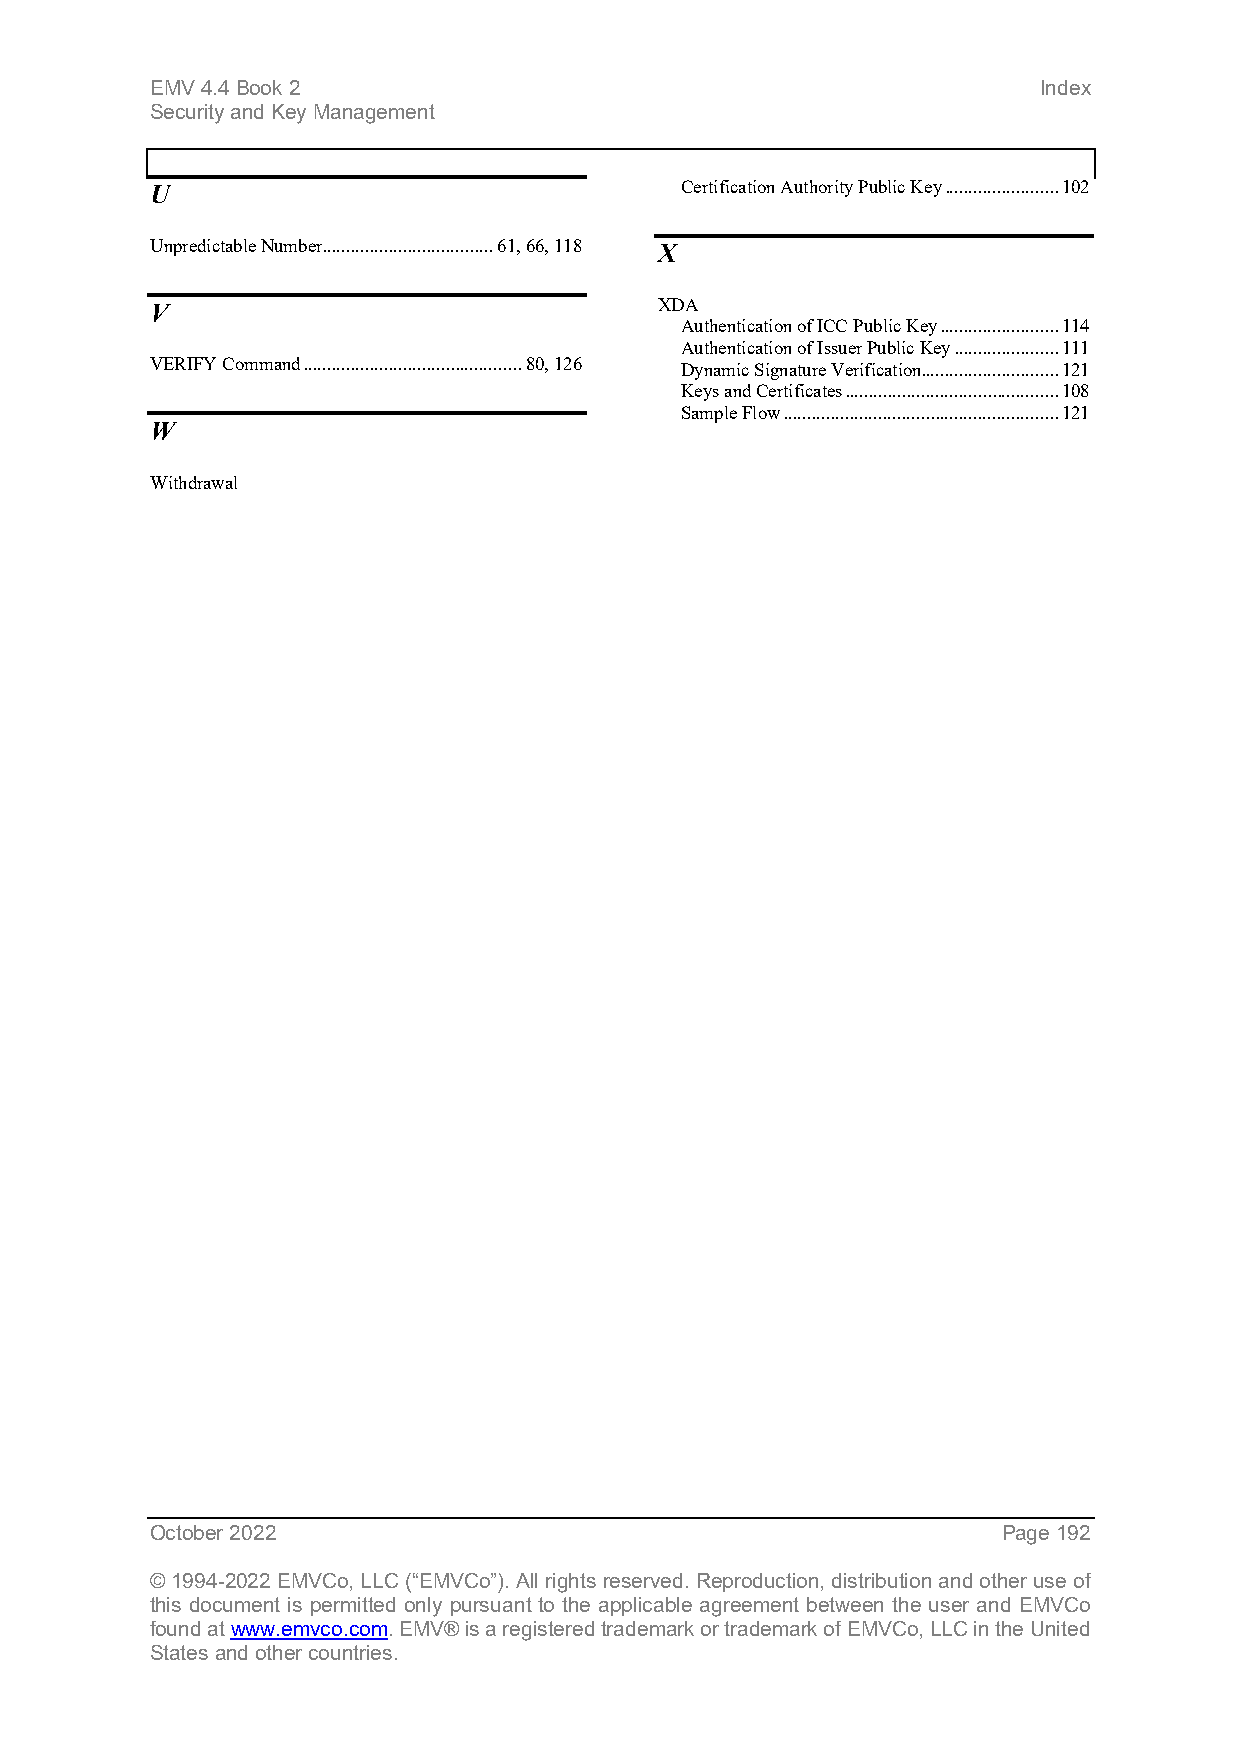

Tables: 59
Wrote: ../../../data/processed/book2/tables/tables.json


In [15]:
tables = []
previous_table_title = None

page_lines_map = {
    rec["page_num"]: rec.get("clean_lines", [])
    for rec in clean_records
}

with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    for i, page in enumerate(pdf.pages, start=1):
        page_lines = page_lines_map.get(i, [])

        dynamic_settings = make_table_fully_bounded(PROFILE["pdf_path"], i-1)
        
        if dynamic_settings:
            table_settings_dynamic = {
                "vertical_strategy": "explicit",
                "horizontal_strategy": "lines",
                **dynamic_settings
            }
        else:
            table_settings_dynamic = table_settings  # fallback
        
        try:
            found = page.find_tables(table_settings_dynamic)
        except Exception:
            found = []

        if found:
            for j, t in enumerate(found, start=1):
                cells = t.extract()
                if cells and len(cells)>1:
                    bbox = getattr(t, "bbox", None)
                    bbox_dict = {
                        "x0": bbox[0],
                        "top": bbox[1],
                        "x1": bbox[2],
                        "bottom": bbox[3]
                    } if bbox else None
    
                    table_title = find_table_title_for_bbox(page_lines, bbox_dict)
    
                    if not table_title:
                        table_title = previous_table_title
                    
                    tables.append({
                        "doc_id": PROFILE["doc_id"],
                        "doc_version": PROFILE["doc_version"],
                        "doc_date": PROFILE["doc_date"],
                        "page_num": i,
                        "table_id": f"p{i:04d}_t{j:02d}",
                        "bbox": bbox_dict,
                        "title": table_title,
                        "cells": cells,
                        "table_text": table_to_text(cells),
                    })
    
                    if table_title:
                        previous_table_title = table_title

tables_path = out_root / "tables" / "tables.json"
tables_path.write_text(json.dumps(tables, ensure_ascii=False, indent=2), encoding="utf-8")

print("Tables:", len(tables))
print("Wrote:", tables_path)

In [16]:
def build_dynamic_hierarchy(cells):
    if not cells or len(cells) < 2:
        return []

    def clean_text(x):
        if x is None:
            return ""
        return " ".join(str(x).split()).strip()

    def clean_header_name(h, idx):
        h = clean_text(h)
        if not h:
            return None
        h = "".join(c if c.isalnum() else "_" for c in h).lower().strip("_")
        return h if h else f"col_{idx}"

    header_row = cells[0]
    data_rows = cells[1:]

    # Step 1: normalize headers
    headers = [clean_header_name(h, i) for i, h in enumerate(header_row)]

    # Step 2: decide which columns to keep
    keep_cols = []
    for col_idx, header in enumerate(headers):
        col_values = []
        for row in data_rows:
            val = row[col_idx] if col_idx < len(row) else None
            col_values.append(clean_text(val))

        if header is not None:
            keep_cols.append(col_idx)
        else:
            if any(v != "" for v in col_values):
                keep_cols.append(col_idx)

    # Step 3: build final kept headers
    kept_headers = [headers[i] for i in keep_cols if headers[i] is not None]

    if not kept_headers:
        return []

    root = []
    stack = []

    for row in data_rows:
        if not row or all(clean_text(c) == "" for c in row):
            continue

        kept_values = []
        for col_idx in keep_cols:
            val = row[col_idx] if col_idx < len(row) else None
            kept_values.append(clean_text(val))

        if all(v == "" for v in kept_values):
            continue

        # nesting level = number of leading empty values
        level = 0
        for val in kept_values:
            if val == "":
                level += 1
            else:
                break

        row_content = [v for v in kept_values if v != ""]

        # Initialize an empty dict so we can control key insertion order
        node = {} 
        
        # 1. Map data keys (Tag, Value, Presence, etc.)
        for i, header in enumerate(kept_headers):
            node[header] = row_content[i] if i < len(row_content) else ""

        # 2. Add level metadata
        node["_level"] = level

        # 3. Add children last so it appears at the bottom of the JSON object
        node["children"] = []

        # hierarchy logic
        stack = stack[:level]

        if level == 0:
            root.append(node)
            stack = [node]
        elif stack:
            stack[-1]["children"].append(node)
            stack.append(node)
        else:
            root.append(node)
            stack = [node]

    return root

In [17]:
structured_tables = []

for table in tables:
    # Use the new dynamic function
    structured = build_dynamic_hierarchy(table.get("cells", []))
    table["structured_data"] = structured
    # table.pop("cells", None)
    # table.pop("table_text", None)
    structured_tables.append(table)
table_path = os.path.join(PROFILE["out_root"], "tables/structured_tables.json")
with open(table_path, "w", encoding="utf-8") as f:
    json.dump(structured_tables, f, indent=2, ensure_ascii=False)

### Example

Extracted Table Data:


,None,Hash Algorithm,N\nHASH,None
0,'01',SHA-1 (not used with ECC;\nsee section B3),n/a,n/a
1,None,SHA-256,32,None
2,None,SHA-512,64,None
3,'04' (assigned),SHA-3 256,32,136
4,'05' (assigned),SHA-3 512,64,72
5,None,SM3,32,None



Table Finder Debugging (Red lines = detected):


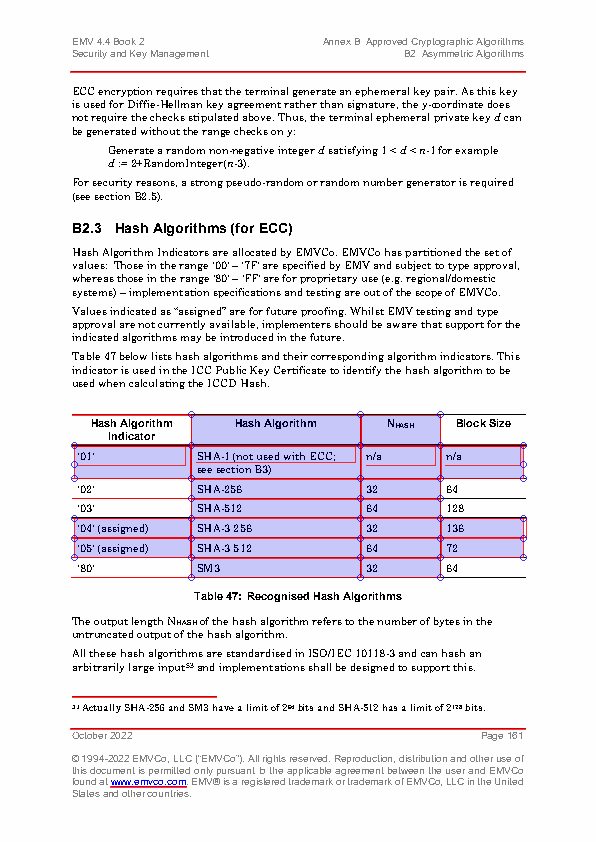

In [18]:
with pdfplumber.open(PROFILE["pdf_path"]) as pdf:
    p0 = pdf.pages[160]
    table = p0.extract_table(table_settings)
    exmpl_tab = pd.DataFrame(table[1:], columns=table[0])
    im = p0.to_image()
print("Extracted Table Data:")
display(exmpl_tab)
print("\nTable Finder Debugging (Red lines = detected):")
display(im.debug_tablefinder(table_settings))

# Stage 4 — Section Assembly

In this stage, we transition from a **page-based** representation of the document to a **section-based** structure. Instead of treating pages as independent units, we reconstruct the document into logical sections.

The section assembly relies on three main components extracted in previous stages:

1.  **Clean Records**: Text lines with spatial data (`bbox`) and page numbers.
2.  **Headings**: Metadata including hierarchy (`level`, `parent_id`) and physical span (`start_page` to `end_page`).
3.  **Tables**: Structured content (cells) and their location.

Each section is defined by a spatial boundaries:
* **Starts**: Immediately below its heading (`bbox.bottom`).
* **Ends**: At the start of the next detected heading (or document end).

To avoid noise in our data, we apply two filters:
* **Spatial Belonging**: Lines must fall within the `start_top` and `end_top` across the page range.
* **Deduplication**: Lines that fall inside a **table area** are excluded from the text blocks to prevent redundant data.

Each section maintains its full context path.
* *Example*: `["Part I", "Application Processing", "General Rules"]`
* This ensures that even a small subsection carries the context of its parent chapters.

Each section is stored as a self-contained JSON-like object:

```json
{
  "heading_id": "EMV_Book_1_v4.4_p0038_h0024",
  "title": "Application Selection",
  "doc_id": "EMV_Book_1",
  "doc_version": "v4.4",
  "doc_date": "2022-12",
  "section_number": "10.2.2",
  "level": 3,
  "parent_titles": ["Files, Commands, and Application Selection","Files","File Referencing"],
  "start_page": 12,
  "end_page": 14,
  "start_top": 145.77,
  "end_top": 455.636,
  "text_blocks": [
      {"page_num": 12, "text": "...", "bbox": {...}}
  ],
  "tables": [...],
  "full_text": "..." 
}
Output: `sections/sections.json`
        `sections/by_section/num_titles.json`

In [19]:
# Stage 4 — Section Assembly
(out_root / "sections").mkdir(parents=True, exist_ok=True)
(out_root / "sections" / "by_section").mkdir(parents=True, exist_ok=True)

tables_source = structured_tables if "structured_tables" in globals() else tables

def safe_filename(s, max_len=120):
    s = clean_inline_text(s)
    s = re.sub(r"[^\w\s\-.]", "", s, flags=re.UNICODE)
    s = re.sub(r"\s+", "_", s).strip("._")
    return s[:max_len] if s else "section"

def build_parent_titles(heading, heading_by_id):
    titles = []
    parent_id = heading.get("parent_heading_id")
    while parent_id:
        parent = heading_by_id.get(parent_id)
        if not parent:
            break
        pt = clean_inline_text(parent.get("title", ""))
        if pt:
            titles.append(pt)
        parent_id = parent.get("parent_heading_id")
    return list(reversed(titles))

In [20]:
def line_belongs_to_heading_span(line, heading):
    page_num = line.get("_page_num")
    top = line.get("top")
    bottom = line.get("bottom")

    if page_num is None or top is None or bottom is None:
        return False

    start_page = heading.get("start_page")
    end_page = heading.get("end_page")
    start_top = heading.get("bbox", {}).get("bottom")  # content starts after heading line
    end_top = heading.get("end_top")

    if start_page is None or end_page is None:
        return False

    if page_num < start_page or page_num > end_page:
        return False

    if start_page == end_page:
        if start_top is not None and bottom < start_top:
            return False
        if end_top is not None and top > end_top:
            return False
        return True

    if page_num == start_page:
        if start_top is not None and bottom < start_top:
            return False
        return True

    if page_num == end_page:
        if end_top is not None and top > end_top:
            return False
        return True

    return True

def table_belongs_to_heading_span(table_obj, heading):
    page_num = table_obj.get("page_num")
    bbox = table_obj.get("bbox") or {}
    top = bbox.get("top")
    bottom = bbox.get("bottom")

    if page_num is None:
        return False

    start_page = heading.get("start_page")
    end_page = heading.get("end_page")
    start_top = heading.get("bbox", {}).get("bottom")
    end_top = heading.get("end_top")

    if start_page is None or end_page is None:
        return False

    if page_num < start_page or page_num > end_page:
        return False

    # if no bbox, page-level inclusion only
    if top is None or bottom is None:
        return True

    if start_page == end_page:
        if start_top is not None and bottom < start_top:
            return False
        if end_top is not None and top > end_top:
            return False
        return True

    if page_num == start_page:
        if start_top is not None and bottom < start_top:
            return False
        return True

    if page_num == end_page:
        if end_top is not None and top > end_top:
            return False
        return True

    return True

def line_belongs_to_table(line, table_obj):
    page_num_line = line.get("_page_num")
    top_line = line.get("top")
    bottom_line = line.get("bottom")

    page_num_tab = table_obj.get("page_num")
    bbox_tab = table_obj.get("bbox") or {}
    top_tab = bbox_tab.get("top")
    bottom_tab = bbox_tab.get("bottom")

    if page_num_line is None or page_num_tab is None:
        return False

    if top_line is None or bottom_line is None:
        return False

    if page_num_line != page_num_tab:
        return False

    if top_tab is None or bottom_tab is None:
        return False

    if bottom_line < top_tab:
        return False

    if top_line > bottom_tab:
        return False

    return True
def line_in_any_table(line, tables_source):
    for tb in tables_source:
        if line_belongs_to_table(line, tb):
            return True
    return False

In [21]:
def heading_to_section_id(h,part=None):
    doc_id = clean_inline_text(h.get("doc_id", "DOC")).replace(" ", "_")
    version = clean_inline_text(h.get("doc_version", "")).replace(" ", "_")
    sec_num = clean_inline_text(h.get("section_number", ""))
    page_num = clean_inline_text(h.get("page_num", ""))
    if sec_num:
        safe_sec = re.sub(r"[^A-Za-z0-9\.]+", "_", sec_num).strip("_")
    else:
        safe_sec = clean_inline_text(h.get("heading_id", "section")).replace(" ", "_")
    if part is None:
        return f"{doc_id}_{version}_{page_num}_{safe_sec}"
    return f"{doc_id}_{version}_{page_num}_{part}{safe_sec}"  
    
def build_parent_number(heading, heading_by_id):
    parent_id = heading.get("parent_heading_id")
    pt = None
    while parent_id:
        parent = heading_by_id.get(parent_id)
        if not parent:
            break
        parent_id = parent.get("parent_heading_id")
        pt = clean_inline_text(parent.get("section_number", ""))
    if pt:
        return pt
    return None
def section_to_filename(section, part=None):
    sec_num = clean_inline_text(section.get("section_number", ""))
    title = clean_inline_text(section.get("title", ""))
    if part and sec_num and title:
        base = f"{part} - {sec_num} - {title}"
    elif sec_num and title:
        base = f"{sec_num} - {title}"
    elif sec_num:
        base = sec_num
    elif title:
        base = title
    else:
        base = section.get("heading_id", "section")

    return safe_filename(base) + ".json"

In [22]:
# add page number to lines for easier filtering
page_lines = []
for rec in clean_records:
    for ln in rec.get("clean_lines", []):
        ln2 = dict(ln)
        ln2["_page_num"] = rec["page_num"]
        page_lines.append(ln2)

sections = []
by_section_dir = out_root / "sections" / "by_section"

heading_by_id = {h["heading_id"]: h for h in headings}

for h in headings:
    section_lines = [ln for ln in page_lines if line_belongs_to_heading_span(ln, h) and not line_in_any_table(ln, tables_source)]
    section_tables = [t for t in tables_source if table_belongs_to_heading_span(t, h)]
    text_blocks = []
    for ln in section_lines:
        text_blocks.append({
            "page_num": ln["_page_num"],
            "text": ln.get("text", ""),
            "bbox": {
                "x0": ln.get("x0"),
                "top": ln.get("top"),
                "x1": ln.get("x1"),
                "bottom": ln.get("bottom")
            }
        })

    # include table titles + text in full_text
    full_parts = []
    for blk in text_blocks:
        txt = clean_inline_text(blk["text"])
        if txt:
            full_parts.append(txt)

    for tb in section_tables:
        if tb.get("title"):
            full_parts.append(clean_inline_text(tb["title"]))
        if tb.get("hierarchy_text"):
            full_parts.append(clean_inline_text(tb["hierarchy_text"]))
        elif tb.get("table_text"):
            full_parts.append(clean_inline_text(tb["table_text"]))
    part = build_parent_number(h, heading_by_id)
    if part == None: 
        part=""
    else:
       part=f"{part}.".replace(" ", "")
    section_obj = {
        "section_id": heading_to_section_id(h,part),
        "heading_id": h.get("heading_id"),
        "parent_heading_id": h.get("parent_heading_id"),
        "doc_id": h.get("doc_id"),
        "doc_version": h.get("doc_version"),
        "doc_date": h.get("doc_date"),
        "title": h.get("title", ""),
        "section_number": f"{part}{h.get('section_number', '')}",
        "level": h.get("level"),
        "parent_titles": build_parent_titles(h, heading_by_id),
        "start_page": h.get("start_page"),
        "end_page": h.get("end_page"),
        "start_top": h.get("bbox", {}).get("top"),
        "end_top": h.get("end_top"),
        "text_blocks": text_blocks,
        "tables": section_tables,
        "full_text": "\n".join([p for p in full_parts if p]).strip()
    }

    sections.append(section_obj)
    # save one file per section
    base_name = section_to_filename(section_obj, part)
    section_file = by_section_dir / base_name
    counter = 1
    
    while section_file.exists():
        section_file = by_section_dir / f"{base_name.replace('.json', '')}_{counter}.json"
        counter += 1

    section_file.write_text(
        json.dumps(section_obj, ensure_ascii=False, indent=2),
        encoding="utf-8"
    )

sections_path = out_root / "sections" / "sections.json"
sections_path.write_text(json.dumps(sections, ensure_ascii=False, indent=2), encoding="utf-8")

print("Sections:", len(sections))
print("Wrote:", sections_path)
print("Per-section files:", by_section_dir)

Sections: 181
Wrote: ../../../data/processed/book2/sections/sections.json
Per-section files: ../../../data/processed/book2/sections/by_section


# Stage 5 — Block Assembly

## Goal

Before chunking, we improve the internal structure of each section so that the content is grouped into **logical blocks** instead of isolated PDF lines.

This stage is important because chunking should not operate directly on raw lines. It should operate on stronger units such as:

- paragraphs
- bullet lists
- numbered rules
- notes / warnings attached to nearby rules
- tables as atomic units

## Why this matters

### Merge consecutive paragraph lines
A paragraph is usually spread across multiple PDF lines. If those lines are kept separate, chunking becomes noisy and meaning can be fragmented.

### Keep bullet lists together
Bullets often form a single logical unit and should remain grouped.

## Output

Each section will receive a new field:

```json
"blocks": [...]
```

Each block will contain:
- `block_type`
- `page_num`
- `bbox`
- `text`
- optional metadata such as `table_id`


In [23]:
# Stage 5 — Block Assembly Before Chunking

(out_root / "sections" / "assembled").mkdir(parents=True, exist_ok=True)
def normalize_text(s):
    s = re.sub(r"[^a-zA-Z0-9\s]", "", s)  # remove special chars
    return re.sub(r"\s+", " ", s).strip().lower()


def detect_line_type(text, section_title=None):
    t = clean_inline_text(text)
    if not t:
        return "empty"

    if re.match(r"^[-•▪◦]\s+", t):
        return "bullet_item"

    if section_title:
        norm_line = normalize_text(t)
        norm_title = normalize_text(section_title)

        starts_like_heading = (
            re.match(r"^\d+(\.\d+)*", t) or
            re.match(r"^PART\s+[IVX]+", t, re.IGNORECASE)
        )

        stripped_line = re.sub(r"^\d+(\.\d+)*\s*", "", norm_line)
        stripped_line = re.sub(r"^part\s+[ivx]+\s*", "", stripped_line)

        if starts_like_heading and stripped_line == norm_title:
            return "heading"

    return "paragraph_line"

# def detect_line_type(text):
#     t = clean_inline_text(text)
#     if not t:
#         return "empty"

#     if re.match(r"^[-•▪◦]\s+", t):
#         return "bullet_item"
#     return "paragraph_line"

def merge_bbox(b1, b2):
    if not b1:
        return b2
    if not b2:
        return b1

    vals_x0 = [b1.get("x0"), b2.get("x0")]
    vals_top = [b1.get("top"), b2.get("top")]
    vals_x1 = [b1.get("x1"), b2.get("x1")]
    vals_bottom = [b1.get("bottom"), b2.get("bottom")]

    return {
        "x0": min(v for v in vals_x0 if v is not None) if any(v is not None for v in vals_x0) else None,
        "top": min(v for v in vals_top if v is not None) if any(v is not None for v in vals_top) else None,
        "x1": max(v for v in vals_x1 if v is not None) if any(v is not None for v in vals_x1) else None,
        "bottom": max(v for v in vals_bottom if v is not None) if any(v is not None for v in vals_bottom) else None,
    }

def same_x_alignment(b1, b2, x_margin):
    if not b1 or not b2:
        return False
    x0_1 = b1.get("x0")
    x0_2 = b2.get("x0")
    if x0_1 is None or x0_2 is None:
        return False
    return x0_2 - x0_1 < x_margin

def should_merge_paragraph_lines(prev_blk, curr_blk, max_gap=6, x_margin=12):
    if prev_blk.get("page_num") != curr_blk.get("page_num"):
        return False

    prev_bbox = prev_blk.get("bbox") or {}
    curr_bbox = curr_blk.get("bbox") or {}
    prev_bottom = prev_bbox.get("bottom")
    curr_top = curr_bbox.get("top")

    if prev_bottom is None or curr_top is None:
        return False

    if curr_top - prev_bottom > max_gap:
        return False

    if prev_blk["type"] == "bullet_item" and curr_blk["type"] == "paragraph":
        return True

    if prev_blk["type"] == "paragraph" and curr_blk["type"] == "paragraph":
        return same_x_alignment(prev_bbox, curr_bbox, x_margin=x_margin)
        
    return False
    
def make_block_id(section_number, idx):
    sec = clean_inline_text(section_number or "")
    sec = sec if sec else "section"
    return f"{sec}_b{idx}"


In [24]:
def assemble_section_blocks(section, x_margin=12):
    raw_items = []

    # reading order is already preserved in text_blocks
    for blk in section.get("text_blocks", []):
        if blk.get("block_type") == "table":
            raw_items.append({
                "type": "table",
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "table_id": blk.get("table_id"),
                "title": blk.get("title"),
                "text": clean_inline_text((blk.get("title") or "") + " " + (blk.get("text") or "")).strip()
            })
        else:
            txt = clean_inline_text(blk.get("text", ""))
            if not txt:
                continue

            line_kind = detect_line_type(txt,section.get("title", ""))
            bbox = blk.get("bbox")

            if line_kind == "bullet_item":
                item_text = re.sub(r"^[-•▪◦]\s+", "", txt).strip()
                raw_items.append({
                    "type": "bullet_item",
                    "page_num": blk.get("page_num"),
                    "bbox": bbox,
                    "text": item_text
                })
            elif line_kind == "paragraph_line":
                raw_items.append({
                    "type": "paragraph",
                    "page_num": blk.get("page_num"),
                    "bbox": bbox,
                    "text": txt
                })

    # merge consecutive paragraph lines into paragraph blocks
    merged = []
    for item in raw_items:
        if item["type"] not in ["paragraph", "bullet_item"]:
            merged.append(item)
            continue

        if not merged:
            merged.append(item)
            continue

        prev = merged[-1]
        
        # Check if we should merge a paragraph line into a bullet or another paragraph
        # Note: We check against 'bullet_item' here because they aren't 'lists' yet
        if (prev["type"] in ["paragraph", "bullet_item"]) and \
           should_merge_paragraph_lines(prev, item, x_margin=x_margin):
            
            prev["text"] = clean_inline_text(prev["text"] + " " + item["text"])
            prev["bbox"] = merge_bbox(prev.get("bbox"), item.get("bbox"))
            # Crucial: The type stays whatever 'prev' was (if it was a bullet, it stays a bullet)
        else:
            merged.append(item)

    # group consecutive bullet items into one bullet_list block
    grouped = []
    i = 0
    while i < len(merged):
        item = merged[i]

        if item["type"] == "bullet_item":
            bullet_items = [item["text"]]
            bullet_bbox = item.get("bbox")
            bullet_page = item.get("page_num")
            j = i + 1

            while j < len(merged) and merged[j]["type"] == "bullet_item":
                bullet_items.append(merged[j]["text"])
                bullet_bbox = merge_bbox(bullet_bbox, merged[j].get("bbox"))
                j += 1

            grouped.append({
                "type": "bullet_list",
                "page_num": bullet_page,
                "bbox": bullet_bbox,
                "items": bullet_items
            })
            i = j
        else:
            grouped.append(item)
            i += 1

    # assign block ids + structural attachments
    final_blocks = []
    section_number = section.get("section_number", "")
    
    prev_non_table_block_id = None
    prev_non_table_bbox = None
    for idx, blk in enumerate(grouped, start=1):
        block_id = make_block_id(section_number, idx)
        if blk["type"] == "paragraph":
            out_blk = {
                "block_id": block_id,
                "type": "paragraph",
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "text": blk.get("text", "")
            }

            if prev_non_table_block_id and prev_non_table_bbox and not same_x_alignment(prev_non_table_bbox, blk.get("bbox") or {}, x_margin=x_margin):
                out_blk["attached_to_block_id"] = prev_non_table_block_id

            final_blocks.append(out_blk)
            prev_non_table_block_id = block_id
            prev_non_table_bbox = blk.get("bbox")

        elif blk["type"] == "bullet_list":
            out_blk = {
                "block_id": block_id,
                "type": "bullet_list",
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "items": blk.get("items", [])
            }

            if prev_non_table_block_id:
                out_blk["intro_block_id"] = prev_non_table_block_id

            final_blocks.append(out_blk)
            prev_non_table_block_id = block_id
            prev_non_table_bbox = blk.get("bbox")

        elif blk["type"] == "table":
            out_blk = {
                "block_id": block_id,
                "type": "table",
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "table_id": blk.get("table_id"),
                "title": blk.get("title"),
                "text": blk.get("text", "")
            }
            final_blocks.append(out_blk)

        else:
            out_blk = {
                "block_id": block_id,
                "type": blk["type"],
                "page_num": blk.get("page_num"),
                "bbox": blk.get("bbox"),
                "text": blk.get("text", "")
            }
            final_blocks.append(out_blk)
            
    return final_blocks

In [25]:

blocks_assembled = []

for sec in sections:
    sec2 = dict(sec)
    sec2["blocks"] = assemble_section_blocks(sec2)
    sec2.pop("text_blocks", None)
    sec2.pop("full_text", None)
    blocks_assembled.append(sec2)

assembled_path = out_root / "sections" / "assembled" / "blocks_assembled.json"
assembled_path.write_text(json.dumps(blocks_assembled, ensure_ascii=False, indent=2), encoding="utf-8")

print("Sections with assembled blocks:", len(blocks_assembled))
print("Wrote:", assembled_path)

Sections with assembled blocks: 181
Wrote: ../../../data/processed/book2/sections/assembled/blocks_assembled.json


## Section Deduplication (Parent–Child Cleanup)
This process ensures each content block belongs to exactly one section, removing redundant text from the document hierarchy.

### Summary of Operations
- Hierarchy Mapping: Establishes parent_section_id and child_section_ids using document layout.
- Spatial Filtering: Uses Layout-based span logic to determine exactly where a block starts and ends.
- The "Direct Content" Rule: A block is kept in a section only if it is within that section's boundaries and NOT inside any of its children's boundaries.
### Key Results
- Clean Parents: Parent sections retain only their specific introductory text.
- Detailed Children: Sub-sections keep their full specific content without it being duplicated in the header section.
- Optimized JSON: The output contains a lean, non-redundant structure where metadata handles the relationships instead of repeating text.

In [26]:
def sort_sections(sections):
    return sorted(
        sections,
        key=lambda s: (
            s.get("start_page", 10**9),
            s.get("start_top", 10**9 if s.get("start_top") is None else s.get("start_top"))
        )
    )

def point_in_section(page_num, top, section):
    start_page = section.get("start_page")
    end_page = section.get("end_page")
    start_top = section.get("start_top")
    end_top = section.get("end_top")

    if page_num is None or top is None:
        return False
    if start_page is None or end_page is None:
        return False
    if page_num < start_page or page_num > end_page:
        return False

    if start_page == end_page:
        if start_top is not None and top < start_top:
            return False
        if end_top is not None and top > end_top:
            return False
        return True

    if page_num == start_page:
        if start_top is not None and top < start_top:
            return False
        return True

    if page_num == end_page:
        if end_top is not None and top > end_top:
            return False
        return True

    return True

sections = sort_sections(blocks_assembled)

heading_to_section_id = {}
section_by_id = {}
for sec in sections:
    heading_to_section_id[sec["heading_id"]] = sec["section_id"]
    section_by_id[sec["section_id"]] = sec

cleaned_assembled = []
for sec in sections:
    sec2 = dict(sec)
    parent_heading_id = sec2.get("parent_heading_id")
    sec2["parent_section_id"] = heading_to_section_id.get(parent_heading_id)
    sec2["child_section_ids"] = []
    cleaned_assembled.append(sec2)

cleaned_by_id = {sec["section_id"]: sec for sec in cleaned_assembled}

for sec in cleaned_assembled:
    parent_id = sec.get("parent_section_id")
    if parent_id and parent_id in cleaned_by_id:
        cleaned_by_id[parent_id]["child_section_ids"].append(sec["section_id"])

# 4) remove child content from parent
for sec in cleaned_assembled:
    child_sections = [cleaned_by_id[cid] for cid in sec.get("child_section_ids", []) if cid in cleaned_by_id]

    direct_blocks = []
    for blk in sec.get("blocks", []):
        page_num = blk.get("page_num")
        bbox = blk.get("bbox") or {}
        top = bbox.get("top")

        inside_child = False
        for child in child_sections:
            if point_in_section(page_num, top, child):
                inside_child = True
                break

        if not inside_child:
            direct_blocks.append(blk)

    direct_tables = []
    for tb in sec.get("tables", []):
        page_num = tb.get("page_num")
        bbox = tb.get("bbox") or {}
        top = bbox.get("top")

        inside_child = False
        for child in child_sections:
            if point_in_section(page_num, top, child):
                inside_child = True
                break

        if not inside_child:
            direct_tables.append(tb)

    sec["blocks"] = direct_blocks
    sec["tables"] = direct_tables

# cleaned_assembled_sections now contains direct-only content
print("Cleaned sections:", len(cleaned_assembled))



Cleaned sections: 181


For visiblity purpose 

In [27]:
def reorder_section(sec):
    # List the keys in the exact order you want
    desired_order = [
        "section_id","parent_section_id", "doc_id", 
        "doc_version", "doc_date", "title", "section_number", 
        "level", "parent_titles", "start_page", "end_page", 
        "start_top", "end_top", 
        "child_section_ids",
        "blocks", "tables"
    ]
    
    # Create a new dict by pulling keys in that order
    return {k: sec[k] for k in desired_order if k in sec}

# Use it in your loop
cleaned_assembled = [reorder_section(s) for s in cleaned_assembled]
# Save to JSON
out_path = out_root / "sections" / "assembled" /  "cleaned_assembled_sections.json"
out_path.write_text(json.dumps(cleaned_assembled, ensure_ascii=False, indent=2), encoding="utf-8")
print("Wrote:", out_path)

Wrote: ../../../data/processed/book2/sections/assembled/cleaned_assembled_sections.json


## Final cleaning
Fixes Hyphenation: Reconnects words split by line breaks (e.g., applica- tion).

Removes Noise: Collapses repeated punctuation and strips stray symbols.

Normalizes Whitespace: Trims sentences and removes internal \n characters.

Preserves Structure: Cleans paragraphs and bullet items while maintaining JSON IDs.

In [28]:
def clean_text(s):
    if not s:
        return ""

    s = str(s)

    # fix hyphenation across line breaks or spaces: "applica-\ntion" / "applica- tion"
    s = re.sub(r'(\w)\s*-\s*(\w)', r'\1\2', s)

    # replace line breaks inside text with spaces
    s = s.replace("\n", " ")

    # remove obvious repeated punctuation like "...." -> "."
    s = re.sub(r'\.{2,}', '.', s)

    # remove stray isolated symbols surrounded by spaces
    s = re.sub(r'\s+[•▪◦]+\s*', ' ', s)

    # normalize whitespace
    s = re.sub(r'\s+', ' ', s).strip()

    return s

cleaned_sections = []

for sec in cleaned_assembled:
    sec2 = dict(sec)
    new_blocks = []

    for blk in sec.get("blocks", []):
        blk2 = dict(blk)

        if blk2.get("type") == "paragraph" and "text" in blk2:
            blk2["text"] = clean_text(blk2["text"])

        elif blk2.get("type") == "bullet_list" and "items" in blk2:
            blk2["items"] = [clean_text(item) for item in blk2.get("items", []) if clean_text(item)]

        new_blocks.append(blk2)

    sec2["blocks"] = new_blocks
    cleaned_sections.append(sec2)

# save to JSON
out_path = out_root / "done" / "final_chunk_ready.json"
out_path.write_text(json.dumps(cleaned_sections, ensure_ascii=False, indent=2), encoding="utf-8")

print("Cleaned sections:", len(cleaned_sections))
print("Wrote:", out_path)

Cleaned sections: 181
Wrote: ../../../data/processed/book2/done/final_chunk_ready.json


## Extraction Pipeline Summary
**Clean Records:** Extracted text lines enriched with spatial metadata (`bbox`, `page_num`) for precise positioning.

**Heading Detection & Hierarchy:** Identified headings with structured relationships (`level`, `parent_heading_id`) and computed their document spans (`start_page`, `end_page`, `start_top`, `end_top`).

**Table Extraction:** Detected tables using pdfplumber, storing both raw cells and structured representations with bounding boxes and optional titles.

**Section Assembly:** Built logical sections (not page-based) by grouping text and tables under each heading using span-based filtering.

**Block Construction:** Converted raw lines into meaningful content blocks:
- Paragraphs (merged lines)
- Bullet lists (grouped items)
- Tables (kept atomic)

**Hierarchy Cleanup (Deduplication):** Removed duplicated content across sections so each section keeps only its direct content, while preserving hierarchy via metadata.
Text Normalization: Cleaned block text in-place:
- Fixed spacing, line breaks, and hyphenation
- Cleaned bullet items
- Removed minor noise without altering meaning

**Final Output Structure**: Produced structured sections ready for retrieval:
- Metadata (IDs, hierarchy, spans)
- blocks (typed content units)
- tables (structured data)
- No redundant fields (text_blocks, full_text removed)
### Final output Example
```json
  {
    "section_id": "EMV_Book_1_v4.4_9_Part_I",
    "parent_section_id": null,
    "doc_id": "EMV_Book_1",
    "doc_version": "v4.4",
    "doc_date": "2022-12",
    "title": "General",
    "section_number": "Part I",
    "level": 0,
    "parent_titles": [],
    "start_page": 9,
    "end_page": 33,
    "start_top": 215.31599999999992,
    "end_top": 719.6364,
    "child_section_ids": [
      "EMV_Book_1_v4.4_10_PartI.1",
      "EMV_Book_1_v4.4_12_PartI.2",
      "EMV_Book_1_v4.4_15_PartI.3",
      "EMV_Book_1_v4.4_23_PartI.4"
    ],
    "blocks": [
      {
        "block_id": "Part I_b1",
        "type": "paragraph",
        "page_num": 9,
        "bbox": {
          "x0": 230.7,
          "top": 284.3159999999999,
          "x1": 364.82519999999994,
          "bottom": 320.3159999999999
        },
        "text": "General"
      }
    ],
    "tables": []
  }